In [5]:
import warnings
warnings.filterwarnings("ignore")


## Imports


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_gbq


In [7]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_COL = "bureau_nm_ajust"
MODELS = ["BLEND3", "BLEND4"]
CITY_COL = "id_cidade_ibge"
AGENCY_COL = "id_imobiliaria"
CITY_PC_COL = "message_blend3Variables_cityPc4HistoryOver100Contracts"
AGENCY_PC_COL = "message_blend3Variables_realEstatePc4HistoryOver100Contracts"
CITY_PC_MAY_COL = "city_pc4_mais_100_contratos__pc_categorias_maio2026"
AGENCY_PC_MAY_COL = "agency_pc4_mais_100_contratos__pc_categorias_maio2026"
MAY_PERIOD = "2026-05-01"


## Base

Leads escorados em `df_model_simulacao_blend_expandido.csv`, restritos a **BLEND3** e **BLEND4** (`bureau_nm_ajust`).

- Cidade: `id_cidade_ibge`
- Imobiliária: `id_imobiliaria`
- PC cidade (usado na escoragem): `message_blend3Variables_cityPc4HistoryOver100Contracts`
- PC imobiliária (usado na escoragem): `message_blend3Variables_realEstatePc4HistoryOver100Contracts`
- Snapshot de maio/2026: `city_pc4_mais_100_contratos__pc_categorias_maio2026` e `agency_pc4_mais_100_contratos__pc_categorias_maio2026`

O PC só é preenchido para entidades com histórico de 100+ contratos. Nulo = fora desse universo, não é zero.


In [8]:
df_funil = (
    pd.read_csv(ANALYTICS_DIR / "df_model_simulacao_blend_expandido.csv")
    .drop(columns=["Unnamed: 0"])
)
df_funil["mes_referencia"] = df_funil["requested_at"].astype(str).str[:7] + "-01"
df_funil = df_funil[df_funil[MODEL_COL].isin(MODELS)].copy()
df_funil


,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,request_existingContractDebts_qtdeDividas,request_existingContractDebts_saldoReceber,request_existingContractDebts_taxaCredpago,request_scores_BVS_CUSTOM_V2,request_scores_HFT1,request_blend3Variables_hasPreviousContracts,request_blend3Variables_hadOverdueInvoiceInPreviousContracts,request_blend3Variables_cityPc4HistoryOver100Contracts,request_blend3Variables_realEstatePc4HistoryOver100Contracts,mes_referencia
3,4326992,2026-07-02,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,41]",0,Smart Plus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01
4,4394604,2026-07-20,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01
5,4412815,2026-07-23,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01
6,4413361,2026-07-23,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01
7,4382728,2026-07-16,whatsapp,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201336,4467471,2026-08-05,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-08-01
201337,4441019,2026-07-30,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01
201338,4447958,2026-07-31,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01
201339,4512412,2026-08-14,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-08-01


In [5]:
df_funil[df_funil["message_blend3Variables_realEstatePc4HistoryOver100Contracts"] == 0.0][["contract_id", "requested_at", "mes_referencia", "city_pc4_mais_100_contratos__pc_categorias_maio2026", "agency_pc4_mais_100_contratos__pc_categorias_maio2026", "message_blend3Variables_realEstatePc4HistoryOver100Contracts"]]

,contract_id,requested_at,mes_referencia,city_pc4_mais_100_contratos__pc_categorias_maio2026,agency_pc4_mais_100_contratos__pc_categorias_maio2026,message_blend3Variables_realEstatePc4HistoryOver100Contracts
1318,4331858,2026-07-03,2026-07-01,NaN,NaN,0.0
3370,4329857,2026-07-03,2026-07-01,0.132450,NaN,0.0
4325,4331939,2026-07-03,2026-07-01,0.122789,NaN,0.0
4490,4329717,2026-07-03,2026-07-01,0.093694,NaN,0.0
5446,4331058,2026-07-03,2026-07-01,0.090909,NaN,0.0
...,...,...,...,...,...,...
195936,4322621,2026-07-02,2026-07-01,0.072010,NaN,0.0
197611,4327626,2026-07-02,2026-07-01,0.135088,NaN,0.0
198780,4332132,2026-07-03,2026-07-01,0.134769,NaN,0.0
199764,4332343,2026-07-03,2026-07-01,0.102845,NaN,0.0


In [6]:
df_funil[df_funil["message_blend3Variables_realEstatePc4HistoryOver100Contracts"] == 0.0].groupby(
    ["bureau_nm_ajust", "mes_referencia"]
).size()

bureau_nm_ajust  mes_referencia
BLEND3           2026-07-01          3
BLEND4           2026-07-01        157
dtype: int64

In [7]:
df_funil[df_funil["message_blend3Variables_realEstatePc4HistoryOver100Contracts"] == 0.0].groupby(
    ["bureau_nm_ajust", "requested_at"]
).size()

bureau_nm_ajust  requested_at
BLEND3           2026-07-02        2
                 2026-07-03        1
BLEND4           2026-07-01        2
                 2026-07-02       15
                 2026-07-03      140
dtype: int64

In [8]:
df_funil[df_funil["message_blend3Variables_realEstatePc4HistoryOver100Contracts"] == 0.0].groupby(
    ["id_imobiliaria"]
).size()

id_imobiliaria
233      1
239      1
356      1
577      1
734      1
        ..
57224    1
57313    2
57372    1
57387    2
57388    1
Length: 145, dtype: int64

In [9]:
# df_funil[df_funil["message_blend3Variables_realEstatePc4HistoryOver100Contracts"] == 0.0].groupby(
#     ["rating_manual_blend4_prod", "rating_manual_blend4_agency"]
# ).size()

In [10]:
df_funil[df_funil["message_blend3Variables_realEstatePc4HistoryOver100Contracts"] == 0.0][["id_imobiliaria"]].nunique()

id_imobiliaria    145
dtype: int64

In [11]:
print("Modelos")
display(df_funil[MODEL_COL].value_counts(dropna=False).to_frame("n"))
print("Período")
display(df_funil["requested_at"].agg(["min", "max"]).to_frame("requested_at"))
print("Safras do funil")
display(df_funil["mes_referencia"].value_counts(dropna=False).sort_index().to_frame("n"))
print("Cobertura das variáveis de PC")
coverage = pd.DataFrame({
    "n_preenchido": df_funil[[CITY_PC_COL, AGENCY_PC_COL, CITY_PC_MAY_COL, AGENCY_PC_MAY_COL]].notna().sum(),
    "share_preenchido": df_funil[[CITY_PC_COL, AGENCY_PC_COL, CITY_PC_MAY_COL, AGENCY_PC_MAY_COL]].notna().mean(),
})
display(coverage.style.format({"n_preenchido": "{:,.0f}", "share_preenchido": "{:.1%}"}))


Modelos


,n
bureau_nm_ajust,
BLEND3,141424
BLEND4,50439


Período


,requested_at
min,2026-07-01
max,2026-08-17


Safras do funil


,n
mes_referencia,
2026-07-01,123709
2026-08-01,68154


Cobertura das variáveis de PC


,n_preenchido,share_preenchido
message_blend3Variables_cityPc4HistoryOver100Contracts,"162,585",84.7%
message_blend3Variables_realEstatePc4HistoryOver100Contracts,"34,704",18.1%
city_pc4_mais_100_contratos__pc_categorias_maio2026,"167,766",87.4%
agency_pc4_mais_100_contratos__pc_categorias_maio2026,"37,470",19.5%


## Série de PC por entidade

Para cada cidade e imobiliária montamos uma série com:

1. **Maio/2026** — snapshot `*_maio2026` (um valor por entidade).
2. **Jul/2026 e ago/2026** — último PC observado na escoragem daquele mês (`message_blend3Variables_*`).

Isso reproduz o acompanhamento por safra e permite medir crescimento/queda frente a maio.


In [12]:
def build_pc_long(
    df: pd.DataFrame,
    entity_col: str,
    pc_current_col: str,
    pc_may_col: str,
    value_name: str,
) -> pd.DataFrame:
    """Long PC series: May snapshot plus last scoring-time PC per month."""
    aux = df[[entity_col, "requested_at", "mes_referencia", pc_current_col, pc_may_col]].copy()
    aux[entity_col] = pd.to_numeric(aux[entity_col], errors="coerce")
    aux = aux.dropna(subset=[entity_col])
    aux[entity_col] = aux[entity_col].astype("int64")

    may = (
        aux.dropna(subset=[pc_may_col])
        .groupby(entity_col, as_index=False)[pc_may_col]
        .first()
        .rename(columns={pc_may_col: value_name})
        .assign(mes_referencia=MAY_PERIOD)
    )
    monthly = (
        aux.sort_values("requested_at")
        .dropna(subset=[pc_current_col])
        .groupby([entity_col, "mes_referencia"], as_index=False)[pc_current_col]
        .last()
        .rename(columns={pc_current_col: value_name})
    )
    out = pd.concat([may, monthly], ignore_index=True)
    out = out.drop_duplicates([entity_col, "mes_referencia"], keep="last")
    return out.sort_values(["mes_referencia", entity_col]).reset_index(drop=True)


city_names = (
    df_funil.groupby(CITY_COL, as_index=False)
    .agg(imovel_cidade=("imovel_cidade", "first"), imovel_uf=("imovel_uf", "first"))
)
city_names[CITY_COL] = pd.to_numeric(city_names[CITY_COL], errors="coerce").astype("Int64")

df_city = build_pc_long(
    df_funil,
    entity_col=CITY_COL,
    pc_current_col=CITY_PC_COL,
    pc_may_col=CITY_PC_MAY_COL,
    value_name="city_pc4",
)
df_agency = build_pc_long(
    df_funil,
    entity_col=AGENCY_COL,
    pc_current_col=AGENCY_PC_COL,
    pc_may_col=AGENCY_PC_MAY_COL,
    value_name="agency_pc4",
)


In [13]:
print("Cidades — série de PC (maio + safras de escoragem)")
display(df_city)
print("Imobiliárias — série de PC (maio + safras de escoragem)")
display(df_agency)


Cidades — série de PC (maio + safras de escoragem)


,id_cidade_ibge,city_pc4,mes_referencia
0,2211001,0.144638,2026-05-01
1,2304400,0.135088,2026-05-01
2,2408102,0.099099,2026-05-01
3,2507507,0.030534,2026-05-01
4,2611606,0.090535,2026-05-01
...,...,...,...
598,5208707,0.178474,2026-08-01
599,5211503,0.145455,2026-08-01
600,5211909,0.104348,2026-08-01
601,5218805,0.126667,2026-08-01


Imobiliárias — série de PC (maio + safras de escoragem)


,id_imobiliaria,agency_pc4,mes_referencia
0,81,0.101911,2026-05-01
1,121,0.191667,2026-05-01
2,128,0.103226,2026-05-01
3,215,0.161491,2026-05-01
4,222,0.055556,2026-05-01
...,...,...,...
563,35393,0.090909,2026-08-01
564,37080,0.096154,2026-08-01
565,38518,0.201342,2026-08-01
566,40682,0.183406,2026-08-01


## Estatísticas por período

Média, p25, p50 e p75 do PC **no nível da entidade** (uma observação por cidade/imobiliária e safra), para maio/2026, jul/2026 e ago/2026.


In [14]:
def stats_by_safra(df: pd.DataFrame, value_col: str, date_col: str = "mes_referencia") -> pd.DataFrame:
    """Aggregate mean, p25, p50 and p75 of value_col by safra."""
    out = (
        df.groupby(date_col, as_index=False)[value_col]
        .agg(
            n="count",
            mean="mean",
            p25=lambda s: s.quantile(0.25),
            p50=lambda s: s.quantile(0.50),
            p75=lambda s: s.quantile(0.75),
        )
        .sort_values(date_col)
    )
    out["safra"] = pd.to_datetime(out[date_col]).dt.strftime("%Y-%m")
    return out


def plot_stats_by_safra(stats: pd.DataFrame, title: str, ylabel: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 6))
    styles = {
        "mean": {"marker": "D", "linestyle": "-", "linewidth": 2},
        "p25": {"marker": "v", "linestyle": "--", "linewidth": 1.5},
        "p50": {"marker": "o", "linestyle": "-", "linewidth": 2},
        "p75": {"marker": "^", "linestyle": "--", "linewidth": 1.5},
    }
    for metric, style in styles.items():
        ax.plot(stats["safra"], stats[metric], label=metric, **style)
    ax.set_title(title)
    ax.set_xlabel("Safra")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


city_stats = stats_by_safra(df_city, "city_pc4")
agency_stats = stats_by_safra(df_agency, "agency_pc4")


Cidades — estatísticas do PC por período


,mes_referencia,n,mean,p25,p50,p75,safra
0,2026-05-01,192,0.0954,0.0682,0.0900,0.1190,2026-05
1,2026-07-01,217,0.0875,0.0620,0.0844,0.1144,2026-07
2,2026-08-01,194,0.0987,0.0754,0.0927,0.1198,2026-08


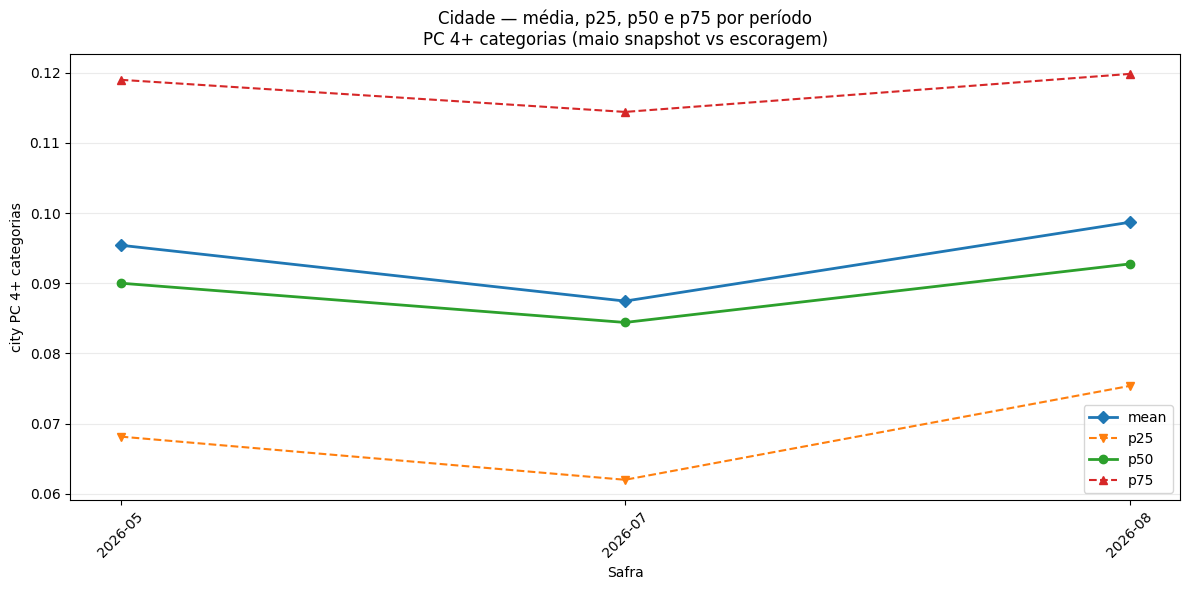

In [15]:
print("Cidades — estatísticas do PC por período")
display(city_stats.style.format({
    "n": "{:.0f}", "mean": "{:.4f}", "p25": "{:.4f}", "p50": "{:.4f}", "p75": "{:.4f}",
}))
plot_stats_by_safra(
    city_stats,
    title="Cidade — média, p25, p50 e p75 por período\nPC 4+ categorias (maio snapshot vs escoragem)",
    ylabel="city PC 4+ categorias",
)


Imobiliárias — estatísticas do PC por período


,mes_referencia,n,mean,p25,p50,p75,safra
0,2026-05-01,145,0.1269,0.0814,0.1186,0.1583,2026-05
1,2026-07-01,293,0.0647,0.0000,0.0219,0.1148,2026-07
2,2026-08-01,130,0.1334,0.0904,0.1248,0.1657,2026-08


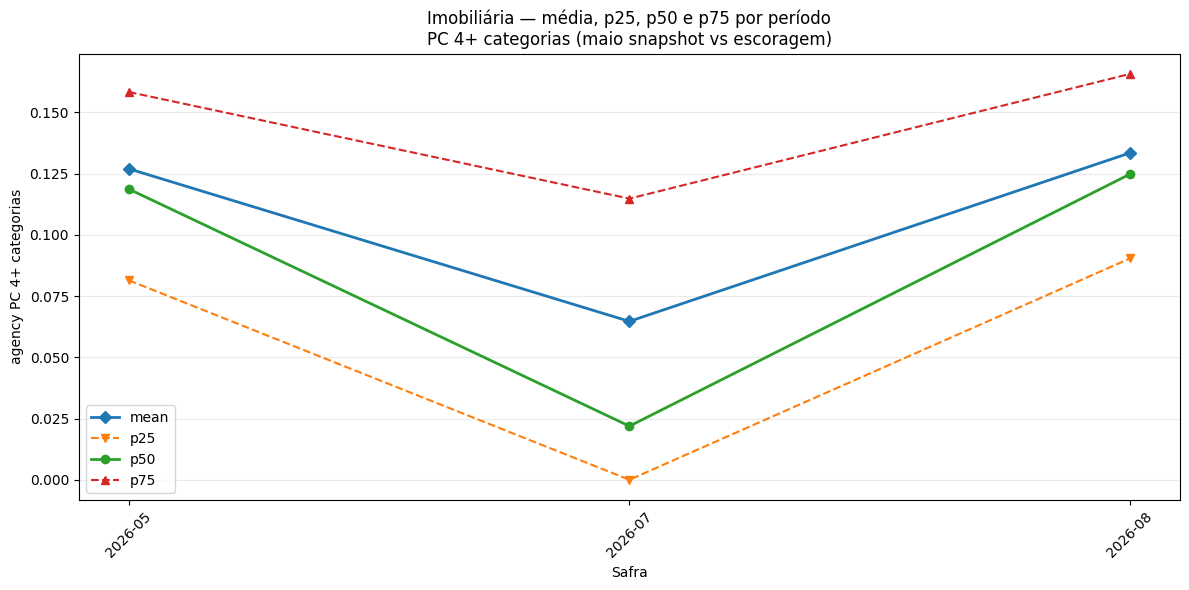

In [16]:
print("Imobiliárias — estatísticas do PC por período")
display(agency_stats.style.format({
    "n": "{:.0f}", "mean": "{:.4f}", "p25": "{:.4f}", "p50": "{:.4f}", "p75": "{:.4f}",
}))
plot_stats_by_safra(
    agency_stats,
    title="Imobiliária — média, p25, p50 e p75 por período\nPC 4+ categorias (maio snapshot vs escoragem)",
    ylabel="agency PC 4+ categorias",
)


### PC no funil, por modelo

Estatísticas **ponderadas pelo lead** do PC usado na escoragem, por safra e `bureau_nm_ajust`. Complementa a visão por entidade: aqui o mix BLEND3/BLEND4 e o volume entram no cálculo.


Cidades — PC de escoragem por safra e modelo (nível lead)


,mes_referencia,bureau_nm_ajust,n,mean,p25,p50,p75,safra
0,2026-07-01,BLEND3,93591,0.1044,0.0817,0.1007,0.1233,2026-07
1,2026-07-01,BLEND4,13140,0.1034,0.0809,0.0992,0.1231,2026-07
2,2026-08-01,BLEND3,30113,0.1079,0.0833,0.1031,0.1265,2026-08
3,2026-08-01,BLEND4,25741,0.1077,0.0828,0.1026,0.1267,2026-08


Imobiliárias — PC de escoragem por safra e modelo (nível lead)


,mes_referencia,bureau_nm_ajust,n,mean,p25,p50,p75,safra
0,2026-07-01,BLEND3,20488,0.1442,0.1000,0.1290,0.1921,2026-07
1,2026-07-01,BLEND4,2911,0.1355,0.0965,0.1236,0.1862,2026-07
2,2026-08-01,BLEND3,6045,0.1500,0.1022,0.1380,0.1845,2026-08
3,2026-08-01,BLEND4,5260,0.1495,0.1022,0.1380,0.1834,2026-08


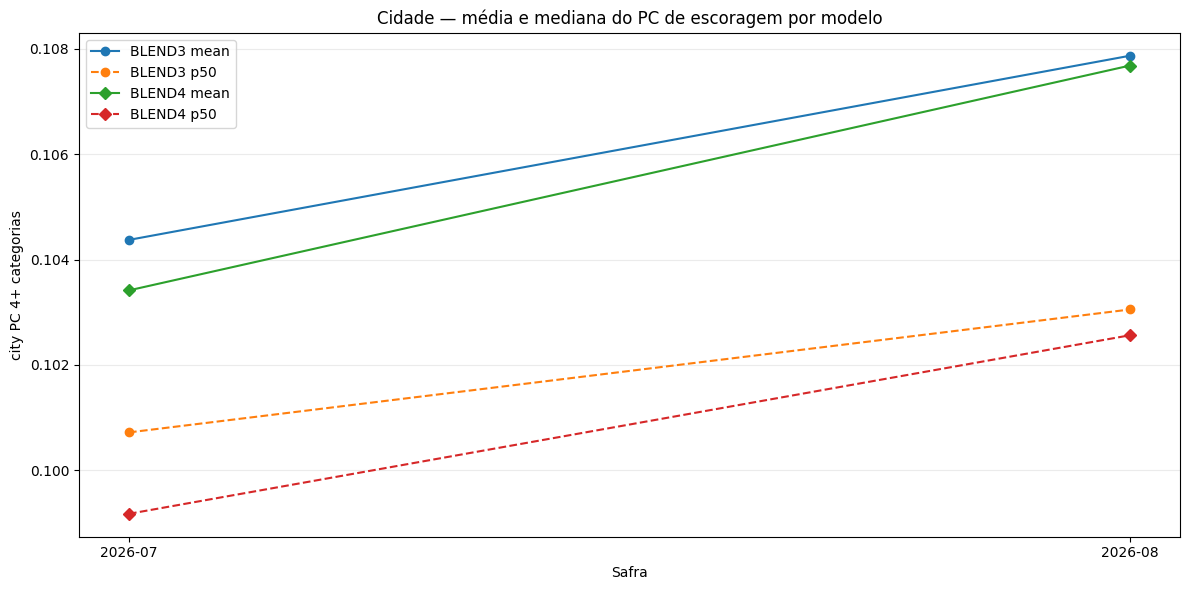

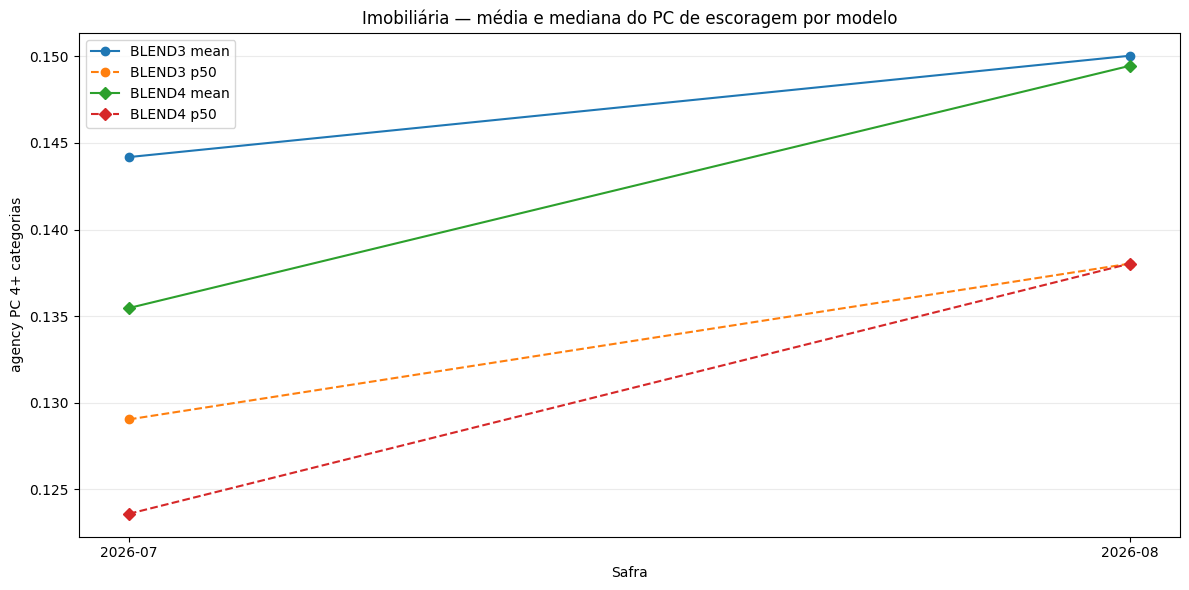

In [17]:
def stats_by_model(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    out = (
        df.groupby(["mes_referencia", MODEL_COL], as_index=False)[value_col]
        .agg(
            n="count",
            mean="mean",
            p25=lambda s: s.quantile(0.25),
            p50=lambda s: s.quantile(0.50),
            p75=lambda s: s.quantile(0.75),
        )
        .sort_values(["mes_referencia", MODEL_COL])
    )
    out["safra"] = pd.to_datetime(out["mes_referencia"]).dt.strftime("%Y-%m")
    return out


city_stats_model = stats_by_model(df_funil, CITY_PC_COL)
agency_stats_model = stats_by_model(df_funil, AGENCY_PC_COL)

print("Cidades — PC de escoragem por safra e modelo (nível lead)")
display(city_stats_model.style.format({
    "n": "{:.0f}", "mean": "{:.4f}", "p25": "{:.4f}", "p50": "{:.4f}", "p75": "{:.4f}",
}))
print("Imobiliárias — PC de escoragem por safra e modelo (nível lead)")
display(agency_stats_model.style.format({
    "n": "{:.0f}", "mean": "{:.4f}", "p25": "{:.4f}", "p50": "{:.4f}", "p75": "{:.4f}",
}))


def plot_stats_by_model(stats: pd.DataFrame, title: str, ylabel: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 6))
    markers = {"BLEND3": "o", "BLEND4": "D"}
    for model, grp in stats.groupby(MODEL_COL):
        ax.plot(grp["safra"], grp["mean"], marker=markers.get(model, "o"), label=f"{model} mean")
        ax.plot(grp["safra"], grp["p50"], marker=markers.get(model, "o"), linestyle="--", label=f"{model} p50")
    ax.set_title(title)
    ax.set_xlabel("Safra")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_stats_by_model(
    city_stats_model,
    title="Cidade — média e mediana do PC de escoragem por modelo",
    ylabel="city PC 4+ categorias",
)
plot_stats_by_model(
    agency_stats_model,
    title="Imobiliária — média e mediana do PC de escoragem por modelo",
    ylabel="agency PC 4+ categorias",
)


## Acompanhamento cidades/imobiliária por período

Todas as cidades (`id_cidade_ibge`) e imobiliárias (`id_imobiliaria`) nas linhas; maio/2026, jul/2026 e ago/2026 nas colunas. Nulo = entidade fora da base daquele período (sem 100+ contratos ou sem lead escorado).


In [18]:
def pivot_pc_by_safra(
    df: pd.DataFrame,
    entity_col: str,
    value_col: str,
    date_col: str = "mes_referencia",
) -> pd.DataFrame:
    """Pivot PC value by entity (rows) and mes_referencia (columns). Missing periods stay as NaN."""
    aux = df[[date_col, entity_col, value_col]].copy()
    aux[date_col] = pd.to_datetime(aux[date_col]).dt.strftime("%Y-%m-%d")
    table = aux.pivot_table(
        index=entity_col,
        columns=date_col,
        values=value_col,
        aggfunc="first",
    )
    table = table.reindex(sorted(table.columns), axis=1)
    return table.sort_index()


city_pc_by_safra = pivot_pc_by_safra(df_city, CITY_COL, "city_pc4")
agency_pc_by_safra = pivot_pc_by_safra(df_agency, AGENCY_COL, "agency_pc4")


In [19]:
print("Cidades — PC por período")
display(city_pc_by_safra)


Cidades — PC por período


mes_referencia,2026-05-01,2026-07-01,2026-08-01
id_cidade_ibge,,,
2211001,0.144638,0.164306,0.164306
2304400,0.135088,0.123300,0.125828
2403251,NaN,0.077670,0.085714
2408102,0.099099,0.094828,0.095455
2507507,0.030534,0.017544,0.027523
...,...,...,...
5208707,0.160000,0.172243,0.178474
5211503,0.145455,0.146789,0.145455
5211909,0.048077,0.096154,0.104348


In [20]:
print("Imobiliárias — PC por período")
display(agency_pc_by_safra)


Imobiliárias — PC por período


mes_referencia,2026-05-01,2026-07-01,2026-08-01
id_imobiliaria,,,
81,0.101911,0.129032,0.121429
121,0.191667,0.172131,0.185484
128,0.103226,0.101351,0.101351
215,0.161491,0.200000,0.212329
222,0.055556,0.076271,NaN
...,...,...,...
57224,NaN,0.000000,NaN
57313,NaN,0.000000,NaN
57372,NaN,0.000000,NaN


In [21]:
agency_pc_by_safra[agency_pc_by_safra["2026-07-01"] == 0]

mes_referencia,2026-05-01,2026-07-01,2026-08-01
id_imobiliaria,,,
233,NaN,0.0,NaN
239,NaN,0.0,NaN
356,NaN,0.0,NaN
577,NaN,0.0,NaN
734,NaN,0.0,NaN
...,...,...,...
57224,NaN,0.0,NaN
57313,NaN,0.0,NaN
57372,NaN,0.0,NaN


In [22]:
agency_pc_by_safra.loc[[233]]

mes_referencia,2026-05-01,2026-07-01,2026-08-01
id_imobiliaria,,,
233,NaN,0.0,NaN


In [23]:
def month_over_month_variation(table: pd.DataFrame) -> pd.DataFrame:
    """Absolute period-over-period change (current - previous). Missing periods stay as NaN."""
    variation = table.diff(axis=1)
    variation = variation.iloc[:, 1:]
    variation.columns = [
        f"{prev} → {curr}"
        for prev, curr in zip(table.columns[:-1], table.columns[1:])
    ]
    return variation


city_pc_mom = month_over_month_variation(city_pc_by_safra)
agency_pc_mom = month_over_month_variation(agency_pc_by_safra)


In [24]:
print("Cidades — variação período a período (pp)")
display(city_pc_mom)


Cidades — variação período a período (pp)


,2026-05-01 → 2026-07-01,2026-07-01 → 2026-08-01
id_cidade_ibge,,
2211001,0.019668,0.000000
2304400,-0.011788,0.002528
2403251,NaN,0.008044
2408102,-0.004272,0.000627
2507507,-0.012990,0.009979
...,...,...
5208707,0.012243,0.006231
5211503,0.001334,-0.001334
5211909,0.048077,0.008194


In [25]:
print("Imobiliárias — variação período a período (pp)")
display(agency_pc_mom)


Imobiliárias — variação período a período (pp)


,2026-05-01 → 2026-07-01,2026-07-01 → 2026-08-01
id_imobiliaria,,
81,0.027121,-0.007604
121,-0.019536,0.013353
128,-0.001874,0.000000
215,0.038509,0.012329
222,0.020716,NaN
...,...,...
57224,NaN,NaN
57313,NaN,NaN
57372,NaN,NaN


In [26]:
def rank_mom(mom: pd.DataFrame, entity_name: str, n: int = 15):
    long = (
        mom.stack(dropna=True)
        .rename("variacao")
        .rename_axis([entity_name, "periodo"])
        .reset_index()
    )
    long["abs_variacao"] = long["variacao"].abs()
    top_abs = long.nlargest(n, "abs_variacao")
    top_up = long.nlargest(n, "variacao")
    top_down = long.nsmallest(n, "variacao")
    latest_col = mom.columns[-1]
    latest = (
        mom[[latest_col]]
        .dropna()
        .rename(columns={latest_col: "variacao"})
        .assign(periodo=latest_col, abs_variacao=lambda d: d["variacao"].abs())
        .reset_index()
        .nlargest(n, "abs_variacao")
    )
    return top_abs, top_up, top_down, latest


city_top_abs, city_top_up, city_top_down, city_latest = rank_mom(city_pc_mom, CITY_COL)
agency_top_abs, agency_top_up, agency_top_down, agency_latest = rank_mom(agency_pc_mom, AGENCY_COL)

fmt_var = {"variacao": "{:+.4f}", "abs_variacao": "{:.4f}"}
print("Cidades — maiores |variações|")
display(city_top_abs.style.format(fmt_var))
print("Cidades — maiores altas")
display(city_top_up.style.format(fmt_var))
print("Cidades — maiores quedas")
display(city_top_down.style.format(fmt_var))
print("Imobs — maiores |variações|")
display(agency_top_abs.style.format(fmt_var))
print("Imobs — maiores altas")
display(agency_top_up.style.format(fmt_var))
print("Imobs — maiores quedas")
display(agency_top_down.style.format(fmt_var))


Cidades — maiores |variações|


,id_cidade_ibge,periodo,variacao,abs_variacao
133,3526803,2026-05-01 → 2026-07-01,-0.1226,0.1226
381,5218805,2026-05-01 → 2026-07-01,-0.0746,0.0746
379,5211909,2026-05-01 → 2026-07-01,+0.0481,0.0481
302,4303103,2026-05-01 → 2026-07-01,-0.0476,0.0476
107,3513702,2026-05-01 → 2026-07-01,+0.0410,0.0410
370,5107602,2026-05-01 → 2026-07-01,+0.0376,0.0376
224,4118204,2026-07-01 → 2026-08-01,-0.0328,0.0328
332,4314100,2026-05-01 → 2026-07-01,-0.0327,0.0327
125,3524303,2026-05-01 → 2026-07-01,+0.0324,0.0324
145,3530706,2026-05-01 → 2026-07-01,+0.0323,0.0323


Cidades — maiores altas


,id_cidade_ibge,periodo,variacao,abs_variacao
379,5211909,2026-05-01 → 2026-07-01,+0.0481,0.0481
107,3513702,2026-05-01 → 2026-07-01,+0.0410,0.0410
370,5107602,2026-05-01 → 2026-07-01,+0.0376,0.0376
125,3524303,2026-05-01 → 2026-07-01,+0.0324,0.0324
145,3530706,2026-05-01 → 2026-07-01,+0.0323,0.0323
346,4317509,2026-05-01 → 2026-07-01,+0.0315,0.0315
245,4202305,2026-05-01 → 2026-07-01,+0.0293,0.0293
362,5003702,2026-05-01 → 2026-07-01,+0.0279,0.0279
43,3152501,2026-07-01 → 2026-08-01,+0.0277,0.0277
30,3129806,2026-05-01 → 2026-07-01,+0.0274,0.0274


Cidades — maiores quedas


...

,id_imobiliaria,periodo,variacao,abs_variacao
256,35407,2026-05-01 → 2026-07-01,-0.1538,0.1538
118,2874,2026-05-01 → 2026-07-01,+0.0743,0.0743
205,11913,2026-05-01 → 2026-07-01,-0.0714,0.0714
28,592,2026-07-01 → 2026-08-01,+0.0616,0.0616
79,1752,2026-05-01 → 2026-07-01,+0.0616,0.0616
107,2651,2026-05-01 → 2026-07-01,-0.0529,0.0529
186,9118,2026-05-01 → 2026-07-01,-0.0488,0.0488
131,3636,2026-05-01 → 2026-07-01,-0.0484,0.0484
195,10433,2026-05-01 → 2026-07-01,+0.0478,0.0478
245,26609,2026-05-01 → 2026-07-01,+0.0465,0.0465


Imobs — maiores altas


,id_imobiliaria,periodo,variacao,abs_variacao
118,2874,2026-05-01 → 2026-07-01,+0.0743,0.0743
28,592,2026-07-01 → 2026-08-01,+0.0616,0.0616
79,1752,2026-05-01 → 2026-07-01,+0.0616,0.0616
195,10433,2026-05-01 → 2026-07-01,+0.0478,0.0478
245,26609,2026-05-01 → 2026-07-01,+0.0465,0.0465
201,11574,2026-05-01 → 2026-07-01,+0.0450,0.0450
149,4933,2026-05-01 → 2026-07-01,+0.0441,0.0441
160,5821,2026-05-01 → 2026-07-01,+0.0397,0.0397
6,215,2026-05-01 → 2026-07-01,+0.0385,0.0385
253,35054,2026-07-01 → 2026-08-01,+0.0364,0.0364


Imobs — maiores quedas


,id_imobiliaria,periodo,variacao,abs_variacao
256,35407,2026-05-01 → 2026-07-01,-0.1538,0.1538
205,11913,2026-05-01 → 2026-07-01,-0.0714,0.0714
107,2651,2026-05-01 → 2026-07-01,-0.0529,0.0529
186,9118,2026-05-01 → 2026-07-01,-0.0488,0.0488
131,3636,2026-05-01 → 2026-07-01,-0.0484,0.0484
19,448,2026-05-01 → 2026-07-01,-0.0461,0.0461
59,1039,2026-05-01 → 2026-07-01,-0.0437,0.0437
40,878,2026-05-01 → 2026-07-01,-0.0408,0.0408
238,21225,2026-07-01 → 2026-08-01,-0.0393,0.0393
119,3037,2026-05-01 → 2026-07-01,-0.0369,0.0369


## Maio/2026 vs PC atual

Comparação direta do snapshot de maio com o último PC de escoragem da entidade (jul ou ago). É o recorte para ver crescimento ou queda desde maio.


In [27]:
def snapshot_vs_current(pc_wide: pd.DataFrame, entity_col: str) -> pd.DataFrame:
    """May snapshot vs last scoring-time PC per entity."""
    current_cols = [c for c in pc_wide.columns if c != MAY_PERIOD]
    out = pd.DataFrame({entity_col: pc_wide.index})
    out["pc_maio"] = pc_wide[MAY_PERIOD].to_numpy() if MAY_PERIOD in pc_wide.columns else np.nan
    if current_cols:
        last = pc_wide[current_cols].apply(
            lambda r: r.dropna().iloc[-1] if r.notna().any() else np.nan,
            axis=1,
        )
        out["pc_atual"] = last.to_numpy()
    else:
        out["pc_atual"] = np.nan
    out["delta_maio_atual"] = out["pc_atual"] - out["pc_maio"]
    out["abs_delta"] = out["delta_maio_atual"].abs()
    out["sentido"] = np.select(
        [
            out["pc_maio"].isna() & out["pc_atual"].notna(),
            out["pc_maio"].notna() & out["pc_atual"].isna(),
            out["delta_maio_atual"] > 0,
            out["delta_maio_atual"] < 0,
            out["delta_maio_atual"] == 0,
        ],
        ["entrou (sem maio, com atual)", "saiu (com maio, sem atual)", "alta", "queda", "estável"],
        default="sem PC",
    )
    return out.reset_index(drop=True)


def summarize_delta(df: pd.DataFrame, title: str) -> None:
    both = df.dropna(subset=["pc_maio", "pc_atual"])
    print(title)
    print(
        f"  entidades={len(df):,} | com maio e atual={len(both):,} | "
        f"entrou={int((df['sentido']=='entrou (sem maio, com atual)').sum()):,} | "
        f"saiu={int((df['sentido']=='saiu (com maio, sem atual)').sum()):,}"
    )
    if not both.empty:
        print(
            f"  alta={int((both['delta_maio_atual']>0).sum()):,} | "
            f"queda={int((both['delta_maio_atual']<0).sum()):,} | "
            f"estável={int((both['delta_maio_atual']==0).sum()):,} | "
            f"delta médio={both['delta_maio_atual'].mean():+.4f} | "
            f"delta mediano={both['delta_maio_atual'].median():+.4f}"
        )
        display(both["delta_maio_atual"].describe().to_frame("delta_maio_atual").T.style.format("{:+.4f}"))


city_cmp = snapshot_vs_current(city_pc_by_safra, CITY_COL).merge(city_names, on=CITY_COL, how="left")
agency_cmp = snapshot_vs_current(agency_pc_by_safra, AGENCY_COL)
summarize_delta(city_cmp, "Cidades — maio vs atual")
summarize_delta(agency_cmp, "Imobiliárias — maio vs atual")


Cidades — maio vs atual
  entidades=218 | com maio e atual=191 | entrou=26 | saiu=1
  alta=114 | queda=76 | estável=1 | delta médio=+0.0031 | delta mediano=+0.0041


,count,mean,std,min,25%,50%,75%,max
delta_maio_atual,+191.0000,+0.0031,+0.0218,-0.1226,-0.0063,+0.0041,+0.0158,+0.0563


Imobiliárias — maio vs atual
  entidades=302 | com maio e atual=136 | entrou=157 | saiu=9
  alta=79 | queda=56 | estável=1 | delta médio=+0.0047 | delta mediano=+0.0056


,count,mean,std,min,25%,50%,75%,max
delta_maio_atual,+136.0000,+0.0047,+0.0316,-0.1538,-0.0147,+0.0056,+0.0203,+0.0889


In [28]:
fmt_cmp = {"pc_maio": "{:.4f}", "pc_atual": "{:.4f}", "delta_maio_atual": "{:+.4f}", "abs_delta": "{:.4f}"}
cmp_cols = [CITY_COL, "imovel_cidade", "imovel_uf", "pc_maio", "pc_atual", "delta_maio_atual", "sentido"]

print("Cidades — maiores altas vs maio")
display(
    city_cmp.dropna(subset=["delta_maio_atual"])
    .nlargest(15, "delta_maio_atual")[cmp_cols]
    .style.format(fmt_cmp, na_rep="—")
)
print("Cidades — maiores quedas vs maio")
display(
    city_cmp.dropna(subset=["delta_maio_atual"])
    .nsmallest(15, "delta_maio_atual")[cmp_cols]
    .style.format(fmt_cmp, na_rep="—")
)
print("Imobs — maiores altas vs maio")
display(
    agency_cmp.dropna(subset=["delta_maio_atual"])
    .nlargest(15, "delta_maio_atual")[[AGENCY_COL, "pc_maio", "pc_atual", "delta_maio_atual", "sentido"]]
    .style.format(fmt_cmp, na_rep="—")
)
print("Imobs — maiores quedas vs maio")
display(
    agency_cmp.dropna(subset=["delta_maio_atual"])
    .nsmallest(15, "delta_maio_atual")[[AGENCY_COL, "pc_maio", "pc_atual", "delta_maio_atual", "sentido"]]
    .style.format(fmt_cmp, na_rep="—")
)


Cidades — maiores altas vs maio


,id_cidade_ibge,imovel_cidade,imovel_uf,pc_maio,pc_atual,delta_maio_atual,sentido
215,5211909,Jataí,GO,0.0481,0.1043,+0.0563,alta
210,5107602,Rondonópolis,MT,0.1611,0.2138,+0.0528,alta
143,4202305,Biguaçu,SC,0.0566,0.0982,+0.0416,alta
194,4316808,Santa Cruz Do Sul,RS,0.0599,0.1013,+0.0414,alta
83,3530706,Mogi Guaçu,SP,0.0962,0.1373,+0.0410,alta
24,3152501,Pouso Alegre,MG,0.0425,0.0828,+0.0403,alta
134,4119152,Pinhais,PR,0.0687,0.1083,+0.0396,alta
188,4313409,Novo Hamburgo,RS,0.1202,0.1593,+0.0390,alta
61,3513702,Descalvado,SP,0.0424,0.0809,+0.0385,alta
205,5003702,Dourados,MS,0.0336,0.0714,+0.0378,alta


Cidades — maiores quedas vs maio


,id_cidade_ibge,imovel_cidade,imovel_uf,pc_maio,pc_atual,delta_maio_atual,sentido
76,3526803,Lençóis Paulista,SP,0.1226,0.0000,-0.1226,queda
216,5218805,Rio Verde,GO,0.2013,0.1267,-0.0746,queda
189,4314100,Passo Fundo,RS,0.1449,0.0969,-0.0480,queda
174,4303103,Cachoeirinha,RS,0.1676,0.1200,-0.0476,queda
131,4118204,Paranaguá,PR,0.1338,0.0866,-0.0472,queda
43,3500709,Agudos,SP,0.0971,0.0541,-0.0430,queda
168,4218202,Timbó,SC,0.1102,0.0721,-0.0381,queda
94,3541406,Presidente Prudente,SP,0.0909,0.0588,-0.0321,queda
40,3305802,Teresópolis,RJ,0.0865,0.0544,-0.0321,queda
187,4313300,Nova Prata,RS,0.2378,0.2074,-0.0304,queda


Imobs — maiores altas vs maio


,id_imobiliaria,pc_maio,pc_atual,delta_maio_atual,sentido
60,1752,0.0444,0.1333,+0.0889,alta
20,592,0.2109,0.2945,+0.0836,alta
88,2874,0.3308,0.4052,+0.0743,alta
254,35054,0.0840,0.1475,+0.0636,alta
233,26609,0.1783,0.2411,+0.0628,alta
58,1695,0.0630,0.1215,+0.0585,alta
161,11574,0.1583,0.2155,+0.0572,alta
155,10433,0.2263,0.2823,+0.0560,alta
230,25913,0.2485,0.3007,+0.0522,alta
160,11515,0.0529,0.1046,+0.0516,alta


Imobs — maiores quedas vs maio


,id_imobiliaria,pc_maio,pc_atual,delta_maio_atual,sentido
256,35407,0.1538,0.0000,-0.1538,queda
164,11913,0.1845,0.1143,-0.0702,queda
214,21225,0.1524,0.0833,-0.0690,queda
103,3636,0.1067,0.0529,-0.0538,queda
14,448,0.1375,0.0909,-0.0466,queda
81,2651,0.1529,0.1079,-0.0450,queda
43,1039,0.1584,0.1148,-0.0437,queda
110,4249,0.2889,0.2480,-0.0409,queda
40,993,0.1330,0.0957,-0.0373,queda
147,9118,0.3060,0.2699,-0.0360,queda


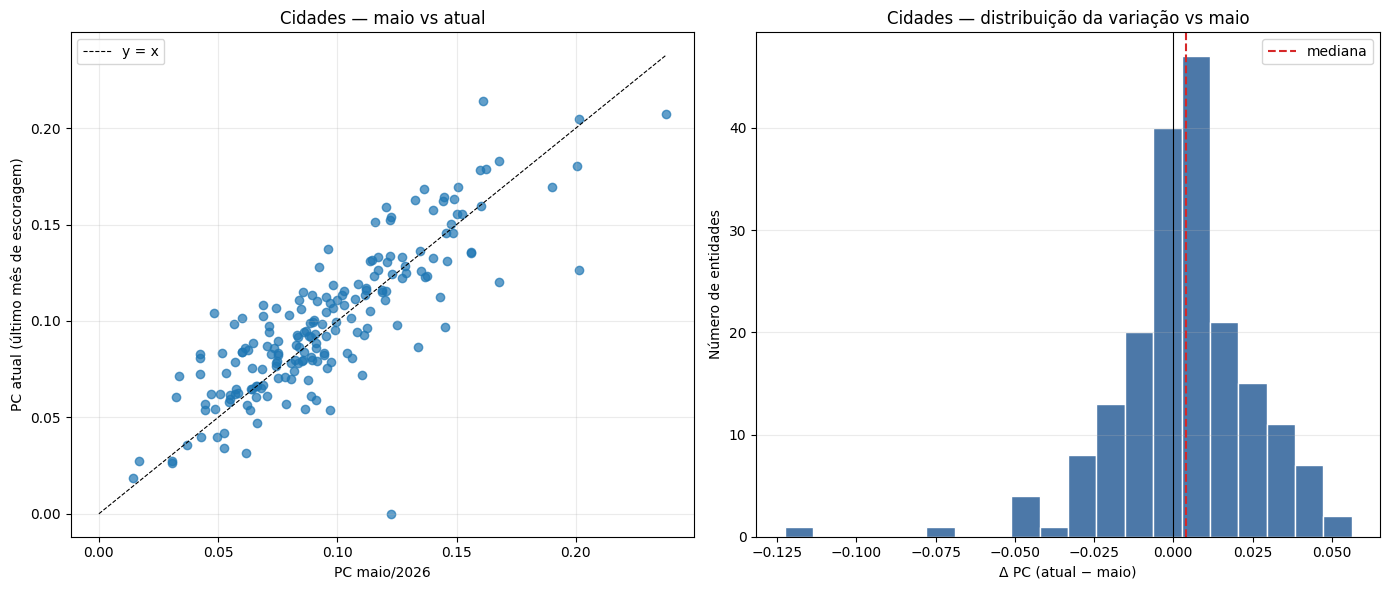

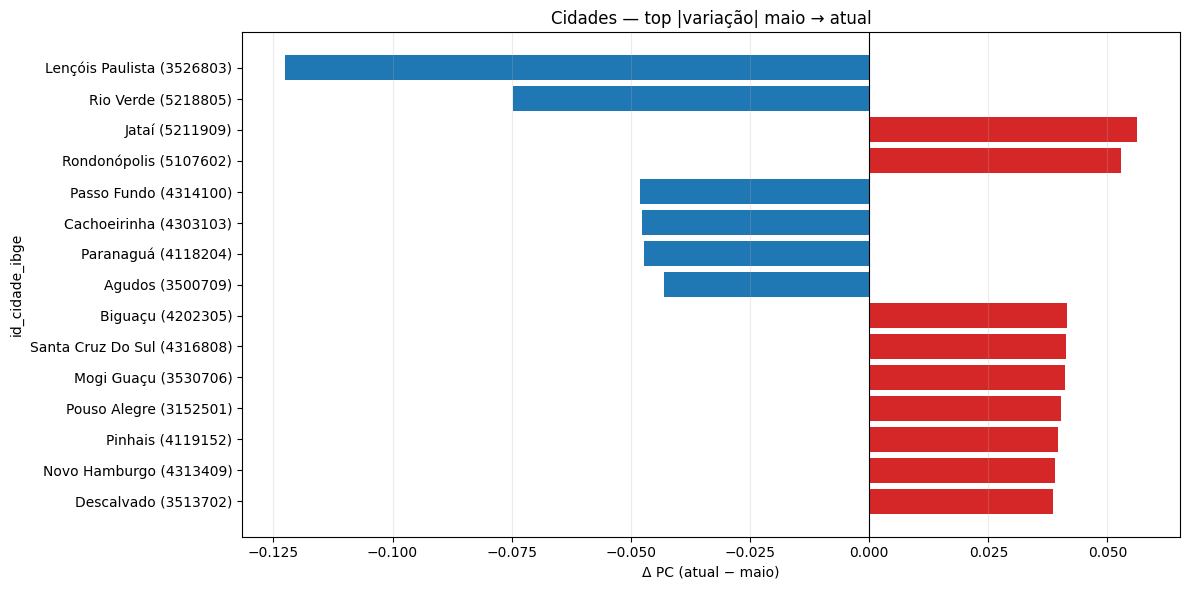

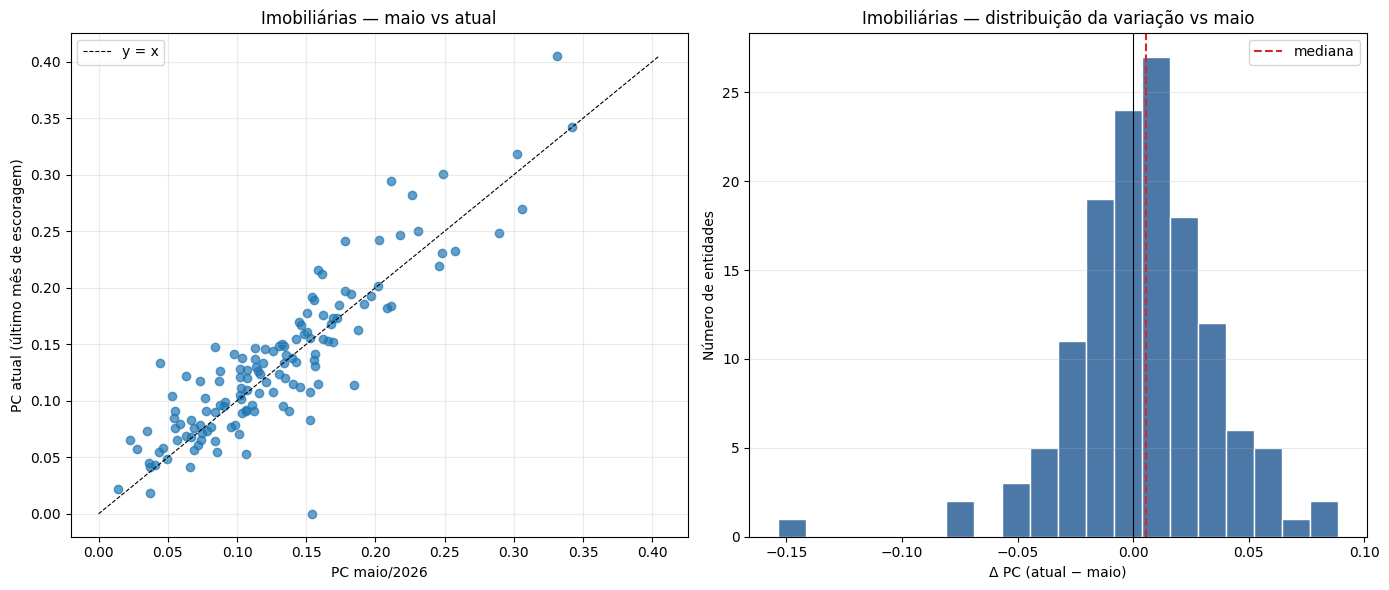

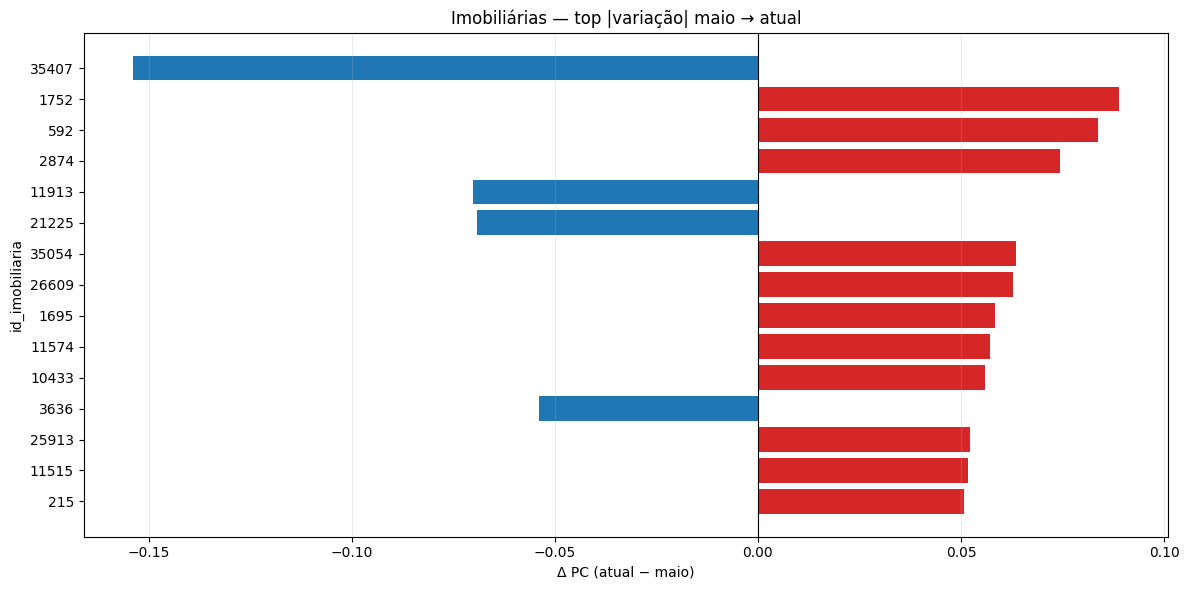

In [29]:
def plot_maio_vs_atual(cmp: pd.DataFrame, entity_col: str, title: str) -> None:
    both = cmp.dropna(subset=["pc_maio", "pc_atual"])
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(both["pc_maio"], both["pc_atual"], alpha=0.7)
    lims = [
        min(both["pc_maio"].min(), both["pc_atual"].min()),
        max(both["pc_maio"].max(), both["pc_atual"].max()),
    ]
    ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--", label="y = x")
    ax.set_xlabel("PC maio/2026")
    ax.set_ylabel("PC atual (último mês de escoragem)")
    ax.set_title(f"{title} — maio vs atual")
    ax.legend()
    ax.grid(alpha=0.25)

    ax = axes[1]
    colors = np.where(both["delta_maio_atual"] >= 0, "#d62728", "#1f77b4")
    ax.hist(both["delta_maio_atual"], bins=20, color="#4c78a8", edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(both["delta_maio_atual"].median(), color="#d62728", linestyle="--", label="mediana")
    ax.set_xlabel("Δ PC (atual − maio)")
    ax.set_ylabel("Número de entidades")
    ax.set_title(f"{title} — distribuição da variação vs maio")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    top = both.reindex(both["abs_delta"].nlargest(15).index)
    fig, ax = plt.subplots(figsize=(12, 6))
    bar_colors = np.where(top["delta_maio_atual"] >= 0, "#d62728", "#1f77b4")
    labels = top[entity_col].astype(str)
    if "imovel_cidade" in top.columns:
        labels = top["imovel_cidade"].fillna(top[entity_col].astype(str)) + " (" + top[entity_col].astype(str) + ")"
    ax.barh(labels[::-1], top["delta_maio_atual"][::-1], color=bar_colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Δ PC (atual − maio)")
    ax.set_ylabel(entity_col)
    ax.set_title(f"{title} — top |variação| maio → atual")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_maio_vs_atual(city_cmp, CITY_COL, "Cidades")
plot_maio_vs_atual(agency_cmp, AGENCY_COL, "Imobiliárias")


## Funil por cidade e imobiliária

Agregação de `df_funil` em `df_funil_city` e `df_funil_agency` (leads, propostas, aprovações, ativações e mix BLEND3/BLEND4). O funil cobre jul–ago/2026; o PC compara maio/2026 com a escoragem desse mesmo recorte. O volume entra como peso de relevância na análise de variação.


In [30]:
df_funil_agency = (
    df_funil.groupby([AGENCY_COL, "mes_referencia"], dropna=False)
    .agg(
        n_leads=("lead_elegivel", "sum"),
        n_propostas=("proposta_iniciada", "sum"),
        n_propostas_aprovadas=("proposta_aprovada", "sum"),
        n_propostas_ativadas=("proposta_ativada", "sum"),
        model_blend3=(MODEL_COL, lambda x: (x == "BLEND3").sum()),
        model_blend4=(MODEL_COL, lambda x: (x == "BLEND4").sum()),
    )
    .reset_index()
)
df_funil_agency


,id_imobiliaria,mes_referencia,n_leads,n_propostas,n_propostas_aprovadas,n_propostas_ativadas,model_blend3,model_blend4
0,25,2026-07-01,14,11,10,9,15,1
1,25,2026-08-01,9,9,8,5,7,2
2,30,2026-07-01,46,20,19,18,50,10
3,30,2026-08-01,19,11,10,9,16,13
4,35,2026-08-01,2,2,1,1,0,2
...,...,...,...,...,...,...,...,...
14412,58352,2026-08-01,1,1,0,0,2,2
14413,58353,2026-07-01,1,1,1,1,0,1
14414,58353,2026-08-01,1,1,1,1,0,1
14415,58356,2026-08-01,3,3,2,0,1,2


In [31]:
df_funil_city = (
    df_funil.groupby([CITY_COL, "mes_referencia"], dropna=False)
    .agg(
        n_leads=("lead_elegivel", "sum"),
        n_propostas=("proposta_iniciada", "sum"),
        n_propostas_aprovadas=("proposta_aprovada", "sum"),
        n_propostas_ativadas=("proposta_ativada", "sum"),
        model_blend3=(MODEL_COL, lambda x: (x == "BLEND3").sum()),
        model_blend4=(MODEL_COL, lambda x: (x == "BLEND4").sum()),
    )
    .reset_index()
)
df_funil_city


,id_cidade_ibge,mes_referencia,n_leads,n_propostas,n_propostas_aprovadas,n_propostas_ativadas,model_blend3,model_blend4
0,1100023,2026-07-01,6,1,1,1,6,0
1,1100023,2026-08-01,4,0,0,0,2,2
2,1100049,2026-07-01,64,5,5,3,61,7
3,1100049,2026-08-01,33,1,1,1,30,11
4,1100122,2026-07-01,18,14,13,10,19,4
...,...,...,...,...,...,...,...,...
1719,5221601,2026-08-01,2,1,0,0,2,0
1720,5221858,2026-07-01,15,8,8,4,23,3
1721,5221858,2026-08-01,4,1,1,0,2,3
1722,5300108,2026-07-01,1059,575,462,375,1155,187


## Análise de variação e concentração (PC × Funil)

Busca cidades e imobiliárias com alta variação de PC **maio → atual** (e entre jul e ago na escoragem) e verifica se essa variação está concentrada em entidades com volume relevante no funil.

- **Alta variação**: `|Δ maio→atual|` no p90 **ou** `max |Δ período|` no p90, entre entidades com maio e atual preenchidos.
- **Alto volume**: `n_leads` no p75 das entidades que aparecem no funil.
- **Impacto**: `|Δ maio→atual| × volume` — prioriza quem moveu o PC desde maio e também pesa no funil.
- Entidades pequenas com salto grande de PC (ruído amostral) caem no quadrante de baixo volume.


In [32]:
def _month_key(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, errors="coerce").dt.strftime("%Y-%m-%d")


def _entity_key(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").astype("Int64")


def variation_profile(pc_wide: pd.DataFrame, mom: pd.DataFrame, entity_col: str) -> pd.DataFrame:
    """PC level, range, std and period-over-period stats per entity."""
    pc = pc_wide.copy()
    mom_aligned = mom.reindex(pc.index)
    first = pc.apply(lambda r: r.dropna().iloc[0] if r.notna().any() else np.nan, axis=1)
    last = pc.apply(lambda r: r.dropna().iloc[-1] if r.notna().any() else np.nan, axis=1)
    current_cols = [c for c in pc.columns if c != MAY_PERIOD]
    pc_maio = pc[MAY_PERIOD] if MAY_PERIOD in pc.columns else pd.Series(np.nan, index=pc.index)
    pc_atual = (
        pc[current_cols].apply(lambda r: r.dropna().iloc[-1] if r.notna().any() else np.nan, axis=1)
        if current_cols else pd.Series(np.nan, index=pc.index)
    )
    out = pd.DataFrame({
        entity_col: pc.index,
        "n_safras": pc.notna().sum(axis=1).to_numpy(),
        "pc_first": first.to_numpy(),
        "pc_last": last.to_numpy(),
        "pc_maio": pc_maio.to_numpy(),
        "pc_atual": pc_atual.to_numpy(),
        "pc_mean": pc.mean(axis=1).to_numpy(),
        "pc_std": pc.std(axis=1, ddof=0).to_numpy(),
        "pc_range": (pc.max(axis=1) - pc.min(axis=1)).to_numpy(),
        "delta_net": (last - first).to_numpy(),
        "delta_maio_atual": (pc_atual - pc_maio).to_numpy(),
        "max_abs_mom": mom_aligned.abs().max(axis=1).to_numpy(),
        "max_mom": mom_aligned.max(axis=1).to_numpy(),
        "min_mom": mom_aligned.min(axis=1).to_numpy(),
        "n_mov_2pp": (mom_aligned.abs() >= 0.02).sum(axis=1).to_numpy(),
        "entrou": (pc_maio.isna() & pc_atual.notna()).to_numpy(),
        "saiu": (pc_maio.notna() & pc_atual.isna()).to_numpy(),
    })
    out["last_mom"] = mom_aligned[mom_aligned.columns[-1]].to_numpy() if len(mom_aligned.columns) else np.nan
    out["last_mom_periodo"] = mom_aligned.columns[-1] if len(mom_aligned.columns) else None
    out[entity_col] = _entity_key(out[entity_col])
    return out.reset_index(drop=True)


def aggregate_funnel(df: pd.DataFrame, entity_col: str) -> pd.DataFrame:
    """Total and latest-month funnel metrics per entity."""
    aux = df.copy()
    aux[entity_col] = _entity_key(aux[entity_col])
    aux["mes_referencia"] = _month_key(aux["mes_referencia"])
    aux = aux.dropna(subset=[entity_col])

    totals = aux.groupby(entity_col, as_index=False).agg(
        n_leads=("n_leads", "sum"),
        n_propostas=("n_propostas", "sum"),
        n_aprovadas=("n_propostas_aprovadas", "sum"),
        n_ativadas=("n_propostas_ativadas", "sum"),
        n_blend3=("model_blend3", "sum"),
        n_blend4=("model_blend4", "sum"),
        n_meses_funil=("mes_referencia", "nunique"),
    )
    latest_mes = aux["mes_referencia"].max()
    latest = (
        aux.loc[
            aux["mes_referencia"] == latest_mes,
            [entity_col, "n_leads", "n_propostas", "n_propostas_aprovadas", "n_propostas_ativadas", "model_blend4"],
        ]
        .rename(columns={
            "n_leads": "n_leads_ultimo_mes",
            "n_propostas": "n_propostas_ultimo_mes",
            "n_propostas_aprovadas": "n_aprovadas_ultimo_mes",
            "n_propostas_ativadas": "n_ativadas_ultimo_mes",
            "model_blend4": "n_blend4_ultimo_mes",
        })
    )
    out = totals.merge(latest, on=entity_col, how="left")
    out["tx_proposta"] = out["n_propostas"] / out["n_leads"].replace(0, np.nan)
    out["tx_aprovacao"] = out["n_aprovadas"] / out["n_propostas"].replace(0, np.nan)
    out["tx_ativacao"] = out["n_ativadas"] / out["n_aprovadas"].replace(0, np.nan)
    out["n_model"] = out["n_blend3"] + out["n_blend4"]
    out["share_blend4"] = out["n_blend4"] / out["n_model"].replace(0, np.nan)
    return out


def merge_pc_funnel(pc_profile: pd.DataFrame, funil_profile: pd.DataFrame, entity_col: str):
    """Join PC variation with funnel volume and classify quadrants."""
    full = pc_profile.merge(funil_profile, on=entity_col, how="left")
    vol_cols = [
        "n_leads", "n_propostas", "n_aprovadas", "n_ativadas",
        "n_blend3", "n_blend4", "n_model",
        "n_leads_ultimo_mes", "n_propostas_ultimo_mes",
        "n_aprovadas_ultimo_mes", "n_ativadas_ultimo_mes", "n_blend4_ultimo_mes",
    ]
    for col in vol_cols:
        if col in full.columns:
            full[col] = full[col].fillna(0)

    eligible = full["pc_maio"].notna() & full["pc_atual"].notna()
    p90_delta = full.loc[eligible, "delta_maio_atual"].abs().quantile(0.90)
    p90_mom = full.loc[eligible, "max_abs_mom"].quantile(0.90)
    full["high_var"] = eligible & (
        (full["delta_maio_atual"].abs() >= p90_delta) | (full["max_abs_mom"] >= p90_mom)
    )

    has_vol = full["n_leads"] > 0
    p75_leads = full.loc[has_vol, "n_leads"].quantile(0.75) if has_vol.any() else np.nan
    full["high_vol"] = has_vol & (full["n_leads"] >= p75_leads)

    full["quadrante"] = np.select(
        [
            full["high_var"] & full["high_vol"],
            full["high_var"] & ~full["high_vol"],
            ~full["high_var"] & full["high_vol"],
        ],
        [
            "alta variação + alto volume",
            "alta variação + baixo volume",
            "baixa variação + alto volume",
        ],
        default="baixa variação + baixo volume",
    )
    full["impacto"] = full["delta_maio_atual"].abs().fillna(0) * full["n_leads"]
    full["impacto_recente"] = full["last_mom"].abs().fillna(0) * full["n_leads_ultimo_mes"]
    cuts = {
        "p90_abs_delta_maio_atual": float(p90_delta) if pd.notna(p90_delta) else np.nan,
        "p90_max_abs_mom": float(p90_mom) if pd.notna(p90_mom) else np.nan,
        "p75_n_leads": float(p75_leads) if pd.notna(p75_leads) else np.nan,
    }
    return full, cuts


def concentration_by_quadrant(df: pd.DataFrame) -> pd.DataFrame:
    total_leads = df["n_leads"].sum()
    total_ativ = df["n_ativadas"].sum()
    out = (
        df.groupby("quadrante", as_index=False)
        .agg(
            n_entidades=("quadrante", "size"),
            n_leads=("n_leads", "sum"),
            n_ativadas=("n_ativadas", "sum"),
            n_high_var=("high_var", "sum"),
        )
        .sort_values("n_leads", ascending=False)
    )
    out["share_leads"] = out["n_leads"] / total_leads if total_leads else np.nan
    out["share_ativadas"] = out["n_ativadas"] / total_ativ if total_ativ else np.nan
    return out


SHOW_COLS = [
    "pc_maio", "pc_atual", "delta_maio_atual", "pc_std", "pc_range",
    "max_abs_mom", "last_mom", "n_mov_2pp",
    "n_leads", "n_ativadas", "n_leads_ultimo_mes",
    "tx_proposta", "tx_aprovacao", "tx_ativacao", "share_blend4",
    "impacto", "impacto_recente", "quadrante", "entrou", "saiu",
]


def show_priority_tables(full: pd.DataFrame, entity_col: str, title: str, n: int = 15) -> None:
    fmt = {
        "pc_maio": "{:.3f}", "pc_atual": "{:.3f}", "delta_maio_atual": "{:+.3f}",
        "pc_std": "{:.3f}", "pc_range": "{:.3f}",
        "max_abs_mom": "{:.3f}", "last_mom": "{:+.3f}",
        "tx_proposta": "{:.1%}", "tx_aprovacao": "{:.1%}",
        "tx_ativacao": "{:.1%}", "share_blend4": "{:.1%}",
        "impacto": "{:.2f}", "impacto_recente": "{:.2f}",
        "n_leads": "{:.0f}", "n_ativadas": "{:.0f}", "n_leads_ultimo_mes": "{:.0f}",
    }
    show_cols = [c for c in SHOW_COLS if c in full.columns]
    extra = [c for c in ["imovel_cidade", "imovel_uf"] if c in full.columns]
    table_cols = extra + show_cols

    min_leads = full.loc[full["n_leads"] > 0, "n_leads"].quantile(0.50) if (full["n_leads"] > 0).any() else 0
    min_leads = max(float(min_leads), 10)

    priority = full[full["quadrante"] == "alta variação + alto volume"].sort_values("impacto", ascending=False)
    if priority.empty:
        priority = full.sort_values("impacto", ascending=False).head(n)

    recent = (
        full.loc[full["n_leads"] >= min_leads]
        .dropna(subset=["delta_maio_atual"])
        .sort_values("impacto", ascending=False)
    )
    recent_up = recent.nlargest(n, "delta_maio_atual")
    recent_down = recent.nsmallest(n, "delta_maio_atual")

    print(f"{title} — cortes e cobertura")
    print(
        f"  entidades={len(full):,} | alta variação={int(full['high_var'].sum()):,} | "
        f"alto volume={int(full['high_vol'].sum()):,} | "
        f"prioritárias={int((full['quadrante']=='alta variação + alto volume').sum()):,}"
    )
    display(concentration_by_quadrant(full).style.format({
        "share_leads": "{:.1%}", "share_ativadas": "{:.1%}",
        "n_leads": "{:.0f}", "n_ativadas": "{:.0f}",
    }))

    print(f"{title} — prioritárias (alta variação + alto volume), top {n} por impacto |Δ maio→atual| × leads")
    display(priority.head(n).set_index(entity_col)[table_cols].style.format(fmt, na_rep="—"))

    print(f"{title} — maiores altas vs maio (volume ≥ {min_leads:.0f} leads)")
    display(recent_up.head(n).set_index(entity_col)[table_cols].style.format(fmt, na_rep="—"))

    print(f"{title} — maiores quedas vs maio (volume ≥ {min_leads:.0f} leads)")
    display(recent_down.head(n).set_index(entity_col)[table_cols].style.format(fmt, na_rep="—"))


def plot_variation_analysis(
    full: pd.DataFrame,
    pc_wide: pd.DataFrame,
    mom: pd.DataFrame,
    entity_col: str,
    title: str,
    n_top: int = 12,
) -> None:
    palette = {
        "alta variação + alto volume": "#d62728",
        "alta variação + baixo volume": "#ff7f0e",
        "baixa variação + alto volume": "#1f77b4",
        "baixa variação + baixo volume": "#c7c7c7",
    }
    plot_df = full.copy()
    plot_df["_leads_plot"] = plot_df["n_leads"].clip(lower=1)

    fig, ax = plt.subplots(figsize=(12, 6))
    for quad, grp in plot_df.groupby("quadrante"):
        ax.scatter(
            grp["_leads_plot"],
            grp["delta_maio_atual"].abs(),
            s=np.sqrt(grp["n_ativadas"].clip(lower=0) + 1) * 8,
            alpha=0.7,
            label=quad,
            c=palette.get(quad, "#333333"),
        )
    ax.set_xscale("log")
    ax.set_xlabel("Leads no funil (jul–ago, log)")
    ax.set_ylabel("|Δ PC| maio → atual (pp)")
    ax.set_title(f"{title} — variação do PC vs volume do funil")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    top = full.sort_values("impacto", ascending=False).head(n_top)
    top_ids = pd.to_numeric(top[entity_col], errors="coerce").dropna().astype(int)
    mom_plot = mom.copy()
    mom_plot.index = pd.to_numeric(mom_plot.index, errors="coerce")
    pc_plot = pc_wide.copy()
    pc_plot.index = pd.to_numeric(pc_plot.index, errors="coerce")
    hm = mom_plot.reindex(top_ids).dropna(how="all")
    if not hm.empty:
        fig, ax = plt.subplots(figsize=(12, max(4, 0.4 * len(hm))))
        sns.heatmap(hm, center=0, cmap="RdBu_r", ax=ax, cbar_kws={"label": "Δ PC (pp)"})
        ax.set_title(f"{title} — heatmap da variação (maio→jul, jul→ago) das entidades de maior impacto")
        ax.set_ylabel(entity_col)
        plt.tight_layout()
        plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    for eid in top_ids.head(n_top):
        if eid in pc_plot.index:
            ax.plot(pc_plot.columns, pc_plot.loc[eid], marker="o", label=str(int(eid)))
    ax.set_title(f"{title} — trajetória do PC (top impacto)")
    ax.set_xlabel("Período")
    ax.set_ylabel("PC 4+ categorias")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    recent = full.dropna(subset=["delta_maio_atual"]).nlargest(n_top, "impacto")
    if not recent.empty:
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = np.where(recent["delta_maio_atual"] >= 0, "#d62728", "#1f77b4")
        labels = recent[entity_col].astype(str)
        if "imovel_cidade" in recent.columns:
            labels = (
                recent["imovel_cidade"].fillna(recent[entity_col].astype(str))
                + " (" + recent[entity_col].astype(str) + ")"
            )
        ax.barh(labels[::-1], recent["delta_maio_atual"][::-1], color=colors[::-1])
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{title} — variação maio → atual ponderada por volume")
        ax.set_xlabel("Δ PC (atual − maio)")
        ax.set_ylabel(entity_col)
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()


city_var, city_cuts = merge_pc_funnel(
    variation_profile(city_pc_by_safra, city_pc_mom, CITY_COL),
    aggregate_funnel(df_funil_city, CITY_COL),
    CITY_COL,
)
city_var = city_var.merge(city_names, on=CITY_COL, how="left")

agency_var, agency_cuts = merge_pc_funnel(
    variation_profile(agency_pc_by_safra, agency_pc_mom, AGENCY_COL),
    aggregate_funnel(df_funil_agency, AGENCY_COL),
    AGENCY_COL,
)

print("Cortes — cidades:", {k: round(v, 4) if pd.notna(v) else None for k, v in city_cuts.items()})
print("Cortes — imobiliárias:", {k: round(v, 4) if pd.notna(v) else None for k, v in agency_cuts.items()})
print(f"Funil city meses: {sorted(df_funil_city['mes_referencia'].astype(str).unique())}")
print(f"Funil agency meses: {sorted(df_funil_agency['mes_referencia'].astype(str).unique())}")


Cortes — cidades: {'p90_abs_delta_maio_atual': 0.0336, 'p90_max_abs_mom': 0.0263, 'p75_n_leads': 557.0}
Cortes — imobiliárias: {'p90_abs_delta_maio_atual': 0.0512, 'p90_max_abs_mom': 0.0422, 'p75_n_leads': 105.0}
Funil city meses: ['2026-07-01', '2026-08-01']
Funil agency meses: ['2026-07-01', '2026-08-01']


### Cidades

Prioridade: alta variação de PC cidade **maio → atual** **e** volume relevante no funil. Em seguida, altas e quedas vs maio entre cidades com volume mínimo.


Cidades — cortes e cobertura
  entidades=218 | alta variação=27 | alto volume=55 | prioritárias=2


,quadrante,n_entidades,n_leads,n_ativadas,n_high_var,share_leads,share_ativadas
2,baixa variação + alto volume,53,66017,13927,0,65.9%,62.8%
3,baixa variação + baixo volume,138,28073,6895,0,28.0%,31.1%
1,alta variação + baixo volume,25,4816,1111,25,4.8%,5.0%
0,alta variação + alto volume,2,1263,240,2,1.3%,1.1%


Cidades — prioritárias (alta variação + alto volume), top 15 por impacto |Δ maio→atual| × leads


,imovel_cidade,imovel_uf,pc_maio,pc_atual,delta_maio_atual,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
id_cidade_ibge,,,,,,,,,,,,,,,,,,,,,,
4314100,Passo Fundo,RS,0.145,0.097,-0.048,0.020,0.048,0.033,-0.015,1,617,122,216,32.1%,73.2%,84.1%,25.1%,29.65,3.30,alta variação + alto volume,False,False
4313409,Novo Hamburgo,RS,0.120,0.159,+0.039,0.016,0.039,0.025,+0.014,1,646,118,224,33.9%,71.7%,75.2%,27.0%,25.23,3.14,alta variação + alto volume,False,False


Cidades — maiores altas vs maio (volume ≥ 217 leads)


,imovel_cidade,imovel_uf,pc_maio,pc_atual,delta_maio_atual,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
id_cidade_ibge,,,,,,,,,,,,,,,,,,,,,,
4316808,Santa Cruz Do Sul,RS,0.060,0.101,+0.041,0.017,0.041,0.023,+0.023,1,308,54,131,30.2%,77.4%,75.0%,30.6%,12.75,3.01,alta variação + baixo volume,False,False
3530706,Mogi Guaçu,SP,0.096,0.137,+0.041,0.018,0.041,0.032,+0.009,1,303,52,98,36.3%,66.4%,71.2%,27.9%,12.44,0.86,alta variação + baixo volume,False,False
3152501,Pouso Alegre,MG,0.043,0.083,+0.040,0.017,0.040,0.028,+0.028,1,508,127,143,40.9%,76.4%,79.9%,24.3%,20.46,3.96,alta variação + baixo volume,False,False
4313409,Novo Hamburgo,RS,0.120,0.159,+0.039,0.016,0.039,0.025,+0.014,1,646,118,224,33.9%,71.7%,75.2%,27.0%,25.23,3.14,alta variação + alto volume,False,False
4320008,Sapucaia Do Sul,RS,0.116,0.151,+0.036,0.015,0.036,0.018,+0.018,0,224,63,67,54.0%,67.8%,76.8%,27.5%,8.00,1.20,alta variação + baixo volume,False,False
3510500,Caraguatatuba,SP,0.069,0.103,+0.034,0.014,0.034,0.017,+0.016,0,228,44,88,40.4%,67.4%,71.0%,28.9%,7.66,1.45,alta variação + baixo volume,False,False
4314407,Pelotas,RS,0.136,0.169,+0.032,0.013,0.032,0.022,+0.010,1,735,150,210,32.8%,79.7%,78.1%,25.3%,23.79,2.18,baixa variação + alto volume,False,False
3306305,Volta Redonda,RJ,0.052,0.083,+0.032,0.013,0.032,0.020,+0.012,0,399,89,115,39.6%,74.1%,76.1%,24.7%,12.70,1.37,baixa variação + baixo volume,False,False
4202909,Brusque,SC,0.122,0.153,+0.030,0.013,0.030,0.024,+0.007,1,607,105,262,29.2%,87.0%,68.2%,30.4%,18.48,1.77,baixa variação + alto volume,False,False


Cidades — maiores quedas vs maio (volume ≥ 217 leads)


,imovel_cidade,imovel_uf,pc_maio,pc_atual,delta_maio_atual,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
id_cidade_ibge,,,,,,,,,,,,,,,,,,,,,,
4314100,Passo Fundo,RS,0.145,0.097,-0.048,0.020,0.048,0.033,-0.015,1,617,122,216,32.1%,73.2%,84.1%,25.1%,29.65,3.30,alta variação + alto volume,False,False
4125506,São José Dos Pinhais,PR,0.078,0.057,-0.022,0.010,0.022,0.022,+0.000,1,490,97,193,41.8%,66.3%,71.3%,27.4%,10.60,0.00,baixa variação + baixo volume,False,False
3506508,Birigui,SP,0.104,0.083,-0.021,0.009,0.021,0.012,-0.012,0,664,145,198,44.1%,70.0%,70.7%,24.7%,13.83,2.30,baixa variação + alto volume,False,False
2933307,Vitória Da Conquista,BA,0.190,0.169,-0.021,0.011,0.026,0.026,+0.005,1,272,80,79,46.0%,81.6%,78.4%,24.6%,5.64,0.43,baixa variação + baixo volume,False,False
4300604,Alvorada,RS,0.156,0.135,-0.020,0.009,0.020,0.017,-0.003,0,231,60,78,45.5%,75.2%,75.9%,26.8%,4.73,0.26,baixa variação + baixo volume,False,False
4204202,Chapecó,SC,0.156,0.136,-0.020,0.009,0.020,0.016,-0.005,0,532,77,154,25.4%,74.8%,76.2%,22.7%,10.82,0.74,baixa variação + baixo volume,False,False
3538006,Pindamonhangaba,SP,0.096,0.075,-0.020,0.008,0.020,0.012,-0.012,0,344,88,112,47.4%,71.2%,75.9%,28.5%,6.99,1.36,baixa variação + baixo volume,False,False
3533908,Olímpia,SP,0.201,0.180,-0.020,0.008,0.020,0.012,-0.009,0,252,85,93,50.0%,87.3%,77.3%,28.2%,5.12,0.81,baixa variação + baixo volume,False,False
3507506,Botucatu,SP,0.111,0.093,-0.019,0.009,0.019,0.019,+0.000,0,638,173,212,44.5%,80.6%,75.5%,24.5%,11.85,0.00,baixa variação + alto volume,False,False


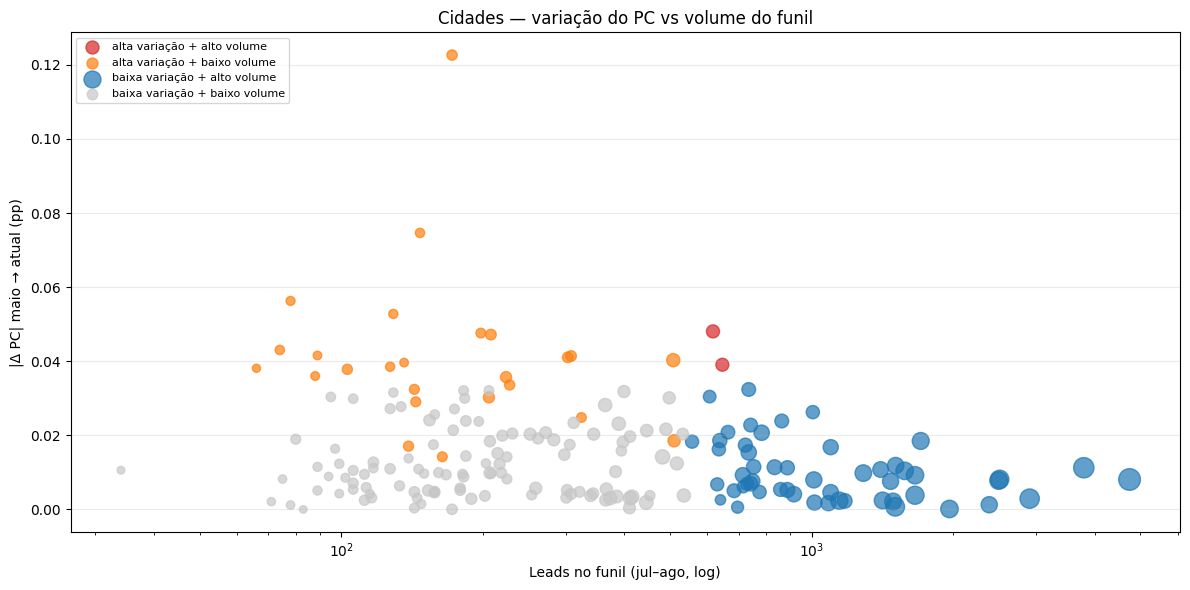

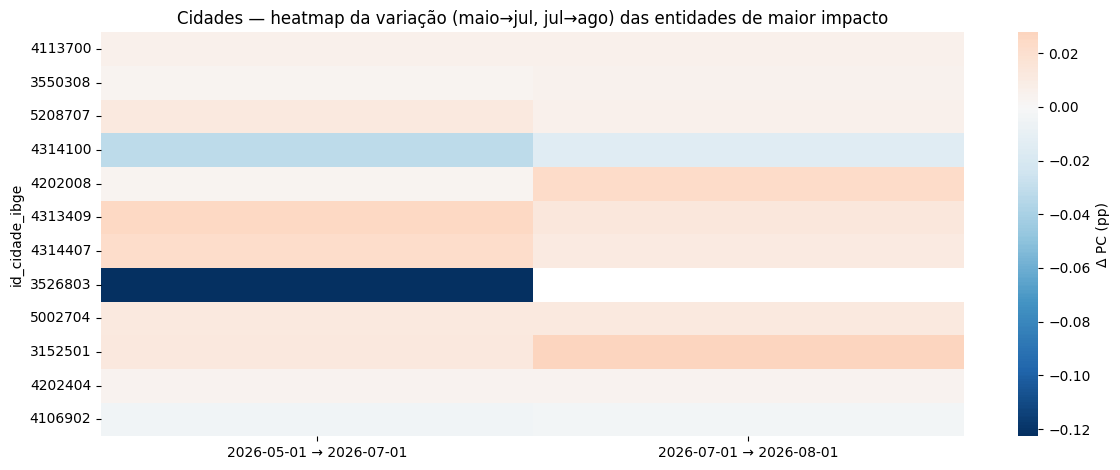

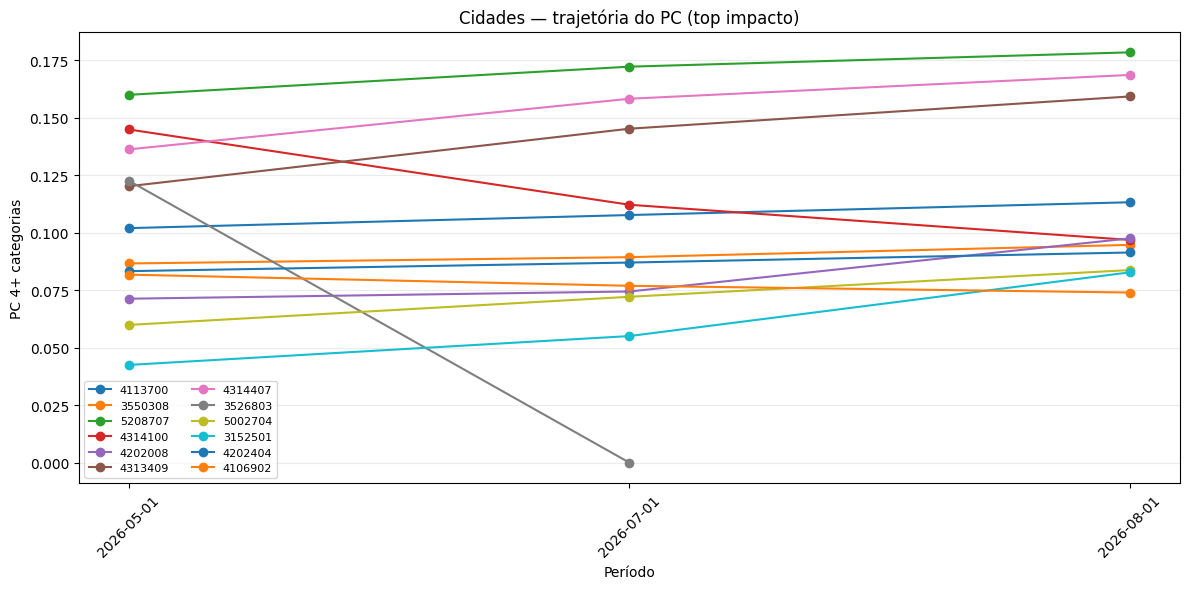

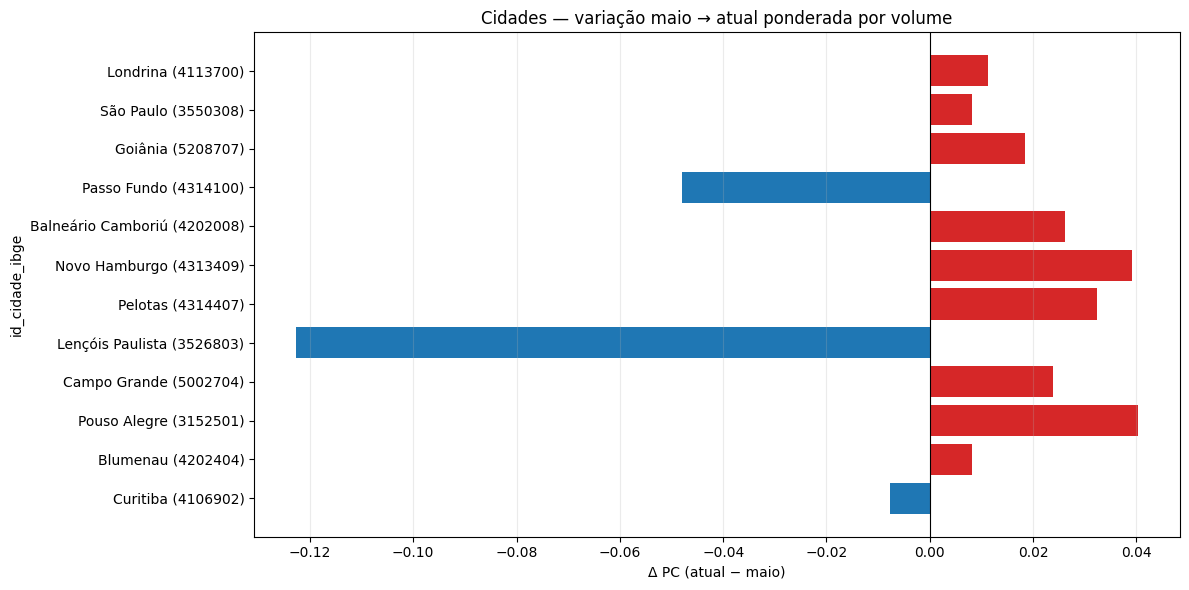

In [33]:
show_priority_tables(city_var, CITY_COL, "Cidades")
plot_variation_analysis(city_var, city_pc_by_safra, city_pc_mom, CITY_COL, "Cidades")


### Imobiliárias

Mesma lógica para o PC de imobiliária. Imobs com PC muito volátil e pouco lead tendem a ser ruído; o quadrante vermelho (alta variação + alto volume) é o que concentra risco operacional.


Imobiliárias — cortes e cobertura
  entidades=302 | alta variação=19 | alto volume=76 | prioritárias=8


,quadrante,n_entidades,n_leads,n_ativadas,n_high_var,share_leads,share_ativadas
2,baixa variação + alto volume,68,15169,3592,0,57.6%,54.7%
3,baixa variação + baixo volume,215,9001,2457,0,34.2%,37.4%
0,alta variação + alto volume,8,1398,234,8,5.3%,3.6%
1,alta variação + baixo volume,11,756,288,11,2.9%,4.4%


Imobiliárias — prioritárias (alta variação + alto volume), top 15 por impacto |Δ maio→atual| × leads


,pc_maio,pc_atual,delta_maio_atual,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
id_imobiliaria,,,,,,,,,,,,,,,,,,,,
3636,0.107,0.053,-0.054,0.024,0.054,0.048,-0.005,1,310,42,66,18.1%,80.4%,93.3%,22.3%,16.67,0.35,alta variação + alto volume,False,False
1752,0.044,0.133,+0.089,0.037,0.089,0.062,+0.027,2,141,16,41,24.1%,55.9%,84.2%,24.1%,12.53,1.12,alta variação + alto volume,False,False
35054,0.084,0.148,+0.064,0.026,0.064,0.036,+0.036,2,174,34,58,33.9%,66.1%,87.2%,24.3%,11.06,2.11,alta variação + alto volume,False,False
9118,0.306,0.270,-0.036,0.021,0.049,0.049,+0.013,1,284,39,127,30.3%,62.8%,72.2%,27.2%,10.23,1.63,alta variação + alto volume,False,False
11913,0.184,0.114,-0.070,0.033,0.071,0.071,+0.001,1,132,44,11,79.5%,73.3%,57.1%,9.1%,9.26,0.01,alta variação + alto volume,False,False
1695,0.063,0.121,+0.059,0.024,0.059,0.036,+0.022,2,124,11,46,12.1%,93.3%,78.6%,25.7%,7.25,1.02,alta variação + alto volume,False,False
448,0.138,0.091,-0.047,0.022,0.047,0.046,-0.000,1,120,26,54,45.0%,90.7%,53.1%,25.3%,5.59,0.03,alta variação + alto volume,False,False
4933,0.073,0.117,+0.044,0.021,0.044,0.044,+0.000,1,113,22,59,27.4%,93.5%,75.9%,33.2%,4.99,0.00,alta variação + alto volume,False,False


Imobiliárias — maiores altas vs maio (volume ≥ 62 leads)


,pc_maio,pc_atual,delta_maio_atual,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
id_imobiliaria,,,,,,,,,,,,,,,,,,,,
1752,0.044,0.133,+0.089,0.037,0.089,0.062,+0.027,2,141,16,41,24.1%,55.9%,84.2%,24.1%,12.53,1.12,alta variação + alto volume,False,False
592,0.211,0.295,+0.084,0.035,0.084,0.062,+0.062,2,81,37,29,74.1%,88.3%,69.8%,24.0%,6.77,1.79,alta variação + baixo volume,False,False
2874,0.331,0.405,+0.074,0.037,0.074,0.074,—,1,96,35,25,54.2%,94.2%,71.4%,22.7%,7.14,0.00,alta variação + baixo volume,False,False
35054,0.084,0.148,+0.064,0.026,0.064,0.036,+0.036,2,174,34,58,33.9%,66.1%,87.2%,24.3%,11.06,2.11,alta variação + alto volume,False,False
26609,0.178,0.241,+0.063,0.027,0.063,0.047,+0.016,1,91,25,29,48.4%,75.0%,75.8%,26.0%,5.72,0.47,alta variação + baixo volume,False,False
1695,0.063,0.121,+0.059,0.024,0.059,0.036,+0.022,2,124,11,46,12.1%,93.3%,78.6%,25.7%,7.25,1.02,alta variação + alto volume,False,False
10433,0.226,0.282,+0.056,0.025,0.056,0.048,+0.008,1,65,20,21,49.2%,81.2%,76.9%,29.7%,3.64,0.17,alta variação + baixo volume,False,False
25913,0.249,0.301,+0.052,0.022,0.052,0.036,+0.016,1,77,40,32,88.3%,94.1%,62.5%,25.0%,4.02,0.51,alta variação + baixo volume,False,False
11515,0.053,0.105,+0.052,0.021,0.052,0.034,+0.017,1,79,36,18,65.8%,76.9%,90.0%,17.0%,4.08,0.31,alta variação + baixo volume,False,False


Imobiliárias — maiores quedas vs maio (volume ≥ 62 leads)


,pc_maio,pc_atual,delta_maio_atual,pc_std,pc_range,max_abs_mom,last_mom,n_mov_2pp,n_leads,n_ativadas,n_leads_ultimo_mes,tx_proposta,tx_aprovacao,tx_ativacao,share_blend4,impacto,impacto_recente,quadrante,entrou,saiu
id_imobiliaria,,,,,,,,,,,,,,,,,,,,
35407,0.154,0.000,-0.154,0.077,0.154,0.154,—,1,76,23,27,46.1%,82.9%,79.3%,23.2%,11.69,0.00,alta variação + baixo volume,False,False
11913,0.184,0.114,-0.070,0.033,0.071,0.071,+0.001,1,132,44,11,79.5%,73.3%,57.1%,9.1%,9.26,0.01,alta variação + alto volume,False,False
21225,0.152,0.083,-0.069,0.028,0.069,0.039,-0.039,2,85,29,19,41.2%,85.7%,96.7%,26.6%,5.87,0.75,alta variação + baixo volume,False,False
3636,0.107,0.053,-0.054,0.024,0.054,0.048,-0.005,1,310,42,66,18.1%,80.4%,93.3%,22.3%,16.67,0.35,alta variação + alto volume,False,False
448,0.138,0.091,-0.047,0.022,0.047,0.046,-0.000,1,120,26,54,45.0%,90.7%,53.1%,25.3%,5.59,0.03,alta variação + alto volume,False,False
4249,0.289,0.248,-0.041,0.017,0.041,0.028,-0.028,1,75,40,22,65.3%,95.9%,85.1%,25.5%,3.07,0.61,baixa variação + baixo volume,False,False
993,0.133,0.096,-0.037,0.015,0.037,0.023,-0.014,1,135,36,29,34.1%,87.0%,90.0%,21.6%,5.04,0.40,baixa variação + alto volume,False,False
9118,0.306,0.270,-0.036,0.021,0.049,0.049,+0.013,1,284,39,127,30.3%,62.8%,72.2%,27.2%,10.23,1.63,alta variação + alto volume,False,False
406,0.145,0.112,-0.033,0.016,0.036,0.036,+0.003,1,105,45,35,52.4%,89.1%,91.8%,24.4%,3.51,0.10,baixa variação + alto volume,False,False


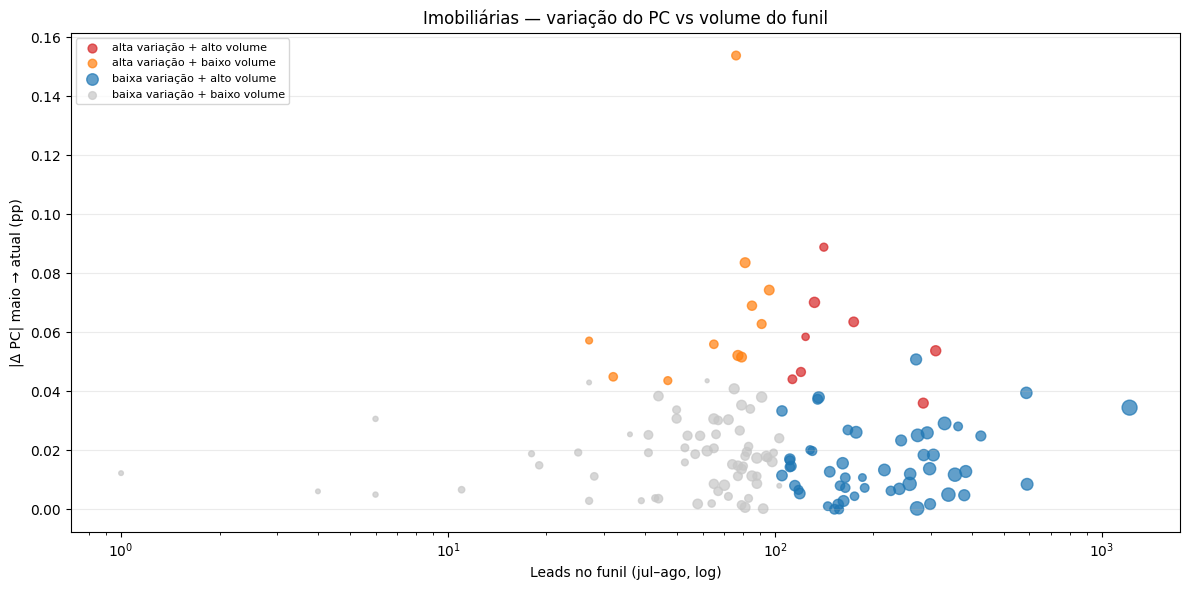

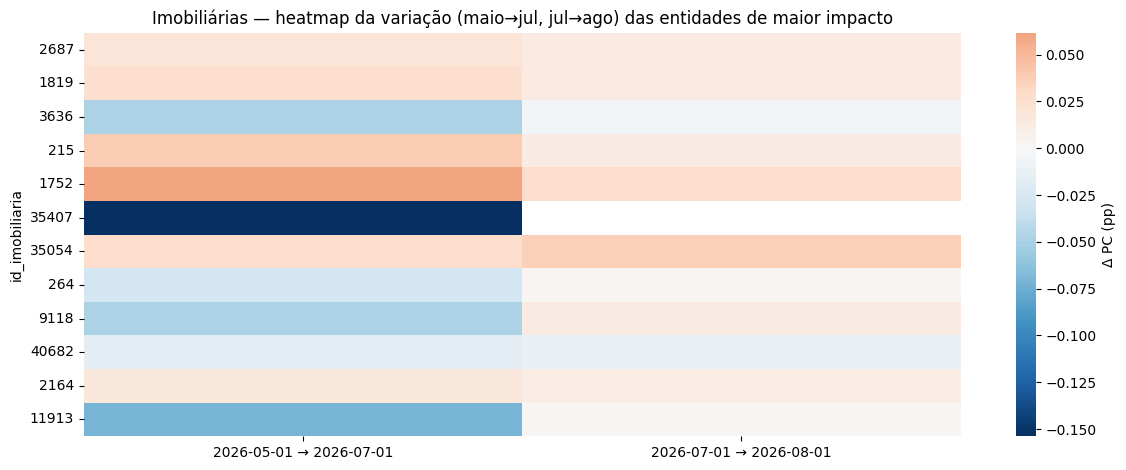

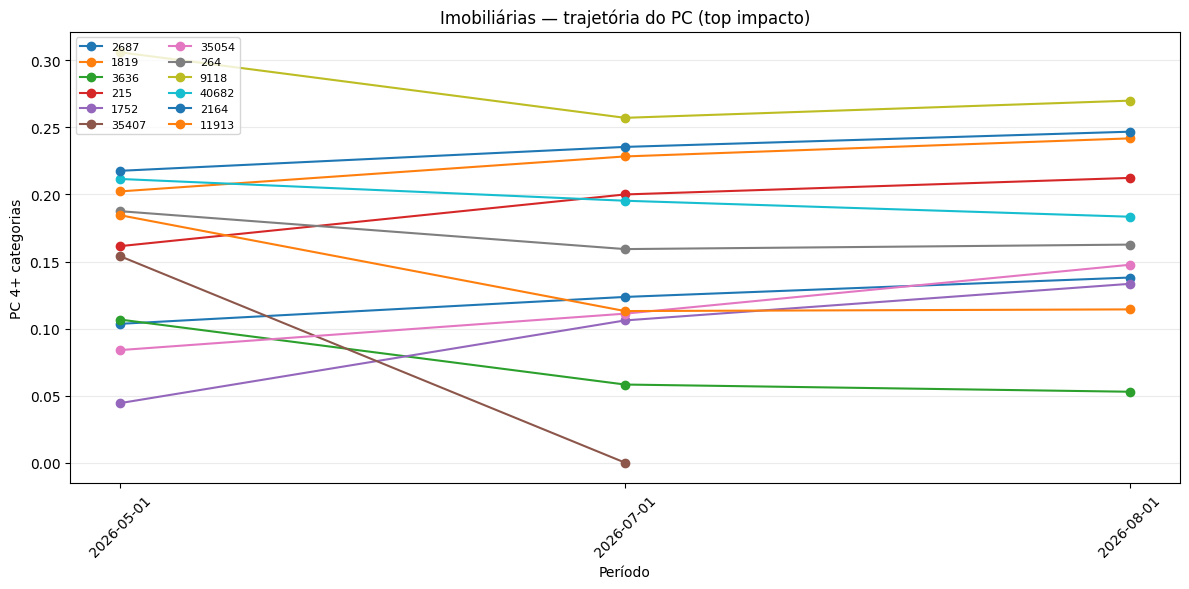

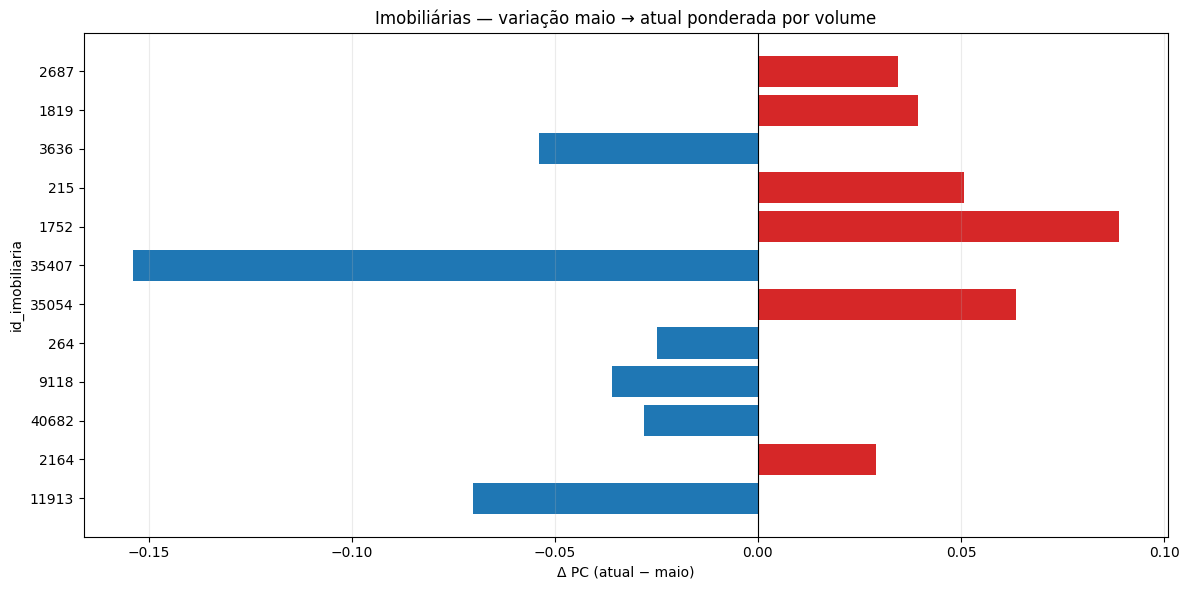

In [34]:
show_priority_tables(agency_var, AGENCY_COL, "Imobiliárias")
plot_variation_analysis(agency_var, agency_pc_by_safra, agency_pc_mom, AGENCY_COL, "Imobiliárias")


### Concentração comparada

Quanto do funil (leads e ativações) está nas entidades de alta variação de PC. Se a fatia for grande, a instabilidade do PC não é pontual — está concentrada em players que movem o mix. Também lista quem saiu do universo de 100+ contratos desde maio e ainda tem volume.


In [35]:
def high_var_share(df: pd.DataFrame, label: str) -> pd.Series:
    high = df["high_var"]
    prio = df["quadrante"] == "alta variação + alto volume"
    leads = df["n_leads"].sum()
    ativ = df["n_ativadas"].sum()
    top10 = df.nlargest(10, "impacto")
    return pd.Series({
        "universo": label,
        "n_entidades": len(df),
        "n_alta_var": int(high.sum()),
        "n_prioritarias": int(prio.sum()),
        "share_entidades_alta_var": high.mean(),
        "share_leads_alta_var": df.loc[high, "n_leads"].sum() / leads if leads else np.nan,
        "share_ativadas_alta_var": df.loc[high, "n_ativadas"].sum() / ativ if ativ else np.nan,
        "share_leads_prioritario": df.loc[prio, "n_leads"].sum() / leads if leads else np.nan,
        "share_ativadas_prioritario": df.loc[prio, "n_ativadas"].sum() / ativ if ativ else np.nan,
        "share_leads_top10_impacto": top10["n_leads"].sum() / leads if leads else np.nan,
        "share_ativadas_top10_impacto": top10["n_ativadas"].sum() / ativ if ativ else np.nan,
        "n_entrou": int(df["entrou"].sum()),
        "n_saiu": int(df["saiu"].sum()),
        "leads_entrou": df.loc[df["entrou"], "n_leads"].sum(),
        "leads_saiu": df.loc[df["saiu"], "n_leads"].sum(),
    })


conc_pc_funil = pd.DataFrame([
    high_var_share(city_var, "Cidades"),
    high_var_share(agency_var, "Imobiliárias"),
])
pct_cols = [c for c in conc_pc_funil.columns if c.startswith("share_")]
display(
    conc_pc_funil.set_index("universo").style.format(
        {c: "{:.1%}" for c in pct_cols} | {"leads_entrou": "{:.0f}", "leads_saiu": "{:.0f}"}
    )
)

print("Cidades que saíram da base de PC (tinham maio e não têm atual) e ainda têm volume no funil")
city_out_cols = ["imovel_cidade", "imovel_uf", "pc_maio", "pc_atual", "n_leads", "n_ativadas", "last_mom"]
display(
    city_var.loc[city_var["saiu"] & (city_var["n_leads"] > 0)]
    .sort_values("n_leads", ascending=False)
    .set_index(CITY_COL)[city_out_cols]
    .head(15)
)
print("Imobiliárias que saíram da base de PC (tinham maio e não têm atual) e ainda têm volume no funil")
display(
    agency_var.loc[agency_var["saiu"] & (agency_var["n_leads"] > 0)]
    .sort_values("n_leads", ascending=False)
    .set_index(AGENCY_COL)[["pc_maio", "pc_atual", "n_leads", "n_ativadas", "last_mom"]]
    .head(15)
)

print("Cidades que entraram na base de PC (sem maio e com atual) e têm volume no funil")
display(
    city_var.loc[city_var["entrou"] & (city_var["n_leads"] > 0)]
    .sort_values("n_leads", ascending=False)
    .set_index(CITY_COL)[city_out_cols]
    .head(15)
)
print("Imobiliárias que entraram na base de PC (sem maio e com atual) e têm volume no funil")
display(
    agency_var.loc[agency_var["entrou"] & (agency_var["n_leads"] > 0)]
    .sort_values("n_leads", ascending=False)
    .set_index(AGENCY_COL)[["pc_maio", "pc_atual", "n_leads", "n_ativadas", "last_mom"]]
    .head(15)
)


,n_entidades,n_alta_var,n_prioritarias,share_entidades_alta_var,share_leads_alta_var,share_ativadas_alta_var,share_leads_prioritario,share_ativadas_prioritario,share_leads_top10_impacto,share_ativadas_top10_impacto,n_entrou,n_saiu,leads_entrou,leads_saiu
universo,,,,,,,,,,,,,,
Cidades,218,27,2,12.4%,6.1%,6.1%,1.3%,1.1%,14.8%,12.8%,26,1,2767,49
Imobiliárias,302,19,8,6.3%,8.2%,7.9%,5.3%,3.6%,14.6%,8.4%,157,9,6777,692


Cidades que saíram da base de PC (tinham maio e não têm atual) e ainda têm volume no funil


,imovel_cidade,imovel_uf,pc_maio,pc_atual,n_leads,n_ativadas,last_mom
id_cidade_ibge,,,,,,,
4321600,Tramandaí,RS,0.04902,NaN,49,12,NaN


Imobiliárias que saíram da base de PC (tinham maio e não têm atual) e ainda têm volume no funil


,pc_maio,pc_atual,n_leads,n_ativadas,last_mom
id_imobiliaria,,,,,
2648,0.027523,NaN,174,67,NaN
902,0.182609,NaN,167,35,NaN
3552,0.099099,NaN,149,24,NaN
6882,0.214286,NaN,83,21,NaN
453,0.078261,NaN,60,32,NaN
9706,0.000000,NaN,36,0,NaN
12480,0.145631,NaN,22,8,NaN
12012,0.121739,NaN,1,0,NaN


Cidades que entraram na base de PC (sem maio e com atual) e têm volume no funil


,imovel_cidade,imovel_uf,pc_maio,pc_atual,n_leads,n_ativadas,last_mom
id_cidade_ibge,,,,,,,
3536505,Paulínia,SP,NaN,0.000000,526,14,NaN
3530607,Mogi Das Cruzes,SP,NaN,0.086538,299,76,0.000000
4213500,Porto Belo,SC,NaN,0.000000,207,21,NaN
3541000,Praia Grande,SP,NaN,0.000000,196,38,NaN
5107909,Sinop,MT,NaN,0.026316,180,22,-0.010721
4100400,Almirante Tamandaré,PR,NaN,0.000000,175,30,NaN
2403251,Parnamirim,RN,NaN,0.085714,137,26,0.008044
3301702,Duque De Caxias,RJ,NaN,0.075472,121,24,0.000705
3557006,Votorantim,SP,NaN,0.000000,109,20,NaN


Imobiliárias que entraram na base de PC (sem maio e com atual) e têm volume no funil


,pc_maio,pc_atual,n_leads,n_ativadas,last_mom
id_imobiliaria,,,,,
51620,NaN,0.000000,374,107,NaN
734,NaN,0.000000,192,15,NaN
39383,NaN,0.000000,165,37,NaN
1156,NaN,0.000000,150,21,NaN
356,NaN,0.000000,143,47,NaN
42979,NaN,0.000000,137,27,NaN
14783,NaN,0.000000,131,21,NaN
1876,NaN,0.000000,131,30,NaN
19244,NaN,0.000000,119,6,NaN


## Análise Transições

In [36]:
df_blend3 = pd.read_parquet(ANALYTICS_DIR / "df_blend3_simulacao_final.parquet")
df_blend4 = pd.read_parquet(ANALYTICS_DIR / "df_blend4_simulacao_final.parquet")

A simulação é *ceteris paribus*: `rating_manual_*_prod` usa o PC cidade da escoragem original e `rating_manual_*_city` troca **somente** `city_pc4_mais_100_contratos__pc_categorias` pelo snapshot de maio/2026. As demais variáveis do modelo (BVS, Serasa, PC imobiliária, renda, restrições, flags) ficam iguais.

O rating **não** é função só do score Blend. Há porteiras de BVS:

- **BLEND3**: só entra no modelo se `435 ≤ SCORE_BVS < 620`. Fora dessa faixa o rating vem do BVS (A/B/C se BVS ≥ 620; E se BVS < 435) e o PC cidade **não pode** mudar o rating.
- **BLEND4**: se `SCORE_BVS ≤ 334` o rating é E por regra; acima disso o rating vem do score Blend4.

A pergunta então se divide em duas: (1) o que *causa* a transição (qual input mudou)? (2) o que *permite* que a mudança de PC cidade atravesse um corte de rating (proximidade da fronteira, perfil de BVS/Serasa/PC imob)?

### Preparação

In [37]:
RATING_ORDER = ["A", "B", "C", "D", "E"]
RATING_RANK = {r: i for i, r in enumerate(RATING_ORDER)}

BLEND3_CUTS = {
    "BLEND3_3": np.array([387.0, 399.0, 476.0]),
    "BLEND3_4": np.array([387.0, 399.0, 476.0]),
}
BLEND4_CUTS = np.array([343.0, 408.0, 443.0, 480.0])

FEATURE_LABELS = {
    "SCORE_BVS": "Score BVS",
    "SCORE_SERASA": "Score Serasa",
    "agency_pc_prod": "PC imobiliária (prod)",
    "city_pc_prod": "PC cidade (prod)",
    "abs_delta_city_pc": "|Δ PC cidade|",
    "delta_city_pc": "Δ PC cidade (maio − prod)",
    "income_commitment": "Comprometimento de renda",
    "qtde_restricoes__consulta_realizada": "Qtde restrições",
    "age": "Idade",
    "dist_cutoff": "Distância ao corte de rating (pts)",
    "abs_delta_score": "|Δ score Blend|",
}


def _rank_rating(s: pd.Series) -> pd.Series:
    return s.astype("string").map(RATING_RANK)


def distance_to_cutoff(score: pd.Series, cuts: np.ndarray) -> pd.Series:
    vals = pd.to_numeric(score, errors="coerce").to_numpy(dtype=float)
    dist = np.full(len(vals), np.nan)
    ok = np.isfinite(vals)
    dist[ok] = np.min(np.abs(vals[ok, None] - cuts[None, :]), axis=1)
    return pd.Series(dist, index=score.index)


def prepare_transition_frame(df: pd.DataFrame, spec: dict) -> pd.DataFrame:
    """Flags, deltas and eligibility for the prod vs city rating comparison."""
    out = df.copy()
    out["rating_prod"] = out[spec["rating_prod"]].astype("string")
    out["rating_city"] = out[spec["rating_city"]].astype("string")
    out["changed"] = out["rating_prod"].ne(out["rating_city"]) & out["rating_prod"].notna() & out["rating_city"].notna()
    out["rating_delta"] = _rank_rating(out["rating_city"]) - _rank_rating(out["rating_prod"])
    out["sentido"] = np.select(
        [out["rating_delta"] < 0, out["rating_delta"] > 0, out["changed"]],
        ["melhora", "piora", "mudou"],
        default="estável",
    )
    out["transition"] = np.where(
        out["changed"],
        out["rating_prod"] + " → " + out["rating_city"],
        "estável",
    )

    out["score_prod"] = pd.to_numeric(out[spec["score_prod"]], errors="coerce")
    out["score_city"] = pd.to_numeric(out[spec["score_city"]], errors="coerce")
    out["delta_score"] = out["score_city"] - out["score_prod"]
    out["abs_delta_score"] = out["delta_score"].abs()

    out["city_pc_prod"] = pd.to_numeric(out["city_pc4_mais_100_contratos__pc_categorias_prod"], errors="coerce")
    out["city_pc_city"] = pd.to_numeric(out["city_pc4_mais_100_contratos__pc_categorias_city"], errors="coerce")
    out["agency_pc_prod"] = pd.to_numeric(out["agency_pc4_mais_100_contratos__pc_categorias_prod"], errors="coerce")
    out["agency_pc_city"] = pd.to_numeric(out["agency_pc4_mais_100_contratos__pc_categorias_city"], errors="coerce")
    out["delta_city_pc"] = out["city_pc_city"] - out["city_pc_prod"]
    out["abs_delta_city_pc"] = out["delta_city_pc"].abs()
    out["delta_agency_pc"] = out["agency_pc_city"] - out["agency_pc_prod"]
    out["city_pc_changed"] = out["city_pc_prod"].ne(out["city_pc_city"]) | (
        out["city_pc_prod"].isna() != out["city_pc_city"].isna()
    )
    out["agency_pc_changed"] = out["agency_pc_prod"].ne(out["agency_pc_city"]) | (
        out["agency_pc_prod"].isna() != out["agency_pc_city"].isna()
    )

    out["changed_agency"] = (
        out[spec["rating_prod"]].astype("string").ne(out[spec["rating_agency"]].astype("string"))
        & out[spec["rating_prod"]].notna()
        & out[spec["rating_agency"]].notna()
    )
    out["changed_ambos"] = (
        out[spec["rating_prod"]].astype("string").ne(out[spec["rating_ambos"]].astype("string"))
        & out[spec["rating_prod"]].notna()
        & out[spec["rating_ambos"]].notna()
    )

    if spec["model"] == "BLEND3":
        out["eligible"] = out[spec["flag_escorado"]].fillna(0).astype(int).eq(1)
        dist = pd.Series(np.nan, index=out.index)
        for name, cut_arr in BLEND3_CUTS.items():
            mask = (out["bureau_nm"] == name) if "bureau_nm" in out.columns else pd.Series(False, index=out.index)
            if name == "BLEND3_3":
                mask = mask | ~out["bureau_nm"].eq("BLEND3_4")
            dist.loc[mask] = distance_to_cutoff(out.loc[mask, "score_prod"], cut_arr)
        out["dist_cutoff"] = dist
        out["gate"] = np.select(
            [
                pd.to_numeric(out["SCORE_BVS"], errors="coerce") < 435,
                pd.to_numeric(out["SCORE_BVS"], errors="coerce") >= 620,
                out["eligible"],
            ],
            ["BVS < 435 (rating E, fora do modelo)", "BVS ≥ 620 (rating pelo BVS)", "escorado (435 ≤ BVS < 620)"],
            default="BVS nulo / fora",
        )
    else:
        bvs = pd.to_numeric(out["SCORE_BVS"], errors="coerce")
        out["eligible"] = bvs.gt(334)
        out["dist_cutoff"] = distance_to_cutoff(out["score_prod"], BLEND4_CUTS)
        out["gate"] = np.select(
            [bvs.le(334), out["eligible"]],
            ["BVS ≤ 334 (rating E por regra)", "elegível (BVS > 334, rating pelo Blend4)"],
            default="BVS nulo / fora",
        )
    return out


SPEC_BLEND3 = {
    "model": "BLEND3",
    "rating_prod": "rating_manual_blend3_prod",
    "rating_city": "rating_manual_blend3_city",
    "rating_agency": "rating_manual_blend3_agency",
    "rating_ambos": "rating_manual_blend3_ambos",
    "score_prod": "pred_blend3_to_score_prod",
    "score_city": "pred_blend3_to_score_city",
    "flag_escorado": "flag_escorado_blend3_prod",
    "features": [
        "SCORE_BVS", "SCORE_SERASA", "agency_pc_prod", "city_pc_prod",
        "abs_delta_city_pc", "income_commitment", "qtde_restricoes__consulta_realizada",
        "age", "dist_cutoff", "abs_delta_score",
    ],
}
SPEC_BLEND4 = {
    "model": "BLEND4",
    "rating_prod": "rating_manual_blend4_prod",
    "rating_city": "rating_manual_blend4_city",
    "rating_agency": "rating_manual_blend4_agency",
    "rating_ambos": "rating_manual_blend4_ambos",
    "score_prod": "pred_blend4_1_to_score_prod",
    "score_city": "pred_blend4_1_to_score_city",
    "features": [
        "SCORE_BVS", "SCORE_SERASA", "agency_pc_prod", "city_pc_prod",
        "abs_delta_city_pc", "income_commitment", "qtde_restricoes__consulta_realizada",
        "age", "dist_cutoff", "abs_delta_score",
    ],
}

tr3 = prepare_transition_frame(df_blend3, SPEC_BLEND3)
tr4 = prepare_transition_frame(df_blend4, SPEC_BLEND4)
print("BLEND3", len(tr3), "transições", int(tr3["changed"].sum()))
print("BLEND4", len(tr4), "transições", int(tr4["changed"].sum()))


BLEND3 139889 transições 4618
BLEND4 49398 transições 2953


### Volume e matriz de migração (prod → city)

BLEND3 — n=139,889 | transições=4,618 (3.3% da base, 3.3% com rating nos dois lados)
  melhora=2,906 | piora=1,712 | elegíveis=56,706 | taxa entre elegíveis=8.1%


rating_city,A,B,C,D,E,total
rating_prod,,,,,,
A,22265,103,5,0,4,22377
B,286,27754,433,3,111,28587
C,0,712,22957,347,278,24294
D,0,1,452,629,428,1510
E,0,348,663,444,61363,62818


Principais transições


,n,share
transition,,
C → B,712,15.4%
E → C,663,14.4%
D → C,452,9.8%
E → D,444,9.6%
B → C,433,9.4%
D → E,428,9.3%
E → B,348,7.5%
C → D,347,7.5%
B → A,286,6.2%


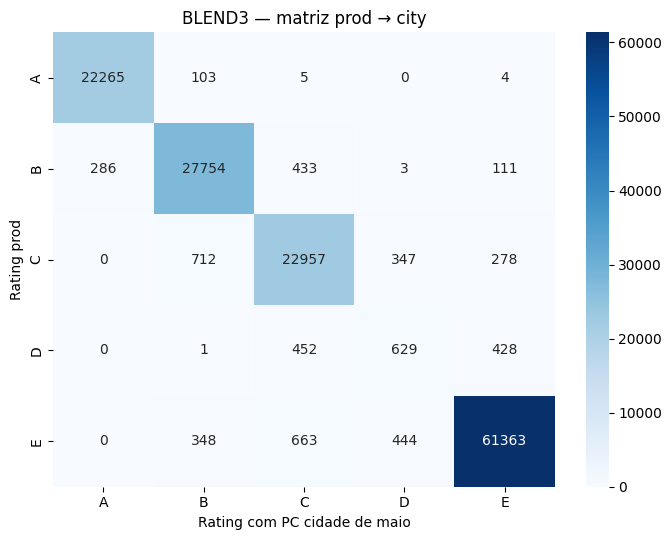

BLEND4 — n=49,398 | transições=2,953 (6.0% da base, 6.0% com rating nos dois lados)
  melhora=2,065 | piora=888 | elegíveis=43,562 | taxa entre elegíveis=6.7%


rating_city,A,B,C,D,E,total
rating_prod,,,,,,
A,17565,215,3,0,0,17783
B,414,2004,180,11,0,2609
C,0,408,2071,218,0,2697
D,0,2,518,5079,261,5860
E,0,0,0,723,19726,20449


Principais transições


,n,share
transition,,
E → D,723,24.5%
D → C,518,17.5%
B → A,414,14.0%
C → B,408,13.8%
D → E,261,8.8%
C → D,218,7.4%
A → B,215,7.3%
B → C,180,6.1%
B → D,11,0.4%


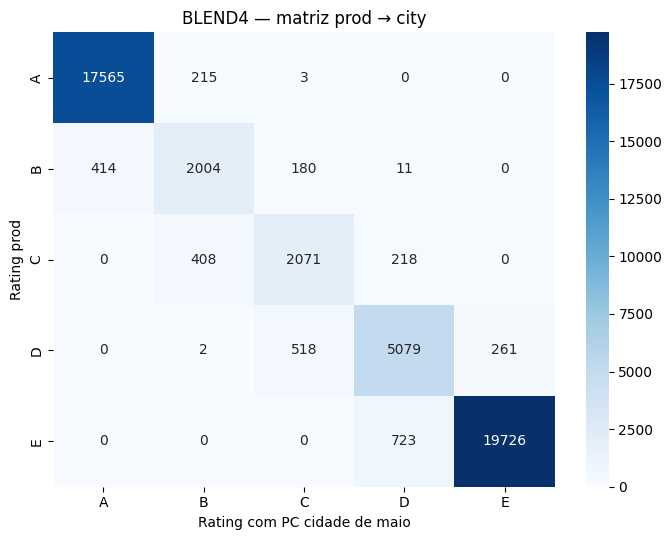

In [38]:
def migration_matrix(df: pd.DataFrame) -> pd.DataFrame:
    mat = pd.crosstab(df["rating_prod"], df["rating_city"], dropna=False)
    mat = mat.reindex(index=RATING_ORDER, columns=RATING_ORDER)
    mat["total"] = mat.sum(axis=1)
    return mat


def transition_volume(df: pd.DataFrame, title: str) -> None:
    n = len(df)
    n_chg = int(df["changed"].sum())
    both = df.dropna(subset=["rating_prod", "rating_city"])
    print(f"{title} — n={n:,} | transições={n_chg:,} ({n_chg / n:.1%} da base, {n_chg / len(both):.1%} com rating nos dois lados)")
    print(
        f"  melhora={int((df['sentido']=='melhora').sum()):,} | "
        f"piora={int((df['sentido']=='piora').sum()):,} | "
        f"elegíveis={int(df['eligible'].sum()):,} | "
        f"taxa entre elegíveis={df.loc[df['eligible'], 'changed'].mean():.1%}"
    )
    display(migration_matrix(df).style.format("{:.0f}", na_rep="—"))
    top = (
        df.loc[df["changed"], "transition"]
        .value_counts()
        .rename("n")
        .to_frame()
        .assign(share=lambda d: d["n"] / n_chg)
        .head(12)
    )
    print("Principais transições")
    display(top.style.format({"n": "{:.0f}", "share": "{:.1%}"}))


def plot_migration(df: pd.DataFrame, title: str) -> None:
    mat = pd.crosstab(df["rating_prod"], df["rating_city"]).reindex(index=RATING_ORDER, columns=RATING_ORDER)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(mat, annot=True, fmt=".0f", cmap="Blues", ax=ax)
    ax.set_xlabel("Rating com PC cidade de maio")
    ax.set_ylabel("Rating prod")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


transition_volume(tr3, "BLEND3")
plot_migration(tr3, "BLEND3 — matriz prod → city")
transition_volume(tr4, "BLEND4")
plot_migration(tr4, "BLEND4 — matriz prod → city")


### A transição só existe onde o modelo Blend manda no rating

Fora da faixa escorada, trocar PC cidade não move o rating — a porteira é o BVS, não o Serasa nem o PC imobiliária.

In [39]:
def gate_table(df: pd.DataFrame, title: str) -> None:
    out = (
        df.groupby("gate", dropna=False)
        .agg(n=("changed", "size"), n_transicao=("changed", "sum"), taxa=("changed", "mean"))
        .sort_values("n", ascending=False)
    )
    print(title)
    display(out.style.format({"n": "{:,.0f}", "n_transicao": "{:,.0f}", "taxa": "{:.1%}"}))


gate_table(tr3, "BLEND3 — transições por porteira de BVS")
gate_table(tr4, "BLEND4 — transições por porteira de BVS")

if "bureau_nm" in tr3.columns:
    print("BLEND3 — transições por versão da régua (só elegíveis)")
    display(
        tr3.loc[tr3["eligible"]]
        .groupby("bureau_nm")
        .agg(n=("changed", "size"), n_transicao=("changed", "sum"), taxa=("changed", "mean"))
        .style.format({"n": "{:,.0f}", "n_transicao": "{:,.0f}", "taxa": "{:.1%}"})
    )


BLEND3 — transições por porteira de BVS


,n,n_transicao,taxa
gate,,,
BVS ≥ 620 (rating pelo BVS),"59,059",0,0.0%
escorado (435 ≤ BVS < 620),"56,706","4,618",8.1%
"BVS < 435 (rating E, fora do modelo)","23,821",0,0.0%
BVS nulo / fora,303,0,0.0%


BLEND4 — transições por porteira de BVS


,n,n_transicao,taxa
gate,,,
"elegível (BVS > 334, rating pelo Blend4)","43,562","2,937",6.7%
BVS ≤ 334 (rating E por regra),"5,764",0,0.0%
BVS nulo / fora,72,16,22.2%


BLEND3 — transições por versão da régua (só elegíveis)


,n,n_transicao,taxa
bureau_nm,,,
BLEND3_3,"42,032","3,128",7.4%
BLEND3_4,"14,674","1,490",10.2%


### O input que muda é só o PC cidade

No cenário city, a PC imobiliária é idêntica à de produção. Não há transição com Δ PC cidade = 0. Logo a *causa* da mudança de rating é a troca do PC cidade (maio vs o valor usado na escoragem). BVS, Serasa e PC imob não mudam nesse cenário.

In [40]:
def input_delta_check(df: pd.DataFrame, title: str) -> None:
    print(title)
    print(f"  PC imobiliária idêntica prod vs city: {(~df['agency_pc_changed']).mean():.1%}")
    print(f"  PC cidade idêntica prod vs city: {(~df['city_pc_changed']).mean():.1%}")
    n_chg = int(df['changed'].sum())
    n_chg_same_pc = int((df['changed'] & ~df['city_pc_changed']).sum())
    n_chg_zero_delta = int((df['changed'] & df['delta_city_pc'].fillna(0).eq(0) & ~df['city_pc_changed']).sum())
    print(f"  transições: {n_chg:,}")
    print(f"  transições com PC cidade igual: {n_chg_same_pc:,}")
    print(f"  transições com Δ PC cidade = 0: {n_chg_zero_delta:,}")
    chg = df.loc[df["changed"]]
    elig_ok = df.loc[df["eligible"] & ~df["changed"]]
    print("  Δ PC cidade nas transições")
    display(chg["delta_city_pc"].describe().to_frame("delta_city_pc").T.style.format("{:+.4f}"))
    print("  Δ PC cidade nos elegíveis estáveis")
    display(elig_ok["delta_city_pc"].describe().to_frame("delta_city_pc").T.style.format("{:+.4f}"))
    print("  Δ score Blend nas transições")
    display(chg["delta_score"].describe().to_frame("delta_score").T.style.format("{:+.1f}"))


input_delta_check(tr3, "BLEND3")
input_delta_check(tr4, "BLEND4")


BLEND3
  PC imobiliária idêntica prod vs city: 100.0%
  PC cidade idêntica prod vs city: 12.2%
  transições: 4,618
  transições com PC cidade igual: 0
  transições com Δ PC cidade = 0: 0
  Δ PC cidade nas transições


,count,mean,std,min,25%,50%,75%,max
delta_city_pc,+4618.0000,-0.0047,+0.0208,-0.0563,-0.0177,-0.0080,+0.0069,+0.0769


  Δ PC cidade nos elegíveis estáveis


,count,mean,std,min,25%,50%,75%,max
delta_city_pc,+52088.0000,-0.0018,+0.0116,-0.0563,-0.0081,+0.0000,+0.0034,+0.0769


  Δ score Blend nas transições


...

,count,mean,std,min,25%,50%,75%,max
delta_city_pc,+2953.0000,-0.0071,+0.0238,-0.0563,-0.0225,-0.0108,+0.0068,+0.1023


  Δ PC cidade nos elegíveis estáveis


,count,mean,std,min,25%,50%,75%,max
delta_city_pc,+40625.0000,-0.0030,+0.0130,-0.0563,-0.0092,-0.0021,+0.0023,+0.1226


  Δ score Blend nas transições


,count,mean,std,min,25%,50%,75%,max
delta_score,+2953.0,+6.2,+21.2,-76.0,-6.0,+10.0,+20.0,+50.0


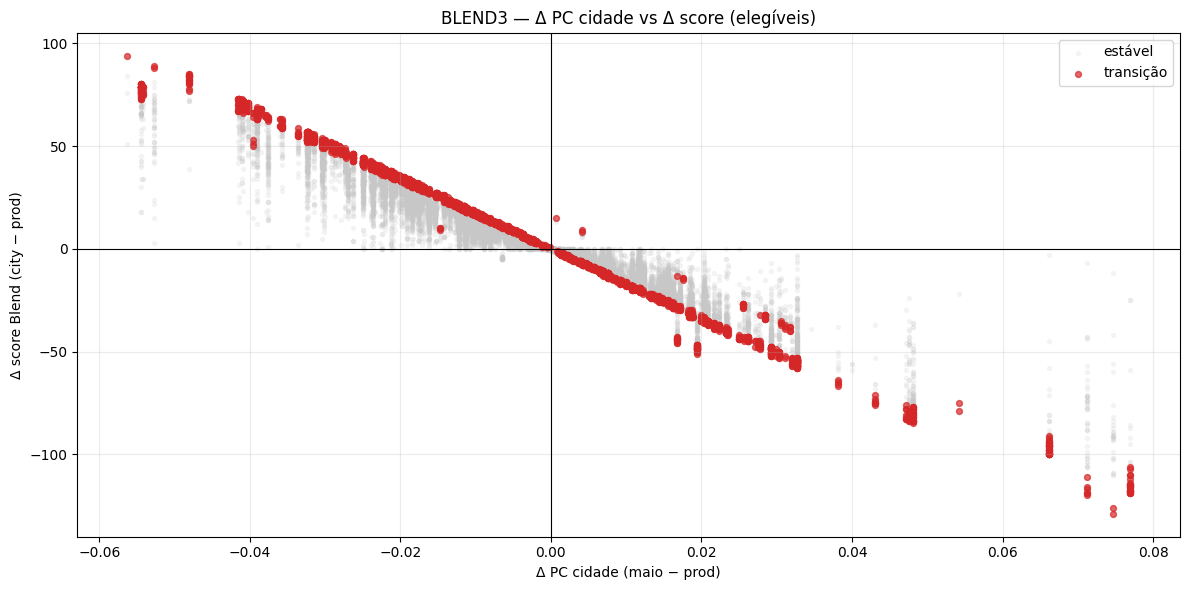

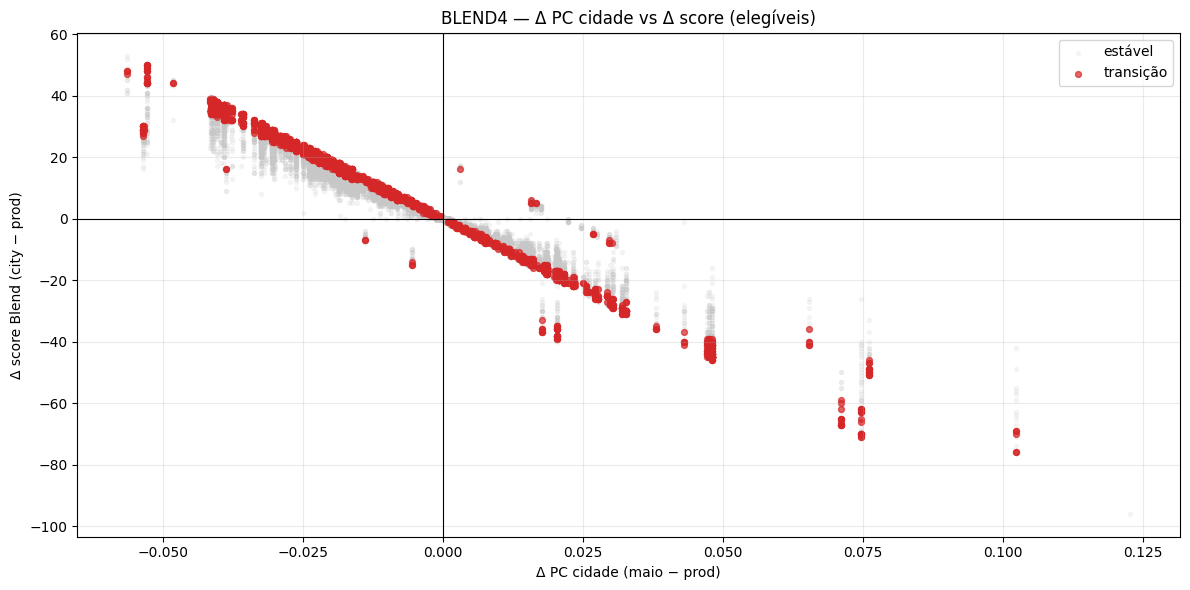

In [41]:
def plot_pc_vs_score(df: pd.DataFrame, title: str) -> None:
    sample = df.loc[df["eligible"]].copy()
    fig, ax = plt.subplots(figsize=(12, 6))
    stable = sample.loc[~sample["changed"]]
    chg = sample.loc[sample["changed"]]
    ax.scatter(stable["delta_city_pc"], stable["delta_score"], s=8, alpha=0.15, label="estável", c="#c7c7c7")
    ax.scatter(chg["delta_city_pc"], chg["delta_score"], s=18, alpha=0.7, label="transição", c="#d62728")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Δ PC cidade (maio − prod)")
    ax.set_ylabel("Δ score Blend (city − prod)")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_pc_vs_score(tr3, "BLEND3 — Δ PC cidade vs Δ score (elegíveis)")
plot_pc_vs_score(tr4, "BLEND4 — Δ PC cidade vs Δ score (elegíveis)")


### O que permite a virada: distância ao corte, não BVS/Serasa “piores”

PC cidade mais alto piora o score (coeficiente positivo no logit de inadimplência). Se o score de produção já está a poucos pontos de um corte (387 / 399 / 476 no Blend3; 343 / 408 / 443 / 480 no Blend4), um Δ PC pequeno atravessa a faixa. Longe do corte, o mesmo Δ quase nunca vira rating.

BVS e Serasa **não causam** a transição nesse cenário — eles (e renda, restrições, PC imob) definem *onde* o score estava. Quem vira não é, em média, o BVS mais baixo: é quem está na faixa em que o Blend manda **e** perto da fronteira.

BLEND3 — taxa de transição por distância ao corte (elegíveis)


,n,taxa
dist_bin,,
0–5,"4,534",45.8%
5–10,"2,772",29.8%
10–20,"4,967",17.0%
20–40,"9,475",7.8%
>40,"34,958",0.4%


BLEND3 — taxa de transição por |Δ PC cidade| (quintis, elegíveis)


,n,taxa
dpc_bin,,
"(-0.001, 0.00133]","11,365",0.4%
"(0.00133, 0.00382]","11,381",3.6%
"(0.00382, 0.00797]","11,381",7.3%
"(0.00797, 0.0136]","11,265",10.9%
"(0.0136, 0.0769]","11,314",18.5%


BLEND3 — taxa cruzada (distância × |Δ PC cidade|)


dpc_bin,"(-0.001, 0.00133]","(0.00133, 0.00382]","(0.00382, 0.00797]","(0.00797, 0.0136]","(0.0136, 0.0769]"
dist_bin,,,,,
0–5,4.8%,39.7%,60.6%,67.3%,68.1%
5–10,0.0%,3.6%,41.7%,55.1%,60.9%
10–20,0.0%,0.0%,2.8%,40.8%,55.4%
20–40,0.0%,0.0%,0.0%,0.9%,43.8%
>40,0.0%,0.0%,0.0%,0.0%,1.7%


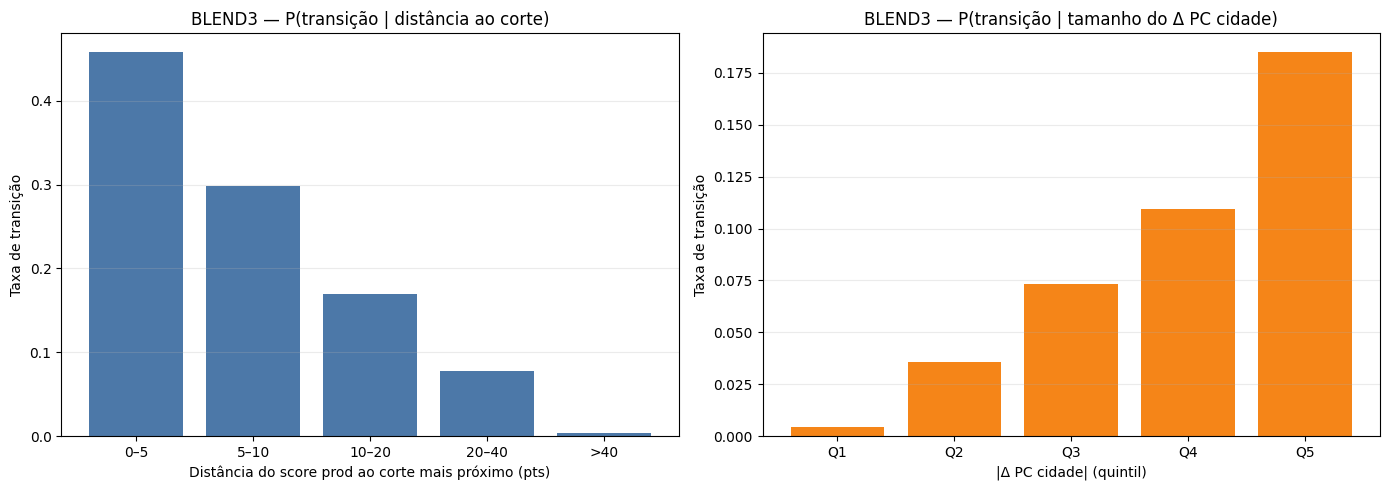

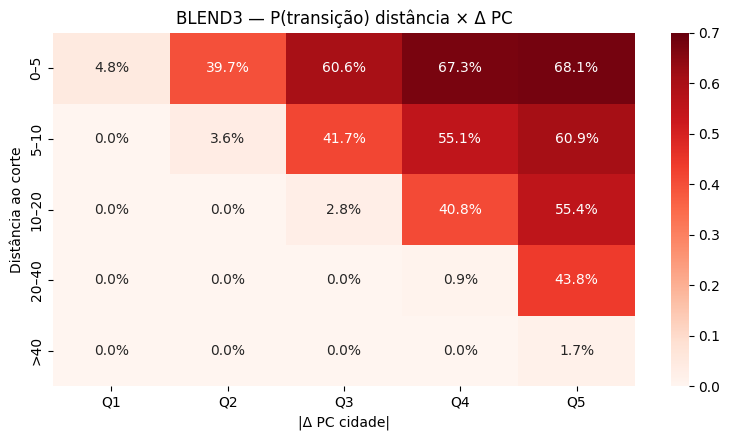

BLEND4 — taxa de transição por distância ao corte (elegíveis)


,n,taxa
dist_bin,,
0–5,"3,614",36.5%
5–10,"3,366",22.2%
10–20,"5,905",11.8%
20–40,"5,709",2.8%
>40,"24,968",0.1%


BLEND4 — taxa de transição por |Δ PC cidade| (quintis, elegíveis)


,n,taxa
dpc_bin,,
"(-0.001, 0.0017]","8,998",0.2%
"(0.0017, 0.00427]","8,446",2.4%
"(0.00427, 0.00895]","8,710",4.9%
"(0.00895, 0.0168]","8,967",8.3%
"(0.0168, 0.123]","8,441",18.3%


BLEND4 — taxa cruzada (distância × |Δ PC cidade|)


dpc_bin,"(-0.001, 0.0017]","(0.0017, 0.00427]","(0.00427, 0.00895]","(0.00895, 0.0168]","(0.0168, 0.123]"
dist_bin,,,,,
0–5,2.8%,28.6%,47.2%,48.5%,54.5%
5–10,0.0%,0.0%,11.1%,43.2%,57.0%
10–20,0.0%,0.1%,0.0%,6.1%,54.6%
20–40,0.0%,0.0%,0.0%,0.0%,15.0%
>40,0.0%,0.0%,0.0%,0.0%,0.3%


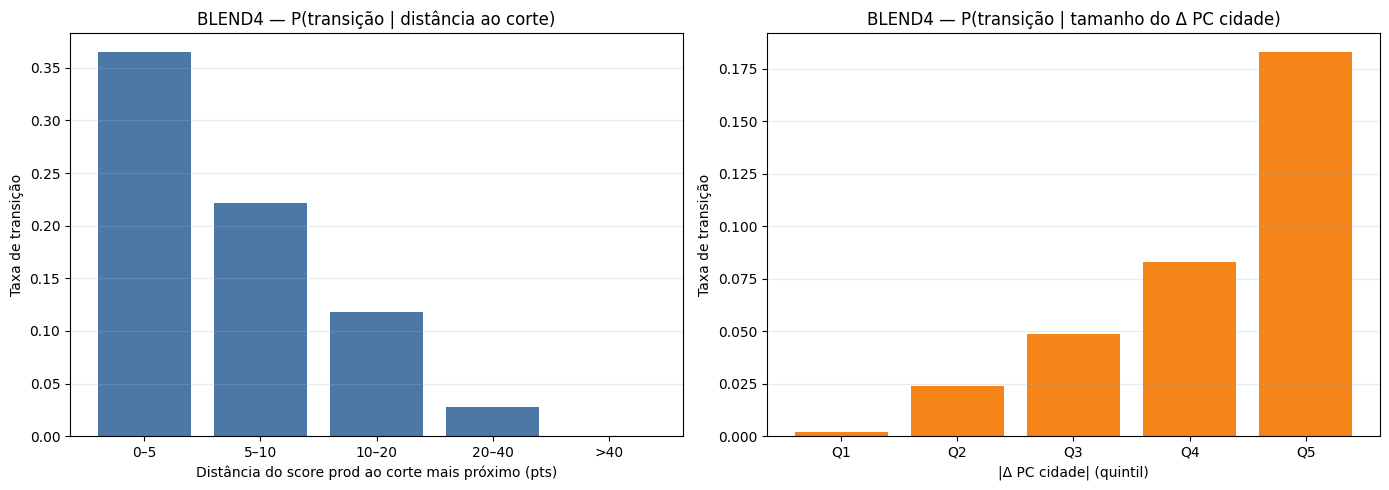

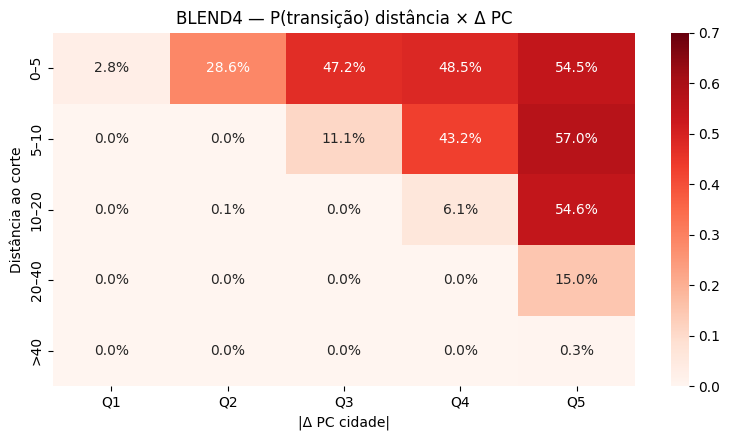

In [42]:
DIST_BINS = [0, 5, 10, 20, 40, 999]
DIST_LABELS = ["0–5", "5–10", "10–20", "20–40", ">40"]


def change_rate_tables(df: pd.DataFrame, title: str) -> pd.DataFrame:
    elig = df.loc[df["eligible"]].copy()
    elig["dist_bin"] = pd.cut(elig["dist_cutoff"], DIST_BINS, labels=DIST_LABELS, include_lowest=True)
    elig["dpc_bin"] = pd.qcut(elig["abs_delta_city_pc"].fillna(0), 5, duplicates="drop")

    by_dist = elig.groupby("dist_bin", observed=True).agg(n=("changed", "size"), taxa=("changed", "mean"))
    by_dpc = elig.groupby("dpc_bin", observed=True).agg(n=("changed", "size"), taxa=("changed", "mean"))
    cross = elig.pivot_table(index="dist_bin", columns="dpc_bin", values="changed", aggfunc="mean", observed=True)

    print(f"{title} — taxa de transição por distância ao corte (elegíveis)")
    display(by_dist.style.format({"n": "{:,.0f}", "taxa": "{:.1%}"}))
    print(f"{title} — taxa de transição por |Δ PC cidade| (quintis, elegíveis)")
    display(by_dpc.style.format({"n": "{:,.0f}", "taxa": "{:.1%}"}))
    print(f"{title} — taxa cruzada (distância × |Δ PC cidade|)")
    display(cross.style.format("{:.1%}", na_rep="—"))
    return elig


def plot_change_rates(elig: pd.DataFrame, title: str) -> None:
    elig = elig.copy()
    elig["dist_bin"] = pd.cut(elig["dist_cutoff"], DIST_BINS, labels=DIST_LABELS, include_lowest=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    by_dist = elig.groupby("dist_bin", observed=True)["changed"].mean()
    axes[0].bar(by_dist.index.astype(str), by_dist.values, color="#4c78a8")
    axes[0].set_xlabel("Distância do score prod ao corte mais próximo (pts)")
    axes[0].set_ylabel("Taxa de transição")
    axes[0].set_title(f"{title} — P(transição | distância ao corte)")
    axes[0].grid(axis="y", alpha=0.25)

    elig["dpc_q"] = pd.qcut(elig["abs_delta_city_pc"].fillna(0), 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop")
    by_dpc = elig.groupby("dpc_q", observed=True)["changed"].mean()
    axes[1].bar(by_dpc.index.astype(str), by_dpc.values, color="#f58518")
    axes[1].set_xlabel("|Δ PC cidade| (quintil)")
    axes[1].set_ylabel("Taxa de transição")
    axes[1].set_title(f"{title} — P(transição | tamanho do Δ PC cidade)")
    axes[1].grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    cross = (
        elig.assign(_chg=elig["changed"].astype(float))
        .pivot_table(index="dist_bin", columns="dpc_q", values="_chg", aggfunc="mean", observed=True)
        .astype(float)
    )
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.heatmap(cross, annot=True, fmt=".1%", cmap="Reds", ax=ax, vmin=0, vmax=0.7)
    ax.set_xlabel("|Δ PC cidade|")
    ax.set_ylabel("Distância ao corte")
    ax.set_title(f"{title} — P(transição) distância × Δ PC")
    plt.tight_layout()
    plt.show()


elig3 = change_rate_tables(tr3, "BLEND3")
plot_change_rates(elig3, "BLEND3")
elig4 = change_rate_tables(tr4, "BLEND4")
plot_change_rates(elig4, "BLEND4")


### Perfil das outras variáveis do modelo

Comparação **entre elegíveis** (quem *pode* virar). Se a transição fosse “BVS/Serasa mais baixo”, a mediana dos que viram sairia pior nesses scores. O que diferencia é distância ao corte e |Δ PC cidade|.

BLEND3 — perfil (elegíveis)


,variavel,n_transicao,mediana_transicao,media_transicao,n_estavel,mediana_estavel,media_estavel,delta_mediana
0,Score BVS,"4,618",550.000,545.583,"52,088",533.000,531.080,+17.000
1,Score Serasa,"4,618",469.000,487.386,"52,072",425.000,423.094,+44.000
2,PC imobiliária (prod),"4,618",0.124,0.125,"52,088",0.124,0.129,+0.000
3,PC cidade (prod),"4,618",0.098,0.100,"52,088",0.103,0.107,-0.005
4,|Δ PC cidade|,"4,618",0.012,0.017,"52,088",0.005,0.008,+0.007
5,Comprometimento de renda,"4,618",0.503,0.552,"52,088",0.608,4.752,-0.105
6,Qtde restrições,"4,618",0.000,1.134,"52,088",1.000,3.092,-1.000
7,Idade,"4,618",32.000,36.400,"52,088",32.000,36.458,+0.000
8,Distância ao corte de rating (pts),"4,618",6.000,11.463,"52,088",80.000,101.105,-74.000
9,|Δ score Blend|,"4,618",21.000,28.025,"52,088",7.000,10.793,+14.000


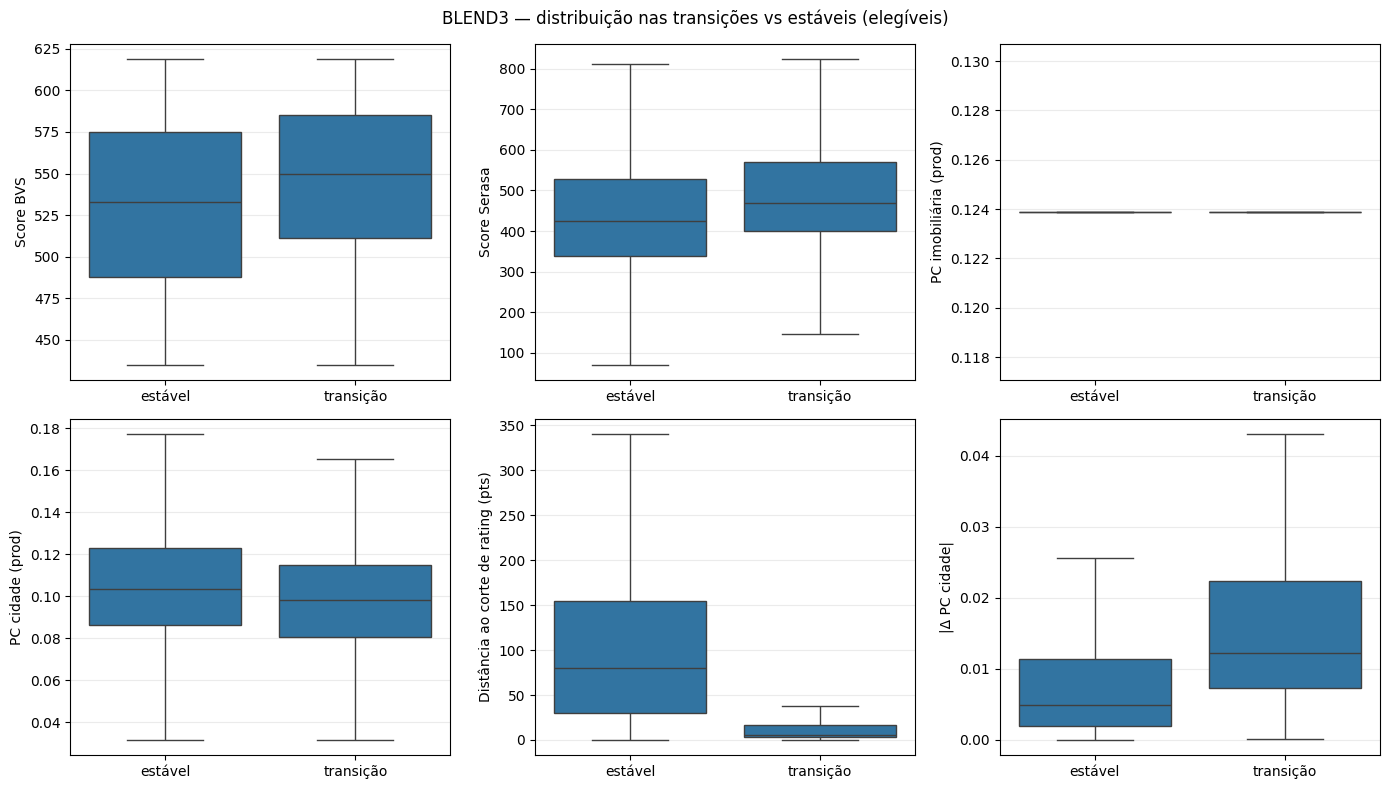

BLEND4 — perfil (elegíveis)


,variavel,n_transicao,mediana_transicao,media_transicao,n_estavel,mediana_estavel,media_estavel,delta_mediana
0,Score BVS,"2,937",473.000,474.263,"40,625",490.000,509.483,-17.000
1,Score Serasa,"2,936",392.000,400.077,"40,620",421.000,448.173,-29.000
2,PC imobiliária (prod),"2,937",0.129,0.132,"40,625",0.129,0.132,+0.000
3,PC cidade (prod),"2,937",0.105,0.112,"40,625",0.102,0.105,+0.002
4,|Δ PC cidade|,"2,937",0.018,0.020,"40,625",0.006,0.009,+0.012
5,Comprometimento de renda,"2,937",0.565,0.661,"40,625",0.508,1798.394,+0.057
6,Qtde restrições,"2,937",0.000,1.358,"40,625",0.000,2.149,+0.000
7,Idade,"2,937",33.000,37.644,"40,625",34.000,37.319,-1.000
8,Distância ao corte de rating (pts),"2,937",6.000,8.270,"40,625",69.000,97.350,-63.000
9,|Δ score Blend|,"2,937",16.000,18.115,"40,625",5.000,7.118,+11.000


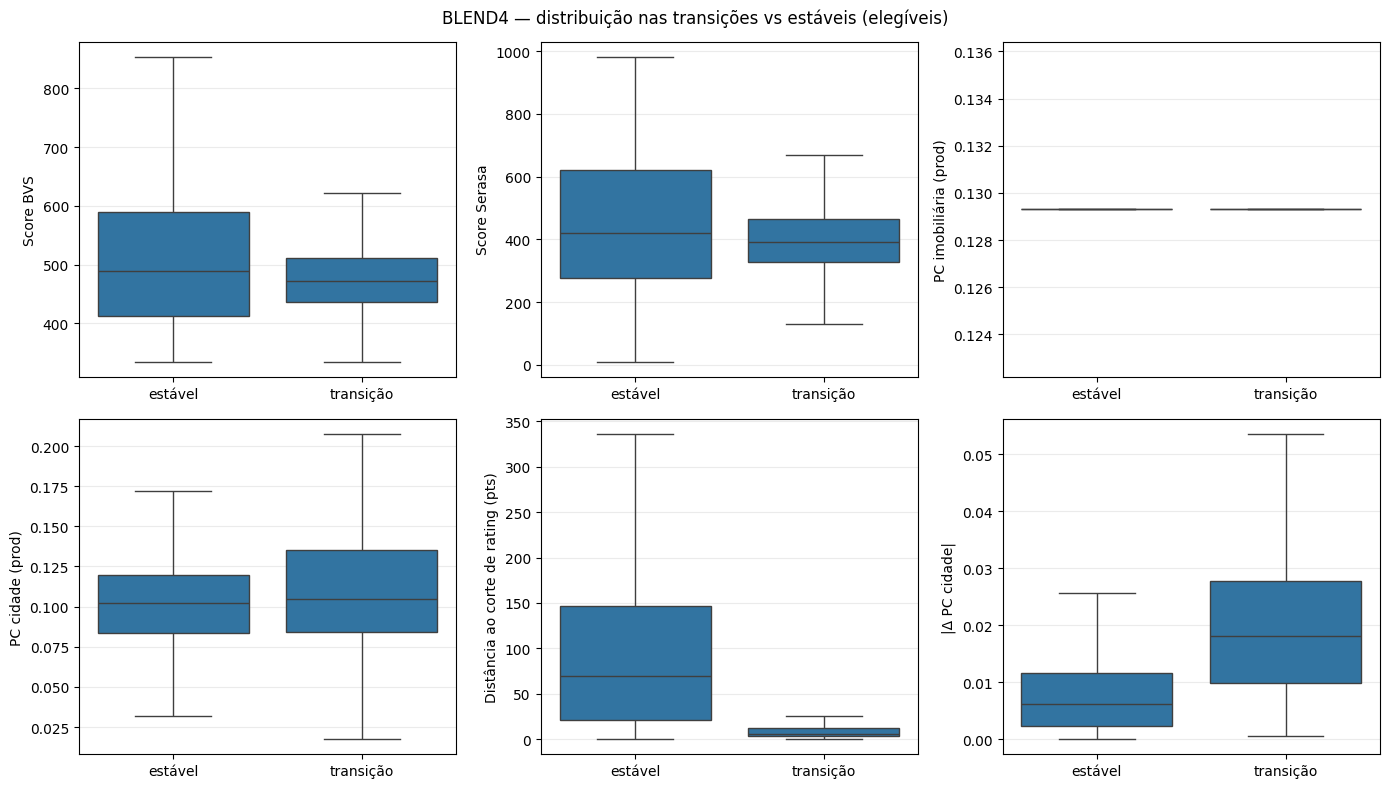

In [43]:
def feature_profile(df: pd.DataFrame, features: list, title: str) -> None:
    elig = df.loc[df["eligible"]].copy()
    rows = []
    for col in features:
        if col not in elig.columns:
            continue
        a = pd.to_numeric(elig.loc[elig["changed"], col], errors="coerce")
        b = pd.to_numeric(elig.loc[~elig["changed"], col], errors="coerce")
        rows.append({
            "variavel": FEATURE_LABELS.get(col, col),
            "n_transicao": int(a.notna().sum()),
            "mediana_transicao": a.median(),
            "media_transicao": a.mean(),
            "n_estavel": int(b.notna().sum()),
            "mediana_estavel": b.median(),
            "media_estavel": b.mean(),
            "delta_mediana": a.median() - b.median(),
        })
    out = pd.DataFrame(rows)
    print(title)
    display(out.style.format({
        "n_transicao": "{:,.0f}", "n_estavel": "{:,.0f}",
        "mediana_transicao": "{:.3f}", "media_transicao": "{:.3f}",
        "mediana_estavel": "{:.3f}", "media_estavel": "{:.3f}",
        "delta_mediana": "{:+.3f}",
    }))


def plot_feature_boxes(df: pd.DataFrame, cols: list, title: str) -> None:
    elig = df.loc[df["eligible"], cols + ["changed"]].copy()
    elig["grupo"] = np.where(elig["changed"], "transição", "estável")
    use = [c for c in cols if c in elig.columns]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    for ax, col in zip(axes, use):
        sns.boxplot(data=elig, x="grupo", y=col, ax=ax, showfliers=False, order=["estável", "transição"])
        ax.set_xlabel("")
        ax.set_ylabel(FEATURE_LABELS.get(col, col))
        ax.grid(axis="y", alpha=0.25)
    for ax in axes[len(use):]:
        ax.set_visible(False)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


feature_profile(tr3, SPEC_BLEND3["features"], "BLEND3 — perfil (elegíveis)")
plot_feature_boxes(
    tr3,
    ["SCORE_BVS", "SCORE_SERASA", "agency_pc_prod", "city_pc_prod", "dist_cutoff", "abs_delta_city_pc"],
    "BLEND3 — distribuição nas transições vs estáveis (elegíveis)",
)
feature_profile(tr4, SPEC_BLEND4["features"], "BLEND4 — perfil (elegíveis)")
plot_feature_boxes(
    tr4,
    ["SCORE_BVS", "SCORE_SERASA", "agency_pc_prod", "city_pc_prod", "dist_cutoff", "abs_delta_city_pc"],
    "BLEND4 — distribuição nas transições vs estáveis (elegíveis)",
)


In [44]:
def flag_profile(df: pd.DataFrame, title: str) -> None:
    elig = df.loc[df["eligible"]].copy()
    flags = [
        "flag_tem__contratos_anteriores",
        "flag_teve_boleto_atrasado__contratos_anteriores",
        "city_pc4_mais_100_contratos__pc_categorias_is_null",
        "agency_pc4_mais_100_contratos__pc_categorias_is_null",
    ]
    rows = []
    for col in flags:
        if col not in elig.columns:
            continue
        rows.append({
            "flag": col,
            "share_transicao": pd.to_numeric(elig.loc[elig["changed"], col], errors="coerce").mean(),
            "share_estavel": pd.to_numeric(elig.loc[~elig["changed"], col], errors="coerce").mean(),
        })
    print(title)
    display(pd.DataFrame(rows).style.format({"share_transicao": "{:.1%}", "share_estavel": "{:.1%}"}))


flag_profile(tr3, "BLEND3 — flags (elegíveis)")
flag_profile(tr4, "BLEND4 — flags (elegíveis)")


BLEND3 — flags (elegíveis)


,flag,share_transicao,share_estavel
0,flag_tem__contratos_anteriores,6.0%,5.4%
1,flag_teve_boleto_atrasado__contratos_anteriores,2.1%,2.4%
2,city_pc4_mais_100_contratos__pc_categorias_is_null,2.3%,13.7%
3,agency_pc4_mais_100_contratos__pc_categorias_is_null,86.7%,80.1%


BLEND4 — flags (elegíveis)


,flag,share_transicao,share_estavel
0,flag_tem__contratos_anteriores,7.3%,7.5%
1,flag_teve_boleto_atrasado__contratos_anteriores,2.6%,2.3%
2,city_pc4_mais_100_contratos__pc_categorias_is_null,1.7%,13.5%
3,agency_pc4_mais_100_contratos__pc_categorias_is_null,81.7%,81.7%


### PC imobiliária é outro gatilho, quase sem overlap

O cenário `agency` troca só o PC imobiliária. Quem vira rating por cidade em geral **não** é quem vira por imobiliária: são alavancas distintas. `ambos` ≈ união das duas, com pouco efeito extra de interação.

In [45]:
def scenario_overlap(df: pd.DataFrame, title: str) -> None:
    city = df["changed"]
    agency = df["changed_agency"]
    ambos = df["changed_ambos"]
    out = pd.DataFrame([
        {"recorte": "transição city (PC cidade)", "n": int(city.sum())},
        {"recorte": "transição agency (PC imobiliária)", "n": int(agency.sum())},
        {"recorte": "transição ambos", "n": int(ambos.sum())},
        {"recorte": "city e agency", "n": int((city & agency).sum())},
        {"recorte": "só city (não agency)", "n": int((city & ~agency).sum())},
        {"recorte": "só agency (não city)", "n": int((~city & agency).sum())},
        {"recorte": "ambos além de city", "n": int((ambos & ~city).sum())},
    ])
    print(title)
    display(out.style.format({"n": "{:,.0f}"}))


scenario_overlap(tr3, "BLEND3 — overlap city vs agency vs ambos")
scenario_overlap(tr4, "BLEND4 — overlap city vs agency vs ambos")


BLEND3 — overlap city vs agency vs ambos


,recorte,n
0,transição city (PC cidade),"4,618"
1,transição agency (PC imobiliária),244
2,transição ambos,"4,738"
3,city e agency,84
4,só city (não agency),"4,534"
5,só agency (não city),160
6,ambos além de city,162


BLEND4 — overlap city vs agency vs ambos


,recorte,n
0,transição city (PC cidade),"2,953"
1,transição agency (PC imobiliária),297
2,transição ambos,"3,128"
3,city e agency,65
4,só city (não agency),"2,888"
5,só agency (não city),232
6,ambos além de city,215


### Direção da transição segue o sinal do Δ PC cidade

PC cidade maior (maio pior que prod) → score Blend cai → rating piora. Correlação alta entre Δ PC e Δ rating confirma que não há outro input competindo no cenário city.

In [46]:
def direction_table(df: pd.DataFrame, title: str) -> None:
    chg = df.loc[df["changed"]].copy()
    chg["pc_sentido"] = np.select(
        [chg["delta_city_pc"] > 0, chg["delta_city_pc"] < 0],
        ["PC cidade subiu (maio pior)", "PC cidade caiu (maio melhor)"],
        default="PC cidade igual",
    )
    print(title)
    tab = pd.crosstab(chg["pc_sentido"], chg["sentido"], margins=True)
    display(tab)
    corr = chg[["delta_city_pc", "rating_delta", "delta_score"]].corr()
    print("Correlação (transições)")
    display(corr.style.format("{:.3f}"))


direction_table(tr3, "BLEND3 — direção")
direction_table(tr4, "BLEND4 — direção")


BLEND3 — direção


sentido,melhora,piora,All
pc_sentido,,,
PC cidade caiu (maio melhor),2903,0,2903
PC cidade subiu (maio pior),3,1712,1715
All,2906,1712,4618


Correlação (transições)


,delta_city_pc,rating_delta,delta_score
delta_city_pc,1.000,0.807,-0.996
rating_delta,0.807,1.000,-0.817
delta_score,-0.996,-0.817,1.000


BLEND4 — direção


sentido,melhora,piora,All
pc_sentido,,,
PC cidade caiu (maio melhor),2059,5,2064
PC cidade subiu (maio pior),6,883,889
All,2065,888,2953


Correlação (transições)


,delta_city_pc,rating_delta,delta_score
delta_city_pc,1.000,0.804,-0.985
rating_delta,0.804,1.000,-0.819
delta_score,-0.985,-0.819,1.000


### Onde as transições se concentram

In [47]:
def top_entities(df: pd.DataFrame, entity_col: str, title: str, extra: list = None, n: int = 15) -> None:
    chg = df.loc[df["changed"]].copy()
    extra = extra or []
    agg = (
        chg.groupby([entity_col] + extra, dropna=False)
        .agg(
            n_transicao=("changed", "size"),
            n_melhora=("sentido", lambda s: (s == "melhora").sum()),
            n_piora=("sentido", lambda s: (s == "piora").sum()),
            delta_pc_med=("delta_city_pc", "median"),
            dist_med=("dist_cutoff", "median"),
        )
        .sort_values("n_transicao", ascending=False)
        .head(n)
    )
    tot = (
        df.groupby(entity_col, dropna=False)
        .agg(n_elegivel=("eligible", "sum"), n=("changed", "size"))
    )
    agg = agg.join(tot, on=entity_col)
    agg["taxa"] = agg["n_transicao"] / agg["n_elegivel"].replace(0, np.nan)
    print(title)
    display(agg.style.format({
        "n_transicao": "{:.0f}", "n_melhora": "{:.0f}", "n_piora": "{:.0f}",
        "delta_pc_med": "{:+.4f}", "dist_med": "{:.1f}",
        "n_elegivel": "{:.0f}", "n": "{:.0f}", "taxa": "{:.1%}",
    }, na_rep="—"))


top_entities(tr3, "id_cidade_ibge", "BLEND3 — cidades com mais transições", extra=["imovel_cidade", "imovel_uf"])
top_entities(tr4, "id_cidade_ibge", "BLEND4 — cidades com mais transições", extra=["imovel_cidade", "imovel_uf"])
top_entities(tr3, "id_imobiliaria", "BLEND3 — imobiliárias com mais transições")
top_entities(tr4, "id_imobiliaria", "BLEND4 — imobiliárias com mais transições")


BLEND3 — cidades com mais transições


,,,n_transicao,n_melhora,n_piora,delta_pc_med,dist_med,n_elegivel,n,taxa
id_cidade_ibge,imovel_cidade,imovel_uf,,,,,,,,
4113700,Londrina,PR,211,211,0,-0.0057,5.0,1729,4410,12.2%
3538709,Piracicaba,SP,124,124,0,-0.0115,6.0,854,2235,14.5%
4313409,Novo Hamburgo,RS,108,108,0,-0.0250,16.5,473,1077,22.8%
3550308,São Paulo,SP,99,99,0,-0.0027,3.0,2024,5359,4.9%
4202404,Blumenau,SC,89,89,0,-0.0037,4.0,1146,3048,7.8%
3524402,Jacareí,SP,89,0,89,+0.0108,7.0,726,1871,12.3%
3554102,Taubaté,SP,88,88,0,-0.0143,14.0,368,852,23.9%
3552205,Sorocaba,SP,87,0,87,+0.0066,4.0,648,1589,13.4%
4314100,Passo Fundo,RS,85,0,85,+0.0327,16.0,329,766,25.8%


BLEND4 — cidades com mais transições


,,,n_transicao,n_melhora,n_piora,delta_pc_med,dist_med,n_elegivel,n,taxa
id_cidade_ibge,imovel_cidade,imovel_uf,,,,,,,,
4113700,Londrina,PR,103,103,0,-0.0112,5.0,1462,1603,7.0%
3550308,São Paulo,SP,103,103,0,-0.0081,2.0,1737,1906,5.9%
4313409,Novo Hamburgo,RS,84,84,0,-0.0390,13.0,313,396,26.8%
4202909,Brusque,SC,71,70,1,-0.0304,12.0,380,432,18.7%
5208707,Goiânia,GO,67,67,0,-0.0185,8.0,648,750,10.3%
4314100,Passo Fundo,RS,65,0,65,+0.0480,13.0,234,256,27.8%
4314407,Pelotas,RS,63,63,0,-0.0324,11.0,370,425,17.0%
4202008,Balneário Camboriú,SC,52,52,0,-0.0263,10.5,384,415,13.5%
3547809,Santo André,SP,52,52,0,-0.0168,8.0,424,477,12.3%


BLEND3 — imobiliárias com mais transições


,n_transicao,n_melhora,n_piora,delta_pc_med,dist_med,n_elegivel,n,taxa
id_imobiliaria,,,,,,,,
16316,48,0,48,+0.0662,26.0,73,143,65.8%
2687,47,29,18,-0.0088,4.0,798,1879,5.9%
51620,38,37,1,-0.0102,5.0,244,587,15.6%
25022,29,29,0,-0.0191,6.0,81,141,35.8%
27359,27,27,0,-0.0410,23.0,50,106,54.0%
574,26,26,0,-0.0250,15.0,165,385,15.8%
45829,23,8,15,+0.0049,6.0,154,355,14.9%
315,23,0,23,+0.0327,10.0,61,122,37.7%
215,22,22,0,-0.0324,25.5,274,614,8.0%


BLEND4 — imobiliárias com mais transições


,n_transicao,n_melhora,n_piora,delta_pc_med,dist_med,n_elegivel,n,taxa
id_imobiliaria,,,,,,,,
6422,31,31,0,-0.0163,5.0,201,229,15.4%
2687,29,25,4,-0.0108,4.0,478,536,6.1%
574,28,28,0,-0.0390,14.0,86,143,32.6%
6885,27,21,6,-0.0168,8.0,241,259,11.2%
51620,26,26,0,-0.0207,8.0,155,225,16.8%
215,23,23,0,-0.0324,15.0,171,195,13.5%
26609,19,19,0,-0.0528,15.0,81,91,23.5%
1695,19,18,1,-0.0304,15.0,71,80,26.8%
39418,17,17,0,-0.0220,11.0,77,86,22.1%


### Transições por magnitude do delta (cidade e imobiliária)

O delta é o número de faixas que o rating andou na escala A→B→C→D→E:

- **|Δ| = 1**: vizinho (A→B, B→C, C→B…)
- **|Δ| = 2**: pula uma faixa (A→C, C→A, B→D…)
- **|Δ| ≥ 3**: salto longo (A→D/E, E→B…)

Sinal positivo = piora (A→B); negativo = melhora (B→A). A pergunta é se os saltos de 2+ faixas se concentram em poucas cidades/imobiliárias — e se isso acompanha o tamanho do Δ PC cidade.

BLEND3 — transições por |Δ rating|


sentido,melhora,piora,total,share
delta_bin,,,,
1 (vizinho),"1,894","1,311","3,205",69.4%
2 (pula 1 faixa),664,286,950,20.6%
3+ (salto longo),348,115,463,10.0%


BLEND3 — pares de rating por |Δ|


,abs_rating_delta,transition,sentido,n
3,1,C → B,melhora,712
5,1,D → C,melhora,452
7,1,E → D,melhora,444
2,1,B → C,piora,433
6,1,D → E,piora,428
4,1,C → D,piora,347
1,1,B → A,melhora,286
0,1,A → B,piora,103
12,2,E → C,melhora,663
10,2,C → E,piora,278


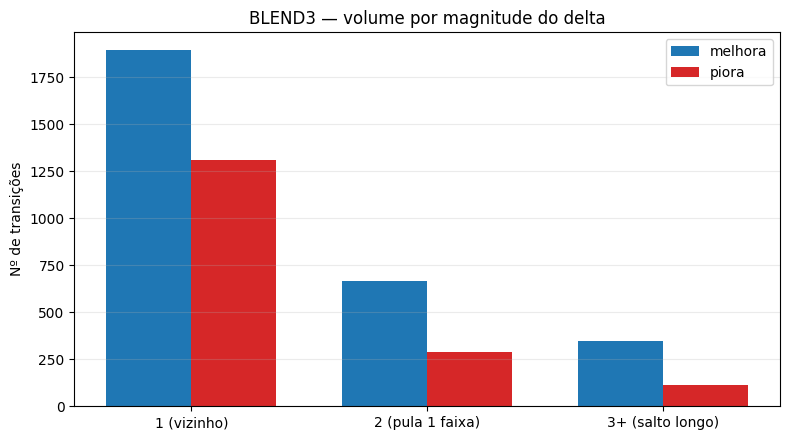

BLEND4 — transições por |Δ rating|


sentido,melhora,piora,total,share
delta_bin,,,,
1 (vizinho),"2,063",874,"2,937",99.5%
2 (pula 1 faixa),2,14,16,0.5%
3+ (salto longo),nan,nan,nan,nan%


BLEND4 — pares de rating por |Δ|


,abs_rating_delta,transition,sentido,n
7,1,E → D,melhora,723
5,1,D → C,melhora,518
1,1,B → A,melhora,414
3,1,C → B,melhora,408
6,1,D → E,piora,261
4,1,C → D,piora,218
0,1,A → B,piora,215
2,1,B → C,piora,180
9,2,B → D,piora,11
8,2,A → C,piora,3


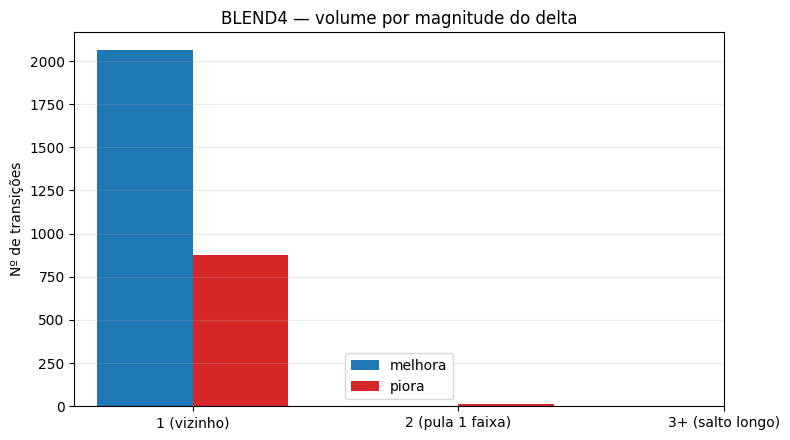

BLEND3 — cidades — top 15 por volume de |Δ| = 1 (vizinho)


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_cidade_ibge,,,,,,,,,,,,,,,
4113700,Londrina,PR,1729,211,157,36,18,211,0,1.34,12.2%,3.1%,25.6%,-0.0057,0.0057
3538709,Piracicaba,SP,854,124,87,32,5,124,0,1.34,14.5%,4.3%,29.8%,-0.0115,0.0115
3550308,São Paulo,SP,2024,99,81,17,1,99,0,1.19,4.9%,0.9%,18.2%,-0.0027,0.0027
3524402,Jacareí,SP,726,89,77,10,2,0,89,1.16,12.3%,1.7%,13.5%,+0.0108,0.0108
3552205,Sorocaba,SP,648,87,75,11,1,0,87,1.15,13.4%,1.9%,13.8%,+0.0066,0.0066
4106902,Curitiba,PR,849,78,74,4,0,0,78,1.05,9.2%,0.5%,5.1%,+0.0049,0.0049
5002704,Campo Grande,MS,417,83,70,10,3,83,0,1.19,19.9%,3.1%,15.7%,-0.0122,0.0122
4202404,Blumenau,SC,1146,89,70,14,5,89,0,1.27,7.8%,1.7%,21.3%,-0.0037,0.0037
4305108,Caxias Do Sul,RS,870,72,65,7,0,13,59,1.10,8.3%,0.8%,9.7%,+0.0068,0.0068


BLEND3 — cidades — top 15 por volume de |Δ| ≥ 2 (pula faixa)


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_cidade_ibge,,,,,,,,,,,,,,,
4313409,Novo Hamburgo,RS,473,108,28,41,39,108,0,2.10,22.8%,16.9%,74.1%,-0.0250,0.0250
4113700,Londrina,PR,1729,211,157,36,18,211,0,1.34,12.2%,3.1%,25.6%,-0.0057,0.0057
4314100,Passo Fundo,RS,329,85,38,34,13,0,85,1.71,25.8%,14.3%,55.3%,+0.0327,0.0327
5107040,Primavera Do Leste,MT,441,74,29,35,10,74,0,1.74,16.8%,10.2%,60.8%,-0.0191,0.0191
4314407,Pelotas,RS,516,74,29,32,13,74,0,1.78,14.3%,8.7%,60.8%,-0.0220,0.0220
3530706,Mogi Guaçu,SP,207,68,26,30,12,68,0,1.79,32.9%,20.3%,61.8%,-0.0323,0.0323
5107909,Sinop,MT,84,60,18,28,14,0,60,1.98,71.4%,50.0%,70.0%,+0.0662,0.0662
3538709,Piracicaba,SP,854,124,87,32,5,124,0,1.34,14.5%,4.3%,29.8%,-0.0115,0.0115
4218004,Tijucas,SC,323,55,26,25,4,0,55,1.60,17.0%,9.0%,52.7%,+0.0293,0.0293


BLEND3 — cidades — top 15 por taxa de |Δ| ≥ 2 entre elegíveis (mín. 20 elegíveis)


...

,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_cidade_ibge,,,,,,,,,,,,,,,
3550308,São Paulo,SP,1737,103,103,0,0,103,0,1.00,5.9%,0.0%,0.0%,-0.0081,0.0081
4113700,Londrina,PR,1462,103,103,0,0,103,0,1.00,7.0%,0.0%,0.0%,-0.0112,0.0112
4313409,Novo Hamburgo,RS,313,84,84,0,0,84,0,1.00,26.8%,0.0%,0.0%,-0.0390,0.0390
4202909,Brusque,SC,380,71,71,0,0,70,1,1.00,18.7%,0.0%,0.0%,-0.0304,0.0304
5208707,Goiânia,GO,648,67,67,0,0,67,0,1.00,10.3%,0.0%,0.0%,-0.0185,0.0185
4314407,Pelotas,RS,370,63,63,0,0,63,0,1.00,17.0%,0.0%,0.0%,-0.0324,0.0324
4314100,Passo Fundo,RS,234,65,59,6,0,0,65,1.09,27.8%,2.6%,9.2%,+0.0480,0.0480
4202008,Balneário Camboriú,SC,384,52,52,0,0,52,0,1.00,13.5%,0.0%,0.0%,-0.0263,0.0263
3547809,Santo André,SP,424,52,52,0,0,52,0,1.00,12.3%,0.0%,0.0%,-0.0168,0.0168


BLEND4 — cidades — top 15 por volume de |Δ| ≥ 2 (pula faixa)


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_cidade_ibge,,,,,,,,,,,,,,,
4314100,Passo Fundo,RS,234,65,59,6,0,0,65,1.09,27.8%,2.6%,9.2%,+0.0480,0.0480
5218805,Rio Verde,GO,71,27,23,4,0,0,27,1.15,38.0%,5.6%,14.8%,+0.0746,0.0746
4303103,Cachoeirinha,RS,91,18,16,2,0,0,18,1.11,19.8%,2.2%,11.1%,+0.0476,0.0476
5107602,Rondonópolis,MT,102,28,26,2,0,28,0,1.07,27.5%,2.0%,7.1%,-0.0528,0.0528
3526803,Lençóis Paulista,SP,77,16,15,1,0,0,16,1.06,20.8%,1.3%,6.2%,+0.0203,0.0203
5107909,Sinop,MT,54,18,17,1,0,0,18,1.06,33.3%,1.9%,5.6%,+0.0760,0.0760
1100205,Porto Velho,RO,28,0,0,0,0,0,0,—,0.0%,0.0%,—,+0.0000,0.0000
1721000,Palmas,TO,30,0,0,0,0,0,0,—,0.0%,0.0%,—,+0.0000,0.0000
2211001,Teresina,PI,178,38,38,0,0,37,1,1.00,21.3%,0.0%,0.0%,-0.0197,0.0197


BLEND4 — cidades — top 15 por taxa de |Δ| ≥ 2 entre elegíveis (mín. 20 elegíveis)


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_cidade_ibge,,,,,,,,,,,,,,,
5218805,Rio Verde,GO,71,27,23,4,0,0,27,1.15,38.0%,5.6%,14.8%,+0.0746,0.0746
4314100,Passo Fundo,RS,234,65,59,6,0,0,65,1.09,27.8%,2.6%,9.2%,+0.0480,0.0480
4303103,Cachoeirinha,RS,91,18,16,2,0,0,18,1.11,19.8%,2.2%,11.1%,+0.0476,0.0476
5107602,Rondonópolis,MT,102,28,26,2,0,28,0,1.07,27.5%,2.0%,7.1%,-0.0528,0.0528
5107909,Sinop,MT,54,18,17,1,0,0,18,1.06,33.3%,1.9%,5.6%,+0.0760,0.0760
3526803,Lençóis Paulista,SP,77,16,15,1,0,0,16,1.06,20.8%,1.3%,6.2%,+0.0203,0.0203
4127700,Toledo,PR,32,0,0,0,0,0,0,—,0.0%,0.0%,—,+0.0000,0.0000
4202404,Blumenau,SC,892,47,47,0,0,47,0,1.00,5.3%,0.0%,0.0%,-0.0081,0.0081
4202107,Barra Velha,SC,178,17,17,0,0,0,17,1.00,9.6%,0.0%,0.0%,+0.0158,0.0158


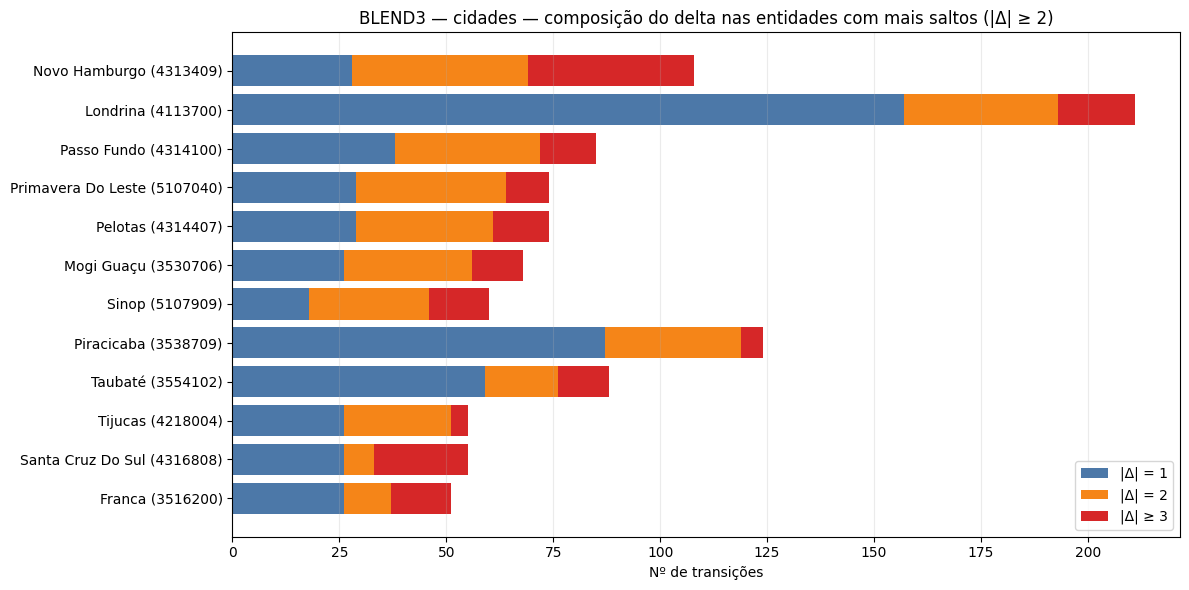

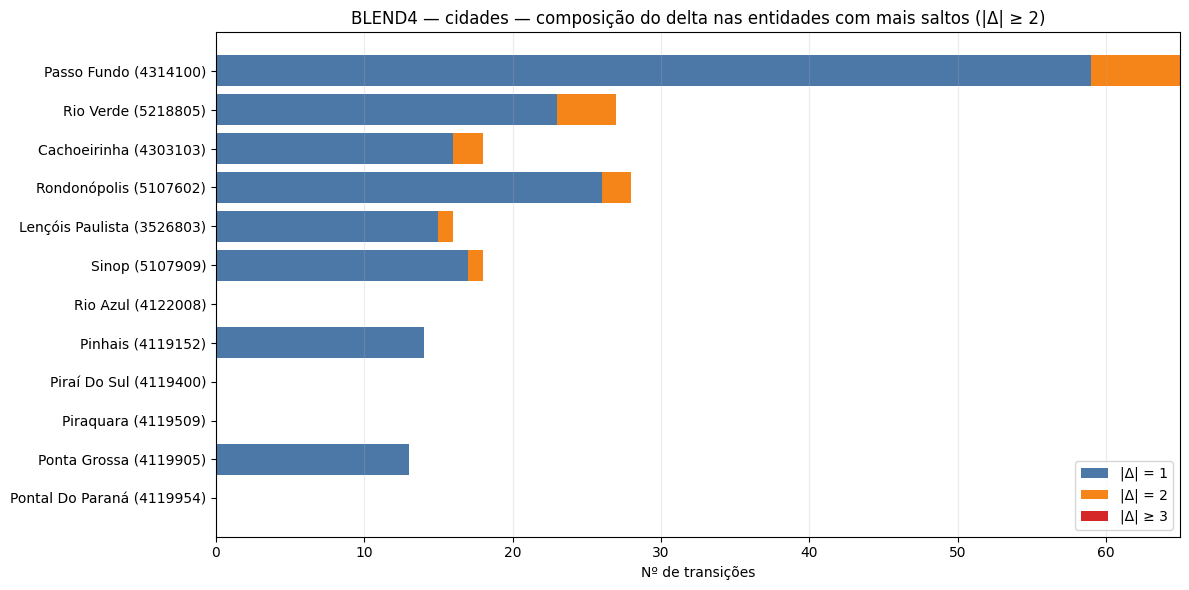

BLEND3 — imobiliárias — top 15 por volume de |Δ| = 1 (vizinho)


,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_imobiliaria,,,,,,,,,,,,,
2687,798,47,39,7,1,29,18,1.19,5.9%,1.0%,17.0%,+0.0013,0.0013
51620,244,38,25,8,5,37,1,1.47,15.6%,5.3%,34.2%,-0.0102,0.0102
45829,154,23,20,1,2,8,15,1.22,14.9%,1.9%,13.0%,+0.0049,0.0078
27359,50,27,16,10,1,27,0,1.44,54.0%,22.0%,40.7%,-0.0410,0.0410
969,117,16,16,0,0,1,15,1.00,13.7%,0.0%,0.0%,+0.0108,0.0108
11985,129,19,15,4,0,0,19,1.21,14.7%,3.1%,21.1%,+0.0066,0.0066
264,145,16,15,1,0,16,0,1.06,11.0%,0.7%,6.2%,-0.0057,0.0057
16316,73,48,14,23,11,0,48,1.98,65.8%,46.6%,70.8%,+0.0662,0.0662
4881,80,13,13,0,0,0,13,1.00,16.2%,0.0%,0.0%,+0.0049,0.0049


BLEND3 — imobiliárias — top 15 por volume de |Δ| ≥ 2 (pula faixa)


,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_imobiliaria,,,,,,,,,,,,,
16316,73,48,14,23,11,0,48,1.98,65.8%,46.6%,70.8%,+0.0662,0.0662
25022,81,29,4,22,3,29,0,1.97,35.8%,30.9%,86.2%,-0.0191,0.0191
41591,71,21,2,11,8,21,0,2.29,29.6%,26.8%,90.5%,-0.0250,0.0250
215,274,22,4,10,8,22,0,2.18,8.0%,6.6%,81.8%,-0.0220,0.0220
574,165,26,12,7,7,26,0,1.81,15.8%,8.5%,53.8%,-0.0250,0.0250
315,61,23,10,8,5,0,23,1.78,37.7%,21.3%,56.5%,+0.0327,0.0327
51620,244,38,25,8,5,37,1,1.47,15.6%,5.3%,34.2%,-0.0102,0.0102
13268,26,17,5,12,0,17,0,1.71,65.4%,46.2%,70.6%,-0.0323,0.0323
27359,50,27,16,10,1,27,0,1.44,54.0%,22.0%,40.7%,-0.0410,0.0410


BLEND3 — imobiliárias — top 15 por taxa de |Δ| ≥ 2 entre elegíveis (mín. 10 elegíveis)


...

,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_imobiliaria,,,,,,,,,,,,,
6422,201,31,31,0,0,31,0,1.00,15.4%,0.0%,0.0%,-0.0154,0.0154
2687,478,29,29,0,0,25,4,1.00,6.1%,0.0%,0.0%,-0.0029,0.0029
574,86,28,28,0,0,28,0,1.00,32.6%,0.0%,0.0%,-0.0250,0.0250
6885,241,27,27,0,0,21,6,1.00,11.2%,0.0%,0.0%,-0.0029,0.0081
51620,155,26,26,0,0,26,0,1.00,16.8%,0.0%,0.0%,-0.0207,0.0207
215,171,23,23,0,0,23,0,1.00,13.5%,0.0%,0.0%,-0.0324,0.0324
1695,71,19,19,0,0,18,1,1.00,26.8%,0.0%,0.0%,-0.0304,0.0304
39418,77,17,17,0,0,17,0,1.00,22.1%,0.0%,0.0%,-0.0220,0.0272
26609,81,19,17,2,0,19,0,1.11,23.5%,2.5%,10.5%,-0.0528,0.0528


BLEND4 — imobiliárias — top 15 por volume de |Δ| ≥ 2 (pula faixa)


,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_imobiliaria,,,,,,,,,,,,,
1145,39,11,9,2,0,0,11,1.18,28.2%,5.1%,18.2%,+0.0480,0.0480
7240,36,9,7,2,0,0,9,1.22,25.0%,5.6%,22.2%,+0.0476,0.0476
26609,81,19,17,2,0,19,0,1.11,23.5%,2.5%,10.5%,-0.0528,0.0528
315,42,10,9,1,0,0,10,1.10,23.8%,2.4%,10.0%,+0.0480,0.0480
2151,14,4,3,1,0,0,4,1.25,28.6%,7.1%,25.0%,+0.0480,0.0480
15650,31,7,6,1,0,0,7,1.14,22.6%,3.2%,14.3%,+0.0203,0.0203
16316,39,13,12,1,0,0,13,1.08,33.3%,2.6%,7.7%,+0.0760,0.0760
25408,16,7,6,1,0,0,7,1.14,43.8%,6.2%,14.3%,+0.0480,0.0480
33575,19,6,5,1,0,0,6,1.17,31.6%,5.3%,16.7%,+0.0746,0.0746


BLEND4 — imobiliárias — top 15 por taxa de |Δ| ≥ 2 entre elegíveis (mín. 10 elegíveis)


,n_elegivel,n_transicao,n_delta1,n_delta2,n_delta3plus,n_melhora,n_piora,abs_delta_mean,taxa_transicao,taxa_delta2plus,share_delta2plus,delta_pc_med,abs_delta_pc_med
id_imobiliaria,,,,,,,,,,,,,
2151,14,4,3,1,0,0,4,1.25,28.6%,7.1%,25.0%,+0.0480,0.0480
25408,16,7,6,1,0,0,7,1.14,43.8%,6.2%,14.3%,+0.0480,0.0480
7240,36,9,7,2,0,0,9,1.22,25.0%,5.6%,22.2%,+0.0476,0.0476
33575,19,6,5,1,0,0,6,1.17,31.6%,5.3%,16.7%,+0.0746,0.0746
1145,39,11,9,2,0,0,11,1.18,28.2%,5.1%,18.2%,+0.0480,0.0480
15650,31,7,6,1,0,0,7,1.14,22.6%,3.2%,14.3%,+0.0203,0.0203
16316,39,13,12,1,0,0,13,1.08,33.3%,2.6%,7.7%,+0.0760,0.0760
26609,81,19,17,2,0,19,0,1.11,23.5%,2.5%,10.5%,-0.0528,0.0528
315,42,10,9,1,0,0,10,1.10,23.8%,2.4%,10.0%,+0.0480,0.0480


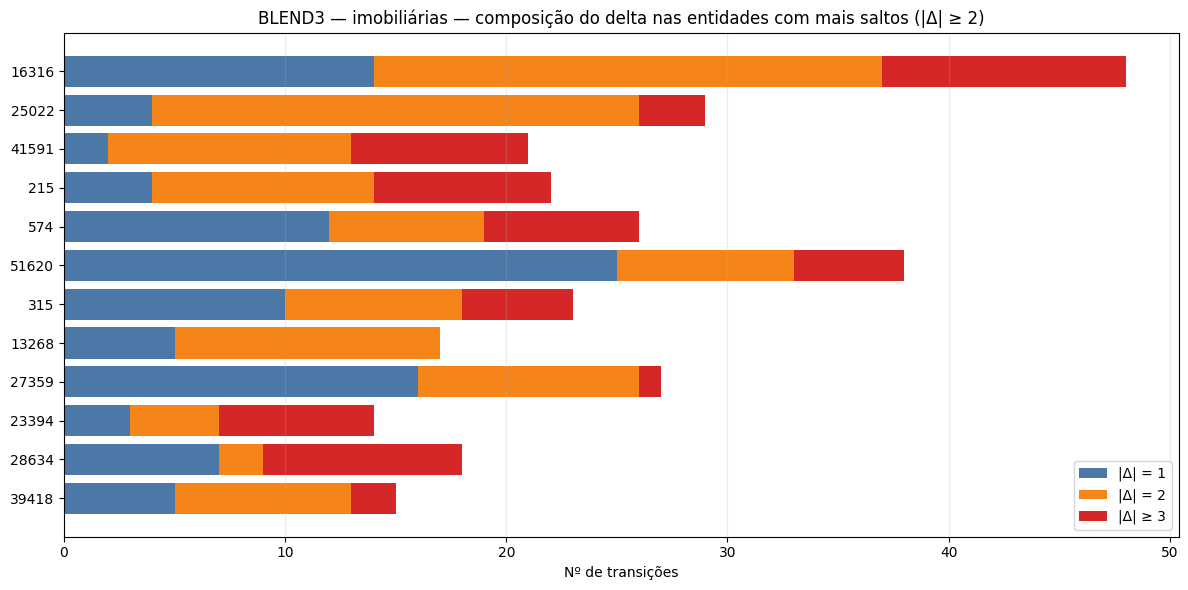

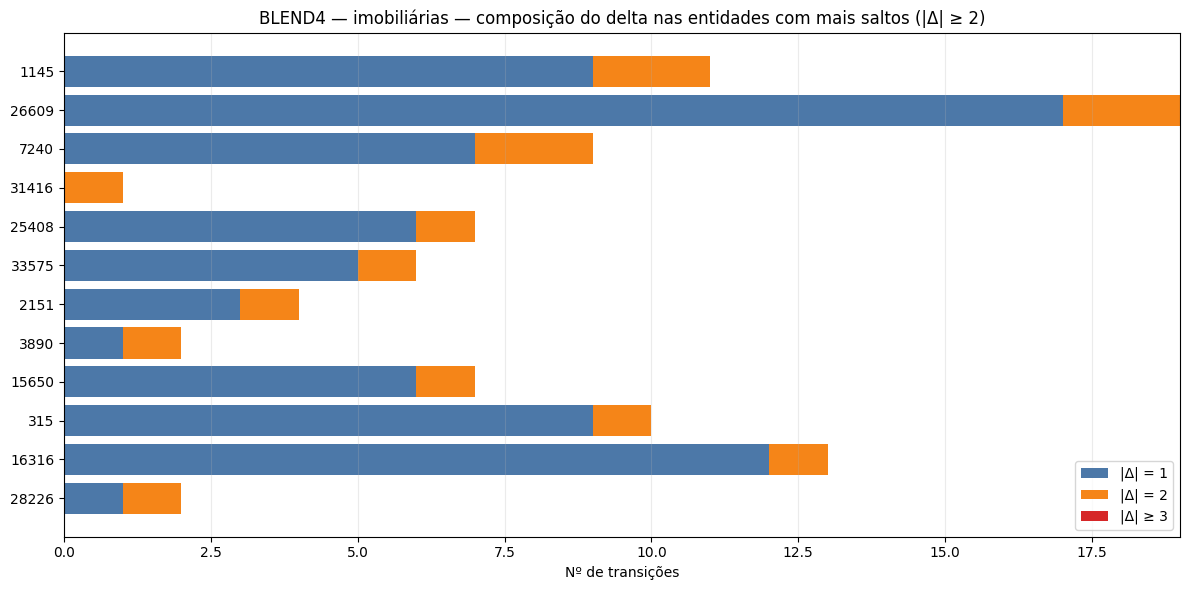

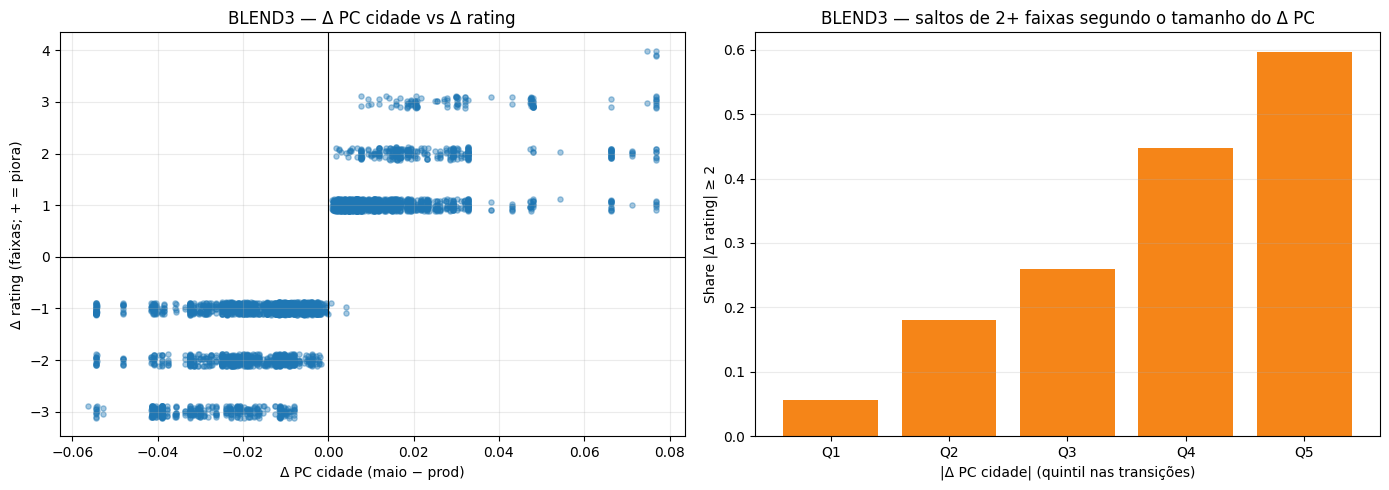

,n,share_d2plus,mean_abs_delta
dpc_q,,,
Q1,925,5.6%,1.06
Q2,974,18.0%,1.21
Q3,872,25.9%,1.30
Q4,956,44.8%,1.58
Q5,891,59.7%,1.90


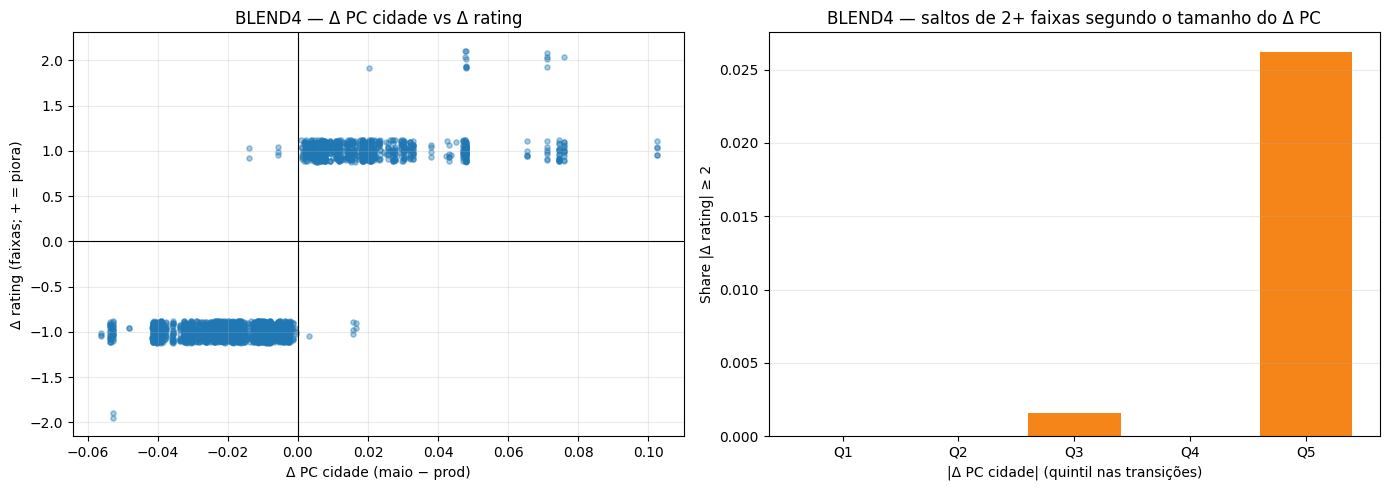

,n,share_d2plus,mean_abs_delta
dpc_q,,,
Q1,612,0.0%,1.00
Q2,571,0.0%,1.00
Q3,626,0.2%,1.00
Q4,572,0.0%,1.00
Q5,572,2.6%,1.03


In [48]:
def add_delta_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["abs_rating_delta"] = out["rating_delta"].abs()
    out["delta_bin"] = np.select(
        [
            ~out["changed"],
            out["abs_rating_delta"] == 1,
            out["abs_rating_delta"] == 2,
            out["abs_rating_delta"] >= 3,
        ],
        ["0 (estável)", "1 (vizinho)", "2 (pula 1 faixa)", "3+ (salto longo)"],
        default="sem rating",
    )
    return out


def delta_overview(df: pd.DataFrame, title: str) -> None:
    aux = add_delta_cols(df)
    chg = aux.loc[aux["changed"]].copy()
    order = ["1 (vizinho)", "2 (pula 1 faixa)", "3+ (salto longo)"]
    tab = (
        chg.groupby(["delta_bin", "sentido"], dropna=False)
        .size()
        .unstack("sentido", fill_value=0)
        .reindex(order)
        .reindex(columns=["melhora", "piora"], fill_value=0)
    )
    tab["total"] = tab["melhora"] + tab["piora"]
    tab["share"] = tab["total"] / tab["total"].sum()
    print(f"{title} — transições por |Δ rating|")
    display(tab.style.format({"melhora": "{:,.0f}", "piora": "{:,.0f}", "total": "{:,.0f}", "share": "{:.1%}"}))

    pair = (
        chg.groupby(["abs_rating_delta", "transition", "sentido"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
        .sort_values(["abs_rating_delta", "n"], ascending=[True, False])
    )
    print(f"{title} — pares de rating por |Δ|")
    display(pair.head(20).style.format({"abs_rating_delta": "{:.0f}", "n": "{:,.0f}"}))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(order))
    ax.bar(x - 0.18, tab["melhora"], width=0.36, label="melhora", color="#1f77b4")
    ax.bar(x + 0.18, tab["piora"], width=0.36, label="piora", color="#d62728")
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Nº de transições")
    ax.set_title(f"{title} — volume por magnitude do delta")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def entity_by_delta(
    df: pd.DataFrame,
    entity_col: str,
    title: str,
    extra: list = None,
    n: int = 15,
    min_eligible: int = 20,
) -> pd.DataFrame:
    """Eligible volume plus counts/rates of |Δ|=1, 2 and 3+ per city or agency."""
    extra = extra or []
    aux = add_delta_cols(df)
    keys = [entity_col] + extra

    base = (
        aux.groupby(keys, dropna=False)
        .agg(
            n=("changed", "size"),
            n_elegivel=("eligible", "sum"),
            n_transicao=("changed", "sum"),
            delta_pc_med=("delta_city_pc", "median"),
            abs_delta_pc_med=("abs_delta_city_pc", "median"),
        )
    )
    chg = aux.loc[aux["changed"]].copy()
    chg["d1"] = chg["abs_rating_delta"].eq(1)
    chg["d2"] = chg["abs_rating_delta"].eq(2)
    chg["d3"] = chg["abs_rating_delta"].ge(3)
    jumps = (
        chg.groupby(keys, dropna=False)
        .agg(
            n_delta1=("d1", "sum"),
            n_delta2=("d2", "sum"),
            n_delta3plus=("d3", "sum"),
            n_melhora=("sentido", lambda s: (s == "melhora").sum()),
            n_piora=("sentido", lambda s: (s == "piora").sum()),
            abs_delta_med=("abs_rating_delta", "median"),
            abs_delta_mean=("abs_rating_delta", "mean"),
        )
    )
    out = base.join(jumps, how="left")
    for col in ["n_delta1", "n_delta2", "n_delta3plus", "n_melhora", "n_piora"]:
        out[col] = out[col].fillna(0).astype(int)
    out["n_delta2plus"] = out["n_delta2"] + out["n_delta3plus"]
    out["taxa_transicao"] = out["n_transicao"] / out["n_elegivel"].replace(0, np.nan)
    out["taxa_delta1"] = out["n_delta1"] / out["n_elegivel"].replace(0, np.nan)
    out["taxa_delta2plus"] = out["n_delta2plus"] / out["n_elegivel"].replace(0, np.nan)
    out["share_delta2plus"] = out["n_delta2plus"] / out["n_transicao"].replace(0, np.nan)
    out = out.reset_index()

    fmt = {
        "n": "{:.0f}", "n_elegivel": "{:.0f}", "n_transicao": "{:.0f}",
        "n_delta1": "{:.0f}", "n_delta2": "{:.0f}", "n_delta3plus": "{:.0f}", "n_delta2plus": "{:.0f}",
        "n_melhora": "{:.0f}", "n_piora": "{:.0f}",
        "abs_delta_med": "{:.1f}", "abs_delta_mean": "{:.2f}",
        "delta_pc_med": "{:+.4f}", "abs_delta_pc_med": "{:.4f}",
        "taxa_transicao": "{:.1%}", "taxa_delta1": "{:.1%}",
        "taxa_delta2plus": "{:.1%}", "share_delta2plus": "{:.1%}",
    }
    show = [
        entity_col, *extra,
        "n_elegivel", "n_transicao", "n_delta1", "n_delta2", "n_delta3plus",
        "n_melhora", "n_piora", "abs_delta_mean",
        "taxa_transicao", "taxa_delta2plus", "share_delta2plus",
        "delta_pc_med", "abs_delta_pc_med",
    ]
    show = [c for c in show if c in out.columns]
    ranked = out.loc[out["n_elegivel"] >= min_eligible].copy()

    print(f"{title} — top {n} por volume de |Δ| = 1 (vizinho)")
    display(
        ranked.sort_values("n_delta1", ascending=False)
        .head(n).set_index(entity_col)[ [c for c in show if c != entity_col] ]
        .style.format(fmt, na_rep="—")
    )
    print(f"{title} — top {n} por volume de |Δ| ≥ 2 (pula faixa)")
    display(
        ranked.sort_values(["n_delta2plus", "n_delta2"], ascending=False)
        .head(n).set_index(entity_col)[ [c for c in show if c != entity_col] ]
        .style.format(fmt, na_rep="—")
    )
    print(f"{title} — top {n} por taxa de |Δ| ≥ 2 entre elegíveis (mín. {min_eligible} elegíveis)")
    display(
        ranked.sort_values("taxa_delta2plus", ascending=False)
        .head(n).set_index(entity_col)[ [c for c in show if c != entity_col] ]
        .style.format(fmt, na_rep="—")
    )
    return out


def plot_entity_delta(summary: pd.DataFrame, entity_col: str, title: str, n: int = 12) -> None:
    top = summary.sort_values("n_delta2plus", ascending=False).head(n).copy()
    if "imovel_cidade" in top.columns:
        labels = top["imovel_cidade"].fillna(top[entity_col].astype(str)) + " (" + top[entity_col].astype(str) + ")"
    else:
        labels = top[entity_col].astype(str)
    fig, ax = plt.subplots(figsize=(12, 6))
    y = np.arange(len(top))
    ax.barh(y, top["n_delta1"][::-1], label="|Δ| = 1", color="#4c78a8")
    ax.barh(y, top["n_delta2"][::-1], left=top["n_delta1"][::-1], label="|Δ| = 2", color="#f58518")
    ax.barh(
        y,
        top["n_delta3plus"][::-1],
        left=(top["n_delta1"] + top["n_delta2"])[::-1],
        label="|Δ| ≥ 3",
        color="#d62728",
    )
    ax.set_yticks(y)
    ax.set_yticklabels(labels[::-1])
    ax.set_xlabel("Nº de transições")
    ax.set_title(f"{title} — composição do delta nas entidades com mais saltos (|Δ| ≥ 2)")
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_pc_vs_rating_delta(df: pd.DataFrame, title: str) -> None:
    chg = add_delta_cols(df).loc[df["changed"]].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    jitter = np.random.default_rng(0).uniform(-0.12, 0.12, size=len(chg))
    ax.scatter(chg["delta_city_pc"], chg["rating_delta"] + jitter, s=14, alpha=0.4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Δ PC cidade (maio − prod)")
    ax.set_ylabel("Δ rating (faixas; + = piora)")
    ax.set_title(f"{title} — Δ PC cidade vs Δ rating")
    ax.grid(alpha=0.25)

    ax = axes[1]
    chg["dpc_q"] = pd.qcut(chg["abs_delta_city_pc"].fillna(0), 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop")
    rates = (
        chg.groupby("dpc_q", observed=True)
        .agg(
            n=("abs_rating_delta", "size"),
            share_d2plus=("abs_rating_delta", lambda s: s.ge(2).mean()),
            mean_abs_delta=("abs_rating_delta", "mean"),
        )
    )
    ax.bar(rates.index.astype(str), rates["share_d2plus"], color="#f58518")
    ax.set_xlabel("|Δ PC cidade| (quintil nas transições)")
    ax.set_ylabel("Share |Δ rating| ≥ 2")
    ax.set_title(f"{title} — saltos de 2+ faixas segundo o tamanho do Δ PC")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    display(rates.style.format({"n": "{:.0f}", "share_d2plus": "{:.1%}", "mean_abs_delta": "{:.2f}"}))


delta_overview(tr3, "BLEND3")
delta_overview(tr4, "BLEND4")

city_delta3 = entity_by_delta(tr3, "id_cidade_ibge", "BLEND3 — cidades", extra=["imovel_cidade", "imovel_uf"])
city_delta4 = entity_by_delta(tr4, "id_cidade_ibge", "BLEND4 — cidades", extra=["imovel_cidade", "imovel_uf"])
plot_entity_delta(city_delta3, "id_cidade_ibge", "BLEND3 — cidades")
plot_entity_delta(city_delta4, "id_cidade_ibge", "BLEND4 — cidades")

agency_delta3 = entity_by_delta(tr3, "id_imobiliaria", "BLEND3 — imobiliárias", min_eligible=10)
agency_delta4 = entity_by_delta(tr4, "id_imobiliaria", "BLEND4 — imobiliárias", min_eligible=10)
plot_entity_delta(agency_delta3, "id_imobiliaria", "BLEND3 — imobiliárias")
plot_entity_delta(agency_delta4, "id_imobiliaria", "BLEND4 — imobiliárias")

plot_pc_vs_rating_delta(tr3, "BLEND3")
plot_pc_vs_rating_delta(tr4, "BLEND4")


### Pioras de rating (A→B, B→C, …)

Aqui o recorte deixa de ser a magnitude do salto (|Δ| = 1, 2, 3+) e passa a ser **quem piorou de rating** no cenário city vs prod:

- **vizinhos**: A→B, B→C, C→D, D→E
- **saltos**: A→C, B→D, C→E, …

A pergunta é a mesma da seção anterior: as pioras se concentram em poucas cidades/imobiliárias — e se isso acompanha o Δ PC cidade.


BLEND3 — pioras de rating: 1,712 (37.1% das transições)
BLEND3 — pares


,transition,n
3,B → C,433
8,D → E,428
6,C → D,347
7,C → E,278
5,B → E,111
0,A → B,103
1,A → C,5
2,A → E,4
4,B → D,3


BLEND3 — pioras de rating (vizinhos vs saltos)


,n,share
transition,,
A → B,103,6.0%
B → C,433,25.3%
C → D,347,20.3%
D → E,428,25.0%
outros,401,23.4%


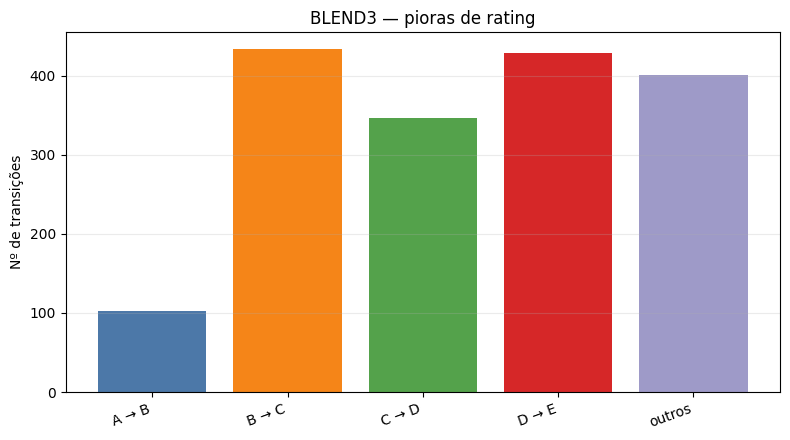

BLEND4 — pioras de rating: 888 (30.1% das transições)
BLEND4 — pares


,transition,n
5,D → E,261
4,C → D,218
0,A → B,215
2,B → C,180
3,B → D,11
1,A → C,3


BLEND4 — pioras de rating (vizinhos vs saltos)


,n,share
transition,,
A → B,215,24.2%
B → C,180,20.3%
C → D,218,24.5%
D → E,261,29.4%
outros,14,1.6%


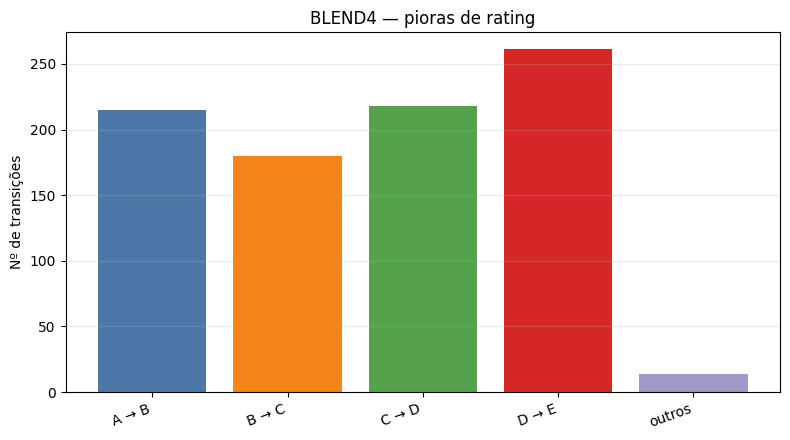

BLEND3 — cidades — top 15 por volume de n_piora


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_piora,A → B,B → C,C → D,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_cidade_ibge,,,,,,,,,,,,,,,
3524402,Jacareí,SP,726,89,89,2,32,22,21,12,12.3%,100.0%,+0.0108,0.0108,58.0
3552205,Sorocaba,SP,648,87,87,6,28,20,21,12,13.4%,100.0%,+0.0066,0.0066,50.0
4314100,Passo Fundo,RS,329,85,85,8,13,6,11,47,25.8%,100.0%,+0.0327,0.0327,42.0
4106902,Curitiba,PR,849,78,78,4,26,20,24,4,9.2%,100.0%,+0.0049,0.0049,78.0
3507506,Botucatu,SP,340,64,64,3,19,11,10,21,18.8%,100.0%,+0.0162,0.0162,56.0
5107909,Sinop,MT,84,60,60,6,11,0,1,42,71.4%,100.0%,+0.0662,0.0662,112.0
4305108,Caxias Do Sul,RS,870,72,59,0,3,31,25,0,6.8%,81.9%,+0.0068,0.0068,54.0
3304557,Rio De Janeiro,RJ,619,55,55,1,17,16,20,1,8.9%,100.0%,+0.0076,0.0076,92.0
4218004,Tijucas,SC,323,55,55,2,12,4,8,29,17.0%,100.0%,+0.0293,0.0293,61.0


BLEND3 — cidades — top 15 por taxa de n_piora entre elegíveis (mín. 20 elegíveis)


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_piora,A → B,B → C,C → D,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_cidade_ibge,,,,,,,,,,,,,,,
5107909,Sinop,MT,84,60,60,6,11,0,1,42,71.4%,100.0%,+0.0662,0.0662,112.0
3500709,Agudos,SP,45,17,17,5,7,1,0,4,37.8%,100.0%,+0.0250,0.0250,59.5
4218202,Timbó,SC,30,11,11,1,3,1,2,4,36.7%,100.0%,+0.0275,0.0275,56.0
3301702,Duque De Caxias,RJ,40,13,13,0,5,2,0,6,32.5%,100.0%,+0.0285,0.0285,66.0
3551702,Sertãozinho,SP,35,11,11,1,3,0,2,5,31.4%,100.0%,+0.0115,0.0115,98.0
2403251,Parnamirim,RN,42,13,13,2,4,1,3,3,31.0%,100.0%,+0.0256,0.0256,67.0
3541406,Presidente Prudente,SP,84,23,23,3,10,5,2,3,27.4%,100.0%,+0.0217,0.0217,73.0
4307005,Erechim,RS,53,14,14,2,5,1,1,5,26.4%,100.0%,+0.0236,0.0236,62.5
4314100,Passo Fundo,RS,329,85,85,8,13,6,11,47,25.8%,100.0%,+0.0327,0.0327,42.0


BLEND4 — cidades — top 15 por volume de n_piora


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_piora,A → B,B → C,C → D,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_cidade_ibge,,,,,,,,,,,,,,,
4314100,Passo Fundo,RS,234,65,65,17,11,13,18,6,27.8%,100.0%,+0.0480,0.0480,52.5
3552205,Sorocaba,SP,534,36,36,7,12,4,13,0,6.7%,100.0%,+0.0076,0.0076,37.0
3507506,Botucatu,SP,230,35,35,12,2,10,11,0,15.2%,100.0%,+0.0186,0.0186,45.0
3524402,Jacareí,SP,550,34,34,5,7,14,8,0,6.2%,100.0%,+0.0118,0.0118,40.0
5218805,Rio Verde,GO,71,27,27,11,0,2,10,4,38.0%,100.0%,+0.0746,0.0746,43.0
3506508,Birigui,SP,204,25,25,7,10,4,4,0,12.3%,100.0%,+0.0208,0.0208,31.0
3529401,Mauá,SP,151,24,24,4,10,4,6,0,15.9%,100.0%,+0.0182,0.0182,41.0
4204202,Chapecó,SC,247,24,24,3,5,9,7,0,9.7%,100.0%,+0.0203,0.0203,68.0
4106902,Curitiba,PR,827,23,23,5,9,5,4,0,2.8%,100.0%,+0.0078,0.0078,62.0


BLEND4 — cidades — top 15 por taxa de n_piora entre elegíveis (mín. 20 elegíveis)


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_piora,A → B,B → C,C → D,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_cidade_ibge,,,,,,,,,,,,,,,
5218805,Rio Verde,GO,71,27,27,11,0,2,10,4,38.0%,100.0%,+0.0746,0.0746,43.0
5107909,Sinop,MT,54,18,18,3,4,6,4,1,33.3%,100.0%,+0.0760,0.0760,34.0
4118204,Paranaguá,PR,73,22,22,5,5,4,8,0,30.1%,100.0%,+0.0472,0.0472,29.0
4314100,Passo Fundo,RS,234,65,65,17,11,13,18,6,27.8%,100.0%,+0.0480,0.0480,52.5
4307005,Erechim,RS,56,13,13,7,3,2,1,0,23.2%,100.0%,+0.0277,0.0277,32.0
4205902,Gaspar,SC,44,10,10,2,3,2,3,0,22.7%,100.0%,+0.0256,0.0256,31.0
3500709,Agudos,SP,31,7,7,1,3,0,3,0,22.6%,100.0%,+0.0430,0.0430,54.0
3305802,Teresópolis,RJ,56,12,12,2,3,7,0,0,21.4%,100.0%,+0.0321,0.0321,28.0
3526803,Lençóis Paulista,SP,77,16,16,1,1,5,8,1,20.8%,100.0%,+0.0203,0.0203,29.5


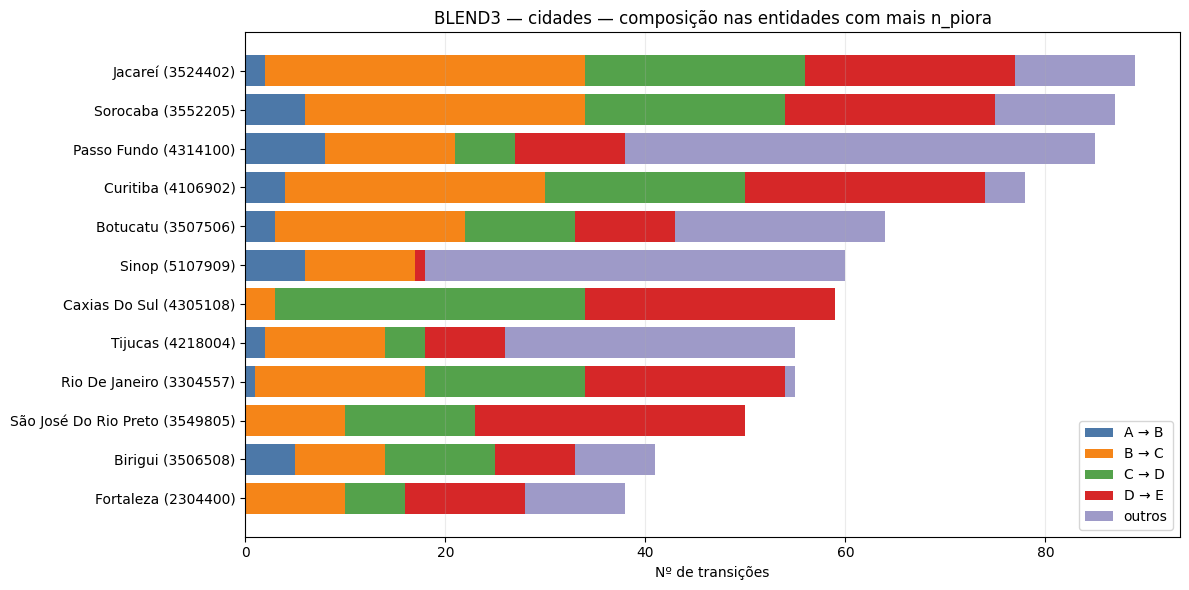

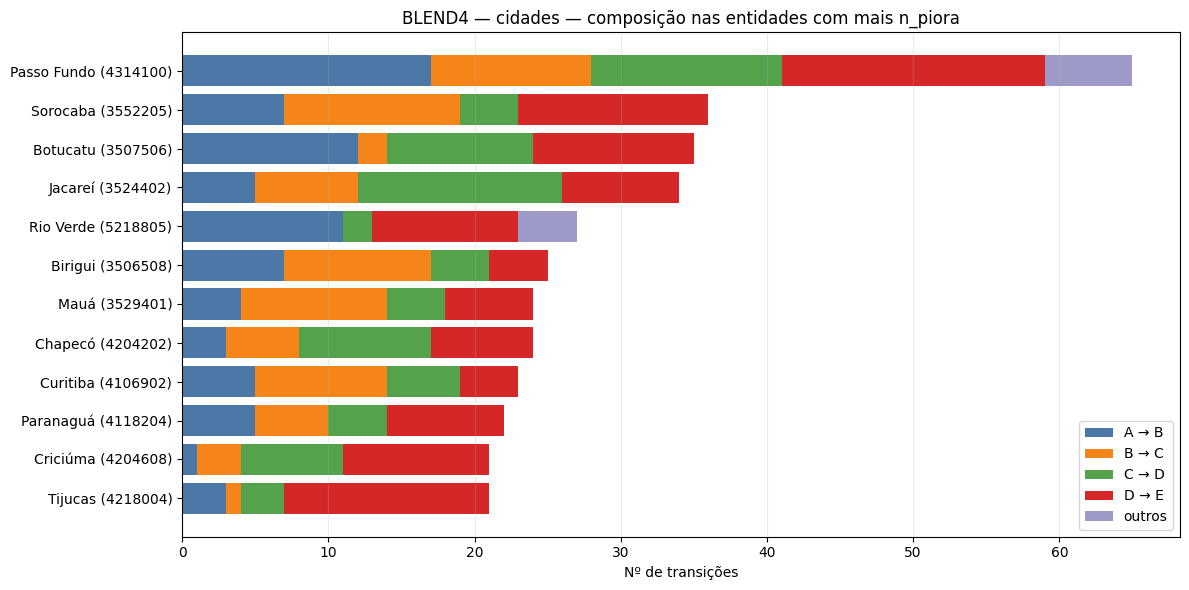

BLEND3 — imobiliárias — top 15 por volume de n_piora


,n_elegivel,n_transicao,n_piora,A → B,B → C,C → D,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_imobiliaria,,,,,,,,,,,,,
16316,73,48,48,4,10,0,0,34,65.8%,100.0%,+0.0662,0.0662,104.0
315,61,23,23,4,3,1,2,13,37.7%,100.0%,+0.0327,0.0327,32.5
11985,129,19,19,0,8,3,4,4,14.7%,100.0%,+0.0066,0.0066,40.0
2687,798,47,18,0,6,3,8,1,2.3%,38.3%,+0.0013,0.0013,50.0
25380,73,18,18,0,5,2,3,8,24.7%,100.0%,+0.0293,0.0293,56.0
580,40,15,15,0,2,0,4,9,37.5%,100.0%,+0.0194,0.0194,27.0
45829,154,23,15,2,10,3,0,0,9.7%,65.2%,+0.0049,0.0078,52.0
969,117,16,15,0,4,3,8,0,12.8%,93.8%,+0.0108,0.0108,57.0
3636,146,14,14,0,5,3,5,1,9.6%,100.0%,+0.0108,0.0108,68.0


BLEND3 — imobiliárias — top 15 por taxa de n_piora entre elegíveis (mín. 10 elegíveis)


,n_elegivel,n_transicao,n_piora,A → B,B → C,C → D,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_imobiliaria,,,,,,,,,,,,,
16316,73,48,48,4,10,0,0,34,65.8%,100.0%,+0.0662,0.0662,104.0
10761,17,8,8,0,3,2,0,3,47.1%,100.0%,+0.0285,0.0285,60.0
30686,24,11,11,2,5,1,0,3,45.8%,100.0%,+0.0250,0.0250,62.5
12893,14,6,6,1,0,0,1,4,42.9%,100.0%,+0.0120,0.0120,77.0
44917,20,8,8,0,1,1,0,6,40.0%,100.0%,+0.0327,0.0327,50.0
40484,15,6,6,1,2,2,0,1,40.0%,100.0%,+0.0217,0.0217,89.0
3223,10,4,4,2,2,0,0,0,40.0%,100.0%,+0.0043,0.0043,77.0
1396,10,4,4,0,1,0,0,3,40.0%,100.0%,+0.0327,0.0327,70.5
24171,10,4,4,0,1,1,0,2,40.0%,100.0%,+0.0066,0.0066,37.0


BLEND4 — imobiliárias — top 15 por volume de n_piora


,n_elegivel,n_transicao,n_piora,A → B,B → C,C → D,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_imobiliaria,,,,,,,,,,,,,
16316,39,13,13,1,4,4,3,1,33.3%,100.0%,+0.0760,0.0760,30.0
1644,37,12,12,2,2,1,7,0,32.4%,100.0%,+0.0480,0.0480,38.0
1145,39,11,11,4,2,2,1,2,28.2%,100.0%,+0.0480,0.0480,51.0
1765,26,11,11,2,3,0,6,0,42.3%,100.0%,+0.0315,0.0315,25.0
315,42,10,10,4,3,1,1,1,23.8%,100.0%,+0.0480,0.0480,72.0
7240,36,9,9,1,1,1,4,2,25.0%,100.0%,+0.0476,0.0476,65.0
11985,97,8,8,0,4,0,4,0,8.2%,100.0%,+0.0076,0.0076,35.0
13554,95,8,8,3,3,1,1,0,8.4%,100.0%,+0.0203,0.0203,59.0
480,34,8,8,4,2,1,1,0,23.5%,100.0%,+0.0277,0.0277,30.5


BLEND4 — imobiliárias — top 15 por taxa de n_piora entre elegíveis (mín. 10 elegíveis)


,n_elegivel,n_transicao,n_piora,A → B,B → C,C → D,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_imobiliaria,,,,,,,,,,,,,
8038,11,5,5,1,1,1,2,0,45.5%,100.0%,+0.0208,0.0208,24.0
25408,16,7,7,1,1,1,3,1,43.8%,100.0%,+0.0480,0.0480,27.0
1765,26,11,11,2,3,0,6,0,42.3%,100.0%,+0.0315,0.0315,25.0
12893,17,7,7,1,2,4,0,0,41.2%,100.0%,+0.0321,0.0321,21.5
16316,39,13,13,1,4,4,3,1,33.3%,100.0%,+0.0760,0.0760,30.0
3997,12,4,4,1,1,0,2,0,33.3%,100.0%,+0.0205,0.0205,31.5
1644,37,12,12,2,2,1,7,0,32.4%,100.0%,+0.0480,0.0480,38.0
33575,19,6,6,3,0,1,1,1,31.6%,100.0%,+0.0746,0.0746,36.0
34890,23,7,7,0,1,3,3,0,30.4%,100.0%,+0.0302,0.0302,22.0


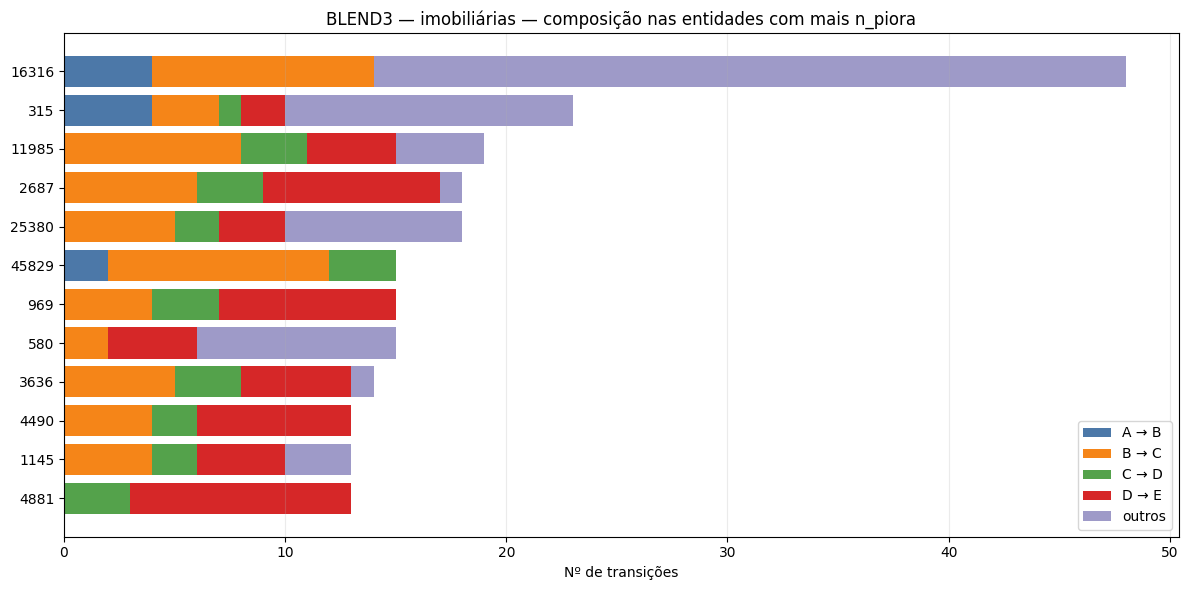

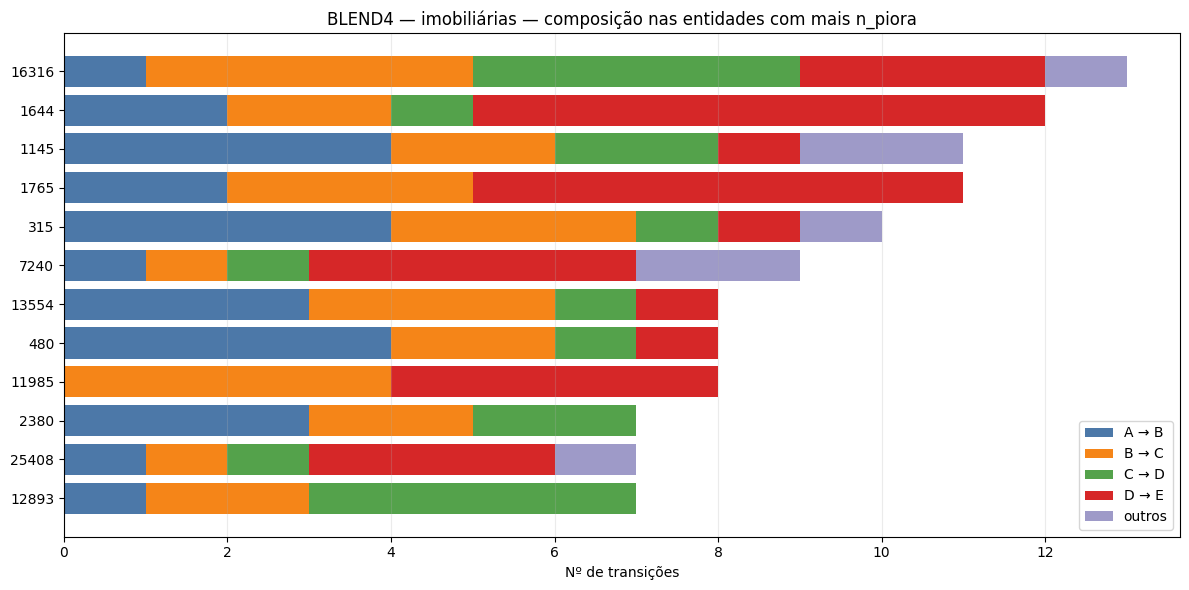

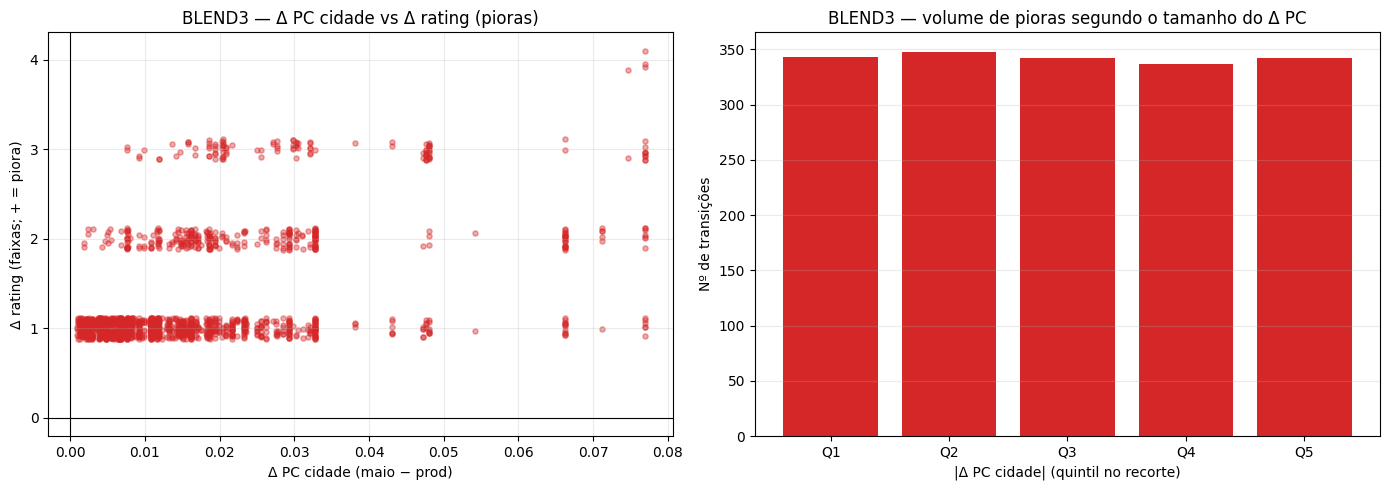

,n,mean_delta,share_to_e
dpc_q,,,
Q1,343,+1.03,45.2%
Q2,348,+1.07,39.7%
Q3,342,+1.18,41.8%
Q4,337,+1.47,51.0%
Q5,342,+1.77,62.3%


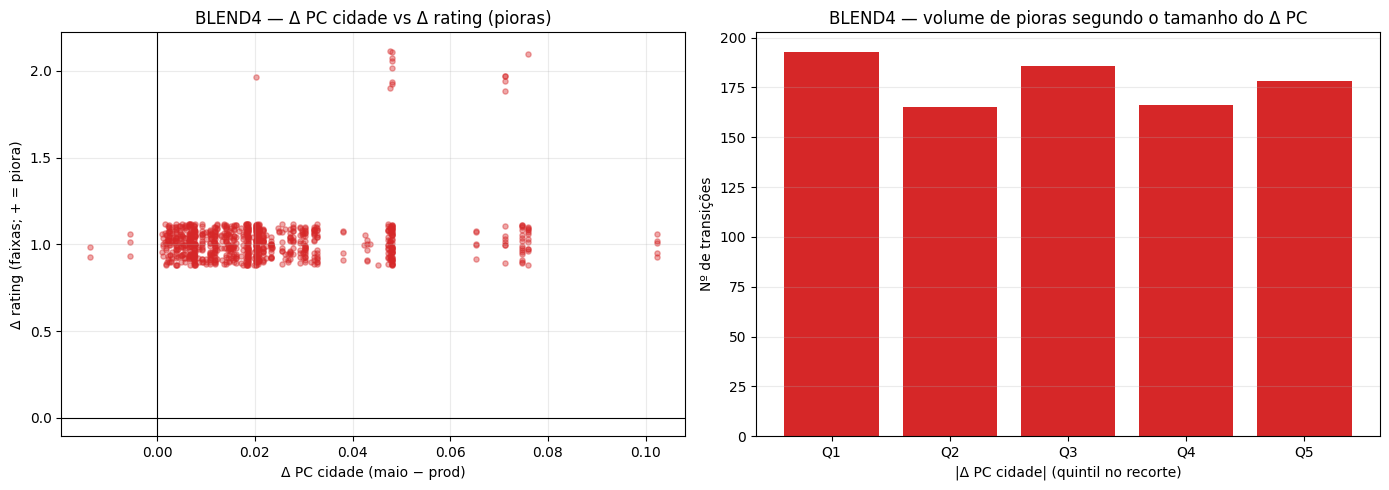

,n,mean_delta,share_to_e
dpc_q,,,
Q1,193,+1.00,31.6%
Q2,165,+1.00,25.5%
Q3,186,+1.01,31.2%
Q4,166,+1.00,29.5%
Q5,178,+1.07,28.7%


In [49]:
PAIR_WORSEN_NEIGHBOR = ["A → B", "B → C", "C → D", "D → E"]
PAIR_TO_E = ["A → E", "B → E", "C → E", "D → E"]
PAIR_COLORS = {
    "A → B": "#4c78a8",
    "B → C": "#f58518",
    "C → D": "#54a24b",
    "D → E": "#d62728",
    "A → E": "#4c78a8",
    "B → E": "#f58518",
    "C → E": "#54a24b",
    "D → E": "#d62728",
    "outros": "#9e9ac8",
}


def flag_rating_moves(df: pd.DataFrame) -> pd.DataFrame:
    """Neighbor worsenings, jumps and moves into rating E."""
    out = df.copy()
    out["is_worsen"] = out["sentido"].eq("piora")
    out["is_to_e"] = out["changed"] & out["rating_city"].eq("E") & out["rating_prod"].ne("E")
    return out


def pair_overview(
    df: pd.DataFrame,
    title: str,
    mask_col: str,
    pair_order: list,
    extra_label: str,
) -> None:
    aux = flag_rating_moves(df)
    sub = aux.loc[aux[mask_col]].copy()
    n_chg = int(aux["changed"].sum())
    n_sub = len(sub)
    share_txt = f" ({n_sub / n_chg:.1%} das transições)" if n_chg else ""
    print(f"{title} — {extra_label}: {n_sub:,}{share_txt}")

    pair = (
        sub.groupby("transition", dropna=False)
        .size()
        .rename("n")
        .reset_index()
        .sort_values("n", ascending=False)
    )
    print(f"{title} — pares")
    display(pair.style.format({"n": "{:,.0f}"}))

    counts = sub["transition"].value_counts()
    tab = counts.reindex(pair_order).fillna(0).astype(int).rename("n").to_frame()
    others = int(n_sub - tab["n"].sum())
    if others:
        tab.loc["outros"] = others
    tab["share"] = tab["n"] / tab["n"].sum() if tab["n"].sum() else np.nan
    if others:
        print(f"{title} — {extra_label} (vizinhos vs saltos)")
        display(tab.style.format({"n": "{:,.0f}", "share": "{:.1%}"}))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors = [PAIR_COLORS.get(idx, "#9e9ac8") for idx in tab.index]
    ax.bar(tab.index.astype(str), tab["n"], color=colors)
    ax.set_ylabel("Nº de transições")
    ax.set_title(f"{title} — {extra_label}")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


def entity_by_pairs(
    df: pd.DataFrame,
    entity_col: str,
    title: str,
    mask_col: str,
    pair_order: list,
    event_label: str,
    extra: list = None,
    n: int = 15,
    min_eligible: int = 20,
) -> pd.DataFrame:
    """Eligible volume plus counts/rates of a rating-move subset per city or agency."""
    extra = extra or []
    aux = flag_rating_moves(df)
    keys = [entity_col] + extra

    base = (
        aux.groupby(keys, dropna=False)
        .agg(
            n=("changed", "size"),
            n_elegivel=("eligible", "sum"),
            n_transicao=("changed", "sum"),
            n_event=(mask_col, "sum"),
            delta_pc_med=("delta_city_pc", "median"),
            abs_delta_pc_med=("abs_delta_city_pc", "median"),
            dist_med=("dist_cutoff", "median"),
        )
    )
    sub = aux.loc[aux[mask_col]].copy()
    if sub.empty:
        pair_n = pd.DataFrame(index=base.index)
    else:
        pair_n = (
            sub.groupby(keys + ["transition"], dropna=False)
            .size()
            .unstack("transition", fill_value=0)
        )
    for p in pair_order:
        if p not in pair_n.columns:
            pair_n[p] = 0
    leftover = [c for c in pair_n.columns if c not in pair_order]
    pair_n["outros"] = pair_n[leftover].sum(axis=1) if leftover else 0
    pair_n = pair_n.reindex(columns=pair_order + ["outros"], fill_value=0)

    out = base.join(pair_n, how="left")
    for col in pair_order + ["outros", "n_event"]:
        if col in out.columns:
            out[col] = out[col].fillna(0).astype(int)
    out = out.rename(columns={"n_event": event_label})
    out["taxa"] = out[event_label] / out["n_elegivel"].replace(0, np.nan)
    out["share_transicao"] = out[event_label] / out["n_transicao"].replace(0, np.nan)
    out = out.reset_index()

    fmt = {
        "n": "{:.0f}", "n_elegivel": "{:.0f}", "n_transicao": "{:.0f}",
        event_label: "{:.0f}", "outros": "{:.0f}",
        "delta_pc_med": "{:+.4f}", "abs_delta_pc_med": "{:.4f}", "dist_med": "{:.1f}",
        "taxa": "{:.1%}", "share_transicao": "{:.1%}",
    }
    for p in pair_order:
        fmt[p] = "{:.0f}"
    show = [
        entity_col, *extra,
        "n_elegivel", "n_transicao", event_label, *pair_order, "outros",
        "taxa", "share_transicao", "delta_pc_med", "abs_delta_pc_med", "dist_med",
    ]
    show = [c for c in show if c in out.columns]
    ranked = out.loc[out["n_elegivel"] >= min_eligible].copy()

    print(f"{title} — top {n} por volume de {event_label}")
    display(
        ranked.sort_values(event_label, ascending=False)
        .head(n).set_index(entity_col)[[c for c in show if c != entity_col]]
        .style.format(fmt, na_rep="—")
    )
    print(f"{title} — top {n} por taxa de {event_label} entre elegíveis (mín. {min_eligible} elegíveis)")
    display(
        ranked.sort_values("taxa", ascending=False)
        .head(n).set_index(entity_col)[[c for c in show if c != entity_col]]
        .style.format(fmt, na_rep="—")
    )
    return out


def plot_entity_pairs(
    summary: pd.DataFrame,
    entity_col: str,
    title: str,
    pair_order: list,
    event_label: str,
    n: int = 12,
) -> None:
    top = summary.sort_values(event_label, ascending=False).head(n).copy()
    if top.empty or top[event_label].sum() == 0:
        print(f"{title} — sem eventos para plotar")
        return
    if "imovel_cidade" in top.columns:
        labels = top["imovel_cidade"].fillna(top[entity_col].astype(str)) + " (" + top[entity_col].astype(str) + ")"
    else:
        labels = top[entity_col].astype(str)
    cols = [c for c in pair_order + ["outros"] if c in top.columns and top[c].sum() > 0]
    fig, ax = plt.subplots(figsize=(12, 6))
    y = np.arange(len(top))
    left = np.zeros(len(top))
    for col in cols:
        vals = top[col].to_numpy()
        ax.barh(y, vals[::-1], left=left[::-1], label=col, color=PAIR_COLORS.get(col, "#9e9ac8"))
        left = left + vals
    ax.set_yticks(y)
    ax.set_yticklabels(labels[::-1])
    ax.set_xlabel("Nº de transições")
    ax.set_title(f"{title} — composição nas entidades com mais {event_label}")
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_pc_vs_move(df: pd.DataFrame, title: str, mask_col: str, extra_label: str) -> None:
    aux = flag_rating_moves(df)
    sub = aux.loc[aux[mask_col]].copy()
    if sub.empty:
        print(f"{title} — sem {extra_label} para plotar")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    jitter = np.random.default_rng(0).uniform(-0.12, 0.12, size=len(sub))
    ax.scatter(sub["delta_city_pc"], sub["rating_delta"] + jitter, s=14, alpha=0.4, color="#d62728")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Δ PC cidade (maio − prod)")
    ax.set_ylabel("Δ rating (faixas; + = piora)")
    ax.set_title(f"{title} — Δ PC cidade vs Δ rating ({extra_label})")
    ax.grid(alpha=0.25)

    ax = axes[1]
    sub["dpc_q"] = pd.qcut(
        sub["abs_delta_city_pc"].fillna(0), 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop"
    )
    rates = (
        sub.groupby("dpc_q", observed=True)
        .agg(
            n=("rating_delta", "size"),
            mean_delta=("rating_delta", "mean"),
            share_to_e=("is_to_e", "mean"),
        )
    )
    ax.bar(rates.index.astype(str), rates["n"], color="#d62728")
    ax.set_xlabel("|Δ PC cidade| (quintil no recorte)")
    ax.set_ylabel("Nº de transições")
    ax.set_title(f"{title} — volume de {extra_label} segundo o tamanho do Δ PC")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    fmt_rates = {"n": "{:.0f}", "mean_delta": "{:+.2f}"}
    if rates["share_to_e"].lt(1).any():
        fmt_rates["share_to_e"] = "{:.1%}"
    else:
        rates = rates.drop(columns=["share_to_e"])
    display(rates.style.format(fmt_rates))


pair_overview(tr3, "BLEND3", "is_worsen", PAIR_WORSEN_NEIGHBOR, "pioras de rating")
pair_overview(tr4, "BLEND4", "is_worsen", PAIR_WORSEN_NEIGHBOR, "pioras de rating")

city_worsen3 = entity_by_pairs(
    tr3, "id_cidade_ibge", "BLEND3 — cidades", "is_worsen", PAIR_WORSEN_NEIGHBOR, "n_piora",
    extra=["imovel_cidade", "imovel_uf"],
)
city_worsen4 = entity_by_pairs(
    tr4, "id_cidade_ibge", "BLEND4 — cidades", "is_worsen", PAIR_WORSEN_NEIGHBOR, "n_piora",
    extra=["imovel_cidade", "imovel_uf"],
)
plot_entity_pairs(city_worsen3, "id_cidade_ibge", "BLEND3 — cidades", PAIR_WORSEN_NEIGHBOR, "n_piora")
plot_entity_pairs(city_worsen4, "id_cidade_ibge", "BLEND4 — cidades", PAIR_WORSEN_NEIGHBOR, "n_piora")

agency_worsen3 = entity_by_pairs(
    tr3, "id_imobiliaria", "BLEND3 — imobiliárias", "is_worsen", PAIR_WORSEN_NEIGHBOR, "n_piora",
    min_eligible=10,
)
agency_worsen4 = entity_by_pairs(
    tr4, "id_imobiliaria", "BLEND4 — imobiliárias", "is_worsen", PAIR_WORSEN_NEIGHBOR, "n_piora",
    min_eligible=10,
)
plot_entity_pairs(agency_worsen3, "id_imobiliaria", "BLEND3 — imobiliárias", PAIR_WORSEN_NEIGHBOR, "n_piora")
plot_entity_pairs(agency_worsen4, "id_imobiliaria", "BLEND4 — imobiliárias", PAIR_WORSEN_NEIGHBOR, "n_piora")

plot_pc_vs_move(tr3, "BLEND3", "is_worsen", "pioras")
plot_pc_vs_move(tr4, "BLEND4", "is_worsen", "pioras")


### Transições para o Rating E (X→E)

Subconjunto das pioras em que o rating no cenário city vira **E**, qualquer origem (A/B/C/D → E). Inclui o vizinho D→E e os saltos (C→E, B→E, A→E).

A pergunta: quem vai para E está espalhado ou concentrado nas mesmas cidades/imobiliárias — e se o Δ PC cidade nesses casos é sistematicamente maior.


BLEND3 — idas para E (X → E): 821 (17.8% das transições)
BLEND3 — pares


,transition,n
3,D → E,428
2,C → E,278
1,B → E,111
0,A → E,4


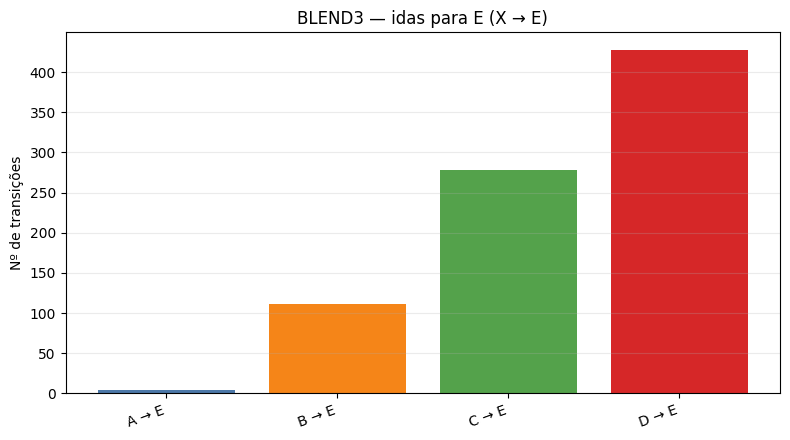

BLEND4 — idas para E (X → E): 261 (8.8% das transições)
BLEND4 — pares


,transition,n
0,D → E,261


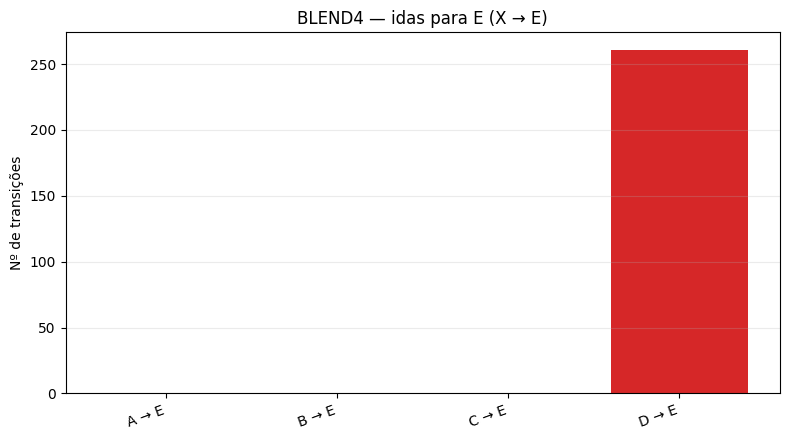

BLEND3 — cidades — top 15 por volume de n_para_E


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_para_E,A → E,B → E,C → E,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_cidade_ibge,,,,,,,,,,,,,,,
4314100,Passo Fundo,RS,329,85,58,0,13,34,11,0,17.6%,68.2%,+0.0327,0.0327,42.0
4218004,Tijucas,SC,323,55,37,0,4,25,8,0,11.5%,67.3%,+0.0293,0.0293,61.0
5107909,Sinop,MT,84,60,35,3,11,20,1,0,41.7%,58.3%,+0.0662,0.0662,112.0
3524402,Jacareí,SP,726,89,33,0,2,10,21,0,4.5%,37.1%,+0.0108,0.0108,58.0
3552205,Sorocaba,SP,648,87,33,0,1,11,21,0,5.1%,37.9%,+0.0066,0.0066,50.0
3507506,Botucatu,SP,340,64,31,0,2,19,10,0,9.1%,48.4%,+0.0162,0.0162,56.0
4106902,Curitiba,PR,849,78,28,0,0,4,24,0,3.3%,35.9%,+0.0049,0.0049,78.0
3549805,São José Do Rio Preto,SP,584,53,27,0,0,0,27,0,4.6%,50.9%,+0.0069,0.0069,46.0
4305108,Caxias Do Sul,RS,870,72,25,0,0,0,25,0,2.9%,34.7%,+0.0068,0.0068,54.0


BLEND3 — cidades — top 15 por taxa de n_para_E entre elegíveis (mín. 20 elegíveis)


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_para_E,A → E,B → E,C → E,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_cidade_ibge,,,,,,,,,,,,,,,
5107909,Sinop,MT,84,60,35,3,11,20,1,0,41.7%,58.3%,+0.0662,0.0662,112.0
4218202,Timbó,SC,30,11,6,0,1,3,2,0,20.0%,54.5%,+0.0275,0.0275,56.0
3551702,Sertãozinho,SP,35,11,7,0,5,0,2,0,20.0%,63.6%,+0.0115,0.0115,98.0
4314100,Passo Fundo,RS,329,85,58,0,13,34,11,0,17.6%,68.2%,+0.0327,0.0327,42.0
3305802,Teresópolis,RJ,56,13,9,0,5,2,2,0,16.1%,69.2%,+0.0120,0.0120,81.0
3511508,Cerquilho,SP,53,12,8,0,2,6,0,0,15.1%,66.7%,+0.0168,0.0168,63.5
3301702,Duque De Caxias,RJ,40,13,6,0,0,6,0,0,15.0%,46.2%,+0.0285,0.0285,66.0
3526803,Lençóis Paulista,SP,136,29,20,0,6,8,6,0,14.7%,69.0%,+0.0194,0.0194,31.0
2403251,Parnamirim,RN,42,13,6,0,0,3,3,0,14.3%,46.2%,+0.0256,0.0256,67.0


BLEND4 — cidades — top 15 por volume de n_para_E


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_para_E,A → E,B → E,C → E,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_cidade_ibge,,,,,,,,,,,,,,,
4314100,Passo Fundo,RS,234,65,18,0,0,0,18,0,7.7%,27.7%,+0.0480,0.0480,52.5
4218004,Tijucas,SC,181,21,14,0,0,0,14,0,7.7%,66.7%,+0.0185,0.0185,40.0
3552205,Sorocaba,SP,534,36,13,0,0,0,13,0,2.4%,36.1%,+0.0076,0.0076,37.0
3507506,Botucatu,SP,230,35,11,0,0,0,11,0,4.8%,31.4%,+0.0186,0.0186,45.0
5218805,Rio Verde,GO,71,27,10,0,0,0,10,0,14.1%,37.0%,+0.0746,0.0746,43.0
4204608,Criciúma,SC,223,21,10,0,0,0,10,0,4.5%,47.6%,+0.0142,0.0142,50.0
4125506,São José Dos Pinhais,PR,161,19,9,0,0,0,9,0,5.6%,47.4%,+0.0216,0.0216,28.0
3526803,Lençóis Paulista,SP,77,16,8,0,0,0,8,0,10.4%,50.0%,+0.0203,0.0203,29.5
4118204,Paranaguá,PR,73,22,8,0,0,0,8,0,11.0%,36.4%,+0.0472,0.0472,29.0


BLEND4 — cidades — top 15 por taxa de n_para_E entre elegíveis (mín. 20 elegíveis)


,imovel_cidade,imovel_uf,n_elegivel,n_transicao,n_para_E,A → E,B → E,C → E,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_cidade_ibge,,,,,,,,,,,,,,,
5218805,Rio Verde,GO,71,27,10,0,0,0,10,0,14.1%,37.0%,+0.0746,0.0746,43.0
4118204,Paranaguá,PR,73,22,8,0,0,0,8,0,11.0%,36.4%,+0.0472,0.0472,29.0
3526803,Lençóis Paulista,SP,77,16,8,0,0,0,8,0,10.4%,50.0%,+0.0203,0.0203,29.5
3500709,Agudos,SP,31,7,3,0,0,0,3,0,9.7%,42.9%,+0.0430,0.0430,54.0
4303103,Cachoeirinha,RS,91,18,8,0,0,0,8,0,8.8%,44.4%,+0.0476,0.0476,44.0
4218004,Tijucas,SC,181,21,14,0,0,0,14,0,7.7%,66.7%,+0.0185,0.0185,40.0
4314100,Passo Fundo,RS,234,65,18,0,0,0,18,0,7.7%,27.7%,+0.0480,0.0480,52.5
5107909,Sinop,MT,54,18,4,0,0,0,4,0,7.4%,22.2%,+0.0760,0.0760,34.0
4205902,Gaspar,SC,44,10,3,0,0,0,3,0,6.8%,30.0%,+0.0256,0.0256,31.0


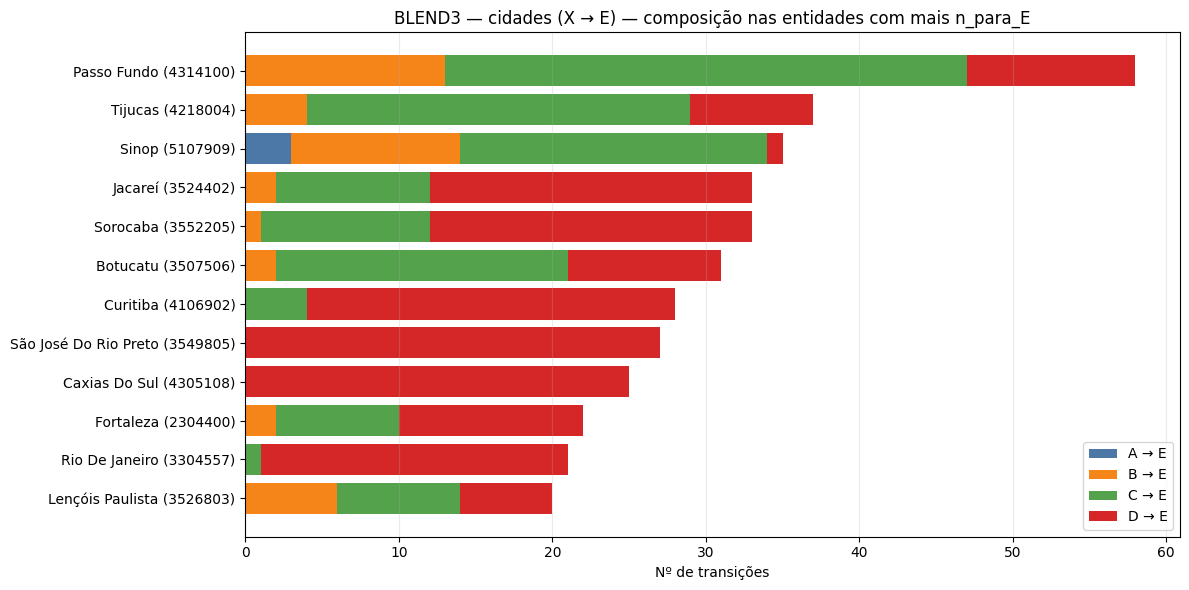

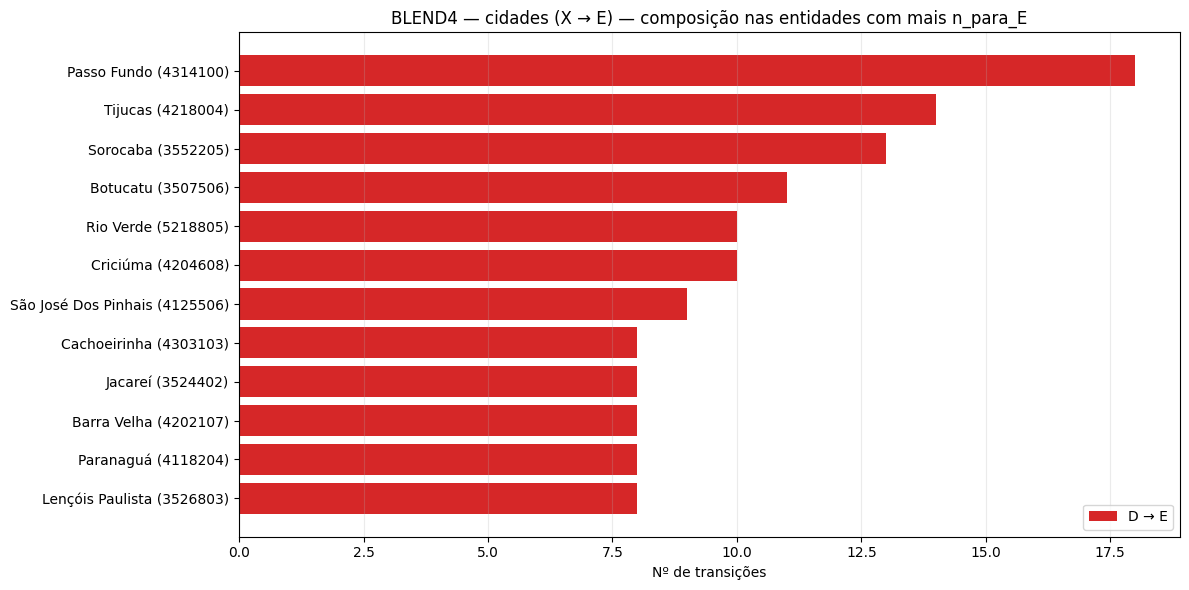

BLEND3 — imobiliárias — top 15 por volume de n_para_E


,n_elegivel,n_transicao,n_para_E,A → E,B → E,C → E,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_imobiliaria,,,,,,,,,,,,,
16316,73,48,27,2,9,16,0,0,37.0%,56.2%,+0.0662,0.0662,104.0
315,61,23,15,0,5,8,2,0,24.6%,65.2%,+0.0327,0.0327,32.5
580,40,15,13,0,4,5,4,0,32.5%,86.7%,+0.0194,0.0194,27.0
25380,73,18,11,0,1,7,3,0,15.1%,61.1%,+0.0293,0.0293,56.0
4881,80,13,10,0,0,0,10,0,12.5%,76.9%,+0.0049,0.0049,130.0
2687,798,47,9,0,0,1,8,0,1.1%,19.1%,+0.0013,0.0013,50.0
10913,88,13,9,0,2,6,1,0,10.2%,69.2%,+0.0293,0.0293,50.0
969,117,16,8,0,0,0,8,0,6.8%,50.0%,+0.0108,0.0108,57.0
11985,129,19,8,0,0,4,4,0,6.2%,42.1%,+0.0066,0.0066,40.0


BLEND3 — imobiliárias — top 15 por taxa de n_para_E entre elegíveis (mín. 10 elegíveis)


,n_elegivel,n_transicao,n_para_E,A → E,B → E,C → E,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_imobiliaria,,,,,,,,,,,,,
16316,73,48,27,2,9,16,0,0,37.0%,56.2%,+0.0662,0.0662,104.0
8277,14,5,5,0,0,4,1,0,35.7%,100.0%,+0.0712,0.0712,36.0
12893,14,6,5,0,4,0,1,0,35.7%,83.3%,+0.0120,0.0120,77.0
580,40,15,13,0,4,5,4,0,32.5%,86.7%,+0.0194,0.0194,27.0
36070,16,5,5,0,0,1,4,0,31.2%,100.0%,+0.0262,0.0262,31.0
1396,10,4,3,0,2,1,0,0,30.0%,75.0%,+0.0327,0.0327,70.5
44917,20,8,6,0,2,4,0,0,30.0%,75.0%,+0.0327,0.0327,50.0
2151,16,5,4,0,1,1,2,0,25.0%,80.0%,+0.0327,0.0327,36.0
315,61,23,15,0,5,8,2,0,24.6%,65.2%,+0.0327,0.0327,32.5


BLEND4 — imobiliárias — top 15 por volume de n_para_E


,n_elegivel,n_transicao,n_para_E,A → E,B → E,C → E,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_imobiliaria,,,,,,,,,,,,,
1644,37,12,7,0,0,0,7,0,18.9%,58.3%,+0.0480,0.0480,38.0
1765,26,11,6,0,0,0,6,0,23.1%,54.5%,+0.0315,0.0315,25.0
943,98,8,4,0,0,0,4,0,4.1%,50.0%,+0.0142,0.0142,37.0
11985,97,8,4,0,0,0,4,0,4.1%,50.0%,+0.0076,0.0076,35.0
7240,36,9,4,0,0,0,4,0,11.1%,44.4%,+0.0476,0.0476,65.0
25408,16,7,3,0,0,0,3,0,18.8%,42.9%,+0.0480,0.0480,27.0
16316,39,13,3,0,0,0,3,0,7.7%,23.1%,+0.0760,0.0760,30.0
52291,41,3,3,0,0,0,3,0,7.3%,100.0%,+0.0082,0.0082,29.0
3636,103,6,3,0,0,0,3,0,2.9%,50.0%,+0.0118,0.0118,45.5


BLEND4 — imobiliárias — top 15 por taxa de n_para_E entre elegíveis (mín. 10 elegíveis)


,n_elegivel,n_transicao,n_para_E,A → E,B → E,C → E,D → E,outros,taxa,share_transicao,delta_pc_med,abs_delta_pc_med,dist_med
id_imobiliaria,,,,,,,,,,,,,
1765,26,11,6,0,0,0,6,0,23.1%,54.5%,+0.0315,0.0315,25.0
1644,37,12,7,0,0,0,7,0,18.9%,58.3%,+0.0480,0.0480,38.0
25408,16,7,3,0,0,0,3,0,18.8%,42.9%,+0.0480,0.0480,27.0
8038,11,5,2,0,0,0,2,0,18.2%,40.0%,+0.0208,0.0208,24.0
951,12,3,2,0,0,0,2,0,16.7%,66.7%,+0.0093,0.0093,7.5
3997,12,4,2,0,0,0,2,0,16.7%,50.0%,+0.0205,0.0205,31.5
26533,14,2,2,0,0,0,2,0,14.3%,100.0%,+0.0185,0.0185,100.0
34890,23,7,3,0,0,0,3,0,13.0%,42.9%,+0.0302,0.0302,22.0
2884,16,2,2,0,0,0,2,0,12.5%,100.0%,+0.0203,0.0203,55.5


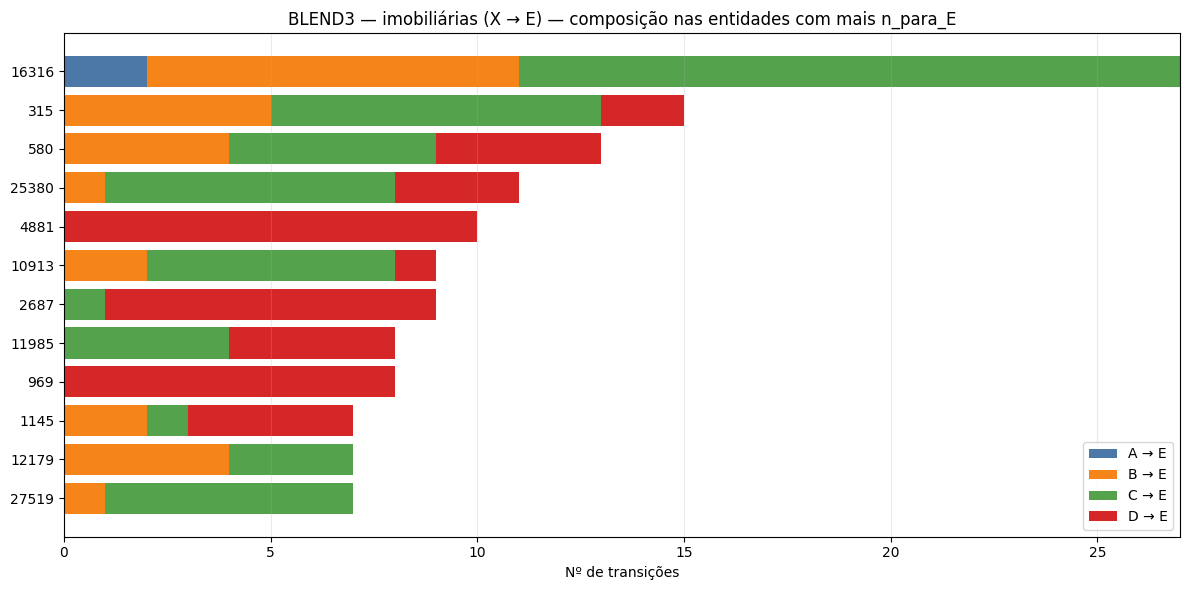

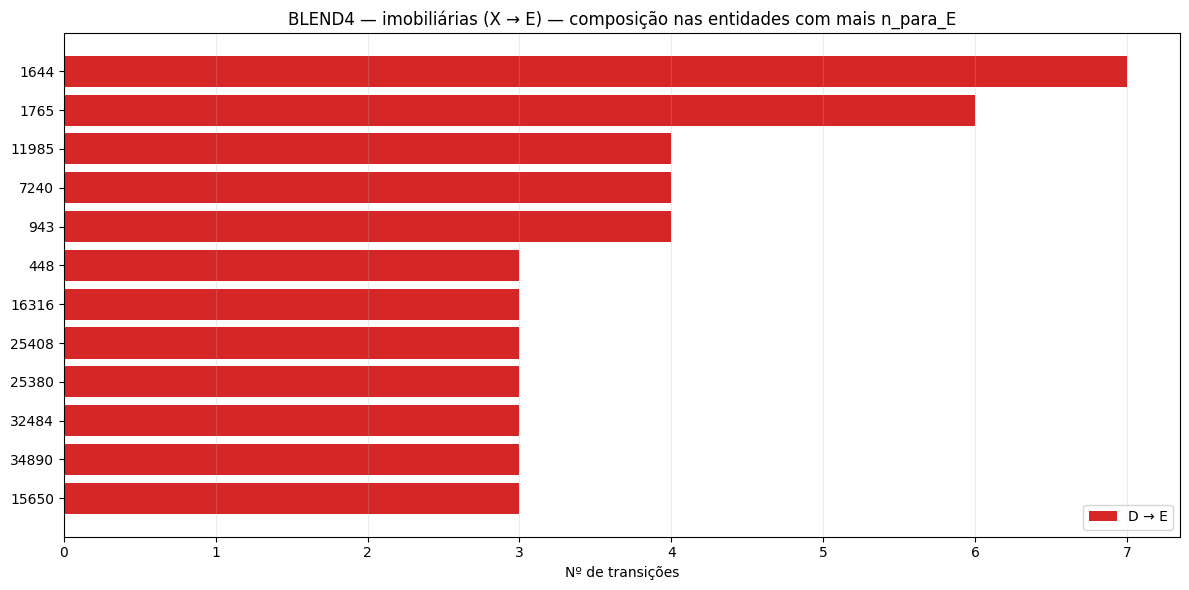

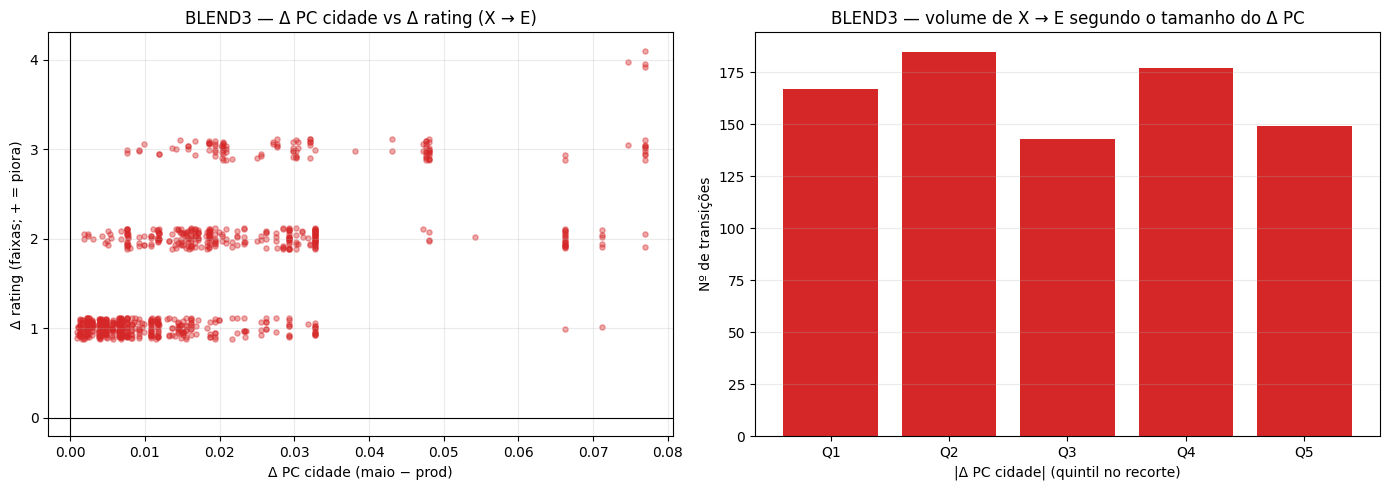

,n,mean_delta
dpc_q,,
Q1,167,+1.07
Q2,185,+1.22
Q3,143,+1.61
Q4,177,+1.97
Q5,149,+2.35


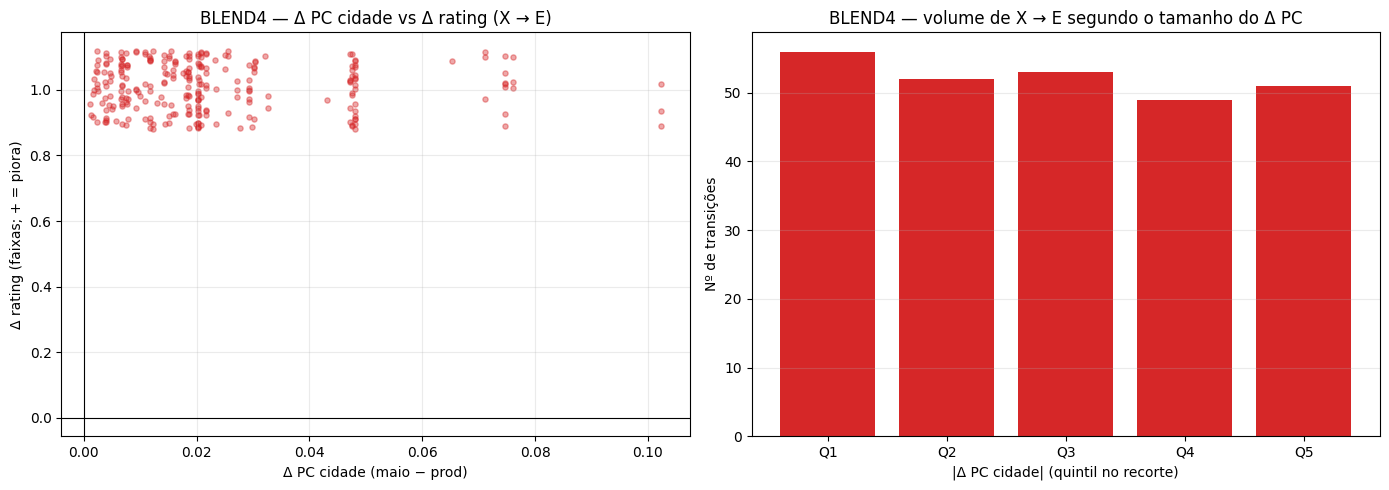

,n,mean_delta
dpc_q,,
Q1,56,+1.00
Q2,52,+1.00
Q3,53,+1.00
Q4,49,+1.00
Q5,51,+1.00


In [50]:
pair_overview(tr3, "BLEND3", "is_to_e", PAIR_TO_E, "idas para E (X → E)")
pair_overview(tr4, "BLEND4", "is_to_e", PAIR_TO_E, "idas para E (X → E)")

city_e3 = entity_by_pairs(
    tr3, "id_cidade_ibge", "BLEND3 — cidades", "is_to_e", PAIR_TO_E, "n_para_E",
    extra=["imovel_cidade", "imovel_uf"],
)
city_e4 = entity_by_pairs(
    tr4, "id_cidade_ibge", "BLEND4 — cidades", "is_to_e", PAIR_TO_E, "n_para_E",
    extra=["imovel_cidade", "imovel_uf"],
)
plot_entity_pairs(city_e3, "id_cidade_ibge", "BLEND3 — cidades (X → E)", PAIR_TO_E, "n_para_E")
plot_entity_pairs(city_e4, "id_cidade_ibge", "BLEND4 — cidades (X → E)", PAIR_TO_E, "n_para_E")

agency_e3 = entity_by_pairs(
    tr3, "id_imobiliaria", "BLEND3 — imobiliárias", "is_to_e", PAIR_TO_E, "n_para_E",
    min_eligible=10,
)
agency_e4 = entity_by_pairs(
    tr4, "id_imobiliaria", "BLEND4 — imobiliárias", "is_to_e", PAIR_TO_E, "n_para_E",
    min_eligible=10,
)
plot_entity_pairs(agency_e3, "id_imobiliaria", "BLEND3 — imobiliárias (X → E)", PAIR_TO_E, "n_para_E")
plot_entity_pairs(agency_e4, "id_imobiliaria", "BLEND4 — imobiliárias (X → E)", PAIR_TO_E, "n_para_E")

plot_pc_vs_move(tr3, "BLEND3", "is_to_e", "X → E")
plot_pc_vs_move(tr4, "BLEND4", "is_to_e", "X → E")


### Síntese

1. **Causa da transição: só o PC cidade.** No cenário city a PC imobiliária não muda. Não existe transição com Δ PC cidade = 0. BVS e Serasa são os mesmos nos dois ratings.
2. **Condição necessária: estar na faixa em que o Blend manda no rating.** Blend3: 100% das transições com `435 ≤ BVS < 620`. Blend4: 0 transições se `BVS ≤ 334`. Fora disso o PC cidade é irrelevante para o rating.
3. **Condição suficiente na prática: Δ PC cidade grande o bastante *e* score perto do corte.** A ~5 pontos do corte a taxa passa de 40%; a >40 pontos cai para <1%, mesmo com Δ PC no quintil alto.
4. **Não é “BVS/Serasa mais baixo”.** Entre elegíveis, quem vira não tem BVS pior (Blend3 até um pouco mais alto). O traço que separa é a distância ao corte e o tamanho do Δ PC cidade. Serasa/renda/restrições entram só na medida em que colocam o score perto da fronteira.
5. **PC imobiliária é outra alavanca.** Quase não há overlap entre quem vira no cenário city e quem vira no cenário agency. Trocar as duas (`ambos`) é, em essência, a união dos dois efeitos.
6. **Magnitude do salto (|Δ| = 1 vs 2+).** A maior parte das transições é vizinha (|Δ| = 1). Saltos de 2+ faixas se concentram em poucas cidades/imobiliárias e ficam mais frequentes quando o |Δ PC cidade| é grande.
7. **Pioras de rating (A→B, B→C, C→D, D→E).** O recorte por par (não por |Δ|) mostra se as pioras se concentram nas mesmas cidades/imobiliárias — e se o Δ PC cidade acompanha.
8. **Idas para E (X→E).** Subconjunto das pioras que caem em E (D→E vizinho e saltos A/B/C→E), com volume e taxa por cidade/imobiliária.

1. **Causa da transição: só o PC cidade.** No cenário city a PC imobiliária não muda. Não existe transição com Δ PC cidade = 0. BVS e Serasa são os mesmos nos dois ratings.
2. **Condição necessária: estar na faixa em que o Blend manda no rating.** Blend3: 100% das transições com `435 ≤ BVS < 620`. Blend4: 0 transições se `BVS ≤ 334`. Fora disso o PC cidade é irrelevante para o rating.
3. **Condição suficiente na prática: Δ PC cidade grande o bastante *e* score perto do corte.** A ~5 pontos do corte a taxa passa de 40%; a >40 pontos cai para <1%, mesmo com Δ PC no quintil alto.
4. **Não é “BVS/Serasa mais baixo”.** Entre elegíveis, quem vira não tem BVS pior (Blend3 até um pouco mais alto). O traço que separa é a distância ao corte e o tamanho do Δ PC cidade. Serasa/renda/restrições entram só na medida em que colocam o score perto da fronteira.
5. **PC imobiliária é outra alavanca.** Quase não há overlap entre quem vira no cenário city e quem vira no cenário agency. Trocar as duas (`ambos`) é, em essência, a união dos dois efeitos.

1. **Causa da transição: só o PC cidade.** No cenário city a PC imobiliária não muda. Não existe transição com Δ PC cidade = 0. BVS e Serasa são os mesmos nos dois ratings.
2. **Condição necessária: estar na faixa em que o Blend manda no rating.** Blend3: 100% das transições com `435 ≤ BVS < 620`. Blend4: 0 transições se `BVS ≤ 334`. Fora disso o PC cidade é irrelevante para o rating.
3. **Condição suficiente na prática: Δ PC cidade grande o bastante *e* score perto do corte.** A ~5 pontos do corte a taxa passa de 40%; a >40 pontos cai para <1%, mesmo com Δ PC no quintil alto.
4. **Não é “BVS/Serasa mais baixo”.** Entre elegíveis, quem vira não tem BVS pior (Blend3 até um pouco mais alto). O traço que separa é a distância ao corte e o tamanho do Δ PC cidade. Serasa/renda/restrições entram só na medida em que colocam o score perto da fronteira.
5. **PC imobiliária é outra alavanca.** Quase não há overlap entre quem vira no cenário city e quem vira no cenário agency. Trocar as duas (`ambos`) é, em essência, a união dos dois efeitos.

## Análise simples: prod vs ambos (cidade/UF)

Comparação `rating_manual_*_prod` vs `rating_manual_*_ambos` (PC cidade + PC imobiliária de maio). A é melhor, E é pior.

- **Manteve / Subiu / Desceu** no lead
- Distribuição de quem piorou e de quem melhorou por cidade/UF
- Mix de rating (especialmente %E) antes vs depois nas cidades com impacto mais expressivo


### Classificar movimento


In [51]:
RATING_ORDER = ["A", "B", "C", "D", "E"]
RATING_RANK = {r: i for i, r in enumerate(RATING_ORDER)}
CITY_COL = "id_cidade_ibge"
CITY_NAME = "imovel_cidade"
UF_COL = "imovel_uf"


def prepare_rating_move(df, col_prod, col_ambos, model_name):
    out = df.copy()
    out["modelo"] = model_name
    out["rating_prod"] = out[col_prod].astype("string").str.strip().str.upper()
    out["rating_ambos"] = out[col_ambos].astype("string").str.strip().str.upper()
    out["rank_prod"] = out["rating_prod"].map(RATING_RANK)
    out["rank_ambos"] = out["rating_ambos"].map(RATING_RANK)
    out["rating_delta"] = out["rank_ambos"] - out["rank_prod"]

    both_ok = out["rank_prod"].notna() & out["rank_ambos"].notna()
    out["movimento"] = np.select(
        [
            both_ok & (out["rating_delta"] == 0),
            both_ok & (out["rating_delta"] < 0),
            both_ok & (out["rating_delta"] > 0),
        ],
        ["Manteve", "Subiu", "Desceu"],
        default="sem rating",
    )
    out["transicao"] = np.where(
        both_ok & out["rating_prod"].ne(out["rating_ambos"]),
        out["rating_prod"] + " → " + out["rating_ambos"],
        np.where(both_ok, "estável", "sem rating"),
    )
    return out.loc[both_ok].copy()


mv3 = prepare_rating_move(
    df_blend3, "rating_manual_blend3_prod", "rating_manual_blend3_ambos", "BLEND3"
)
mv4 = prepare_rating_move(
    df_blend4, "rating_manual_blend4_prod", "rating_manual_blend4_ambos", "BLEND4"
)


### Volume: Manteve / Subiu / Desceu


In [52]:
def resumo_movimento(df, titulo):
    n = len(df)
    tab = (
        df["movimento"]
        .value_counts()
        .reindex(["Manteve", "Subiu", "Desceu"], fill_value=0)
        .to_frame("n")
    )
    tab["%"] = tab["n"] / n
    print(f"{titulo} — n={n:,}")
    display(tab.style.format({"n": "{:,.0f}", "%": "{:.1%}"}))

    print(f"{titulo} — matriz prod → ambos (volume)")
    mat = (
        pd.crosstab(df["rating_prod"], df["rating_ambos"])
        .reindex(index=RATING_ORDER, columns=RATING_ORDER, fill_value=0)
    )
    display(mat.assign(total=mat.sum(axis=1)))

    piora = df.loc[df["movimento"] == "Desceu"]
    print(f"{titulo} — caminhos de piora")
    display(
        piora["transicao"]
        .value_counts()
        .to_frame("n")
        .assign(pct=lambda x: x["n"] / x["n"].sum())
        .style.format({"n": "{:,.0f}", "pct": "{:.1%}"})
    )
    return tab, mat


resumo_movimento(mv3, "BLEND3")
resumo_movimento(mv4, "BLEND4")


BLEND3 — n=139,586


,n,%
movimento,,
Manteve,"134,848",96.6%
Subiu,"2,920",2.1%
Desceu,"1,818",1.3%


BLEND3 — matriz prod → ambos (volume)


rating_ambos,A,B,C,D,E,total
rating_prod,,,,,,
A,22254,114,5,0,4,22377
B,288,27713,460,3,123,28587
C,0,714,22905,351,324,24294
D,0,1,452,623,434,1510
E,0,346,689,430,61353,62818


BLEND3 — caminhos de piora


...

BLEND4 — matriz prod → ambos (volume)


rating_ambos,A,B,C,D,E,total
rating_prod,,,,,,
A,17540,235,8,0,0,17783
B,424,1965,202,18,0,2609
C,3,416,2022,256,0,2697
D,0,3,528,5038,291,5860
E,0,0,0,744,19705,20449


BLEND4 — caminhos de piora


,n,pct
transicao,,
D → E,291,28.8%
C → D,256,25.3%
A → B,235,23.3%
B → C,202,20.0%
B → D,18,1.8%
A → C,8,0.8%


(               n         %
 movimento                 
 Manteve    46270  0.936678
 Subiu       2118  0.042876
 Desceu      1010  0.020446,
 rating_ambos      A     B     C     D      E
 rating_prod                                 
 A             17540   235     8     0      0
 B               424  1965   202    18      0
 C                 3   416  2022   256      0
 D                 0     3   528  5038    291
 E                 0     0     0   744  19705)

### Quem desceu: distribuição por cidade/UF


In [53]:
def dist_piora_geo(df, titulo, n_cidades=20):
    piora = df.loc[df["movimento"] == "Desceu"].copy()
    n_piora = len(piora)
    print(f"{titulo} — quem desceu: {n_piora:,} ({n_piora / len(df):.1%} da base)")

    uf = (
        piora.groupby(UF_COL, dropna=False)
        .size()
        .rename("n_desceu")
        .to_frame()
        .assign(share=lambda x: x["n_desceu"] / n_piora)
        .sort_values("n_desceu", ascending=False)
    )
    print(f"{titulo} — piora por UF")
    display(uf.style.format({"n_desceu": "{:,.0f}", "share": "{:.1%}"}))

    cidade = (
        piora.groupby([CITY_COL, CITY_NAME, UF_COL], dropna=False)
        .size()
        .rename("n_desceu")
        .to_frame()
        .assign(share=lambda x: x["n_desceu"] / n_piora)
        .sort_values("n_desceu", ascending=False)
    )
    cidade["share_acum"] = cidade["share"].cumsum()
    print(f"{titulo} — top {n_cidades} cidades por volume de piora")
    display(
        cidade.head(n_cidades).style.format(
            {"n_desceu": "{:,.0f}", "share": "{:.1%}", "share_acum": "{:.1%}"}
        )
    )
    return uf, cidade


uf3, city3 = dist_piora_geo(mv3, "BLEND3")
uf4, city4 = dist_piora_geo(mv4, "BLEND4")


BLEND3 — quem desceu: 1,818 (1.3% da base)
BLEND3 — piora por UF


,n_desceu,share
imovel_uf,,
SP,695,38.2%
RS,346,19.0%
SC,236,13.0%
PR,185,10.2%
RJ,88,4.8%
MT,69,3.8%
MG,64,3.5%
CE,39,2.1%
DF,35,1.9%


BLEND3 — top 20 cidades por volume de piora


,,,n_desceu,share,share_acum
id_cidade_ibge,imovel_cidade,imovel_uf,,,
3552205,Sorocaba,SP,127,7.0%,7.0%
3524402,Jacareí,SP,91,5.0%,12.0%
4314100,Passo Fundo,RS,85,4.7%,16.7%
4106902,Curitiba,PR,76,4.2%,20.8%
3507506,Botucatu,SP,64,3.5%,24.4%
4305108,Caxias Do Sul,RS,63,3.5%,27.8%
5107909,Sinop,MT,60,3.3%,31.1%
3304557,Rio De Janeiro,RJ,55,3.0%,34.2%
4218004,Tijucas,SC,55,3.0%,37.2%


BLEND4 — quem desceu: 1,010 (2.0% da base)
BLEND4 — piora por UF


,n_desceu,share
imovel_uf,,
SP,362,35.8%
RS,214,21.2%
SC,169,16.7%
PR,85,8.4%
GO,34,3.4%
MG,30,3.0%
MT,28,2.8%
RJ,24,2.4%
CE,22,2.2%


BLEND4 — top 20 cidades por volume de piora


,,,n_desceu,share,share_acum
id_cidade_ibge,imovel_cidade,imovel_uf,,,
4314100,Passo Fundo,RS,65,6.4%,6.4%
3552205,Sorocaba,SP,65,6.4%,12.9%
3507506,Botucatu,SP,35,3.5%,16.3%
3524402,Jacareí,SP,34,3.4%,19.7%
4305108,Caxias Do Sul,RS,31,3.1%,22.8%
5218805,Rio Verde,GO,27,2.7%,25.4%
3506508,Birigui,SP,25,2.5%,27.9%
3529401,Mauá,SP,24,2.4%,30.3%
4204202,Chapecó,SC,24,2.4%,32.7%


### Quem subiu: distribuição por cidade/UF


In [54]:
def dist_melhora_geo(df, titulo, n_cidades=20):
    melhora = df.loc[df["movimento"] == "Subiu"].copy()
    n_melhora = len(melhora)
    print(f"{titulo} — quem subiu: {n_melhora:,} ({n_melhora / len(df):.1%} da base)")

    uf = (
        melhora.groupby(UF_COL, dropna=False)
        .size()
        .rename("n_subiu")
        .to_frame()
        .assign(share=lambda x: x["n_subiu"] / n_melhora)
        .sort_values("n_subiu", ascending=False)
    )
    print(f"{titulo} — melhora por UF")
    display(uf.style.format({"n_subiu": "{:,.0f}", "share": "{:.1%}"}))

    cidade = (
        melhora.groupby([CITY_COL, CITY_NAME, UF_COL], dropna=False)
        .size()
        .rename("n_subiu")
        .to_frame()
        .assign(share=lambda x: x["n_subiu"] / n_melhora)
        .sort_values("n_subiu", ascending=False)
    )
    cidade["share_acum"] = cidade["share"].cumsum()
    print(f"{titulo} — top {n_cidades} cidades por volume de melhora")
    display(
        cidade.head(n_cidades).style.format(
            {"n_subiu": "{:,.0f}", "share": "{:.1%}", "share_acum": "{:.1%}"}
        )
    )
    return uf, cidade


uf3_up, city3_up = dist_melhora_geo(mv3, "BLEND3")
uf4_up, city4_up = dist_melhora_geo(mv4, "BLEND4")


BLEND3 — quem subiu: 2,920 (2.1% da base)
BLEND3 — melhora por UF


,n_subiu,share
imovel_uf,,
SP,988,33.8%
RS,535,18.3%
PR,422,14.5%
SC,352,12.1%
MG,228,7.8%
MS,99,3.4%
MT,82,2.8%
GO,78,2.7%
RJ,71,2.4%


BLEND3 — top 20 cidades por volume de melhora


,,,n_subiu,share,share_acum
id_cidade_ibge,imovel_cidade,imovel_uf,,,
4113700,Londrina,PR,213,7.3%,7.3%
3538709,Piracicaba,SP,125,4.3%,11.6%
4313409,Novo Hamburgo,RS,106,3.6%,15.2%
3550308,São Paulo,SP,99,3.4%,18.6%
3554102,Taubaté,SP,88,3.0%,21.6%
5002704,Campo Grande,MS,83,2.8%,24.5%
3525300,Jaú,SP,82,2.8%,27.3%
4202404,Blumenau,SC,80,2.7%,30.0%
5107040,Primavera Do Leste,MT,74,2.5%,32.5%


BLEND4 — quem subiu: 2,118 (4.3% da base)
BLEND4 — melhora por UF


,n_subiu,share
imovel_uf,,
SP,659,31.1%
RS,381,18.0%
SC,323,15.3%
PR,219,10.3%
MG,180,8.5%
GO,98,4.6%
MT,68,3.2%
MS,62,2.9%
RJ,58,2.7%


BLEND4 — top 20 cidades por volume de melhora


,,,n_subiu,share,share_acum
id_cidade_ibge,imovel_cidade,imovel_uf,,,
4113700,Londrina,PR,105,5.0%,5.0%
3550308,São Paulo,SP,103,4.9%,9.8%
4313409,Novo Hamburgo,RS,83,3.9%,13.7%
4202909,Brusque,SC,70,3.3%,17.0%
5208707,Goiânia,GO,67,3.2%,20.2%
4314407,Pelotas,RS,63,3.0%,23.2%
3547809,Santo André,SP,52,2.5%,25.6%
4202008,Balneário Camboriú,SC,52,2.5%,28.1%
3525300,Jaú,SP,50,2.4%,30.5%


### É aleatório?

Se for proporcional ao volume, `share_desceu ≈ share_base` e `lift ≈ 1`. Cidade que se destaca: `lift` alto **e** `n ≥ MIN_N`.


In [55]:
MIN_N = 50


def geo_nao_aleatorio(df, group_cols, titulo, min_n=MIN_N, top=20):
    n = len(df)
    n_desceu = (df["movimento"] == "Desceu").sum()
    taxa_global = n_desceu / n

    g = (
        df.groupby(group_cols, dropna=False)
        .agg(
            n=("movimento", "size"),
            n_manteve=("movimento", lambda s: (s == "Manteve").sum()),
            n_subiu=("movimento", lambda s: (s == "Subiu").sum()),
            n_desceu=("movimento", lambda s: (s == "Desceu").sum()),
        )
        .reset_index()
    )
    g["pct_manteve"] = g["n_manteve"] / g["n"]
    g["pct_subiu"] = g["n_subiu"] / g["n"]
    g["pct_desceu"] = g["n_desceu"] / g["n"]
    g["share_base"] = g["n"] / n
    g["share_desceu"] = g["n_desceu"] / n_desceu if n_desceu else np.nan
    g["esperado"] = g["n"] * taxa_global
    g["residual"] = g["n_desceu"] - g["esperado"]
    g["lift"] = g["pct_desceu"] / taxa_global if taxa_global else np.nan

    print(f"{titulo} — taxa global de piora: {taxa_global:.1%} ({n_desceu:,}/{n:,})")

    top_vol = g.sort_values("n_desceu", ascending=False).head(top)
    print(f"{titulo} — top {top} por volume de piora (pode ser só cidade grande)")
    display(
        top_vol.style.format({
            "n": "{:,.0f}", "n_manteve": "{:,.0f}", "n_subiu": "{:,.0f}", "n_desceu": "{:,.0f}",
            "pct_manteve": "{:.1%}", "pct_subiu": "{:.1%}", "pct_desceu": "{:.1%}",
            "share_base": "{:.1%}", "share_desceu": "{:.1%}",
            "esperado": "{:,.1f}", "residual": "{:+,.1f}", "lift": "{:.2f}",
        }, na_rep="—")
    )

    top_taxa = (
        g.loc[g["n"] >= min_n]
        .sort_values(["lift", "n_desceu"], ascending=False)
        .head(top)
    )
    print(f"{titulo} — top {top} por lift (n ≥ {min_n}). lift>1 = piora acima do esperado")
    display(
        top_taxa.style.format({
            "n": "{:,.0f}", "n_manteve": "{:,.0f}", "n_subiu": "{:,.0f}", "n_desceu": "{:,.0f}",
            "pct_manteve": "{:.1%}", "pct_subiu": "{:.1%}", "pct_desceu": "{:.1%}",
            "share_base": "{:.1%}", "share_desceu": "{:.1%}",
            "esperado": "{:,.1f}", "residual": "{:+,.1f}", "lift": "{:.2f}",
        }, na_rep="—")
    )

    top10 = g.nlargest(10, "n_desceu")
    print(
        f"{titulo} — top 10 cidades concentram "
        f"{top10['share_desceu'].sum():.1%} das pioras "
        f"e {top10['share_base'].sum():.1%} da base"
    )
    return g


uf_stats3 = geo_nao_aleatorio(mv3, [UF_COL], "BLEND3 UF", min_n=1)
city_stats3 = geo_nao_aleatorio(mv3, [CITY_COL, CITY_NAME, UF_COL], "BLEND3 cidade")

uf_stats4 = geo_nao_aleatorio(mv4, [UF_COL], "BLEND4 UF", min_n=1)
city_stats4 = geo_nao_aleatorio(mv4, [CITY_COL, CITY_NAME, UF_COL], "BLEND4 cidade")


BLEND3 UF — taxa global de piora: 1.3% (1,818/139,586)
BLEND3 UF — top 20 por volume de piora (pode ser só cidade grande)


,imovel_uf,n,n_manteve,n_subiu,n_desceu,pct_manteve,pct_subiu,pct_desceu,share_base,share_desceu,esperado,residual,lift
24,SP,"48,722","47,039",988,695,96.5%,2.0%,1.4%,34.9%,38.2%,634.6,+60.4,1.10
21,RS,"22,871","21,990",535,346,96.1%,2.3%,1.5%,16.4%,19.0%,297.9,+48.1,1.16
22,SC,"23,375","22,787",352,236,97.5%,1.5%,1.0%,16.7%,13.0%,304.4,-68.4,0.78
17,PR,"15,143","14,536",422,185,96.0%,2.8%,1.2%,10.8%,10.2%,197.2,-12.2,0.94
18,RJ,"5,124","4,965",71,88,96.9%,1.4%,1.7%,3.7%,4.8%,66.7,+21.3,1.32
12,MT,"1,871","1,720",82,69,91.9%,4.4%,3.7%,1.3%,3.8%,24.4,+44.6,2.83
10,MG,"10,592","10,300",228,64,97.2%,2.2%,0.6%,7.6%,3.5%,138.0,-74.0,0.46
5,CE,"1,186","1,147",0,39,96.7%,0.0%,3.3%,0.8%,2.1%,15.4,+23.6,2.52
6,DF,"1,452","1,417",0,35,97.6%,0.0%,2.4%,1.0%,1.9%,18.9,+16.1,1.85
19,RN,367,350,0,17,95.4%,0.0%,4.6%,0.3%,0.9%,4.8,+12.2,3.56


BLEND3 UF — top 20 por lift (n ≥ 1). lift>1 = piora acima do esperado


,imovel_uf,n,n_manteve,n_subiu,n_desceu,pct_manteve,pct_subiu,pct_desceu,share_base,share_desceu,esperado,residual,lift
19,RN,367,350,0,17,95.4%,0.0%,4.6%,0.3%,0.9%,4.8,+12.2,3.56
12,MT,"1,871","1,720",82,69,91.9%,4.4%,3.7%,1.3%,3.8%,24.4,+44.6,2.83
14,PB,178,172,0,6,96.6%,0.0%,3.4%,0.1%,0.3%,2.3,+3.7,2.59
5,CE,"1,186","1,147",0,39,96.7%,0.0%,3.3%,0.8%,2.1%,15.4,+23.6,2.52
4,BA,488,471,3,14,96.5%,0.6%,2.9%,0.3%,0.8%,6.4,+7.6,2.20
6,DF,"1,452","1,417",0,35,97.6%,0.0%,2.4%,1.0%,1.9%,18.9,+16.1,1.85
18,RJ,"5,124","4,965",71,88,96.9%,1.4%,1.7%,3.7%,4.8%,66.7,+21.3,1.32
21,RS,"22,871","21,990",535,346,96.1%,2.3%,1.5%,16.4%,19.0%,297.9,+48.1,1.16
24,SP,"48,722","47,039",988,695,96.5%,2.0%,1.4%,34.9%,38.2%,634.6,+60.4,1.10
17,PR,"15,143","14,536",422,185,96.0%,2.8%,1.2%,10.8%,10.2%,197.2,-12.2,0.94


BLEND3 UF — top 10 cidades concentram 97.6% das pioras e 93.6% da base
BLEND3 cidade — taxa global de piora: 1.3% (1,818/139,586)
BLEND3 cidade — top 20 por volume de piora (pode ser só cidade grande)


...

BLEND4 UF — top 10 cidades concentram 97.7% das pioras e 95.8% da base
BLEND4 cidade — taxa global de piora: 2.0% (1,010/49,398)
BLEND4 cidade — top 20 por volume de piora (pode ser só cidade grande)


,id_cidade_ibge,imovel_cidade,imovel_uf,n,n_manteve,n_subiu,n_desceu,pct_manteve,pct_subiu,pct_desceu,share_base,share_desceu,esperado,residual,lift
460,3552205,Sorocaba,SP,602,537,0,65,89.2%,0.0%,10.8%,1.2%,6.4%,12.3,+52.7,5.28
712,4314100,Passo Fundo,RS,256,191,0,65,74.6%,0.0%,25.4%,0.5%,6.4%,5.2,+59.8,12.42
266,3507506,Botucatu,SP,263,228,0,35,86.7%,0.0%,13.3%,0.5%,3.5%,5.4,+29.6,6.51
349,3524402,Jacareí,SP,650,616,0,34,94.8%,0.0%,5.2%,1.3%,3.4%,13.3,+20.7,2.56
674,4305108,Caxias Do Sul,RS,706,655,20,31,92.8%,2.8%,4.4%,1.4%,3.1%,14.4,+16.6,2.15
812,5218805,Rio Verde,GO,85,58,0,27,68.2%,0.0%,31.8%,0.2%,2.7%,1.7,+25.3,15.54
262,3506508,Birigui,SP,246,220,1,25,89.4%,0.4%,10.2%,0.5%,2.5%,5.0,+20.0,4.97
372,3529401,Mauá,SP,161,137,0,24,85.1%,0.0%,14.9%,0.3%,2.4%,3.3,+20.7,7.29
581,4204202,Chapecó,SC,271,247,0,24,91.1%,0.0%,8.9%,0.5%,2.4%,5.5,+18.5,4.33
25,2304400,Fortaleza,CE,329,307,0,22,93.3%,0.0%,6.7%,0.7%,2.2%,6.7,+15.3,3.27


BLEND4 cidade — top 20 por lift (n ≥ 50). lift>1 = piora acima do esperado


,id_cidade_ibge,imovel_cidade,imovel_uf,n,n_manteve,n_subiu,n_desceu,pct_manteve,pct_subiu,pct_desceu,share_base,share_desceu,esperado,residual,lift
812,5218805,Rio Verde,GO,85,58,0,27,68.2%,0.0%,31.8%,0.2%,2.7%,1.7,+25.3,15.54
682,4307005,Erechim,RS,65,45,0,20,69.2%,0.0%,30.8%,0.1%,2.0%,1.3,+18.7,15.05
784,5107909,Sinop,MT,60,42,0,18,70.0%,0.0%,30.0%,0.1%,1.8%,1.2,+16.8,14.67
712,4314100,Passo Fundo,RS,256,191,0,65,74.6%,0.0%,25.4%,0.5%,6.4%,5.2,+59.8,12.42
537,4118204,Paranaguá,PR,87,65,0,22,74.7%,0.0%,25.3%,0.2%,2.2%,1.8,+20.2,12.37
229,3305802,Teresópolis,RJ,61,49,0,12,80.3%,0.0%,19.7%,0.1%,1.2%,1.2,+10.8,9.62
590,4205902,Gaspar,SC,52,42,0,10,80.8%,0.0%,19.2%,0.1%,1.0%,1.1,+8.9,9.41
621,4212502,Penha,SC,64,52,0,12,81.2%,0.0%,18.8%,0.1%,1.2%,1.3,+10.7,9.17
663,4303103,Cachoeirinha,RS,108,89,1,18,82.4%,0.9%,16.7%,0.2%,1.8%,2.2,+15.8,8.15
361,3526803,Lençóis Paulista,SP,106,90,0,16,84.9%,0.0%,15.1%,0.2%,1.6%,2.2,+13.8,7.38


BLEND4 cidade — top 10 cidades concentram 34.9% das pioras e 7.2% da base


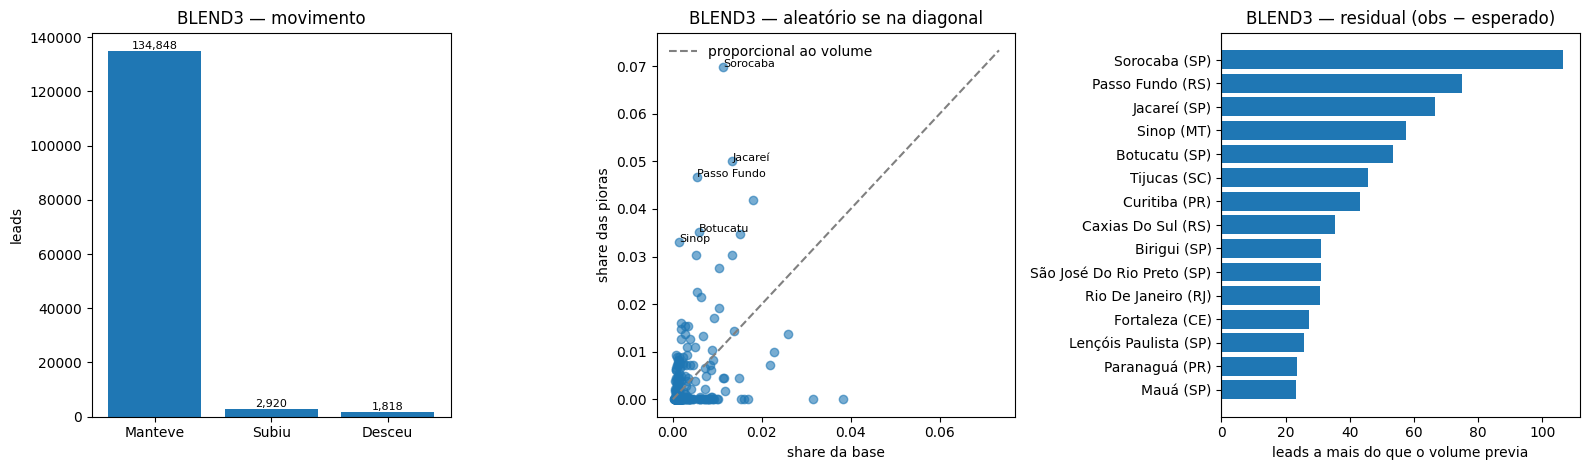

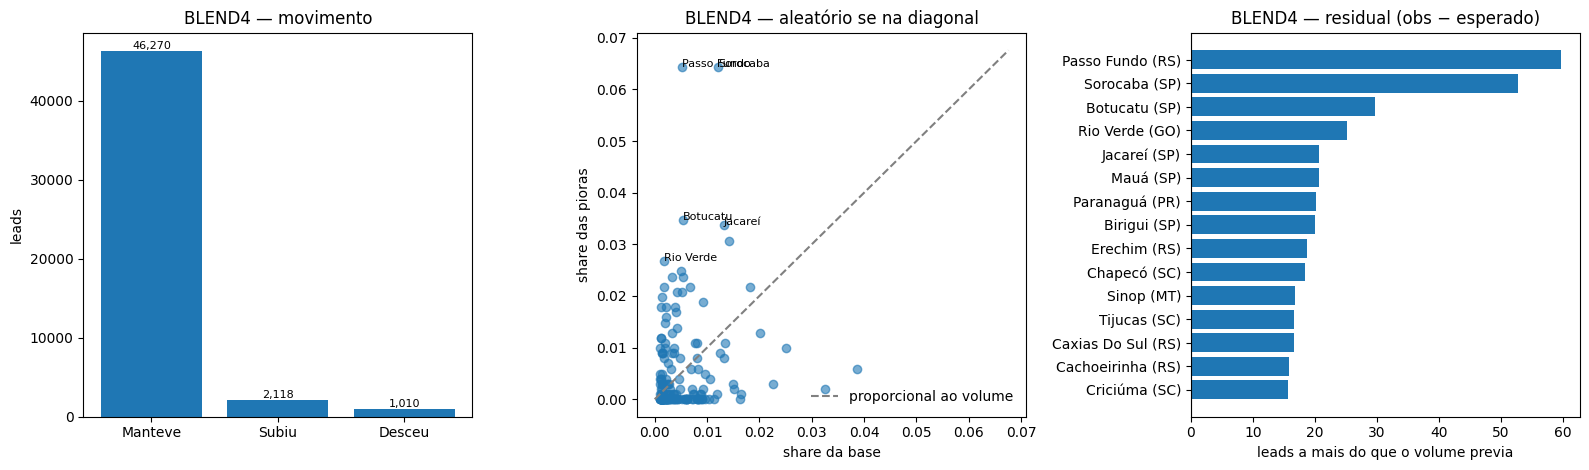

In [56]:
def plot_geo_piora(df, stats, titulo, min_n=MIN_N, top=15):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    ordem = ["Manteve", "Subiu", "Desceu"]
    cnt = df["movimento"].value_counts().reindex(ordem, fill_value=0)
    axes[0].bar(ordem, cnt.values)
    axes[0].set_title(f"{titulo} — movimento")
    axes[0].set_ylabel("leads")
    for i, v in enumerate(cnt.values):
        axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

    s = stats.loc[stats["n"] >= min_n].copy()
    axes[1].scatter(s["share_base"], s["share_desceu"], alpha=0.6)
    lim = max(s["share_base"].max(), s["share_desceu"].max()) * 1.05
    axes[1].plot([0, lim], [0, lim], "--", color="gray", label="proporcional ao volume")
    axes[1].set_xlabel("share da base")
    axes[1].set_ylabel("share das pioras")
    axes[1].set_title(f"{titulo} — aleatório se na diagonal")
    axes[1].legend(frameon=False)

    for _, r in s.nlargest(5, "residual").iterrows():
        label = r[CITY_NAME] if CITY_NAME in r.index else str(r.get(UF_COL, ""))
        axes[1].annotate(label, (r["share_base"], r["share_desceu"]), fontsize=8)

    top_res = s.nlargest(top, "residual").iloc[::-1]
    labels = (
        top_res[CITY_NAME].fillna(top_res[CITY_COL].astype(str))
        + " (" + top_res[UF_COL].astype(str) + ")"
        if CITY_NAME in top_res.columns
        else top_res[UF_COL].astype(str)
    )
    axes[2].barh(labels, top_res["residual"])
    axes[2].axvline(0, color="gray")
    axes[2].set_title(f"{titulo} — residual (obs − esperado)")
    axes[2].set_xlabel("leads a mais do que o volume previa")

    plt.tight_layout()
    plt.show()


plot_geo_piora(mv3, city_stats3, "BLEND3")
plot_geo_piora(mv4, city_stats4, "BLEND4")


### Mix A–E antes vs depois (cidades expressivas)

Uma cidade expressiva muda o **%E** (e o número de E) de forma desproporcional ao volume.

- `dpp_E`: variação do mix de E em pontos percentuais
- `dn_E`: impacto em pessoas (E depois − E antes)


In [57]:
MIN_N_MIX = 80


def mix_share(s, prefix):
    n = len(s)
    vc = s.value_counts()
    return {f"{prefix}_{r}": vc.get(r, 0) / n if n else np.nan for r in RATING_ORDER}


def geo_rating_mix(df, group_cols, min_n=MIN_N_MIX):
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        n = len(g)
        row = dict(zip(group_cols, keys))
        row["n"] = n
        row.update(mix_share(g["rating_prod"], "prod"))
        row.update(mix_share(g["rating_ambos"], "ambos"))
        row["n_E_prod"] = (g["rating_prod"] == "E").sum()
        row["n_E_ambos"] = (g["rating_ambos"] == "E").sum()
        row["n_desceu"] = (g["movimento"] == "Desceu").sum()
        row["n_subiu"] = (g["movimento"] == "Subiu").sum()
        rows.append(row)

    out = pd.DataFrame(rows)
    out["pct_E_prod"] = out["prod_E"]
    out["pct_E_ambos"] = out["ambos_E"]
    out["dpp_E"] = out["pct_E_ambos"] - out["pct_E_prod"]
    out["dn_E"] = out["n_E_ambos"] - out["n_E_prod"]
    out["pct_DE_prod"] = out["prod_D"] + out["prod_E"]
    out["pct_DE_ambos"] = out["ambos_D"] + out["ambos_E"]
    out["dpp_DE"] = out["pct_DE_ambos"] - out["pct_DE_prod"]
    out["pct_desceu"] = out["n_desceu"] / out["n"]
    out["pct_subiu"] = out["n_subiu"] / out["n"]
    out["liquido"] = out["n_desceu"] - out["n_subiu"]
    out["score_piora"] = out["dpp_E"] * np.sqrt(out["n"].clip(lower=1))
    out["score_melhora"] = (-out["dpp_E"]) * np.sqrt(out["n"].clip(lower=1))
    return out.loc[out["n"] >= min_n].copy()


def show_mix(tab, titulo, sentido="piora", n=15):
    if sentido == "piora":
        view = tab.sort_values(["dn_E", "dpp_E"], ascending=False).head(n)
        print(f"{titulo} — piora expressiva (mais E / mix de E sobe)")
    else:
        view = tab.sort_values(["dn_E", "dpp_E"], ascending=True).head(n)
        print(f"{titulo} — melhora expressiva (menos E / mix de E cai)")

    cols = [c for c in [CITY_NAME, UF_COL, CITY_COL] if c in view.columns]
    cols += [
        "n", "pct_E_prod", "pct_E_ambos", "dpp_E", "n_E_prod", "n_E_ambos", "dn_E",
        "pct_DE_prod", "pct_DE_ambos", "dpp_DE",
        "pct_desceu", "pct_subiu", "liquido",
    ]
    display(
        view[cols].style.format({
            "n": "{:,.0f}",
            "pct_E_prod": "{:.1%}", "pct_E_ambos": "{:.1%}", "dpp_E": "{:+.1%}",
            "n_E_prod": "{:,.0f}", "n_E_ambos": "{:,.0f}", "dn_E": "{:+,.0f}",
            "pct_DE_prod": "{:.1%}", "pct_DE_ambos": "{:.1%}", "dpp_DE": "{:+.1%}",
            "pct_desceu": "{:.1%}", "pct_subiu": "{:.1%}", "liquido": "{:+,.0f}",
        }, na_rep="—")
    )
    return view


city_mix3 = geo_rating_mix(mv3, [CITY_COL, CITY_NAME, UF_COL])
city_mix4 = geo_rating_mix(mv4, [CITY_COL, CITY_NAME, UF_COL])
uf_mix3 = geo_rating_mix(mv3, [UF_COL], min_n=1)
uf_mix4 = geo_rating_mix(mv4, [UF_COL], min_n=1)

show_mix(city_mix3, "BLEND3 cidade", "piora")
show_mix(city_mix3, "BLEND3 cidade", "melhora")
show_mix(uf_mix3, "BLEND3 UF", "piora")
show_mix(uf_mix3, "BLEND3 UF", "melhora")

show_mix(city_mix4, "BLEND4 cidade", "piora")
show_mix(city_mix4, "BLEND4 cidade", "melhora")
show_mix(uf_mix4, "BLEND4 UF", "piora")
show_mix(uf_mix4, "BLEND4 UF", "melhora")


BLEND3 cidade — piora expressiva (mais E / mix de E sobe)


,imovel_cidade,imovel_uf,id_cidade_ibge,n,pct_E_prod,pct_E_ambos,dpp_E,n_E_prod,n_E_ambos,dn_E,pct_DE_prod,pct_DE_ambos,dpp_DE,pct_desceu,pct_subiu,liquido
564,Sorocaba,SP,3552205,"1,585",37.2%,40.9%,+3.8%,589,649,+60,38.7%,42.4%,+3.7%,8.0%,0.0%,+127
884,Passo Fundo,RS,4314100,762,47.6%,55.2%,+7.6%,363,421,+58,49.1%,56.0%,+7.0%,11.2%,0.0%,+85
797,Tijucas,SC,4218004,711,51.6%,56.8%,+5.2%,367,404,+37,52.7%,57.4%,+4.6%,7.7%,0.0%,+55
974,Sinop,MT,5107909,185,27.6%,46.5%,+18.9%,51,86,+35,28.1%,48.1%,+20.0%,32.4%,0.0%,+60
441,Jacareí,SP,3524402,"1,867",41.0%,42.8%,+1.8%,766,799,+33,42.2%,44.1%,+1.9%,4.9%,0.0%,+91
342,Botucatu,SP,3507506,804,45.9%,49.8%,+3.9%,369,400,+31,47.1%,51.1%,+4.0%,8.0%,0.0%,+64
548,São José Do Rio Preto,SP,3549805,"1,457",46.2%,48.0%,+1.8%,673,699,+26,48.0%,48.9%,+0.8%,3.4%,0.2%,+47
620,Curitiba,PR,4106902,"2,527",31.7%,32.7%,+1.0%,800,826,+26,32.8%,33.7%,+0.9%,3.0%,0.1%,+74
835,Caxias Do Sul,RS,4305108,"2,119",48.5%,49.6%,+1.1%,"1,027","1,050",+23,49.8%,50.9%,+1.1%,3.0%,0.6%,+51
31,Fortaleza,CE,2304400,898,40.5%,43.0%,+2.4%,364,386,+22,42.0%,43.9%,+1.9%,4.3%,0.0%,+39


BLEND3 cidade — melhora expressiva (menos E / mix de E cai)


,imovel_cidade,imovel_uf,id_cidade_ibge,n,pct_E_prod,pct_E_ambos,dpp_E,n_E_prod,n_E_ambos,dn_E,pct_DE_prod,pct_DE_ambos,dpp_DE,pct_desceu,pct_subiu,liquido
639,Londrina,PR,4113700,"4,401",42.9%,40.6%,-2.3%,"1,887","1,787",-100,44.1%,41.8%,-2.3%,0.0%,4.8%,-213
878,Novo Hamburgo,RS,4313409,"1,073",61.9%,54.0%,-7.9%,664,579,-85,62.6%,54.6%,-8.0%,0.0%,9.9%,-106
886,Pelotas,RS,4314407,"1,256",60.7%,56.3%,-4.4%,762,707,-55,61.4%,57.1%,-4.3%,0.0%,5.9%,-74
970,Primavera Do Leste,MT,5107040,840,60.4%,53.9%,-6.4%,507,453,-54,61.5%,55.0%,-6.5%,0.0%,8.8%,-74
503,Piracicaba,SP,3538709,"2,232",50.6%,48.3%,-2.4%,"1,130","1,077",-53,52.0%,49.0%,-3.0%,0.0%,5.6%,-125
472,Mogi Guaçu,SP,3530706,474,64.8%,54.6%,-10.1%,307,259,-48,65.6%,55.9%,-9.7%,0.0%,14.3%,-68
573,Taubaté,SP,3554102,852,40.4%,35.8%,-4.6%,344,305,-39,41.7%,37.0%,-4.7%,0.0%,10.3%,-88
715,Brusque,SC,4202909,993,61.4%,57.7%,-3.7%,610,573,-37,61.9%,58.6%,-3.3%,0.0%,4.7%,-47
712,Blumenau,SC,4202404,"3,036",43.0%,41.8%,-1.2%,"1,306","1,269",-37,44.1%,43.3%,-0.8%,0.4%,2.6%,-67
554,São Paulo,SP,3550308,"5,339",40.0%,39.3%,-0.7%,"2,135","2,098",-37,41.1%,40.3%,-0.8%,0.0%,1.9%,-99


BLEND3 UF — piora expressiva (mais E / mix de E sobe)


...

BLEND4 UF — piora expressiva (mais E / mix de E sobe)


,imovel_uf,n,pct_E_prod,pct_E_ambos,dpp_E,n_E_prod,n_E_ambos,dn_E,pct_DE_prod,pct_DE_ambos,dpp_DE,pct_desceu,pct_subiu,liquido
5,CE,429,44.1%,45.7%,+1.6%,189,196,+7,54.8%,55.7%,+0.9%,5.1%,0.0%,+22
4,BA,165,31.5%,33.9%,+2.4%,52,56,+4,49.1%,50.9%,+1.8%,9.1%,1.2%,+13
14,PB,41,24.4%,26.8%,+2.4%,10,11,+1,36.6%,36.6%,+0.0%,2.4%,0.0%,+1
6,DF,453,22.1%,22.3%,+0.2%,100,101,+1,30.0%,30.7%,+0.7%,4.2%,0.4%,+17
0,AC,6,16.7%,16.7%,+0.0%,1,1,+0,16.7%,16.7%,+0.0%,0.0%,0.0%,+0
1,AL,27,18.5%,18.5%,+0.0%,5,5,+0,37.0%,37.0%,+0.0%,0.0%,0.0%,+0
2,AM,16,43.8%,43.8%,+0.0%,7,7,+0,56.2%,56.2%,+0.0%,0.0%,0.0%,+0
3,AP,7,0.0%,0.0%,+0.0%,0,0,+0,42.9%,42.9%,+0.0%,0.0%,0.0%,+0
9,MA,11,18.2%,18.2%,+0.0%,2,2,+0,36.4%,36.4%,+0.0%,0.0%,0.0%,+0
13,PA,15,20.0%,20.0%,+0.0%,3,3,+0,33.3%,33.3%,+0.0%,0.0%,0.0%,+0


BLEND4 UF — melhora expressiva (menos E / mix de E cai)


,imovel_uf,n,pct_E_prod,pct_E_ambos,dpp_E,n_E_prod,n_E_ambos,dn_E,pct_DE_prod,pct_DE_ambos,dpp_DE,pct_desceu,pct_subiu,liquido
24,SP,"17,652",42.9%,42.1%,-0.8%,"7,570","7,424",-146,54.8%,54.4%,-0.4%,2.1%,3.7%,-297
21,RS,"7,925",46.5%,45.5%,-1.0%,"3,687","3,606",-81,58.2%,57.8%,-0.4%,2.7%,4.8%,-167
10,MG,"3,636",39.9%,38.4%,-1.5%,"1,452","1,396",-56,51.0%,50.2%,-0.8%,0.8%,5.0%,-150
22,SC,"8,359",41.2%,40.7%,-0.5%,"3,443","3,398",-45,53.0%,52.5%,-0.5%,2.0%,3.9%,-154
17,PR,"5,375",36.1%,35.5%,-0.6%,"1,941","1,909",-32,49.0%,48.1%,-0.9%,1.6%,4.1%,-134
8,GO,"1,192",53.5%,51.1%,-2.4%,638,609,-29,64.8%,64.0%,-0.8%,2.9%,8.2%,-64
12,MT,627,55.3%,51.4%,-4.0%,347,322,-25,64.8%,64.4%,-0.3%,4.5%,10.8%,-40
11,MS,463,41.7%,36.5%,-5.2%,193,169,-24,55.7%,52.3%,-3.5%,0.0%,13.4%,-62
18,RJ,"1,677",26.4%,25.4%,-1.0%,443,426,-17,37.1%,37.1%,-0.1%,1.4%,3.5%,-34
16,PI,189,38.6%,35.4%,-3.2%,73,67,-6,54.5%,51.3%,-3.2%,0.5%,19.6%,-36


,imovel_uf,n,prod_A,prod_B,prod_C,prod_D,prod_E,ambos_A,ambos_B,ambos_C,...,dpp_E,dn_E,pct_DE_prod,pct_DE_ambos,dpp_DE,pct_desceu,pct_subiu,liquido,score_piora,score_melhora
24,SP,17652,0.346930,0.050646,0.054385,0.119193,0.428847,0.349366,0.049853,0.056991,...,-0.008271,-146,0.548040,0.543791,-0.004249,0.020508,0.037333,-297,-1.098894,1.098894
21,RS,7925,0.312555,0.052492,0.052618,0.117098,0.465237,0.313817,0.055268,0.052744,...,-0.010221,-81,0.582334,0.578170,-0.004164,0.027003,0.048076,-167,-0.909883,0.909883
10,MG,3636,0.377338,0.056931,0.055831,0.110561,0.399340,0.385039,0.059406,0.053355,...,-0.015402,-56,0.509901,0.502200,-0.007701,0.008251,0.049505,-150,-0.928701,0.928701
22,SC,8359,0.364996,0.049527,0.055389,0.118196,0.411891,0.367269,0.053236,0.054073,...,-0.005383,-45,0.530087,0.525422,-0.004666,0.020218,0.038641,-154,-0.492193,0.492193
17,PR,5375,0.388465,0.061023,0.060465,0.128930,0.361116,0.395163,0.057860,0.065674,...,-0.005953,-32,0.490047,0.481302,-0.008744,0.015814,0.040744,-134,-0.436476,0.436476
8,GO,1192,0.258389,0.053691,0.039430,0.113255,0.535235,0.265101,0.057886,0.036913,...,-0.024329,-29,0.648490,0.640101,-0.008389,0.028523,0.082215,-64,-0.839962,0.839962
12,MT,627,0.251994,0.054226,0.046252,0.094099,0.553429,0.266348,0.049442,0.039872,...,-0.039872,-25,0.647528,0.644338,-0.003190,0.044657,0.108453,-40,-0.998404,0.998404
11,MS,463,0.345572,0.060475,0.036717,0.140389,0.416847,0.375810,0.047516,0.053996,...,-0.051836,-24,0.557235,0.522678,-0.034557,0.000000,0.133909,-62,-1.115375,1.115375
18,RJ,1677,0.524747,0.045915,0.057841,0.107335,0.264162,0.531306,0.042338,0.055456,...,-0.010137,-17,0.371497,0.370900,-0.000596,0.014311,0.034586,-34,-0.415128,0.415128
16,PI,189,0.285714,0.089947,0.079365,0.158730,0.386243,0.354497,0.079365,0.052910,...,-0.031746,-6,0.544974,0.513228,-0.031746,0.005291,0.195767,-36,-0.436436,0.436436


In [58]:
def ficha_mix(df, stats, titulo, n_cidades=8):
    piora = stats.nlargest(n_cidades, "score_piora")
    melhora = stats.nlargest(n_cidades, "score_melhora")
    keys = pd.concat([piora, melhora]).drop_duplicates(subset=[CITY_COL])

    print(f"{titulo} — mix A–E (prod → ambos) nas cidades com maior score")
    blocos = []
    for _, r in keys.iterrows():
        g = df.loc[df[CITY_COL] == r[CITY_COL]]
        mix = pd.DataFrame({
            "rating": RATING_ORDER,
            "prod": [(g["rating_prod"] == x).mean() for x in RATING_ORDER],
            "ambos": [(g["rating_ambos"] == x).mean() for x in RATING_ORDER],
        })
        mix["dpp"] = mix["ambos"] - mix["prod"]
        mix["n_prod"] = [(g["rating_prod"] == x).sum() for x in RATING_ORDER]
        mix["n_ambos"] = [(g["rating_ambos"] == x).sum() for x in RATING_ORDER]
        mix["dn"] = mix["n_ambos"] - mix["n_prod"]
        nome = f"{r[CITY_NAME]} ({r[UF_COL]}) | IBGE {r[CITY_COL]} | n={int(r['n']):,}"
        print(f"\n{nome}")
        display(
            mix.set_index("rating").style.format({
                "prod": "{:.1%}", "ambos": "{:.1%}", "dpp": "{:+.1%}",
                "n_prod": "{:,.0f}", "n_ambos": "{:,.0f}", "dn": "{:+,.0f}",
            })
        )
        mix = mix.assign(
            cidade=r[CITY_NAME], uf=r[UF_COL], id_cidade_ibge=r[CITY_COL], n=r["n"]
        )
        blocos.append(mix)
    return pd.concat(blocos, ignore_index=True)


mix_detail3 = ficha_mix(mv3, city_mix3, "BLEND3")
mix_detail4 = ficha_mix(mv4, city_mix4, "BLEND4")


BLEND3 — mix A–E (prod → ambos) nas cidades com maior score

Sinop (MT) | IBGE 5107909 | n=185


,prod,ambos,dpp,n_prod,n_ambos,dn
rating,,,,,,
A,18.9%,11.4%,-7.6%,35,21,-14
B,29.7%,19.5%,-10.3%,55,36,-19
C,23.2%,21.1%,-2.2%,43,39,-4
D,0.5%,1.6%,+1.1%,1,3,+2
E,27.6%,46.5%,+18.9%,51,86,+35



Passo Fundo (RS) | IBGE 4314100 | n=762


,prod,ambos,dpp,n_prod,n_ambos,dn
rating,,,,,,
A,13.3%,12.2%,-1.0%,101,93,-8
B,19.7%,17.3%,-2.4%,150,132,-18
C,18.0%,14.4%,-3.5%,137,110,-27
D,1.4%,0.8%,-0.7%,11,6,-5
E,47.6%,55.2%,+7.6%,363,421,+58



Sorocaba (SP) | IBGE 3552205 | n=1,585


...

,prod,ambos,dpp,n_prod,n_ambos,dn
rating,,,,,,
A,26.1%,28.2%,+2.1%,111,120,+9
B,3.5%,4.9%,+1.4%,15,21,+6
C,4.5%,4.0%,-0.5%,19,17,-2
D,8.0%,11.1%,+3.1%,34,47,+13
E,57.9%,51.8%,-6.1%,246,220,-26



Rondonópolis (MT) | IBGE 5107602 | n=115


,prod,ambos,dpp,n_prod,n_ambos,dn
rating,,,,,,
A,13.0%,19.1%,+6.1%,15,22,+7
B,5.2%,3.5%,-1.7%,6,4,-2
C,2.6%,3.5%,+0.9%,3,4,+1
D,6.1%,12.2%,+6.1%,7,14,+7
E,73.0%,61.7%,-11.3%,84,71,-13



São Paulo (SP) | IBGE 3550308 | n=1,906


,prod,ambos,dpp,n_prod,n_ambos,dn
rating,,,,,,
A,38.6%,39.1%,+0.5%,735,745,+10
B,5.3%,5.6%,+0.3%,101,106,+5
C,5.3%,5.7%,+0.4%,101,108,+7
D,13.0%,14.4%,+1.5%,247,275,+28
E,37.9%,35.3%,-2.6%,722,672,-50


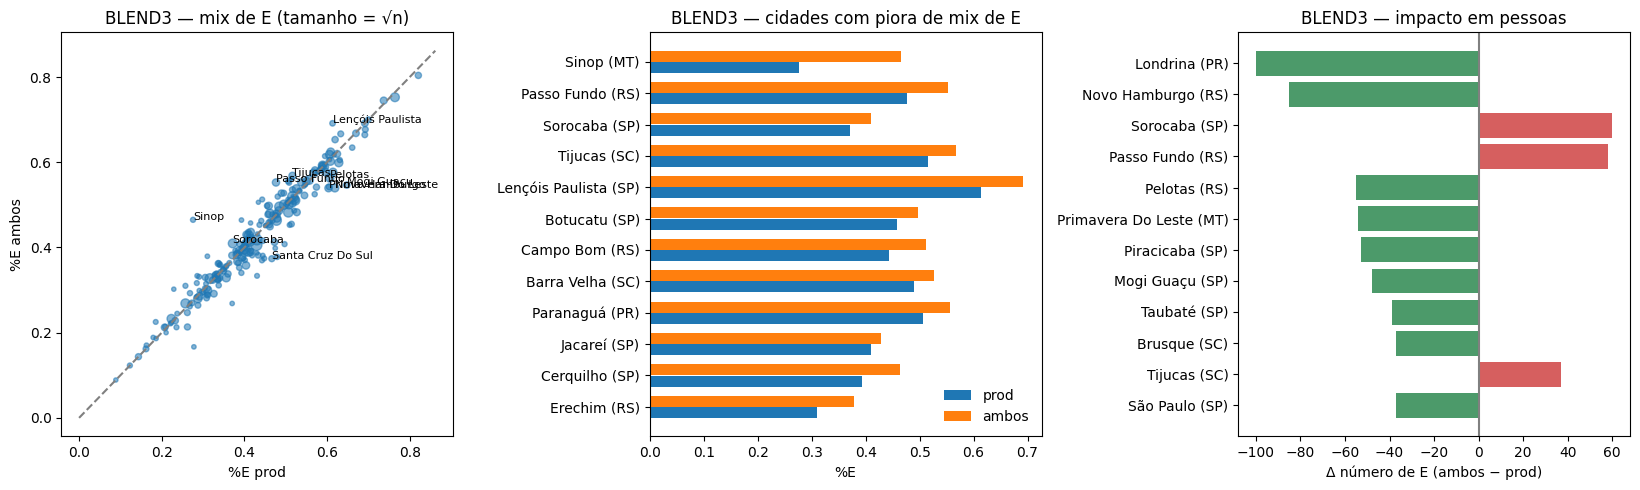

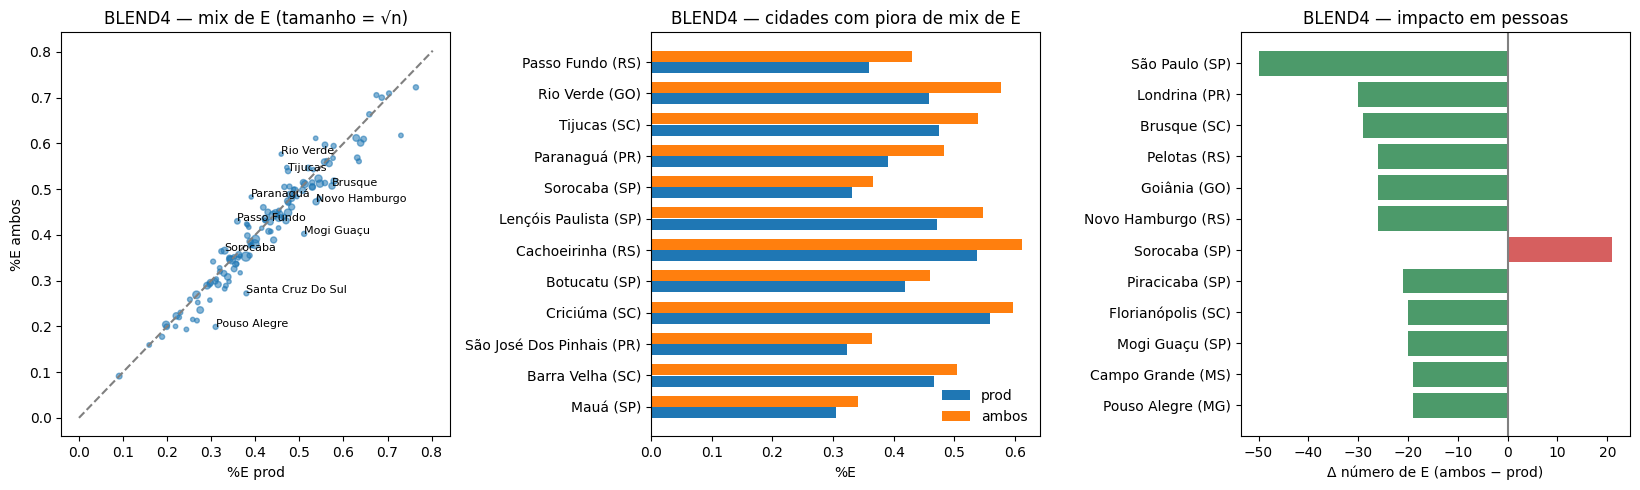

In [59]:
def plot_mix_expressivo(stats, titulo, n=12):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))

    axes[0].scatter(stats["pct_E_prod"], stats["pct_E_ambos"], s=np.sqrt(stats["n"]), alpha=0.55)
    m = max(stats["pct_E_prod"].max(), stats["pct_E_ambos"].max()) * 1.05
    axes[0].plot([0, m], [0, m], "--", color="gray")
    axes[0].set_xlabel("%E prod")
    axes[0].set_ylabel("%E ambos")
    axes[0].set_title(f"{titulo} — mix de E (tamanho = √n)")
    for _, r in pd.concat(
        [stats.nlargest(5, "score_piora"), stats.nlargest(5, "score_melhora")]
    ).drop_duplicates(subset=[CITY_COL]).iterrows():
        axes[0].annotate(str(r[CITY_NAME]), (r["pct_E_prod"], r["pct_E_ambos"]), fontsize=8)

    top = stats.nlargest(n, "score_piora").iloc[::-1]
    y = np.arange(len(top))
    axes[1].barh(y - 0.18, top["pct_E_prod"], height=0.35, label="prod")
    axes[1].barh(y + 0.18, top["pct_E_ambos"], height=0.35, label="ambos")
    axes[1].set_yticks(y)
    axes[1].set_yticklabels(
        top[CITY_NAME].fillna(top[CITY_COL].astype(str)) + " (" + top[UF_COL].astype(str) + ")"
    )
    axes[1].set_xlabel("%E")
    axes[1].set_title(f"{titulo} — cidades com piora de mix de E")
    axes[1].legend(frameon=False)

    imp = stats.reindex(stats["dn_E"].abs().sort_values(ascending=False).head(n).index).iloc[::-1]
    colors = np.where(imp["dn_E"] >= 0, "#d65f5f", "#4c9a6a")
    axes[2].barh(
        imp[CITY_NAME].fillna(imp[CITY_COL].astype(str)) + " (" + imp[UF_COL].astype(str) + ")",
        imp["dn_E"],
        color=colors,
    )
    axes[2].axvline(0, color="gray")
    axes[2].set_xlabel("Δ número de E (ambos − prod)")
    axes[2].set_title(f"{titulo} — impacto em pessoas")

    plt.tight_layout()
    plt.show()


plot_mix_expressivo(city_mix3, "BLEND3")
plot_mix_expressivo(city_mix4, "BLEND4")


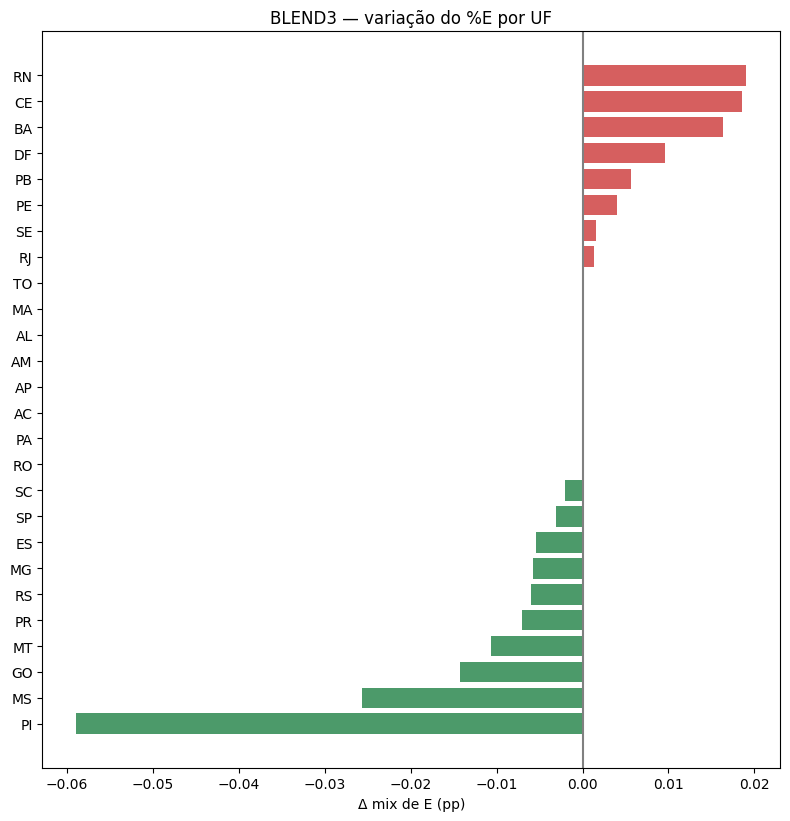

BLEND3 — mix de E por UF


,imovel_uf,n,pct_E_prod,pct_E_ambos,dpp_E,dn_E,pct_desceu,pct_subiu
19,RN,367,25.9%,27.8%,+1.9%,+7,4.6%,0.0%
5,CE,"1,186",40.0%,41.8%,+1.9%,+22,3.3%,0.0%
4,BA,488,43.0%,44.7%,+1.6%,+8,2.9%,0.6%
6,DF,"1,452",22.3%,23.3%,+1.0%,+14,2.4%,0.0%
14,PB,178,17.4%,18.0%,+0.6%,+1,3.4%,0.0%
15,PE,749,23.2%,23.6%,+0.4%,+3,0.5%,0.0%
23,SE,620,36.8%,36.9%,+0.2%,+1,0.2%,0.0%
18,RJ,"5,124",29.4%,29.6%,+0.1%,+7,1.7%,1.4%
0,AC,17,47.1%,47.1%,+0.0%,+0,0.0%,0.0%
1,AL,106,41.5%,41.5%,+0.0%,+0,0.0%,0.0%


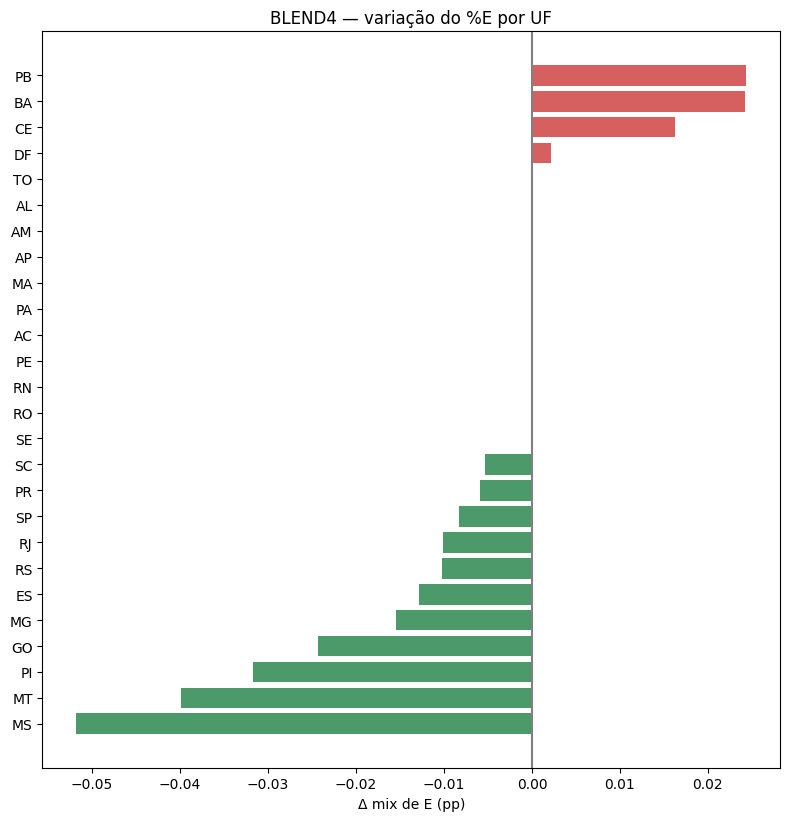

BLEND4 — mix de E por UF


,imovel_uf,n,pct_E_prod,pct_E_ambos,dpp_E,dn_E,pct_desceu,pct_subiu
14,PB,41,24.4%,26.8%,+2.4%,+1,2.4%,0.0%
4,BA,165,31.5%,33.9%,+2.4%,+4,9.1%,1.2%
5,CE,429,44.1%,45.7%,+1.6%,+7,5.1%,0.0%
6,DF,453,22.1%,22.3%,+0.2%,+1,4.2%,0.4%
0,AC,6,16.7%,16.7%,+0.0%,+0,0.0%,0.0%
1,AL,27,18.5%,18.5%,+0.0%,+0,0.0%,0.0%
23,SE,208,28.4%,28.4%,+0.0%,+0,0.0%,1.0%
20,RO,69,17.4%,17.4%,+0.0%,+0,0.0%,0.0%
19,RN,112,32.1%,32.1%,+0.0%,+0,0.0%,1.8%
15,PE,318,23.3%,23.3%,+0.0%,+0,0.6%,1.3%


In [60]:
def plot_uf_e(stats, titulo):
    s = stats.sort_values("dpp_E")
    fig, ax = plt.subplots(figsize=(8, max(3.5, 0.32 * len(s))))
    ax.barh(s[UF_COL].astype(str), s["dpp_E"], color=np.where(s["dpp_E"] >= 0, "#d65f5f", "#4c9a6a"))
    ax.axvline(0, color="gray")
    ax.set_xlabel("Δ mix de E (pp)")
    ax.set_title(f"{titulo} — variação do %E por UF")
    plt.tight_layout()
    plt.show()

    print(f"{titulo} — mix de E por UF")
    display(
        stats.sort_values("dpp_E", ascending=False)[
            [UF_COL, "n", "pct_E_prod", "pct_E_ambos", "dpp_E", "dn_E", "pct_desceu", "pct_subiu"]
        ].style.format({
            "n": "{:,.0f}",
            "pct_E_prod": "{:.1%}", "pct_E_ambos": "{:.1%}", "dpp_E": "{:+.1%}",
            "dn_E": "{:+,.0f}", "pct_desceu": "{:.1%}", "pct_subiu": "{:.1%}",
        })
    )


plot_uf_e(uf_mix3, "BLEND3")
plot_uf_e(uf_mix4, "BLEND4")


## Share de Leads por Estado

Participação de cada UF no funil (jul–ago/2026): leads elegíveis e propostas ativadas. `idx_ativacao` > 1 indica estado que pesa mais nas ativações do que nos leads.


In [61]:
df_funil.groupby("mes_referencia").size()

mes_referencia
2026-07-01    123709
2026-08-01     68154
dtype: int64

Leads=37,434 | Ativações=7,569 | UFs=26


,n_leads,n_ativadas,n_cidades,share_leads,share_ativadas,tx_ativacao,idx_ativacao
imovel_uf,,,,,,,
SP,"12,959","2,534",246,34.6%,33.5%,19.6%,0.97
SC,"6,399","1,129",88,17.1%,14.9%,17.6%,0.87
RS,"5,239","1,176",105,14.0%,15.5%,22.4%,1.11
PR,"4,534",905,78,12.1%,12.0%,20.0%,0.99
MG,"3,027",761,107,8.1%,10.1%,25.1%,1.24
RJ,"1,580",283,38,4.2%,3.7%,17.9%,0.89
GO,756,163,26,2.0%,2.2%,21.6%,1.07
DF,447,133,1,1.2%,1.8%,29.8%,1.47
MT,382,57,20,1.0%,0.8%,14.9%,0.74


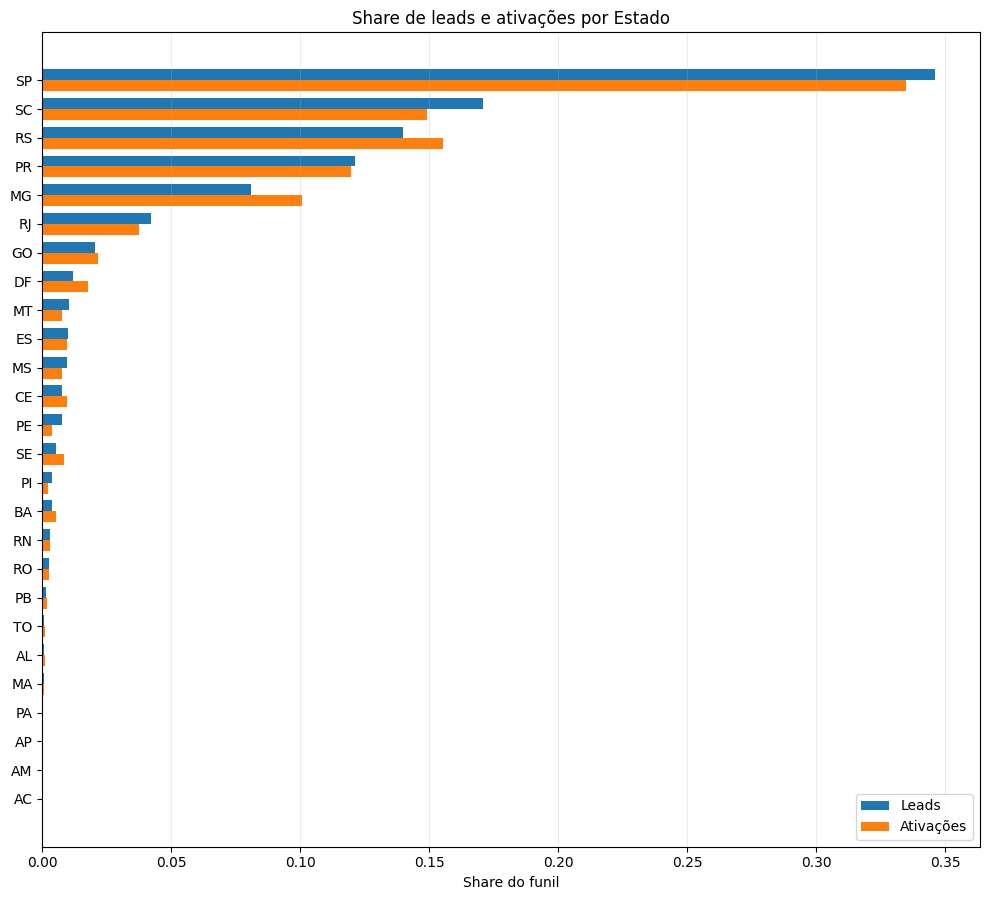

In [62]:
df_share_uf = (
    df_funil[df_funil["mes_referencia"] == "2026-08-01"].assign(imovel_uf=df_funil["imovel_uf"].fillna("sem UF"))
    .groupby("imovel_uf", dropna=False)
    .agg(
        n_leads=("lead_elegivel", "sum"),
        n_ativadas=("proposta_ativada", "sum"),
        n_cidades=(CITY_COL, "nunique"),
    )
    .reset_index()
)

total_leads = df_share_uf["n_leads"].sum()
total_ativadas = df_share_uf["n_ativadas"].sum()
df_share_uf["share_leads"] = df_share_uf["n_leads"] / total_leads if total_leads else np.nan
df_share_uf["share_ativadas"] = df_share_uf["n_ativadas"] / total_ativadas if total_ativadas else np.nan
df_share_uf["tx_ativacao"] = df_share_uf["n_ativadas"] / df_share_uf["n_leads"].replace(0, np.nan)
df_share_uf["idx_ativacao"] = df_share_uf["share_ativadas"] / df_share_uf["share_leads"].replace(0, np.nan)
df_share_uf = df_share_uf.sort_values("n_leads", ascending=False).reset_index(drop=True)

show_uf = pd.concat(
    [
        df_share_uf,
        pd.DataFrame([{
            "imovel_uf": "TOTAL",
            "n_leads": total_leads,
            "n_ativadas": total_ativadas,
            "n_cidades": df_funil[CITY_COL].nunique(),
            "share_leads": 1.0,
            "share_ativadas": 1.0,
            "tx_ativacao": total_ativadas / total_leads if total_leads else np.nan,
            "idx_ativacao": 1.0,
        }]),
    ],
    ignore_index=True,
)

print(f"Leads={total_leads:,.0f} | Ativações={total_ativadas:,.0f} | UFs={df_share_uf['imovel_uf'].nunique()}")
display(
    show_uf.set_index("imovel_uf").style.format({
        "n_leads": "{:,.0f}",
        "n_ativadas": "{:,.0f}",
        "n_cidades": "{:.0f}",
        "share_leads": "{:.1%}",
        "share_ativadas": "{:.1%}",
        "tx_ativacao": "{:.1%}",
        "idx_ativacao": "{:.2f}",
    }, na_rep="—")
)

plot = df_share_uf.sort_values("share_leads")
labels = plot["imovel_uf"].fillna("sem UF").astype(str)
y = np.arange(len(plot))
h = 0.38
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot))))
ax.barh(y + h / 2, plot["share_leads"], height=h, label="Leads", color="#1f77b4")
ax.barh(y - h / 2, plot["share_ativadas"], height=h, label="Ativações", color="#ff7f0e")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Share do funil")
ax.set_title("Share de leads e ativações por Estado")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## Funil a partir de Agosto

Leads de **ago/2026** em `df_blend3` e `df_blend4`. Movimento de rating **prod → ambos**, no mesmo critério da listagem anterior de cidades: **Manteve / Melhora / Piora**.

PC cidade e PC imobiliária vêm das tabelas mensais `blend3_2__variavel_cidade` e `blend3_2__variavel_imobiliaria` (maio a agosto).


In [63]:
project_id = "loft-dl-datascience"

query_city = """
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_cidade
"""

df_city = pd.read_gbq(query_city, project_id=project_id)
df_city

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,3522307,0.028125
1,2025-12-01,5003702,0.030303
2,2025-12-01,4216206,0.033113
3,2025-12-01,5008305,0.036496
4,2025-12-01,3500105,0.039216
...,...,...,...
1709,2026-08-01,3533908,0.180328
1710,2026-08-01,3122306,0.183087
1711,2026-08-01,2800308,0.204589
1712,2026-08-01,4313300,0.207407


In [64]:
project_id = "loft-dl-datascience"

query_agency = """
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_imobiliaria
"""

df_agency = pd.read_gbq(query_agency, project_id=project_id)
df_agency

,mes_referencia,agency_id,agency_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,9706,0.019417
1,2025-12-01,1399,0.021429
2,2025-12-01,4420,0.024390
3,2025-12-01,4926,0.026738
4,2025-12-01,9418,0.028571
...,...,...,...
1284,2026-08-01,10433,0.282258
1285,2026-08-01,592,0.294521
1286,2026-08-01,25913,0.300699
1287,2026-08-01,3419,0.318182


In [65]:
AUG_PERIOD = "2026-08-01"
PC_MONTHS = ["2026-05-01", "2026-06-01", "2026-07-01", "2026-08-01"]
PC_MONTH_LABELS = {
    "2026-05-01": "maio",
    "2026-06-01": "jun",
    "2026-07-01": "jul",
    "2026-08-01": "ago",
}
MOVE_ORDER = ["Manteve", "Melhora", "Piora"]
CITY_PC_BQ = "city_pc4_mais_100_contratos__pc_categorias"
AGENCY_PC_BQ = "agency_pc4_mais_100_contratos__pc_categorias"


def _month_start(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, errors="coerce").dt.strftime("%Y-%m-01")


def _keep_pc_months(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["mes_referencia"] = _month_start(out["mes_referencia"])
    return out.loc[out["mes_referencia"].isin(PC_MONTHS)].copy()


df_city = _keep_pc_months(df_city)
df_agency = _keep_pc_months(df_agency)
print("PC cidade — meses:", sorted(df_city["mes_referencia"].unique()))
print("PC imobiliária — meses:", sorted(df_agency["mes_referencia"].unique()))


def pc_wide(df: pd.DataFrame, entity_col: str, value_col: str) -> pd.DataFrame:
    aux = df[[entity_col, "mes_referencia", value_col]].copy()
    aux[entity_col] = pd.to_numeric(aux[entity_col], errors="coerce").astype("Int64")
    table = aux.pivot_table(
        index=entity_col,
        columns="mes_referencia",
        values=value_col,
        aggfunc="first",
    )
    table.columns = pd.to_datetime(table.columns).strftime("%Y-%m-%d")
    return table.reindex(columns=PC_MONTHS)


city_pc_bq = pc_wide(df_city, CITY_COL, CITY_PC_BQ)
agency_pc_bq = pc_wide(
    df_agency.rename(columns={"agency_id": AGENCY_COL}),
    AGENCY_COL,
    AGENCY_PC_BQ,
)


def august_leads_move(df: pd.DataFrame, col_prod: str, col_ambos: str, model_name: str) -> pd.DataFrame:
    """August eligible leads with prod vs ambos movement, same logic as prepare_rating_move."""
    aux = df.copy()
    aux["mes_referencia"] = _month_start(aux["requested_at"])
    aux = aux.loc[aux["mes_referencia"] == AUG_PERIOD]
    lead = aux["lead_elegivel"]
    if lead.dtype == bool:
        aux = aux.loc[lead].copy()
    else:
        aux = aux.loc[pd.to_numeric(lead, errors="coerce").fillna(0).gt(0)].copy()
    out = prepare_rating_move(aux, col_prod, col_ambos, model_name)
    out["movimento"] = out["movimento"].replace({"Subiu": "Melhora", "Desceu": "Piora"})
    out[CITY_COL] = pd.to_numeric(out[CITY_COL], errors="coerce").astype("Int64")
    out[AGENCY_COL] = pd.to_numeric(out[AGENCY_COL], errors="coerce").astype("Int64")
    out["proposta_ativada"] = pd.to_numeric(out["proposta_ativada"], errors="coerce").fillna(0).astype(int)
    return out


mv3_ago = august_leads_move(
    df_blend3, "rating_manual_blend3_prod", "rating_manual_blend3_ambos", "BLEND3"
)
mv4_ago = august_leads_move(
    df_blend4, "rating_manual_blend4_prod", "rating_manual_blend4_ambos", "BLEND4"
)


def weighted_agency_pc_by_city(df_leads: pd.DataFrame) -> pd.DataFrame:
    """Volume-weighted mean of BQ agency PC4m among the city's August leads."""
    vol = (
        df_leads.groupby([CITY_COL, AGENCY_COL], dropna=False)
        .size()
        .rename("n_leads_imob")
        .reset_index()
    )
    pc = agency_pc_bq.reset_index()
    if AGENCY_COL not in pc.columns:
        pc = pc.rename(columns={pc.columns[0]: AGENCY_COL})
    pc[AGENCY_COL] = pd.to_numeric(pc[AGENCY_COL], errors="coerce").astype("Int64")
    merged = vol.merge(pc, on=AGENCY_COL, how="left")
    rows = []
    for city, grp in merged.groupby(CITY_COL, dropna=False):
        rec = {CITY_COL: city, "n_imobs": int(grp[AGENCY_COL].nunique())}
        weights = grp["n_leads_imob"].to_numpy(dtype=float)
        for month in PC_MONTHS:
            label = PC_MONTH_LABELS[month]
            vals = pd.to_numeric(grp[month], errors="coerce").to_numpy(dtype=float)
            mask = np.isfinite(vals) & np.isfinite(weights) & (weights > 0)
            rec[f"pc_imob_{label}"] = (
                float(np.average(vals[mask], weights=weights[mask])) if mask.any() else np.nan
            )
        rows.append(rec)
    return pd.DataFrame(rows)


def city_pc_named() -> pd.DataFrame:
    out = city_pc_bq.reset_index()
    if CITY_COL not in out.columns:
        out = out.rename(columns={out.columns[0]: CITY_COL})
    out[CITY_COL] = pd.to_numeric(out[CITY_COL], errors="coerce").astype("Int64")
    return out.rename(columns={m: f"pc_cidade_{lab}" for m, lab in PC_MONTH_LABELS.items()})


PC_CIDADE_COLS = [f"pc_cidade_{lab}" for lab in PC_MONTH_LABELS.values()]
PC_IMOB_COLS = [f"pc_imob_{lab}" for lab in PC_MONTH_LABELS.values()]
pc_cidade_cols = city_pc_named()


def city_movimento_table(df_leads: pd.DataFrame, movimento: str, n: int = 10) -> pd.DataFrame:
    """Top cities by Melhora/Piora volume, with share vs total and May-Aug PC."""
    total_leads = len(df_leads)
    total_ativadas = int(df_leads["proposta_ativada"].sum())
    n_mov = int((df_leads["movimento"] == movimento).sum())
    count_col = "n_melhora" if movimento == "Melhora" else "n_piora"
    grouped = (
        df_leads.groupby(CITY_COL, dropna=False)
        .agg(
            imovel_cidade=("imovel_cidade", "first"),
            imovel_uf=("imovel_uf", "first"),
            n_leads=("movimento", "size"),
            n_ativadas=("proposta_ativada", "sum"),
            n_manteve=("movimento", lambda s: (s == "Manteve").sum()),
            n_melhora=("movimento", lambda s: (s == "Melhora").sum()),
            n_piora=("movimento", lambda s: (s == "Piora").sum()),
        )
        .reset_index()
    )
    grouped["share_leads"] = grouped["n_leads"] / total_leads if total_leads else np.nan
    grouped["share_ativadas"] = grouped["n_ativadas"] / total_ativadas if total_ativadas else np.nan
    grouped["tx_ativacao"] = grouped["n_ativadas"] / grouped["n_leads"].replace(0, np.nan)
    grouped["idx_ativacao"] = grouped["share_ativadas"] / grouped["share_leads"].replace(0, np.nan)
    grouped["share_mov"] = grouped[count_col] / n_mov if n_mov else np.nan
    grouped["pct_mov"] = grouped[count_col] / grouped["n_leads"].replace(0, np.nan)
    top = grouped.nlargest(n, count_col).copy()
    top["share_acum_mov"] = top["share_mov"].cumsum()
    top["share_acum_leads"] = top["share_leads"].cumsum()
    top["share_acum_ativadas"] = top["share_ativadas"].cumsum()
    top = top.merge(pc_cidade_cols, on=CITY_COL, how="left")
    top = top.merge(weighted_agency_pc_by_city(df_leads), on=CITY_COL, how="left")
    top["delta_pc_cidade"] = top["pc_cidade_ago"] - top["pc_cidade_maio"]
    top["delta_pc_imob"] = top["pc_imob_ago"] - top["pc_imob_maio"]
    top.attrs["movimento"] = movimento
    top.attrs["n_mov"] = n_mov
    top.attrs["total_leads"] = total_leads
    top.attrs["total_ativadas"] = total_ativadas
    top.attrs["count_col"] = count_col
    top.attrs["modelo"] = df_leads["modelo"].iloc[0] if len(df_leads) else ""
    return top


def agencies_of_top_cities(df_leads: pd.DataFrame, city_ids: pd.Series, n_per_city: int = 5) -> pd.DataFrame:
    sub = df_leads.loc[df_leads[CITY_COL].isin(city_ids)].copy()
    grouped = (
        sub.groupby([CITY_COL, "imovel_cidade", "imovel_uf", AGENCY_COL], dropna=False)
        .agg(
            n_leads=("movimento", "size"),
            n_melhora=("movimento", lambda s: (s == "Melhora").sum()),
            n_piora=("movimento", lambda s: (s == "Piora").sum()),
        )
        .reset_index()
    )
    grouped["rank_imob"] = grouped.groupby(CITY_COL)["n_leads"].rank(method="first", ascending=False)
    grouped = grouped.loc[grouped["rank_imob"] <= n_per_city].copy()
    pc = agency_pc_bq.reset_index()
    if AGENCY_COL not in pc.columns:
        pc = pc.rename(columns={pc.columns[0]: AGENCY_COL})
    pc[AGENCY_COL] = pd.to_numeric(pc[AGENCY_COL], errors="coerce").astype("Int64")
    pc = pc.rename(columns={m: f"pc_imob_{lab}" for m, lab in PC_MONTH_LABELS.items()})
    grouped = grouped.merge(pc[[AGENCY_COL] + PC_IMOB_COLS], on=AGENCY_COL, how="left")
    return grouped.sort_values(["imovel_cidade", "n_leads"], ascending=[True, False])


FMT_CITY = {
    "n_leads": "{:,.0f}",
    "n_ativadas": "{:,.0f}",
    "n_manteve": "{:,.0f}",
    "n_melhora": "{:,.0f}",
    "n_piora": "{:,.0f}",
    "n_imobs": "{:,.0f}",
    "share_leads": "{:.1%}",
    "share_ativadas": "{:.1%}",
    "share_acum_leads": "{:.1%}",
    "share_acum_ativadas": "{:.1%}",
    "tx_ativacao": "{:.1%}",
    "idx_ativacao": "{:.2f}",
    "share_mov": "{:.1%}",
    "share_acum_mov": "{:.1%}",
    "pct_mov": "{:.1%}",
    "delta_pc_cidade": "{:+.3f}",
    "delta_pc_imob": "{:+.3f}",
    **{c: "{:.3f}" for c in PC_CIDADE_COLS + PC_IMOB_COLS},
}
FMT_IMOB = {
    "n_leads": "{:,.0f}",
    "n_melhora": "{:,.0f}",
    "n_piora": "{:,.0f}",
    **{c: "{:.3f}" for c in PC_IMOB_COLS},
}


def display_top_cities(df_leads: pd.DataFrame, top: pd.DataFrame, n_imob: int = 5) -> pd.DataFrame:
    movimento = top.attrs["movimento"]
    n_mov = top.attrs["n_mov"]
    total_leads = top.attrs["total_leads"]
    total_ativadas = top.attrs.get("total_ativadas", np.nan)
    count_col = top.attrs["count_col"]
    modelo = top.attrs["modelo"]
    show_cols = [
        "imovel_cidade", "imovel_uf", CITY_COL,
        "n_leads", "share_leads", "share_acum_leads",
        "n_ativadas", "share_ativadas", "share_acum_ativadas",
        "tx_ativacao", "idx_ativacao",
        count_col, "share_mov", "share_acum_mov", "pct_mov",
        "n_imobs", "delta_pc_cidade", "delta_pc_imob",
        *PC_CIDADE_COLS, *PC_IMOB_COLS,
    ]
    show_cols = [c for c in show_cols if c in top.columns]
    print(
        f"{modelo} — leads ago/2026 — top {len(top)} cidades ({movimento}): "
        f"{int(top[count_col].sum()):,} de {n_mov:,} {movimento.lower()}s "
        f"({top['share_mov'].sum():.1%}) | "
        f"share de leads {top['share_leads'].sum():.1%} de {total_leads:,}"
        + (
            f" | share de ativações {top['share_ativadas'].sum():.1%} de {int(total_ativadas):,}"
            if "share_ativadas" in top.columns and pd.notna(total_ativadas)
            else ""
        )
    )
    display(top.set_index(["imovel_cidade", "imovel_uf"])[show_cols[2:]].style.format(FMT_CITY))

    imobs = agencies_of_top_cities(df_leads, top[CITY_COL], n_per_city=n_imob)
    print(f"{modelo} — top {n_imob} imobiliárias por cidade (PC 4 meses, maio a agosto)")
    imob_cols = [
        "imovel_cidade", "imovel_uf", AGENCY_COL, "n_leads", "n_melhora", "n_piora",
        *PC_IMOB_COLS,
    ]
    display(imobs[imob_cols].reset_index(drop=True).style.format(FMT_IMOB))

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.38 * len(top))))
    labels = (
        top["imovel_cidade"].fillna(top[CITY_COL].astype(str))
        + " (" + top["imovel_uf"].fillna("sem UF").astype(str) + ")"
    )
    color = "#2ca02c" if movimento == "Melhora" else "#d62728"
    axes[0].barh(labels[::-1], top[count_col][::-1], color=color)
    axes[0].set_xlabel(f"n {movimento.lower()}")
    axes[0].set_title(f"{modelo} — top cidades {movimento}")
    axes[0].grid(axis="x", alpha=0.25)

    x = np.arange(len(PC_MONTHS))
    for _, row in top.iterrows():
        y = [row.get(c, np.nan) for c in PC_CIDADE_COLS]
        label = str(row["imovel_cidade"]) if pd.notna(row["imovel_cidade"]) else str(row[CITY_COL])
        axes[1].plot(x, y, marker="o", label=label)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(["maio", "jun", "jul", "ago"])
    axes[1].set_ylabel("PC cidade 4m")
    axes[1].set_title("PC cidade — maio a agosto")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
    return imobs


def resumo_leads_ago(df: pd.DataFrame, titulo: str) -> None:
    n = len(df)
    tab = (
        df["movimento"]
        .value_counts()
        .reindex(MOVE_ORDER, fill_value=0)
        .to_frame("n")
    )
    tab["%"] = tab["n"] / n if n else np.nan
    print(f"{titulo} — leads ago/2026 n={n:,}")
    display(tab.style.format({"n": "{:,.0f}", "%": "{:.1%}"}))
    print(f"{titulo} — matriz prod → ambos")
    mat = (
        pd.crosstab(df["rating_prod"], df["rating_ambos"])
        .reindex(index=RATING_ORDER, columns=RATING_ORDER, fill_value=0)
    )
    display(mat.assign(total=mat.sum(axis=1)))
    for mov in ["Melhora", "Piora"]:
        print(f"{titulo} — caminhos de {mov.lower()}")
        display(
            df.loc[df["movimento"] == mov, "transicao"]
            .value_counts()
            .to_frame("n")
            .assign(pct=lambda x: x["n"] / x["n"].sum())
            .style.format({"n": "{:,.0f}", "pct": "{:.1%}"})
        )


resumo_leads_ago(mv3_ago, "BLEND3")
resumo_leads_ago(mv4_ago, "BLEND4")


PC cidade — meses: ['2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01']
PC imobiliária — meses: ['2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01']
BLEND3 — leads ago/2026 n=18,031


,n,%
movimento,,
Manteve,"17,161",95.2%
Melhora,470,2.6%
Piora,400,2.2%


BLEND3 — matriz prod → ambos


rating_ambos,A,B,C,D,E,total
rating_prod,,,,,,
A,10034,106,5,0,4,10149
B,280,6872,83,0,116,7351
C,0,184,137,0,86,407
D,0,0,0,0,0,0
E,0,3,3,0,118,124


BLEND3 — caminhos de melhora


...

rating_ambos,A,B,C,D,E,total
rating_prod,,,,,,
A,11486,161,5,0,0,11652
B,322,1258,141,12,0,1733
C,2,301,1280,166,0,1749
D,0,2,389,3146,174,3711
E,0,0,0,5,87,92


BLEND4 — caminhos de melhora


,n,pct
transicao,,
D → C,389,38.1%
B → A,322,31.5%
C → B,301,29.5%
E → D,5,0.5%
D → B,2,0.2%
C → A,2,0.2%


BLEND4 — caminhos de piora


,n,pct
transicao,,
D → E,174,26.4%
C → D,166,25.2%
A → B,161,24.4%
B → C,141,21.4%
B → D,12,1.8%
A → C,5,0.8%


### Leads — Top 10 cidades Melhora

Share de leads e de ativações vs o total de ago/2026, e share vs o total de melhoras. PC cidade e PC imobiliária (média ponderada pelo volume) nas tabelas mensais, maio a agosto. Junho fica nulo se a tabela não tiver aquele mês.



BLEND3 — leads ago/2026 — top 10 cidades (Melhora): 182 de 470 melhoras (38.7%) | share de leads 15.1% de 18,031 | share de ativações 14.9% de 3,807


,,id_cidade_ibge,n_leads,share_leads,share_acum_leads,n_ativadas,share_ativadas,share_acum_ativadas,tx_ativacao,idx_ativacao,n_melhora,share_mov,share_acum_mov,pct_mov,n_imobs,delta_pc_cidade,delta_pc_imob,pc_cidade_maio,pc_cidade_jun,pc_cidade_jul,pc_cidade_ago,pc_imob_maio,pc_imob_jun,pc_imob_jul,pc_imob_ago
imovel_cidade,imovel_uf,,,,,,,,,,,,,,,,,,,,,,,,
Londrina,PR,4113700,607,3.4%,3.4%,102,2.7%,2.7%,16.8%,0.80,44,9.4%,9.4%,7.2%,123,+0.011,-0.005,0.102,0.107,0.108,0.113,0.159,0.152,0.157,0.154
São Paulo,SP,3550308,683,3.8%,7.2%,149,3.9%,6.6%,21.8%,1.03,23,4.9%,14.3%,3.4%,255,+0.008,-0.018,0.087,0.088,0.089,0.095,0.099,0.103,0.096,0.081
Campo Grande,MS,5002704,131,0.7%,7.9%,21,0.6%,7.1%,16.0%,0.76,22,4.7%,18.9%,16.8%,49,+0.024,+nan,0.060,0.063,0.072,0.084,nan,nan,nan,nan
Bauru,SP,3506003,234,1.3%,9.2%,58,1.5%,8.7%,24.8%,1.17,18,3.8%,22.8%,7.7%,47,+0.010,+0.026,0.109,0.114,0.109,0.119,0.102,0.102,0.105,0.128
Taubaté,SP,3554102,126,0.7%,9.9%,23,0.6%,9.3%,18.3%,0.86,16,3.4%,26.2%,12.7%,45,+0.023,+nan,0.062,0.066,0.077,0.085,nan,nan,nan,nan
Blumenau,SC,4202404,411,2.3%,12.2%,90,2.4%,11.6%,21.9%,1.04,15,3.2%,29.4%,3.6%,64,+0.008,+0.014,0.083,0.086,0.087,0.091,0.108,0.118,0.112,0.122
Piracicaba,SP,3538709,241,1.3%,13.5%,61,1.6%,13.2%,25.3%,1.20,12,2.6%,31.9%,5.0%,38,+0.009,+0.012,0.095,0.098,0.107,0.105,0.111,0.116,0.130,0.123
Ibiporã,PR,4109807,38,0.2%,13.7%,8,0.2%,13.4%,21.1%,1.00,12,2.6%,34.5%,31.6%,10,+nan,+nan,0.049,0.055,nan,nan,nan,nan,nan,nan
Pouso Alegre,MG,3152501,62,0.3%,14.0%,20,0.5%,14.0%,32.3%,1.53,10,2.1%,36.6%,16.1%,20,+0.040,+0.011,0.043,0.048,0.055,0.083,0.047,0.051,0.049,0.058


BLEND3 — top 5 imobiliárias por cidade (PC 4 meses, maio a agosto)


,imovel_cidade,imovel_uf,id_imobiliaria,n_leads,n_melhora,n_piora,pc_imob_maio,pc_imob_jun,pc_imob_jul,pc_imob_ago
0,Bauru,SP,549,54,2,0,0.102,0.102,0.105,0.128
1,Bauru,SP,39383,24,4,0,nan,nan,nan,nan
2,Bauru,SP,13335,13,2,0,nan,nan,nan,nan
3,Bauru,SP,17556,8,1,0,nan,nan,nan,nan
4,Bauru,SP,57110,8,1,0,nan,nan,nan,nan
5,Blumenau,SC,3552,36,0,5,0.099,nan,nan,nan
6,Blumenau,SC,40682,33,1,0,0.212,0.218,0.195,0.183
7,Blumenau,SC,35054,32,0,0,0.084,0.116,0.111,0.148
8,Blumenau,SC,2466,19,1,0,0.057,0.061,0.069,0.065
9,Blumenau,SC,4420,18,0,0,0.067,0.072,0.087,0.083


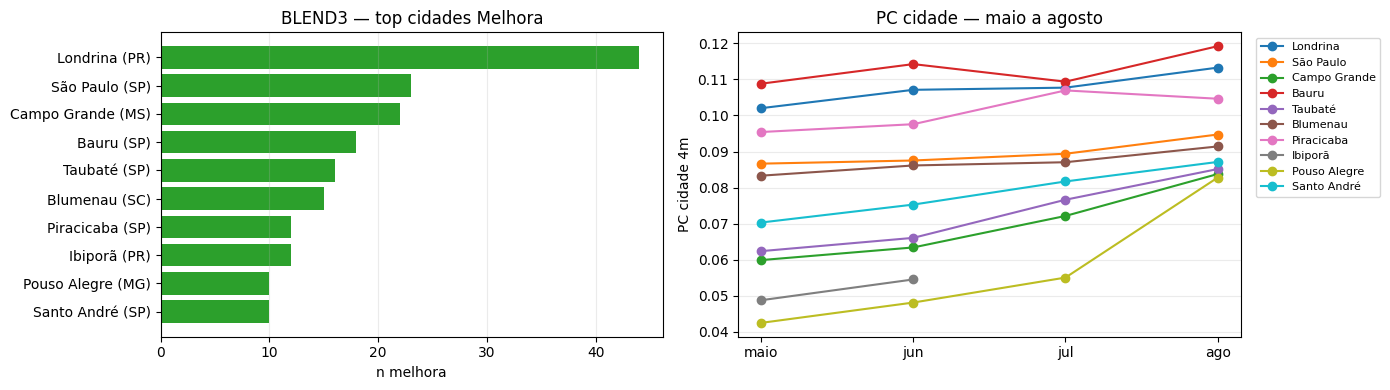

BLEND4 — leads ago/2026 — top 10 cidades (Melhora): 348 de 1,021 melhoras (34.1%) | share de leads 14.3% de 18,937 | share de ativações 13.4% de 3,709


,,id_cidade_ibge,n_leads,share_leads,share_acum_leads,n_ativadas,share_ativadas,share_acum_ativadas,tx_ativacao,idx_ativacao,n_melhora,share_mov,share_acum_mov,pct_mov,n_imobs,delta_pc_cidade,delta_pc_imob,pc_cidade_maio,pc_cidade_jun,pc_cidade_jul,pc_cidade_ago,pc_imob_maio,pc_imob_jun,pc_imob_jul,pc_imob_ago
imovel_cidade,imovel_uf,,,,,,,,,,,,,,,,,,,,,,,,
Londrina,PR,4113700,631,3.3%,3.3%,124,3.3%,3.3%,19.7%,1.00,56,5.5%,5.5%,8.9%,120,+0.011,-0.006,0.102,0.107,0.108,0.113,0.159,0.152,0.157,0.153
São Paulo,SP,3550308,704,3.7%,7.0%,124,3.3%,6.7%,17.6%,0.90,42,4.1%,9.6%,6.0%,245,+0.008,-0.018,0.087,0.088,0.089,0.095,0.096,0.102,0.095,0.078
Novo Hamburgo,RS,4313409,121,0.6%,7.7%,19,0.5%,7.2%,15.7%,0.80,42,4.1%,13.7%,34.7%,28,+0.039,+nan,0.120,0.143,0.145,0.159,0.170,0.178,0.173,nan
Balneário Camboriú,SC,4202008,187,1.0%,8.7%,23,0.6%,7.8%,12.3%,0.63,39,3.8%,17.5%,20.9%,67,+0.026,+0.069,0.071,0.071,0.074,0.098,0.086,0.125,0.130,0.155
Brusque,SC,4202909,142,0.7%,9.4%,24,0.6%,8.5%,16.9%,0.86,32,3.1%,20.7%,22.5%,15,+0.030,+0.041,0.122,0.129,0.146,0.153,0.108,0.112,0.134,0.148
Jaú,SP,3525300,126,0.7%,10.1%,32,0.9%,9.3%,25.4%,1.30,31,3.0%,23.7%,24.6%,15,+0.021,+0.044,0.098,0.095,0.108,0.119,0.098,0.104,0.119,0.142
Goiânia,GO,5208707,209,1.1%,11.2%,34,0.9%,10.2%,16.3%,0.83,30,2.9%,26.6%,14.4%,64,+0.018,+0.028,0.160,0.166,0.172,0.178,0.260,0.272,0.286,0.288
Santo André,SP,3547809,200,1.1%,12.3%,37,1.0%,11.2%,18.5%,0.94,28,2.7%,29.4%,14.0%,52,+0.017,+nan,0.070,0.075,0.082,0.087,nan,nan,nan,nan
Limeira,SP,3526902,228,1.2%,13.5%,55,1.5%,12.7%,24.1%,1.23,26,2.5%,31.9%,11.4%,17,+0.010,+0.016,0.121,0.126,0.120,0.131,0.120,0.127,0.123,0.136


BLEND4 — top 5 imobiliárias por cidade (PC 4 meses, maio a agosto)


,imovel_cidade,imovel_uf,id_imobiliaria,n_leads,n_melhora,n_piora,pc_imob_maio,pc_imob_jun,pc_imob_jul,pc_imob_ago
0,Americana,SP,12495,18,3,0,nan,nan,nan,nan
1,Americana,SP,9887,13,0,0,nan,nan,nan,nan
2,Americana,SP,21511,10,0,0,nan,nan,nan,nan
3,Americana,SP,2124,9,5,0,nan,nan,nan,0.184
4,Americana,SP,57027,9,2,0,nan,nan,nan,nan
5,Balneário Camboriú,SC,1752,16,5,0,0.044,0.097,0.106,0.133
6,Balneário Camboriú,SC,17752,16,2,0,nan,nan,nan,nan
7,Balneário Camboriú,SC,2018,12,3,0,nan,nan,nan,nan
8,Balneário Camboriú,SC,26205,8,3,0,nan,nan,nan,nan
9,Balneário Camboriú,SC,34779,8,5,0,nan,nan,nan,nan


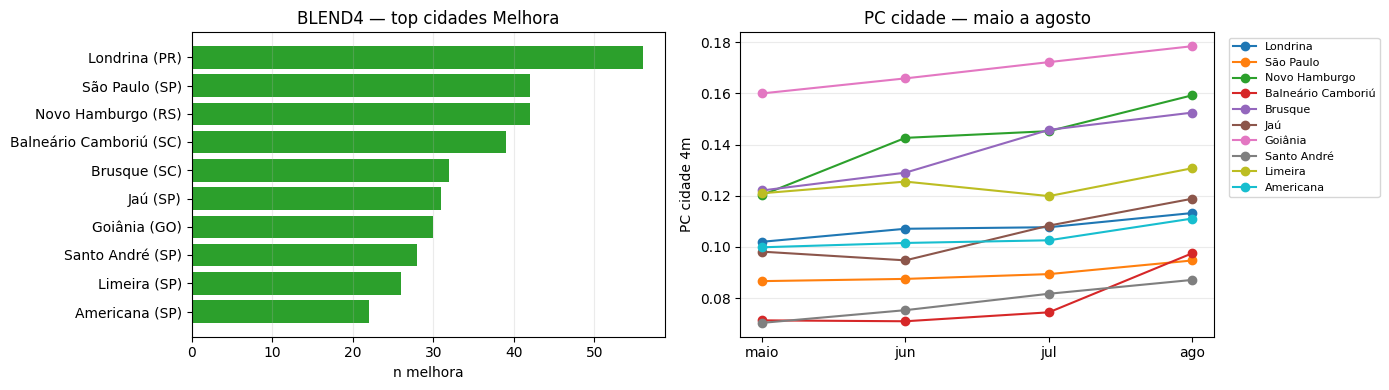

In [66]:
top_melhora_b3 = city_movimento_table(mv3_ago, "Melhora", n=10)
imob_melhora_b3 = display_top_cities(mv3_ago, top_melhora_b3)

top_melhora_b4 = city_movimento_table(mv4_ago, "Melhora", n=10)
imob_melhora_b4 = display_top_cities(mv4_ago, top_melhora_b4)


### Leads — Top 10 cidades Piora

Share de leads e de ativações vs o total de ago/2026, e share vs o total de pioras. PC cidade e PC imobiliária (média ponderada pelo volume) nas tabelas mensais, maio a agosto.



BLEND3 — leads ago/2026 — top 10 cidades (Piora): 178 de 400 pioras (44.5%) | share de leads 7.9% de 18,031 | share de ativações 7.1% de 3,807


,,id_cidade_ibge,n_leads,share_leads,share_acum_leads,n_ativadas,share_ativadas,share_acum_ativadas,tx_ativacao,idx_ativacao,n_piora,share_mov,share_acum_mov,pct_mov,n_imobs,delta_pc_cidade,delta_pc_imob,pc_cidade_maio,pc_cidade_jun,pc_cidade_jul,pc_cidade_ago,pc_imob_maio,pc_imob_jun,pc_imob_jul,pc_imob_ago
imovel_cidade,imovel_uf,,,,,,,,,,,,,,,,,,,,,,,,
Sorocaba,SP,3552205,257,1.4%,1.4%,50,1.3%,1.3%,19.5%,0.92,35,8.8%,8.8%,13.6%,64,-0.008,+nan,0.089,0.086,0.082,0.081,0.148,0.123,nan,nan
Sinop,MT,5107909,45,0.2%,1.7%,5,0.1%,1.4%,11.1%,0.53,25,6.2%,15.0%,55.6%,7,+nan,+nan,nan,0.037,0.037,0.026,nan,nan,nan,nan
Passo Fundo,RS,4314100,99,0.5%,2.2%,22,0.6%,2.0%,22.2%,1.05,22,5.5%,20.5%,22.2%,22,-0.048,-0.014,0.145,0.127,0.112,0.097,0.135,0.140,0.124,0.121
Curitiba,PR,4106902,465,2.6%,4.8%,77,2.0%,4.0%,16.6%,0.78,16,4.0%,24.5%,3.4%,118,-0.008,+0.009,0.082,0.076,0.077,0.074,0.077,0.073,0.081,0.086
Jacareí,SP,3524402,215,1.2%,6.0%,38,1.0%,5.0%,17.7%,0.84,15,3.8%,28.2%,7.0%,41,-0.012,-0.018,0.094,0.091,0.083,0.082,0.093,0.087,0.076,0.075
Birigui,SP,3506508,93,0.5%,6.5%,25,0.7%,5.7%,26.9%,1.27,14,3.5%,31.8%,15.1%,24,-0.021,+nan,0.104,0.095,0.095,0.083,nan,nan,nan,nan
Botucatu,SP,3507506,95,0.5%,7.0%,22,0.6%,6.3%,23.2%,1.10,14,3.5%,35.2%,14.7%,30,-0.019,+0.025,0.111,0.097,0.095,0.093,0.135,0.135,0.149,0.160
Cachoeirinha,RS,4303103,36,0.2%,7.2%,4,0.1%,6.4%,11.1%,0.53,14,3.5%,38.8%,38.9%,17,-0.048,+0.003,0.168,0.177,0.164,0.120,0.096,0.093,0.088,0.099
Tijucas,SC,4218004,83,0.5%,7.7%,17,0.4%,6.8%,20.5%,0.97,12,3.0%,41.8%,14.5%,14,-0.019,-0.006,0.097,0.081,0.068,0.079,0.192,0.172,0.172,0.185


BLEND3 — top 5 imobiliárias por cidade (PC 4 meses, maio a agosto)


,imovel_cidade,imovel_uf,id_imobiliaria,n_leads,n_melhora,n_piora,pc_imob_maio,pc_imob_jun,pc_imob_jul,pc_imob_ago
0,Araranguá,SC,34890,13,0,2,nan,nan,nan,nan
1,Araranguá,SC,1984,6,0,2,nan,nan,nan,nan
2,Araranguá,SC,39406,5,0,2,nan,nan,nan,nan
3,Araranguá,SC,11878,4,0,0,nan,nan,nan,nan
4,Araranguá,SC,18294,4,0,3,nan,nan,nan,nan
5,Birigui,SP,3974,16,0,5,nan,nan,nan,nan
6,Birigui,SP,3783,10,0,2,nan,nan,nan,nan
7,Birigui,SP,3755,8,0,1,nan,nan,nan,nan
8,Birigui,SP,29685,7,0,1,nan,nan,nan,nan
9,Birigui,SP,3757,6,0,0,nan,nan,nan,nan


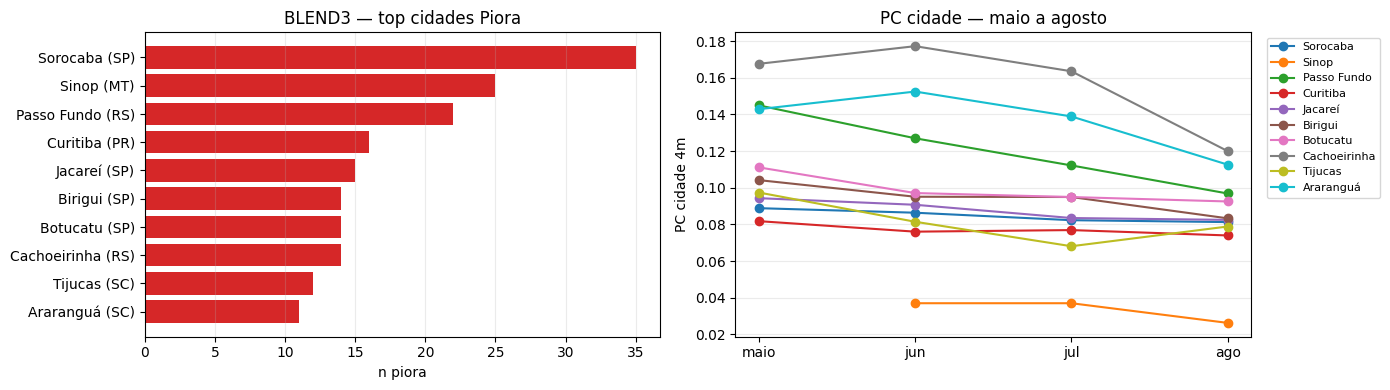

BLEND4 — leads ago/2026 — top 10 cidades (Piora): 244 de 659 pioras (37.0%) | share de leads 8.6% de 18,937 | share de ativações 7.6% de 3,709


,,id_cidade_ibge,n_leads,share_leads,share_acum_leads,n_ativadas,share_ativadas,share_acum_ativadas,tx_ativacao,idx_ativacao,n_piora,share_mov,share_acum_mov,pct_mov,n_imobs,delta_pc_cidade,delta_pc_imob,pc_cidade_maio,pc_cidade_jun,pc_cidade_jul,pc_cidade_ago,pc_imob_maio,pc_imob_jun,pc_imob_jul,pc_imob_ago
imovel_cidade,imovel_uf,,,,,,,,,,,,,,,,,,,,,,,,
Passo Fundo,RS,4314100,113,0.6%,0.6%,11,0.3%,0.3%,9.7%,0.50,49,7.4%,7.4%,43.4%,24,-0.048,-0.014,0.145,0.127,0.112,0.097,0.135,0.140,0.124,0.121
Sorocaba,SP,3552205,287,1.5%,2.1%,39,1.1%,1.3%,13.6%,0.69,43,6.5%,14.0%,15.0%,75,-0.008,+nan,0.089,0.086,0.082,0.081,0.151,0.123,nan,nan
Botucatu,SP,3507506,115,0.6%,2.7%,33,0.9%,2.2%,28.7%,1.47,26,3.9%,17.9%,22.6%,32,-0.019,+0.025,0.111,0.097,0.095,0.093,0.145,0.145,0.161,0.170
Birigui,SP,3506508,103,0.5%,3.3%,18,0.5%,2.7%,17.5%,0.89,23,3.5%,21.4%,22.3%,25,-0.021,+nan,0.104,0.095,0.095,0.083,nan,nan,nan,nan
Erechim,RS,4307005,37,0.2%,3.5%,13,0.4%,3.1%,35.1%,1.79,18,2.7%,24.1%,48.6%,9,-0.028,+nan,0.089,0.070,0.066,0.061,0.140,0.116,0.115,nan
Fortaleza,CE,2304400,122,0.6%,4.1%,43,1.2%,4.2%,35.2%,1.80,17,2.6%,26.7%,13.9%,35,-0.009,-0.034,0.135,0.136,0.123,0.126,0.172,0.179,0.157,0.138
Jacareí,SP,3524402,234,1.2%,5.3%,39,1.1%,5.3%,16.7%,0.85,17,2.6%,29.3%,7.3%,42,-0.012,-0.022,0.094,0.091,0.083,0.082,0.095,0.087,0.074,0.073
Curitiba,PR,4106902,447,2.4%,7.7%,61,1.6%,6.9%,13.6%,0.70,17,2.6%,31.9%,3.8%,115,-0.008,+0.012,0.082,0.076,0.077,0.074,0.077,0.074,0.084,0.089
São José Dos Pinhais,PR,4125506,89,0.5%,8.2%,10,0.3%,7.2%,11.2%,0.57,17,2.6%,34.4%,19.1%,30,-0.022,-0.006,0.078,0.058,0.065,0.057,0.087,0.076,0.081,0.081


BLEND4 — top 5 imobiliárias por cidade (PC 4 meses, maio a agosto)


,imovel_cidade,imovel_uf,id_imobiliaria,n_leads,n_melhora,n_piora,pc_imob_maio,pc_imob_jun,pc_imob_jul,pc_imob_ago
0,Birigui,SP,3974,21,0,3,nan,nan,nan,nan
1,Birigui,SP,8038,9,0,5,nan,nan,nan,nan
2,Birigui,SP,3755,8,0,3,nan,nan,nan,nan
3,Birigui,SP,17725,8,0,0,nan,nan,nan,nan
4,Birigui,SP,3767,6,0,1,nan,nan,nan,nan
5,Botucatu,SP,12471,15,0,3,nan,nan,nan,nan
6,Botucatu,SP,578,12,0,3,0.145,0.145,0.161,0.170
7,Botucatu,SP,10284,9,0,4,nan,nan,nan,nan
8,Botucatu,SP,10474,8,0,2,nan,nan,nan,nan
9,Botucatu,SP,16095,8,0,2,nan,nan,nan,nan


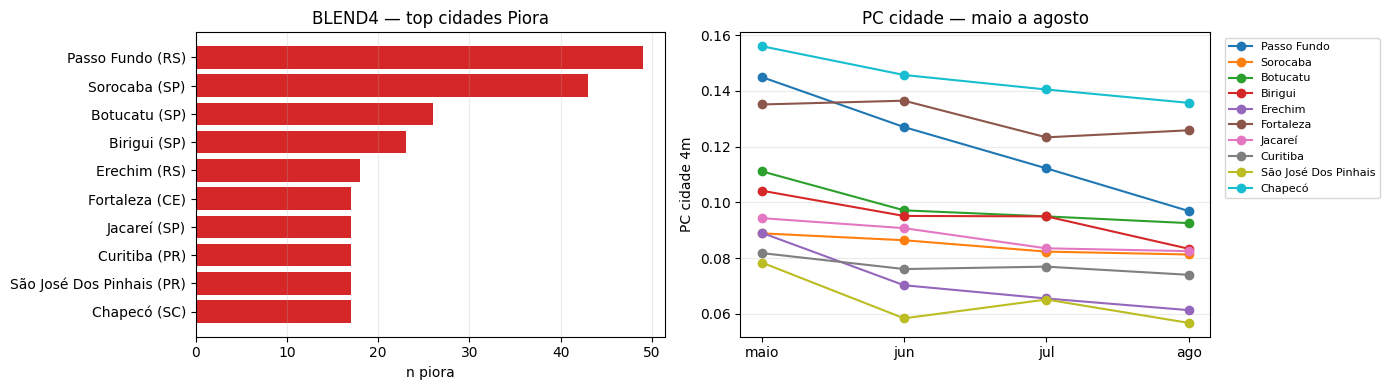

In [67]:
top_piora_b3 = city_movimento_table(mv3_ago, "Piora", n=10)
imob_piora_b3 = display_top_cities(mv3_ago, top_piora_b3)

top_piora_b4 = city_movimento_table(mv4_ago, "Piora", n=10)
imob_piora_b4 = display_top_cities(mv4_ago, top_piora_b4)


## Avaliação Share Funil

Nas cidades do Top 10 **Melhora** e do Top 10 **Piora**, comparação do **share de leads** com o **share de ativações** em ago/2026.

- `idx_ativacao` = share de ativações / share de leads. Acima de 1: a cidade pesa mais nas ativações do que no volume de leads.
- Também entra o bloco agregado (as 10 cidades juntas) versus o restante da base.


BLEND3 — base ago/2026: leads=18,031 | ativações=3,807 | tx ativação=21.1%
BLEND3 — Top 10 Melhora: share de leads vs ativações


,,n_leads,n_ativadas,share_leads,share_ativadas,share_acum_leads,share_acum_ativadas,tx_ativacao,idx_ativacao,n_melhora,n_piora
imovel_cidade,imovel_uf,,,,,,,,,,
Londrina,PR,607,102,3.4%,2.7%,3.4%,2.7%,16.8%,0.80,44,0
São Paulo,SP,683,149,3.8%,3.9%,7.2%,6.6%,21.8%,1.03,23,0
Campo Grande,MS,131,21,0.7%,0.6%,7.9%,7.1%,16.0%,0.76,22,0
Bauru,SP,234,58,1.3%,1.5%,9.2%,8.7%,24.8%,1.17,18,0
Taubaté,SP,126,23,0.7%,0.6%,9.9%,9.3%,18.3%,0.86,16,0
Blumenau,SC,411,90,2.3%,2.4%,12.2%,11.6%,21.9%,1.04,15,7
Piracicaba,SP,241,61,1.3%,1.6%,13.5%,13.2%,25.3%,1.20,12,0
Ibiporã,PR,38,8,0.2%,0.2%,13.7%,13.4%,21.1%,1.00,12,0
Pouso Alegre,MG,62,20,0.3%,0.5%,14.0%,14.0%,32.3%,1.53,10,0


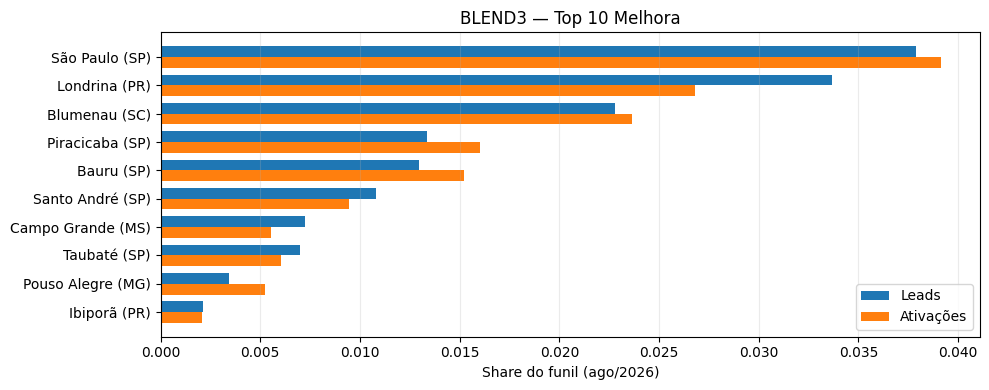

BLEND3 — Top 10 Piora: share de leads vs ativações


,,n_leads,n_ativadas,share_leads,share_ativadas,share_acum_leads,share_acum_ativadas,tx_ativacao,idx_ativacao,n_melhora,n_piora
imovel_cidade,imovel_uf,,,,,,,,,,
Sorocaba,SP,257,50,1.4%,1.3%,1.4%,1.3%,19.5%,0.92,0,35
Sinop,MT,45,5,0.2%,0.1%,1.7%,1.4%,11.1%,0.53,0,25
Passo Fundo,RS,99,22,0.5%,0.6%,2.2%,2.0%,22.2%,1.05,0,22
Curitiba,PR,465,77,2.6%,2.0%,4.8%,4.0%,16.6%,0.78,0,16
Jacareí,SP,215,38,1.2%,1.0%,6.0%,5.0%,17.7%,0.84,0,15
Birigui,SP,93,25,0.5%,0.7%,6.5%,5.7%,26.9%,1.27,0,14
Botucatu,SP,95,22,0.5%,0.6%,7.0%,6.3%,23.2%,1.10,0,14
Cachoeirinha,RS,36,4,0.2%,0.1%,7.2%,6.4%,11.1%,0.53,0,14
Tijucas,SC,83,17,0.5%,0.4%,7.7%,6.8%,20.5%,0.97,0,12


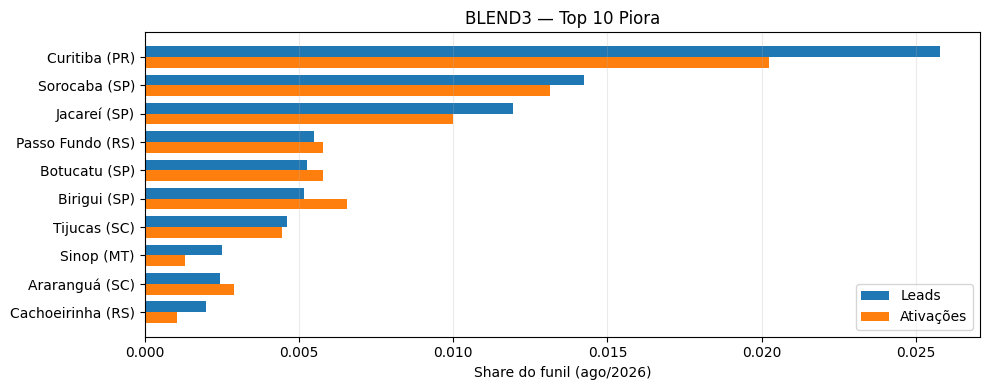

BLEND3 — blocos agregados


,n_cidades,n_leads,n_ativadas,share_leads,share_ativadas,tx_ativacao,idx_ativacao
bloco,,,,,,,
Top 10 Melhora,10,"2,728",568,15.1%,14.9%,20.8%,0.99
Top 10 Piora,10,"1,432",271,7.9%,7.1%,18.9%,0.90
Uniao Melhora e Piora,20,"4,160",839,23.1%,22.0%,20.2%,0.96
Demais cidades,631,"13,871","2,968",76.9%,78.0%,21.4%,1.01
TOTAL,651,"18,031","3,807",100.0%,100.0%,21.1%,1.00


BLEND4 — base ago/2026: leads=18,937 | ativações=3,709 | tx ativação=19.6%
BLEND4 — Top 10 Melhora: share de leads vs ativações


,,n_leads,n_ativadas,share_leads,share_ativadas,share_acum_leads,share_acum_ativadas,tx_ativacao,idx_ativacao,n_melhora,n_piora
imovel_cidade,imovel_uf,,,,,,,,,,
Londrina,PR,631,124,3.3%,3.3%,3.3%,3.3%,19.7%,1.00,56,2
São Paulo,SP,704,124,3.7%,3.3%,7.0%,6.7%,17.6%,0.90,42,6
Novo Hamburgo,RS,121,19,0.6%,0.5%,7.7%,7.2%,15.7%,0.80,42,0
Balneário Camboriú,SC,187,23,1.0%,0.6%,8.7%,7.8%,12.3%,0.63,39,0
Brusque,SC,142,24,0.7%,0.6%,9.4%,8.5%,16.9%,0.86,32,0
Jaú,SP,126,32,0.7%,0.9%,10.1%,9.3%,25.4%,1.30,31,0
Goiânia,GO,209,34,1.1%,0.9%,11.2%,10.2%,16.3%,0.83,30,1
Santo André,SP,200,37,1.1%,1.0%,12.3%,11.2%,18.5%,0.94,28,0
Limeira,SP,228,55,1.2%,1.5%,13.5%,12.7%,24.1%,1.23,26,1


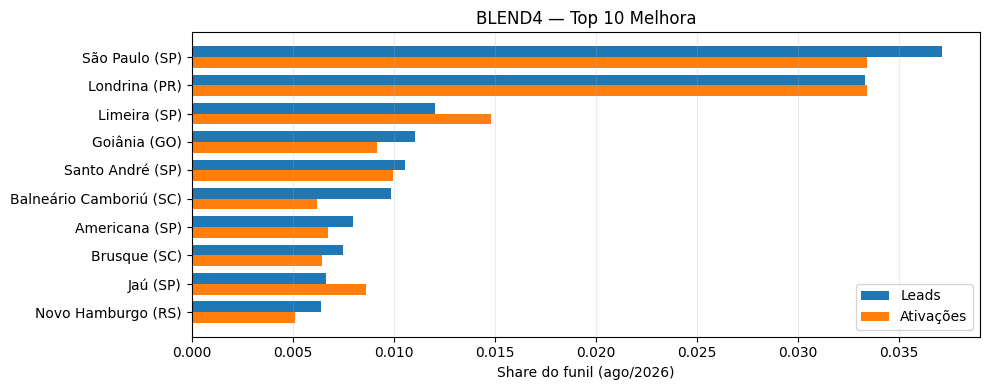

BLEND4 — Top 10 Piora: share de leads vs ativações


,,n_leads,n_ativadas,share_leads,share_ativadas,share_acum_leads,share_acum_ativadas,tx_ativacao,idx_ativacao,n_melhora,n_piora
imovel_cidade,imovel_uf,,,,,,,,,,
Passo Fundo,RS,113,11,0.6%,0.3%,0.6%,0.3%,9.7%,0.50,0,49
Sorocaba,SP,287,39,1.5%,1.1%,2.1%,1.3%,13.6%,0.69,0,43
Botucatu,SP,115,33,0.6%,0.9%,2.7%,2.2%,28.7%,1.47,0,26
Birigui,SP,103,18,0.5%,0.5%,3.3%,2.7%,17.5%,0.89,0,23
Erechim,RS,37,13,0.2%,0.4%,3.5%,3.1%,35.1%,1.79,0,18
Fortaleza,CE,122,43,0.6%,1.2%,4.1%,4.2%,35.2%,1.80,0,17
Jacareí,SP,234,39,1.2%,1.1%,5.3%,5.3%,16.7%,0.85,0,17
Curitiba,PR,447,61,2.4%,1.6%,7.7%,6.9%,13.6%,0.70,0,17
São José Dos Pinhais,PR,89,10,0.5%,0.3%,8.2%,7.2%,11.2%,0.57,0,17


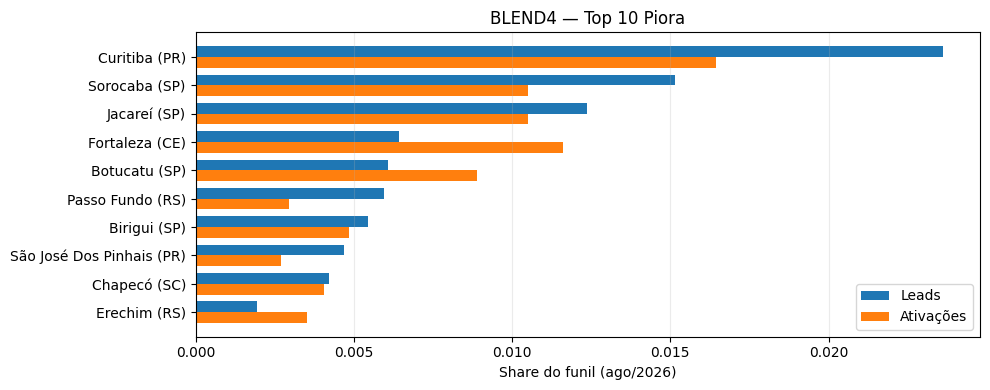

BLEND4 — blocos agregados


,n_cidades,n_leads,n_ativadas,share_leads,share_ativadas,tx_ativacao,idx_ativacao
bloco,,,,,,,
Top 10 Melhora,10,"2,699",497,14.3%,13.4%,18.4%,0.94
Top 10 Piora,10,"1,627",282,8.6%,7.6%,17.3%,0.88
Uniao Melhora e Piora,20,"4,326",779,22.8%,21.0%,18.0%,0.92
Demais cidades,646,"14,611","2,930",77.2%,79.0%,20.1%,1.02
TOTAL,666,"18,937","3,709",100.0%,100.0%,19.6%,1.00


In [68]:
SHARE_FMT = {
    "n_leads": "{:,.0f}",
    "n_ativadas": "{:,.0f}",
    "share_leads": "{:.1%}",
    "share_ativadas": "{:.1%}",
    "share_acum_leads": "{:.1%}",
    "share_acum_ativadas": "{:.1%}",
    "tx_ativacao": "{:.1%}",
    "idx_ativacao": "{:.2f}",
    "n_melhora": "{:,.0f}",
    "n_piora": "{:,.0f}",
}


def _ativ_flag(df: pd.DataFrame) -> pd.Series:
    if "proposta_ativada" not in df.columns:
        return pd.Series(0, index=df.index, dtype=int)
    s = df["proposta_ativada"]
    if s.dtype == bool:
        return s.astype(int)
    return pd.to_numeric(s, errors="coerce").fillna(0).astype(int)


def city_share_funil(df_leads: pd.DataFrame, city_ids) -> pd.DataFrame:
    """Rebuild lead/activation shares for a city list from the August lead frame."""
    ids = pd.to_numeric(pd.Series(city_ids), errors="coerce").dropna().astype("int64")
    order = pd.Index(ids.unique())
    tot_leads = len(df_leads)
    tot_ativ = int(_ativ_flag(df_leads).sum())
    aux = df_leads.copy()
    aux["_ativ"] = _ativ_flag(aux)
    aux[CITY_COL] = pd.to_numeric(aux[CITY_COL], errors="coerce").astype("Int64")
    sub = aux.loc[aux[CITY_COL].isin(order)]
    grouped = (
        sub.groupby(CITY_COL, dropna=False)
        .agg(
            imovel_cidade=("imovel_cidade", "first"),
            imovel_uf=("imovel_uf", "first"),
            n_leads=("movimento", "size"),
            n_ativadas=("_ativ", "sum"),
            n_melhora=("movimento", lambda s: (s == "Melhora").sum()),
            n_piora=("movimento", lambda s: (s == "Piora").sum()),
        )
        .reset_index()
    )
    grouped["share_leads"] = grouped["n_leads"] / tot_leads if tot_leads else np.nan
    grouped["share_ativadas"] = grouped["n_ativadas"] / tot_ativ if tot_ativ else np.nan
    grouped["tx_ativacao"] = grouped["n_ativadas"] / grouped["n_leads"].replace(0, np.nan)
    grouped["idx_ativacao"] = grouped["share_ativadas"] / grouped["share_leads"].replace(0, np.nan)
    grouped[CITY_COL] = pd.to_numeric(grouped[CITY_COL], errors="coerce").astype("Int64")
    grouped = grouped.set_index(CITY_COL).reindex(order).reset_index()
    if grouped.columns[0] != CITY_COL:
        grouped = grouped.rename(columns={grouped.columns[0]: CITY_COL})
    grouped["share_acum_leads"] = grouped["share_leads"].cumsum()
    grouped["share_acum_ativadas"] = grouped["share_ativadas"].cumsum()
    return grouped


def show_share_table(share: pd.DataFrame, titulo: str) -> None:
    cols = [c for c in SHARE_FMT if c in share.columns]
    print(titulo)
    display(
        share.set_index(["imovel_cidade", "imovel_uf"], drop=False)[cols]
        .style.format(SHARE_FMT, na_rep="—")
    )


def bloco_share(df_leads: pd.DataFrame, city_ids, rotulo: str) -> dict:
    ids = pd.to_numeric(pd.Series(list(city_ids)), errors="coerce").dropna()
    mask = pd.to_numeric(df_leads[CITY_COL], errors="coerce").isin(ids)
    n_leads = int(mask.sum())
    n_ativ = int(_ativ_flag(df_leads).loc[mask].sum())
    tot_leads = len(df_leads)
    tot_ativ = int(_ativ_flag(df_leads).sum())
    share_l = n_leads / tot_leads if tot_leads else np.nan
    share_a = n_ativ / tot_ativ if tot_ativ else np.nan
    return {
        "bloco": rotulo,
        "n_cidades": int(ids.nunique()),
        "n_leads": n_leads,
        "n_ativadas": n_ativ,
        "share_leads": share_l,
        "share_ativadas": share_a,
        "tx_ativacao": (n_ativ / n_leads) if n_leads else np.nan,
        "idx_ativacao": (share_a / share_l) if share_l else np.nan,
    }


def plot_share_leads_ativadas(share: pd.DataFrame, titulo: str) -> None:
    plot = share.dropna(subset=["share_leads"]).sort_values("share_leads")
    if plot.empty:
        print(f"{titulo} — sem dados de share")
        return
    labels = (
        plot["imovel_cidade"].fillna(plot[CITY_COL].astype(str)).astype(str)
        + " (" + plot["imovel_uf"].fillna("sem UF").astype(str) + ")"
    )
    y = np.arange(len(plot))
    h = 0.38
    fig, ax = plt.subplots(figsize=(10, max(4, 0.38 * len(plot))))
    ax.barh(y + h / 2, plot["share_leads"], height=h, label="Leads", color="#1f77b4")
    ax.barh(y - h / 2, plot["share_ativadas"].fillna(0), height=h, label="Ativações", color="#ff7f0e")
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Share do funil (ago/2026)")
    ax.set_title(titulo)
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


def avaliar_share_funil(df_leads: pd.DataFrame, top_up: pd.DataFrame, top_down: pd.DataFrame) -> None:
    modelo = (top_up.attrs or {}).get("modelo") or df_leads.get("modelo", pd.Series(["?"])).iloc[0]
    tot_leads = len(df_leads)
    tot_ativ = int(_ativ_flag(df_leads).sum())
    tx_base = tot_ativ / tot_leads if tot_leads else np.nan
    print(
        f"{modelo} — base ago/2026: leads={tot_leads:,.0f} | "
        f"ativações={tot_ativ:,.0f} | tx ativação={tx_base:.1%}"
    )

    share_up = city_share_funil(df_leads, top_up[CITY_COL])
    share_down = city_share_funil(df_leads, top_down[CITY_COL])

    show_share_table(share_up, f"{modelo} — Top 10 Melhora: share de leads vs ativações")
    plot_share_leads_ativadas(share_up, f"{modelo} — Top 10 Melhora")

    show_share_table(share_down, f"{modelo} — Top 10 Piora: share de leads vs ativações")
    plot_share_leads_ativadas(share_down, f"{modelo} — Top 10 Piora")

    ids_up = pd.to_numeric(top_up[CITY_COL], errors="coerce").dropna()
    ids_down = pd.to_numeric(top_down[CITY_COL], errors="coerce").dropna()
    ids_union = pd.Index(ids_up.astype("int64")).union(pd.Index(ids_down.astype("int64")))
    all_ids = pd.to_numeric(df_leads[CITY_COL], errors="coerce").dropna().astype("int64")
    ids_rest = pd.Index(all_ids.unique()).difference(ids_union)

    blocos = pd.DataFrame([
        bloco_share(df_leads, ids_up, "Top 10 Melhora"),
        bloco_share(df_leads, ids_down, "Top 10 Piora"),
        bloco_share(df_leads, ids_union, "Uniao Melhora e Piora"),
        bloco_share(df_leads, ids_rest, "Demais cidades"),
        {
            "bloco": "TOTAL",
            "n_cidades": int(pd.to_numeric(df_leads[CITY_COL], errors="coerce").nunique()),
            "n_leads": tot_leads,
            "n_ativadas": tot_ativ,
            "share_leads": 1.0,
            "share_ativadas": 1.0,
            "tx_ativacao": tx_base,
            "idx_ativacao": 1.0,
        },
    ])
    print(f"{modelo} — blocos agregados")
    display(
        blocos.set_index("bloco").style.format({
            "n_cidades": "{:.0f}",
            "n_leads": "{:,.0f}",
            "n_ativadas": "{:,.0f}",
            "share_leads": "{:.1%}",
            "share_ativadas": "{:.1%}",
            "tx_ativacao": "{:.1%}",
            "idx_ativacao": "{:.2f}",
        }, na_rep="—")
    )


avaliar_share_funil(mv3_ago, top_melhora_b3, top_piora_b3)
avaliar_share_funil(mv4_ago, top_melhora_b4, top_piora_b4)


## Gráfico P50 ao longo das semanas

In [24]:
rename_dict = {
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts": "agency_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_cityPc4HistoryOver100Contracts": "city_pc4_mais_100_contratos__pc_categorias",
}

In [14]:
rename_dict_blend4 = {
    "message_scores_BVS_CUSTOM_V2": "score_proposto__bvs",#
    "message_scores_HFT1": "SERASA_CHSV5",
    "pessoa_idade": "age",
    "request_imovelTipo": "property_type",
    "message_qtdeRestricoesContrato": "qtde_restricoes__consulta_realizada",
    "request_valorAluguel": "rental_value",
    "message_rendaConsideradaContrato": "income",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts": "agency_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_cityPc4HistoryOver100Contracts": "city_pc4_mais_100_contratos__pc_categorias",
    # "agency_pc4_mais_100_contratos__pc_categorias_maio2026": "agency_pc4_mais_100_contratos__pc_categorias",
    # "city_pc4_mais_100_contratos__pc_categorias_maio2026": "city_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_hasPreviousContracts": "flag_tem__contratos_anteriores",
    "message_blend3Variables_hadOverdueInvoiceInPreviousContracts": "flag_teve_boleto_atrasado__contratos_anteriores",
}

In [15]:
rename_dict_blend3 = {
    "message_scores_BVS_CUSTOM": "SCRCRDPNMGRLPFLGBCLFCREDPGV1",#
    "message_scores_HVA4": "SERASA_HVA4",
    "pessoa_idade": "age",
    "request_imovelTipo": "property_type",
    "message_qtdeRestricoesContrato": "qtde_restricoes__consulta_realizada",
    "request_valorAluguel": "rental_value",
    "message_rendaConsideradaContrato": "income",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts": "agency_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_cityPc4HistoryOver100Contracts": "city_pc4_mais_100_contratos__pc_categorias",
    # "agency_pc4_mais_100_contratos__pc_categorias_maio2026": "agency_pc4_mais_100_contratos__pc_categorias",
    # "city_pc4_mais_100_contratos__pc_categorias_maio2026": "city_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_hasPreviousContracts": "flag_tem__contratos_anteriores",
    "message_blend3Variables_hadOverdueInvoiceInPreviousContracts": "flag_teve_boleto_atrasado__contratos_anteriores",
}

In [16]:
vars_blend4 = ['score_proposto__bvs', 'SERASA_CHSV5', 'age', 'property_type', 'qtde_restricoes__consulta_realizada', 'rental_value', 'income', 'agency_pc4_mais_100_contratos__pc_categorias', 'city_pc4_mais_100_contratos__pc_categorias', 'flag_tem__contratos_anteriores', 'flag_teve_boleto_atrasado__contratos_anteriores']
vars_blend3 = ['SCRCRDPNMGRLPFLGBCLFCREDPGV1', 'SERASA_HVA4', 'age', 'property_type', 'qtde_restricoes__consulta_realizada', 'rental_value', 'income', 'agency_pc4_mais_100_contratos__pc_categorias', 'city_pc4_mais_100_contratos__pc_categorias', 'flag_tem__contratos_anteriores', 'flag_teve_boleto_atrasado__contratos_anteriores']

id_vars = ['contract_id', 'requested_at', 'message_decisao', 'message_blendRegressaoPredict']

In [17]:
df_funil_blend3 =df_funil[df_funil["bureau_nm_ajust"] == "BLEND3"]#[id_vars + vars_blend3]
df_funil_blend4 =df_funil[df_funil["bureau_nm_ajust"] == "BLEND4"]#[id_vars + vars_blend4]

In [25]:
df_funil_total = (df_funil.copy()).rename(columns=rename_dict)

In [18]:
df_predict_blend4 = (df_funil_blend4.copy()).rename(columns=rename_dict_blend4)
df_predict_blend4["REGRA_BLEND_4"] = np.where(
    df_predict_blend4["score_proposto__bvs"] <= 334,
    "E_BVS",
    "BLEND4",
)

df_predict_blend4["SCORE_BVS"] = df_predict_blend4["score_proposto__bvs"]
df_predict_blend4["SCORE_SERASA"] = df_predict_blend4["SERASA_CHSV5"]
df_predict_blend4["RENDA"] = df_predict_blend4["income"]

In [19]:
df_predict_blend3 = (df_funil_blend3).rename(columns=rename_dict_blend3)
df_predict_blend3["REGRA_BLEND_3"] = np.where(
    df_predict_blend3["SCRCRDPNMGRLPFLGBCLFCREDPGV1"] <= 435,
    "E_BVS",
    "BLEND3",
)

df_predict_blend3["SCORE_BVS"] = df_predict_blend3["SCRCRDPNMGRLPFLGBCLFCREDPGV1"]
df_predict_blend3["SCORE_SERASA"] = df_predict_blend3["SERASA_HVA4"]
df_predict_blend3["RENDA"] = df_predict_blend3["income"]

In [21]:
from funcoes_monitoramento import prepare_week_columns

DATE_START = "2026-07-01"
DATE_END = "2026-08-16"          # exclusive — metade de agosto
RAMP_WEEK = "2026-08-02"         # first Sunday of August (ramp ~50%)


def prepare_weekly_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["requested_at"] = pd.to_datetime(out["requested_at"], errors="coerce")
    out = out.loc[
        out["requested_at"].between(DATE_START, DATE_END, inclusive="left")
    ].copy()
    out = prepare_week_columns(out, date_col="requested_at")
    out["month"] = out["requested_at"].dt.strftime("%Y-%m")
    return out


def period_p50(df: pd.DataFrame, period_col: str, variables: list, label: str) -> pd.DataFrame:
    rows = []
    for period, g in df.groupby(period_col, sort=True):
        for var in variables:
            if var not in g.columns:
                continue
            s = pd.to_numeric(g[var], errors="coerce")
            rows.append({
                "period": str(period),
                "variable": var,
                "base": label,
                "n": int(s.notna().sum()),
                "p50": s.quantile(0.50),
            })
    return pd.DataFrame(rows)


def plot_p50_by_week(df: pd.DataFrame, variables: list, model_label: str) -> None:
    week = prepare_weekly_window(df)
    df_jul = week[week["month"] == "2026-07"]
    df_ago = week[week["month"] == "2026-08"]

    cmp_month = pd.concat([
        period_p50(df_jul.assign(period="2026-07"), "period", variables, "Jul"),
        period_p50(df_ago.assign(period="2026-08"), "period", variables, "Ago"),
    ], ignore_index=True)
    cmp_week = period_p50(week, "year_week", variables, "prod")

    week_vol = week.groupby("year_week").size()
    week_order = (
        week[["year_week", "week_start"]]
        .drop_duplicates()
        .sort_values("week_start")["year_week"]
        .astype(str)
        .tolist()
    )
    bar_colors = ["#94A3B8" if w < RAMP_WEEK else "#2563EB" for w in week_order]
    ramp_idx = week_order.index(RAMP_WEEK) - 0.5 if RAMP_WEEK in week_order else None

    print(f"{model_label}: n Jul={len(df_jul):,} | n Ago={len(df_ago):,} | weeks={week_order}")

    for var in variables:
        if var not in week.columns:
            print(f"[skip] {var} not in {model_label}")
            continue

        g = cmp_week[cmp_week["variable"] == var].copy()
        g = g.set_index("period").reindex(week_order).reset_index()
        n_bars = [int(week_vol.get(w, 0)) for w in week_order]

        jul_row = cmp_month[(cmp_month["variable"] == var) & (cmp_month["base"] == "Jul")]
        ago_row = cmp_month[(cmp_month["variable"] == var) & (cmp_month["base"] == "Ago")]
        jul_p50 = float(jul_row["p50"].iloc[0]) if len(jul_row) else np.nan
        ago_p50 = float(ago_row["p50"].iloc[0]) if len(ago_row) else np.nan

        fig, axes = plt.subplots(
            2, 1, figsize=(13, 6.0), sharex=True,
            gridspec_kw={"height_ratios": [0.72, 0.28]},
        )
        ax, ax_vol = axes

        ax.plot(week_order, g["p50"], color="#2563EB", marker="o", linewidth=2.2, label="p50")
        if pd.notna(jul_p50):
            ax.axhline(jul_p50, color="#94A3B8", linestyle="--", linewidth=1.2,
                       label=f"Jul p50={jul_p50:.3g}")
        if pd.notna(ago_p50):
            ax.axhline(ago_p50, color="#F59E0B", linestyle=":", linewidth=1.4,
                       label=f"Ago p50={ago_p50:.3g}")
        if ramp_idx is not None:
            ax.axvline(ramp_idx, color="#DC2626", linestyle="--", linewidth=1.5,
                       label="Ramp 50% (01/Ago)")

        ax.set_title(f"{var} — p50 por semana (produção {model_label})")
        ax.set_ylabel(var)
        ax.legend(loc="best", fontsize=8, ncol=2)
        ax.grid(axis="y", alpha=0.25)

        ax_vol.bar(week_order, n_bars, color=bar_colors)
        ax_vol.set_ylabel("n")
        ax_vol.set_xlabel("Semana (início domingo)")
        ax_vol.tick_params(axis="x", rotation=45)
        ax_vol.grid(axis="y", alpha=0.25)

        plt.tight_layout()
        plt.show()

In [28]:
pc_vars = ["agency_pc4_mais_100_contratos__pc_categorias", "city_pc4_mais_100_contratos__pc_categorias"]

Total: n Jul=123,709 | n Ago=61,443 | weeks=['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19', '2026-07-26', '2026-08-02', '2026-08-09']


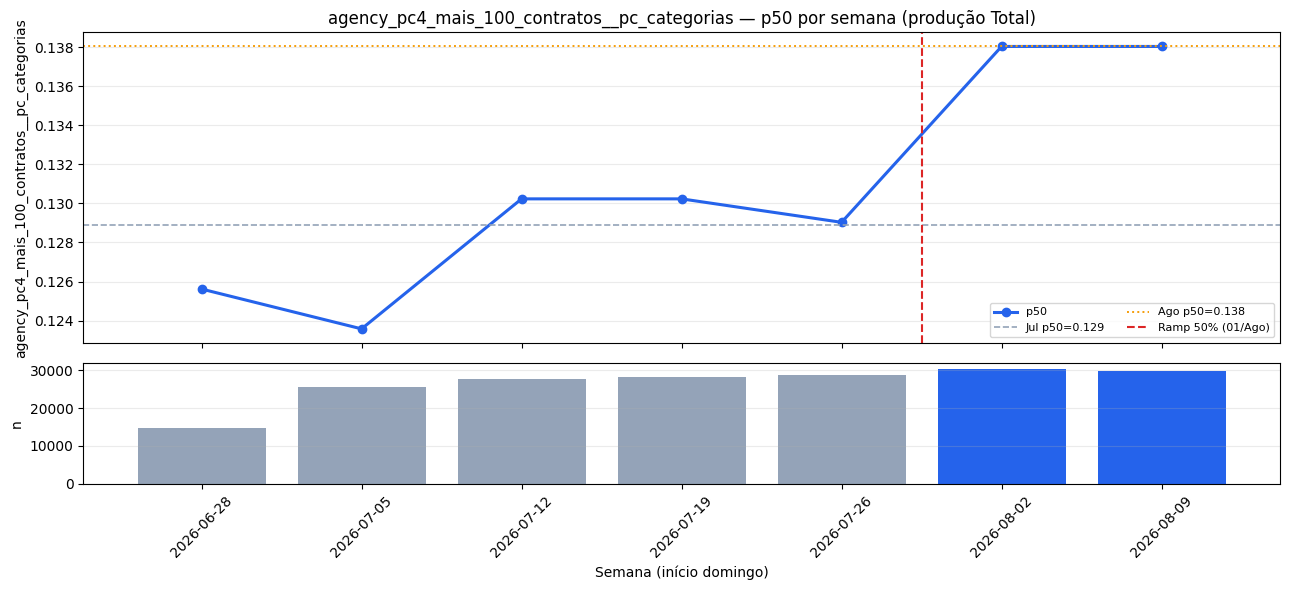

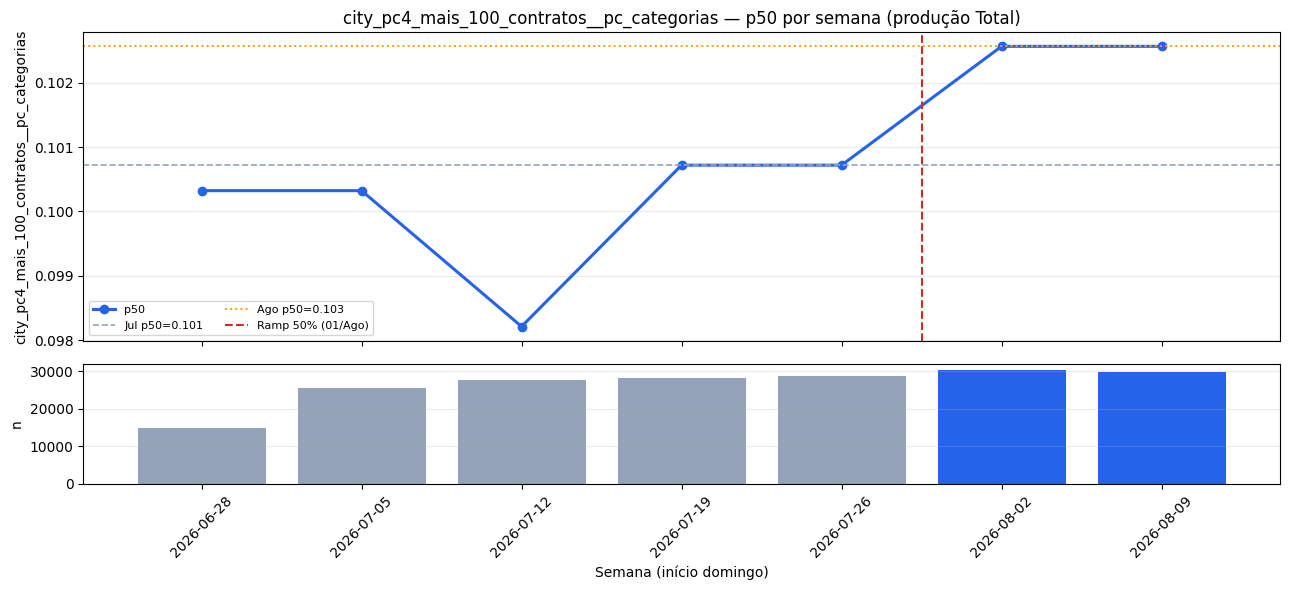

In [29]:
plot_p50_by_week(df_funil_total, pc_vars, "Total")

Blend4: n Jul=16,779 | n Ago=30,354 | weeks=['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19', '2026-07-26', '2026-08-02', '2026-08-09']


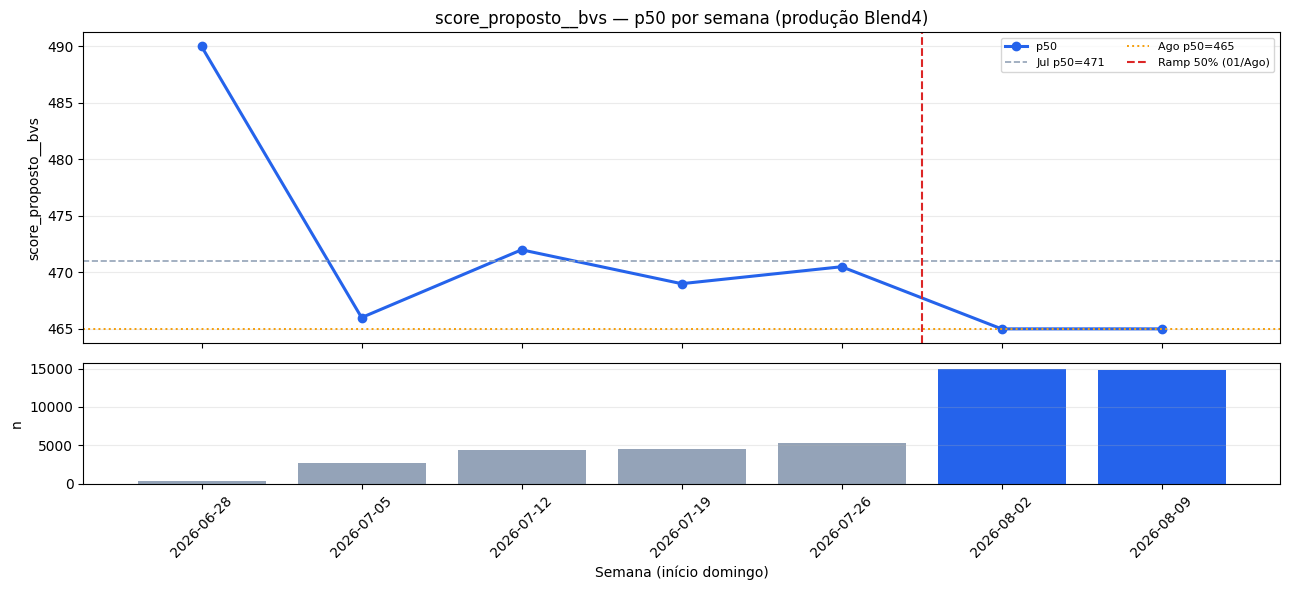

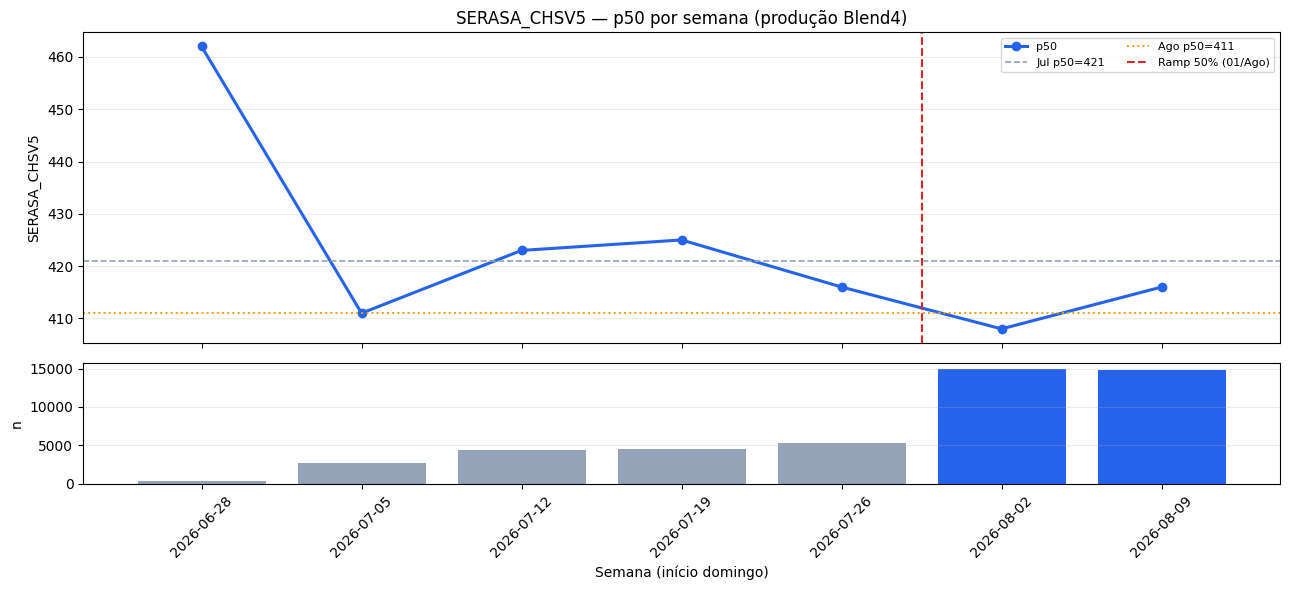

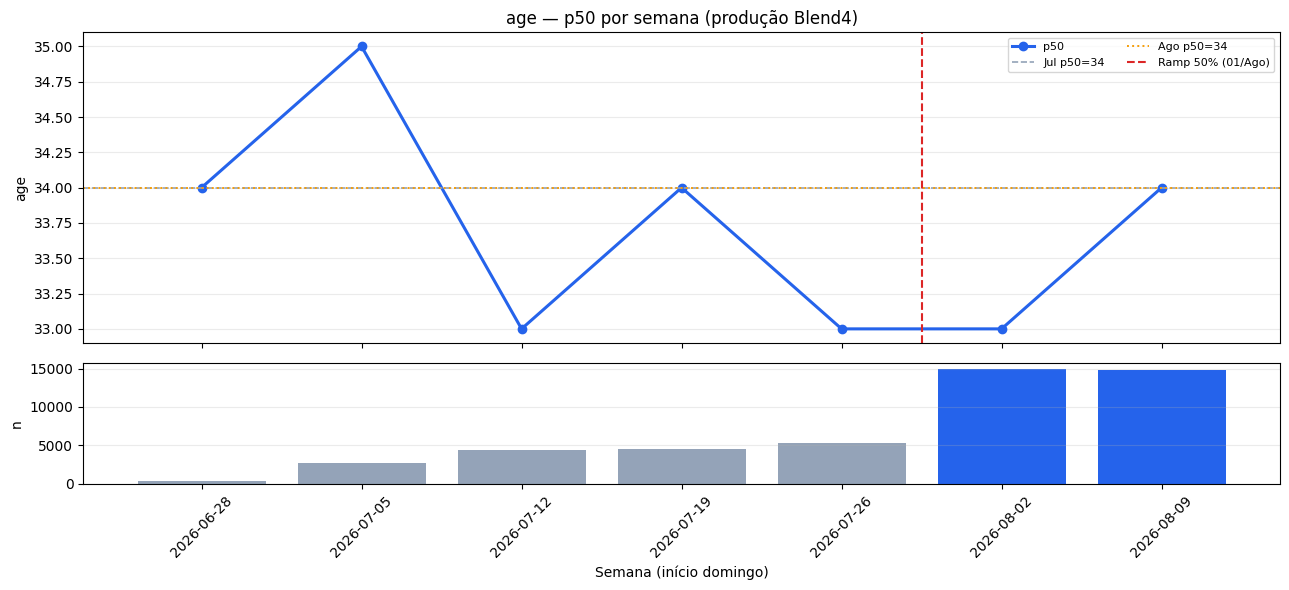

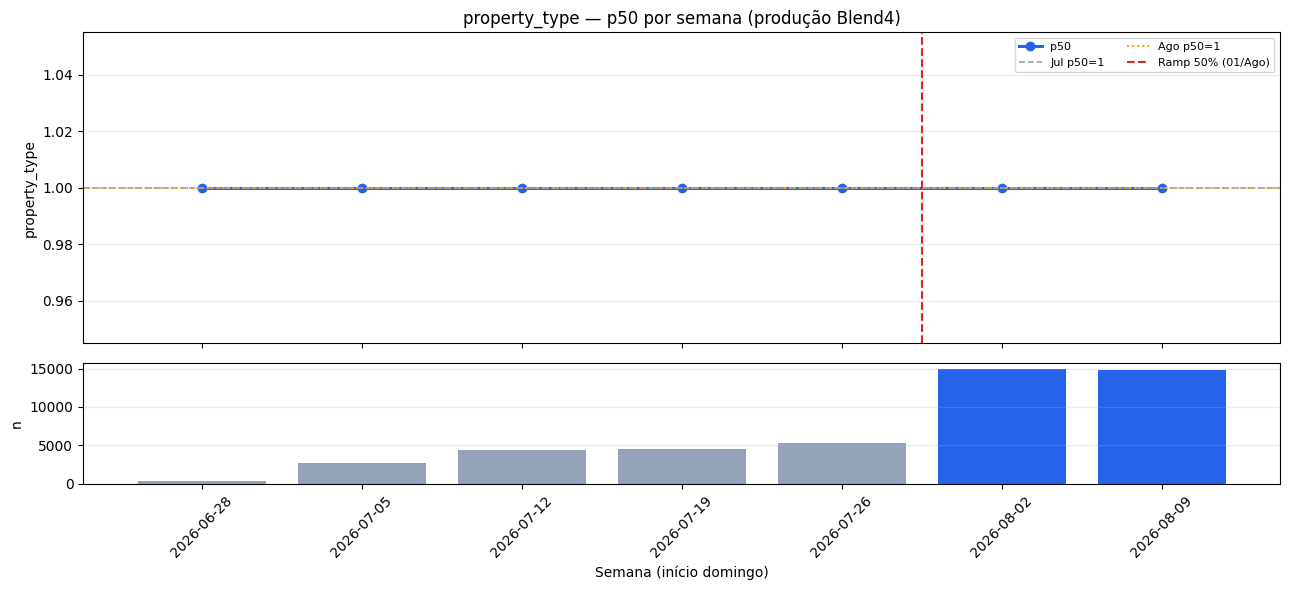

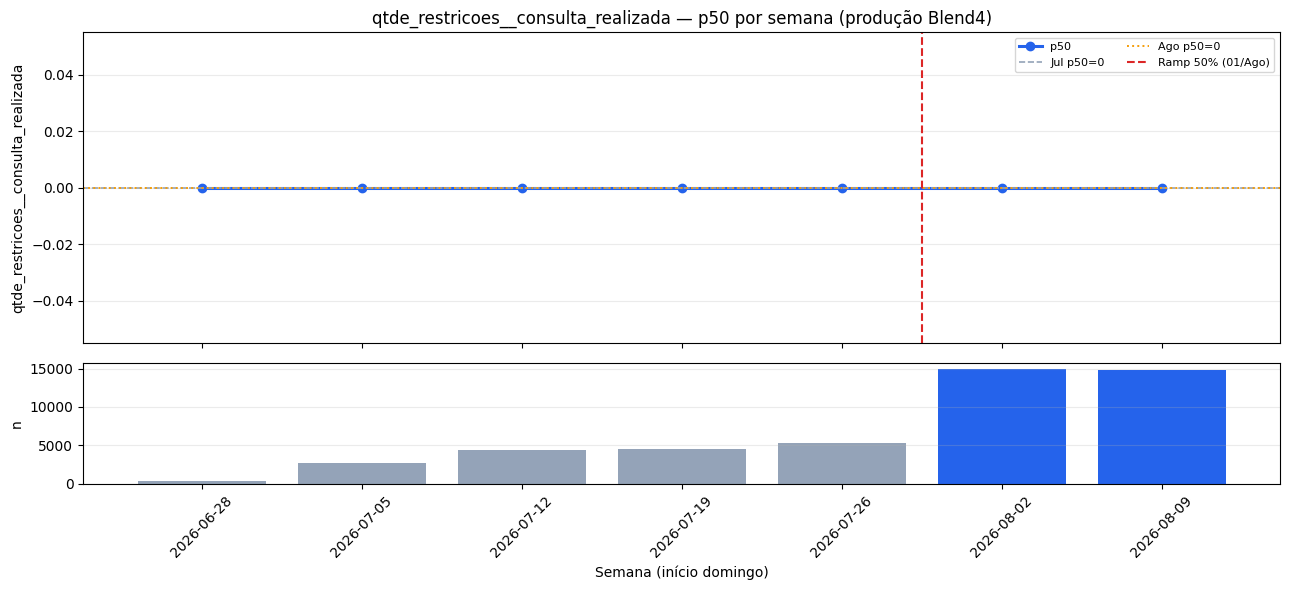

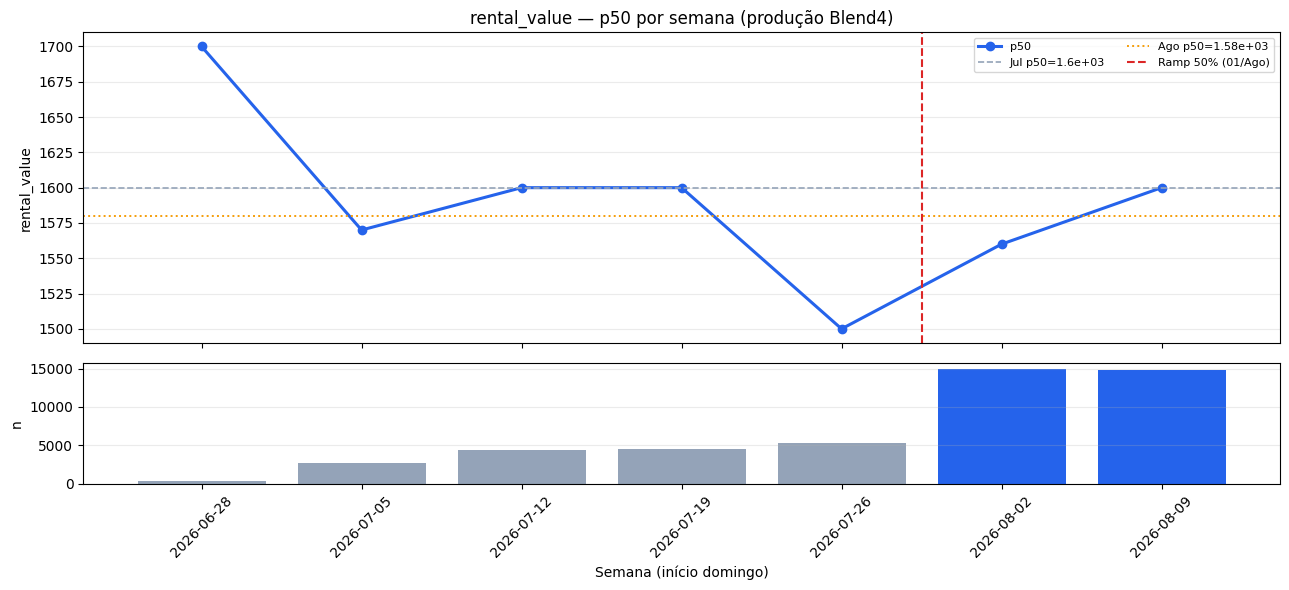

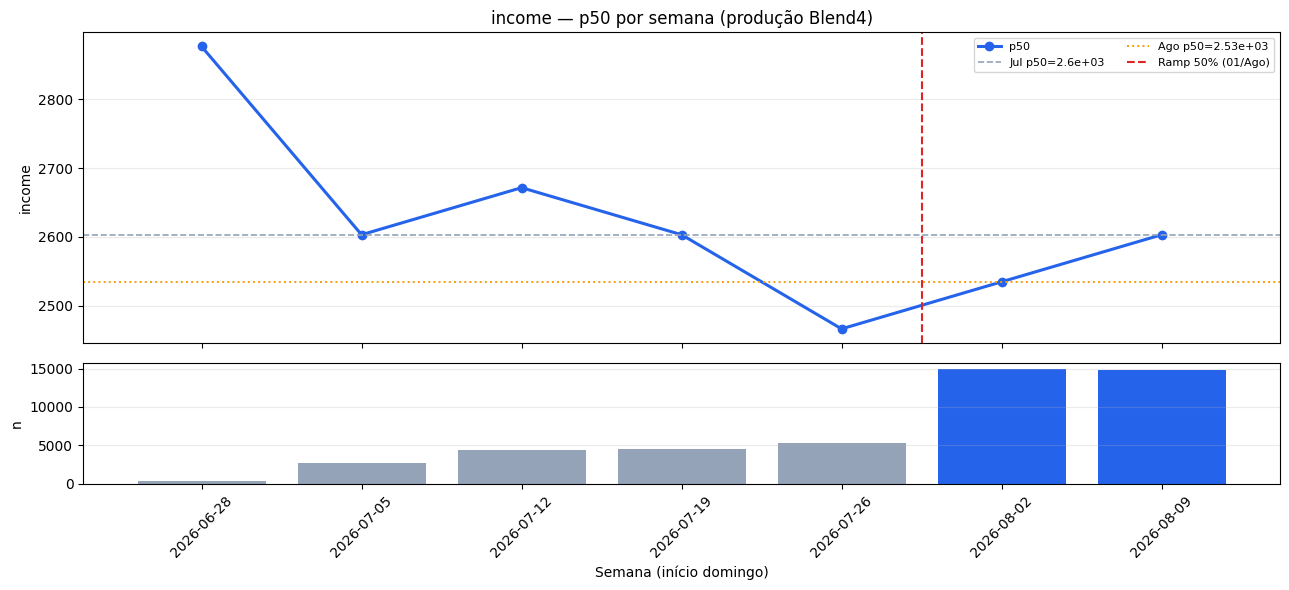

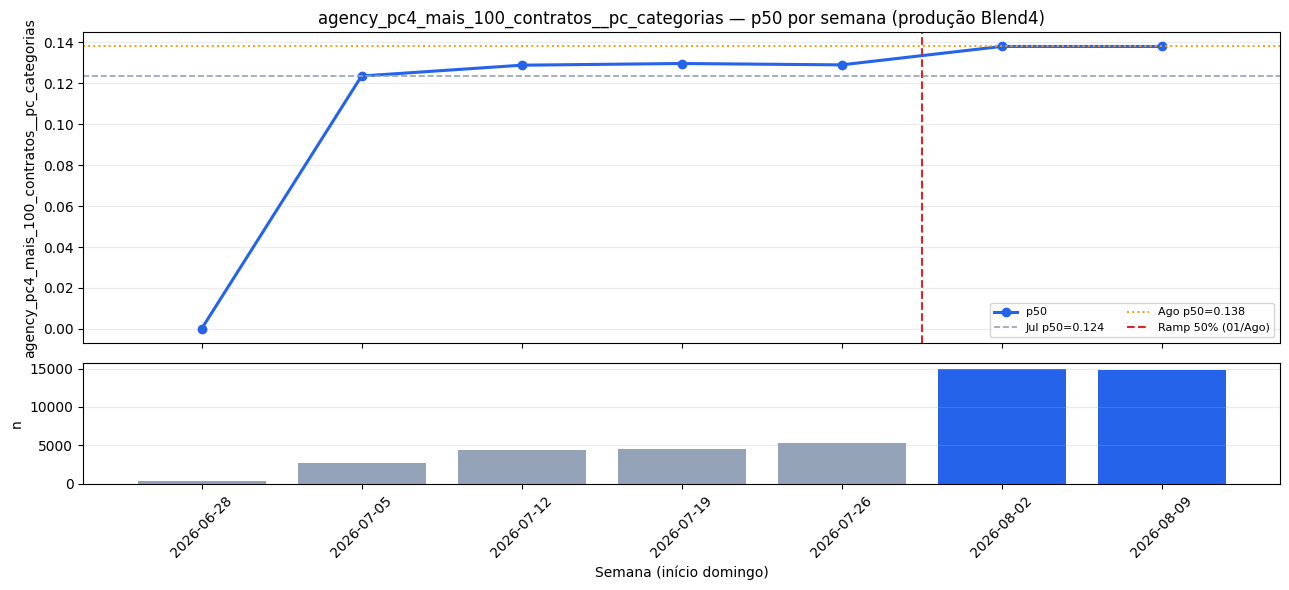

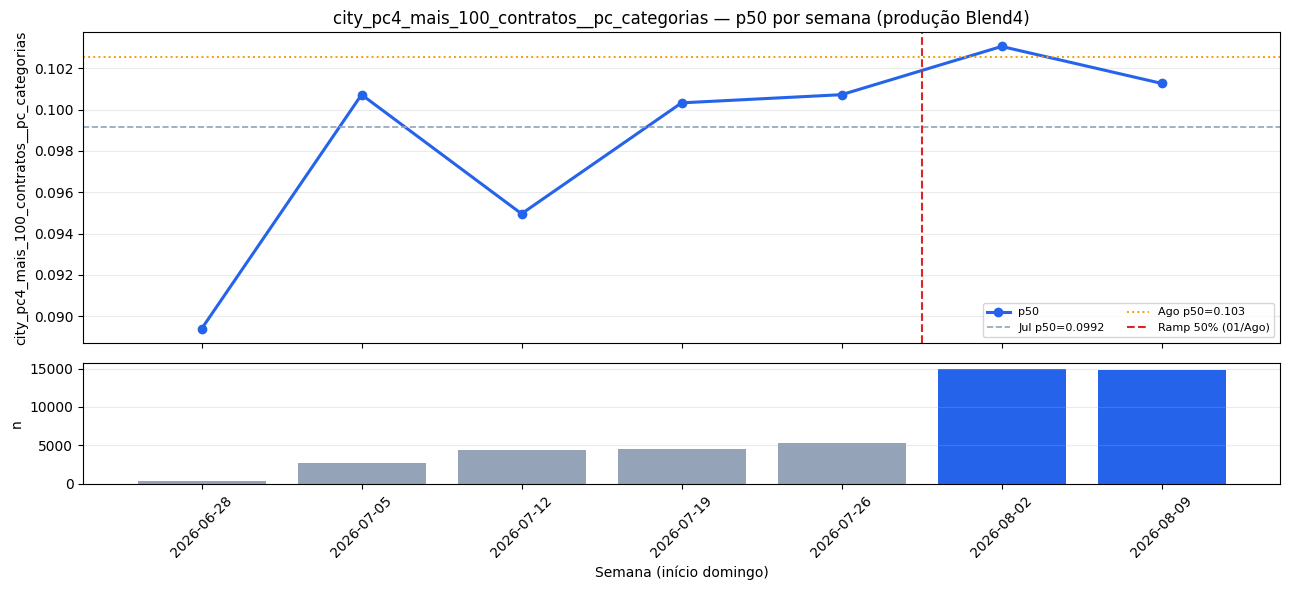

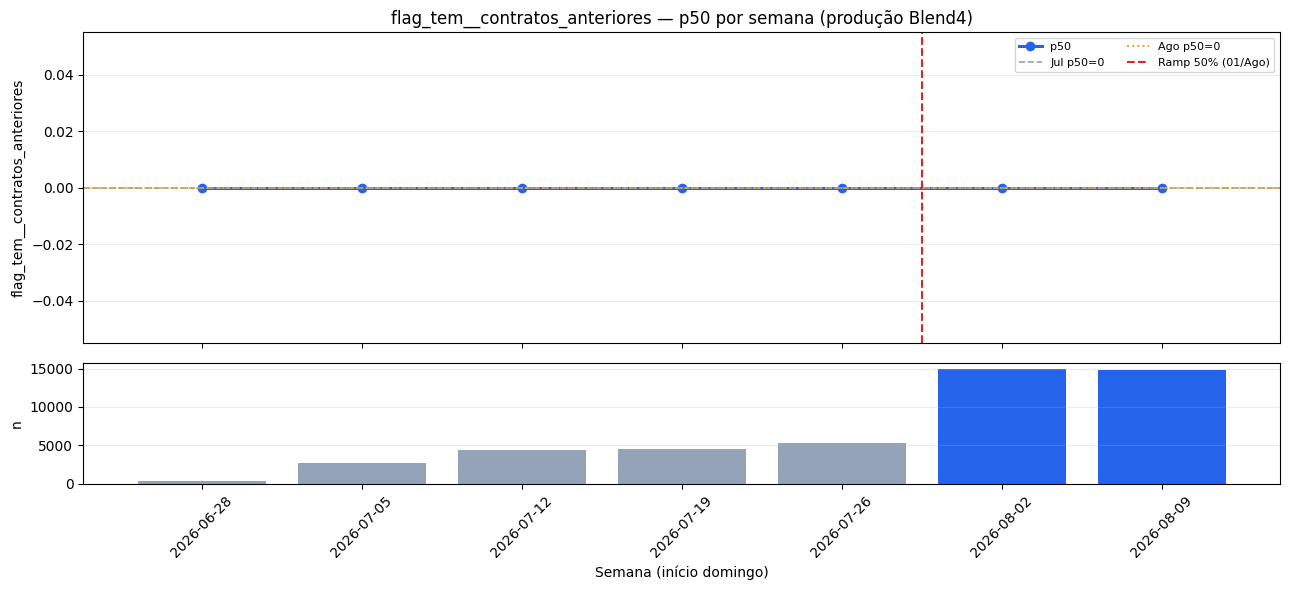

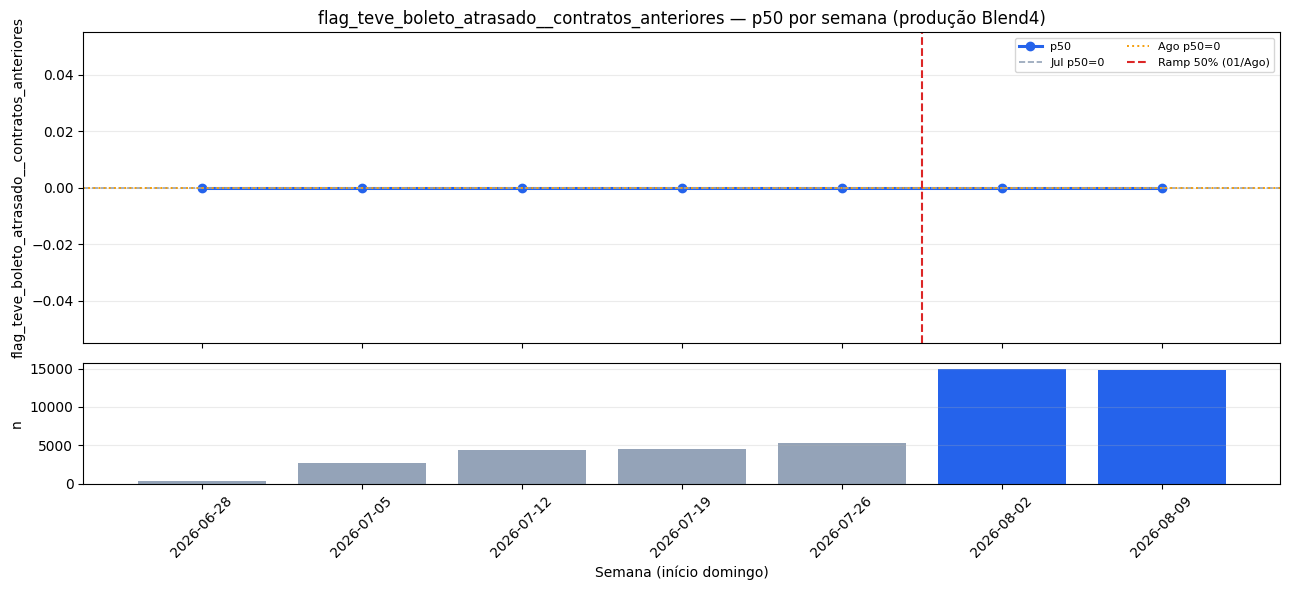

In [22]:
plot_p50_by_week(df_predict_blend4, vars_blend4, "Blend4")

Blend3: n Jul=106,930 | n Ago=31,089 | weeks=['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19', '2026-07-26', '2026-08-02', '2026-08-09']


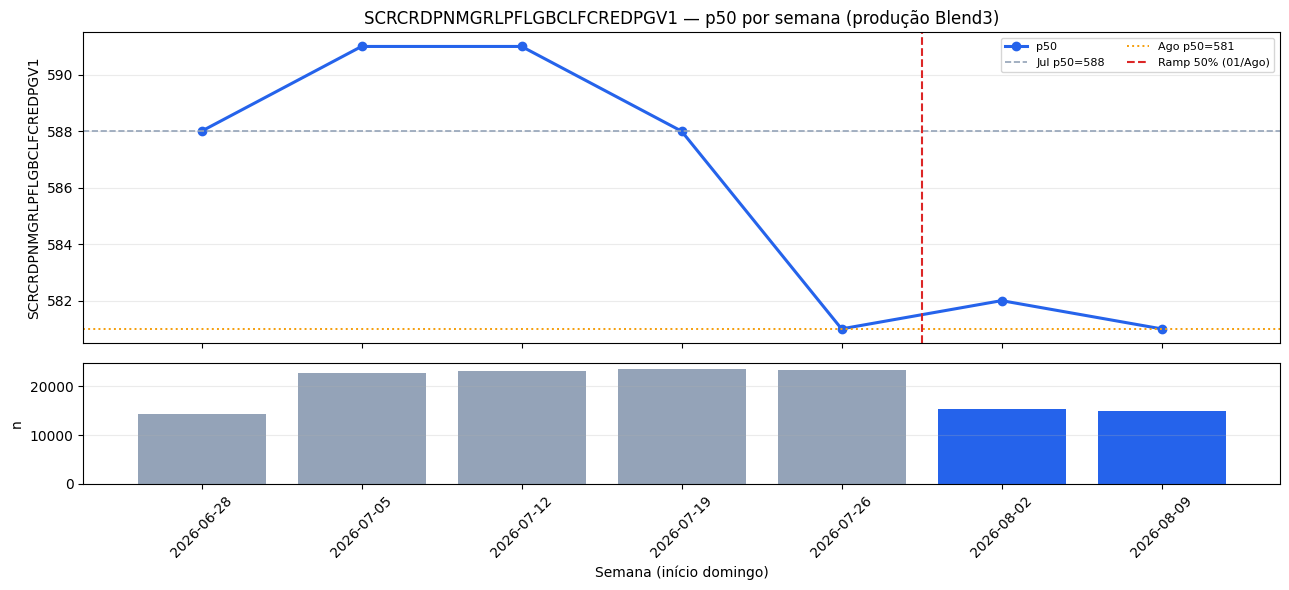

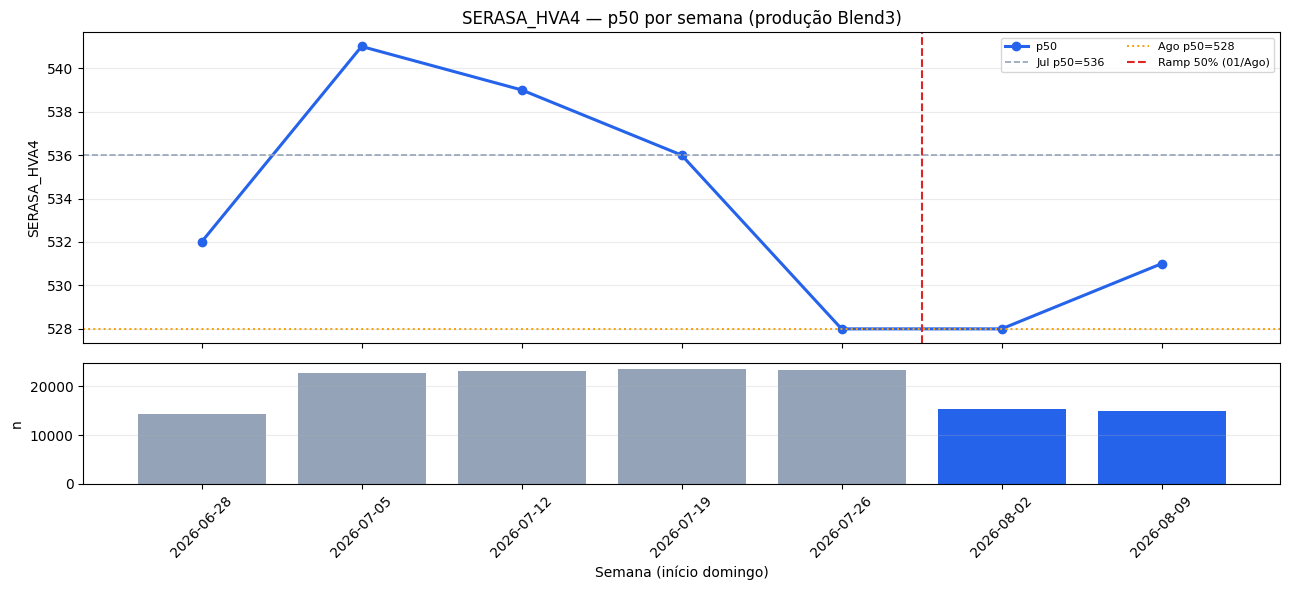

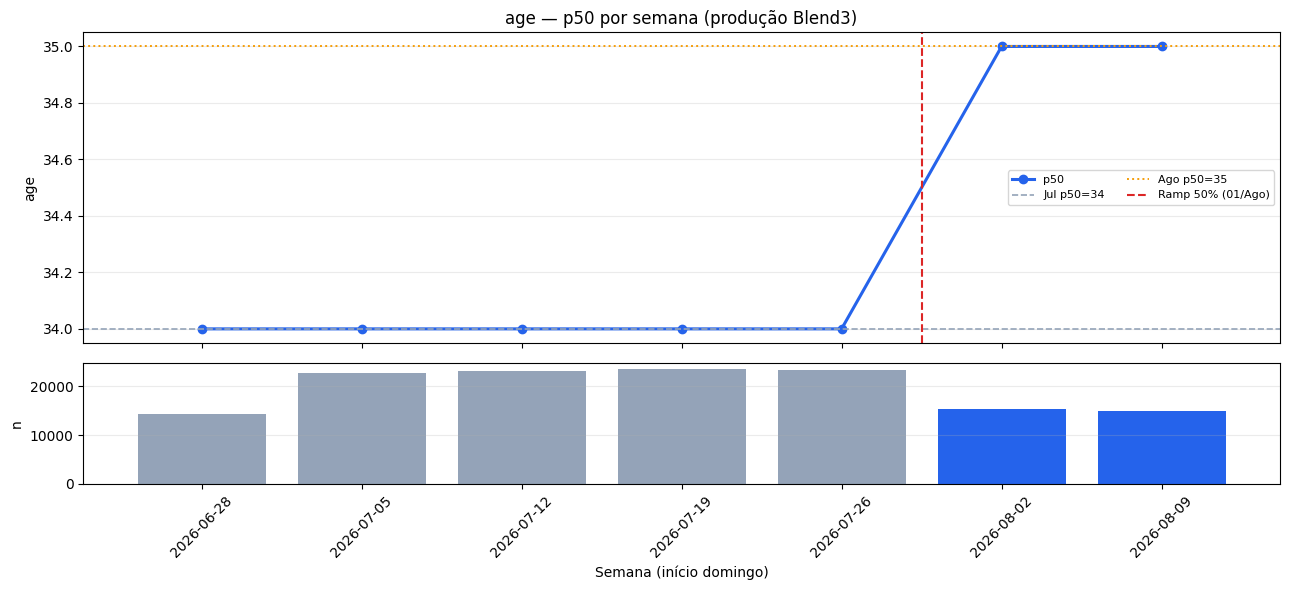

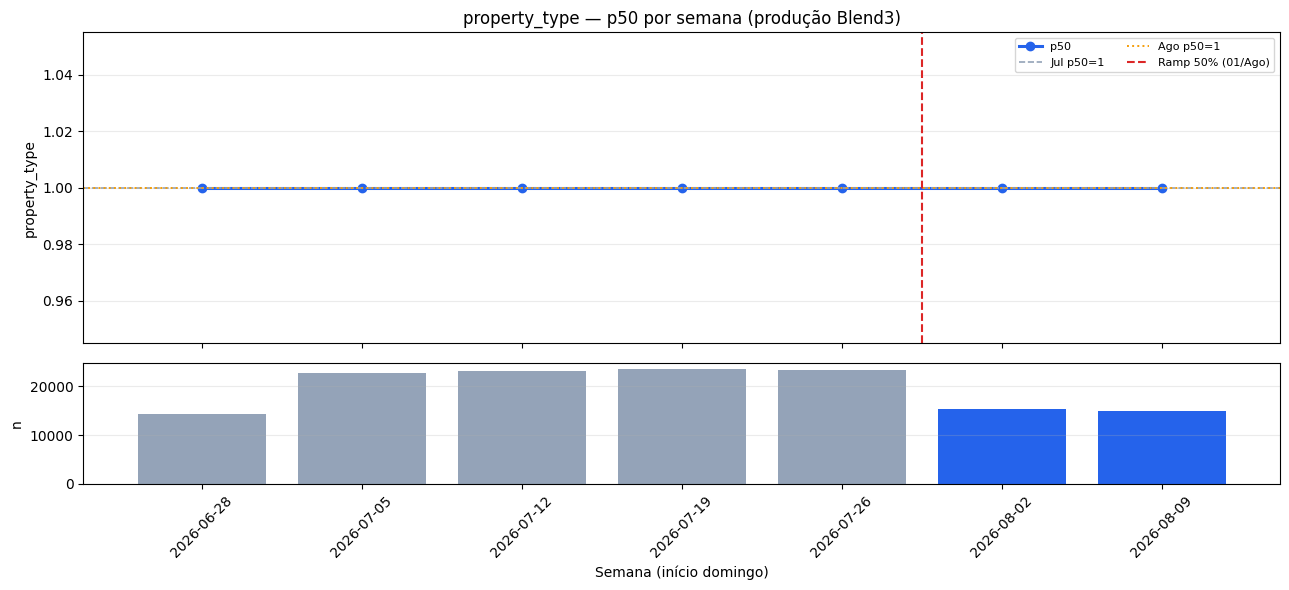

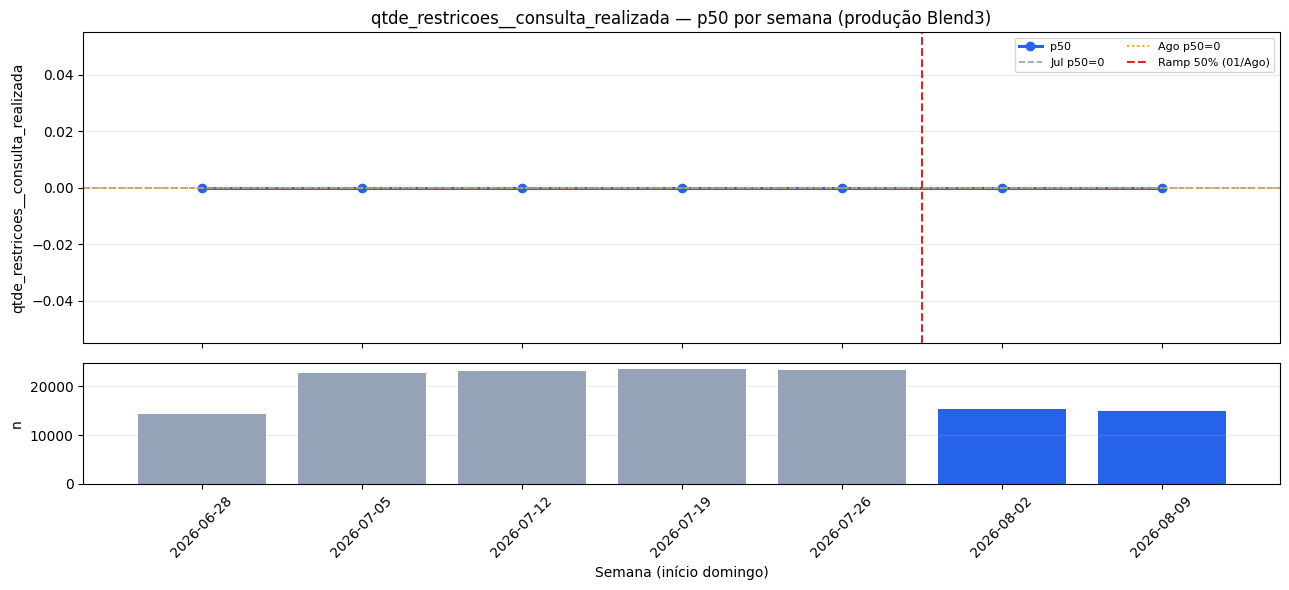

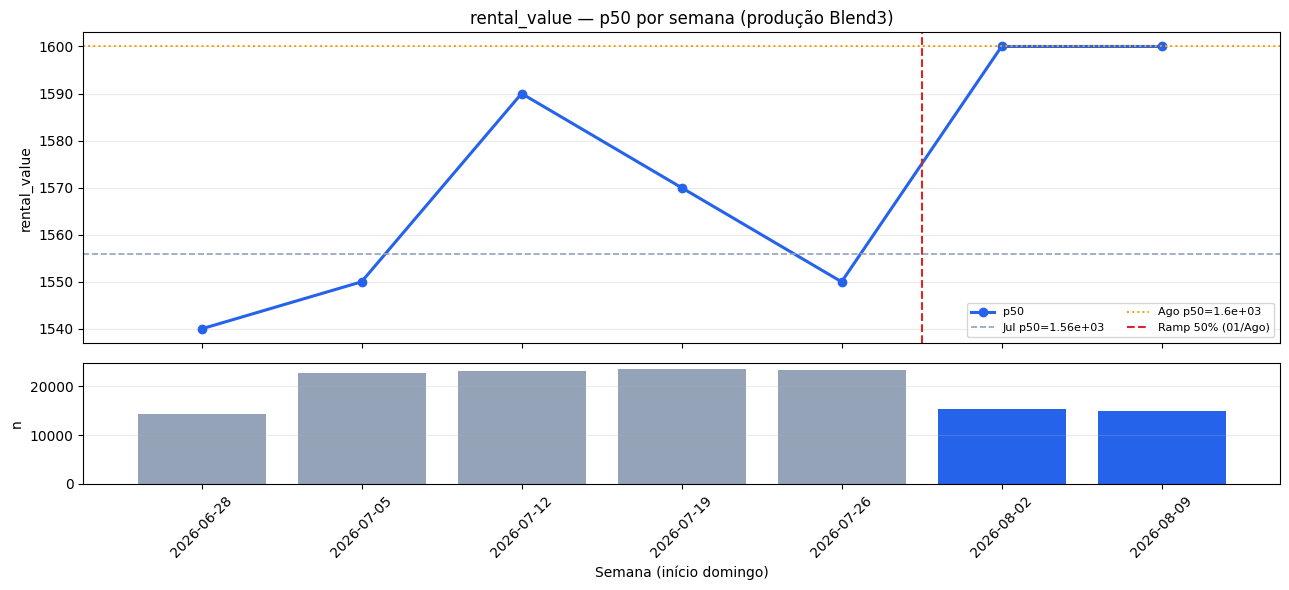

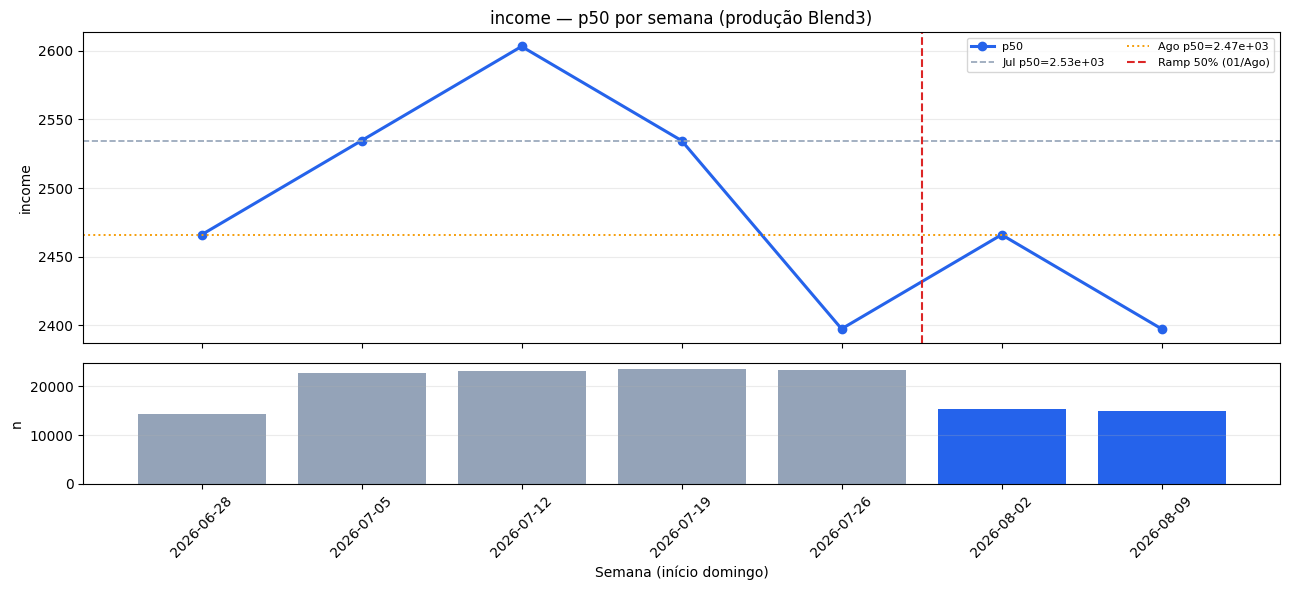

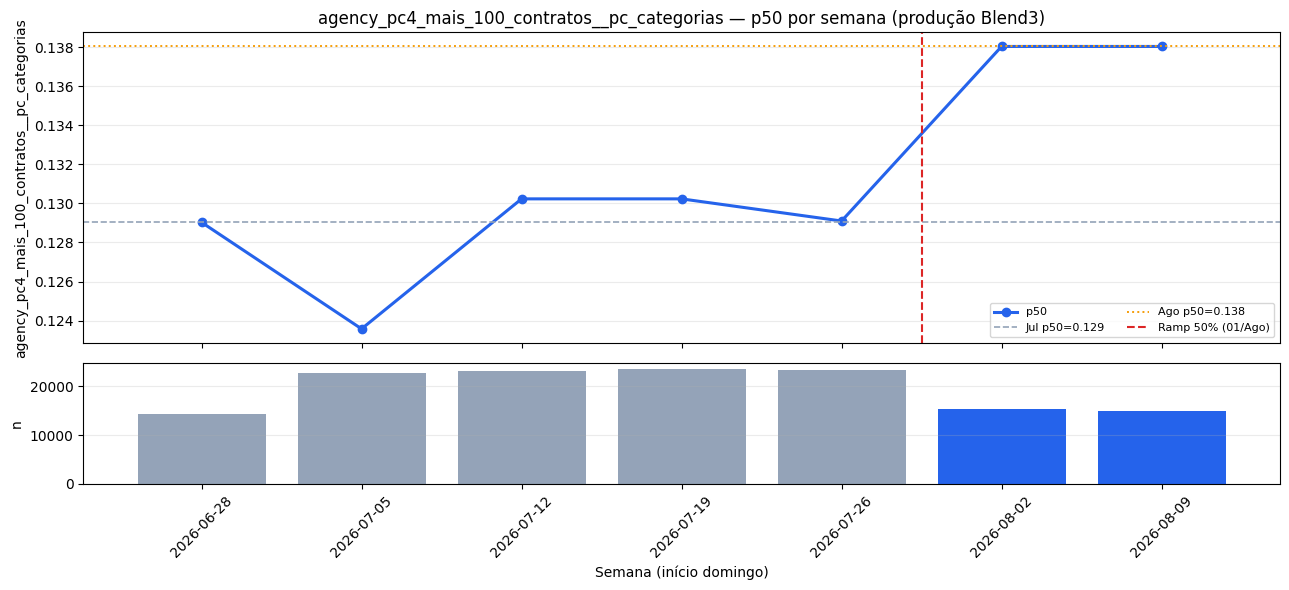

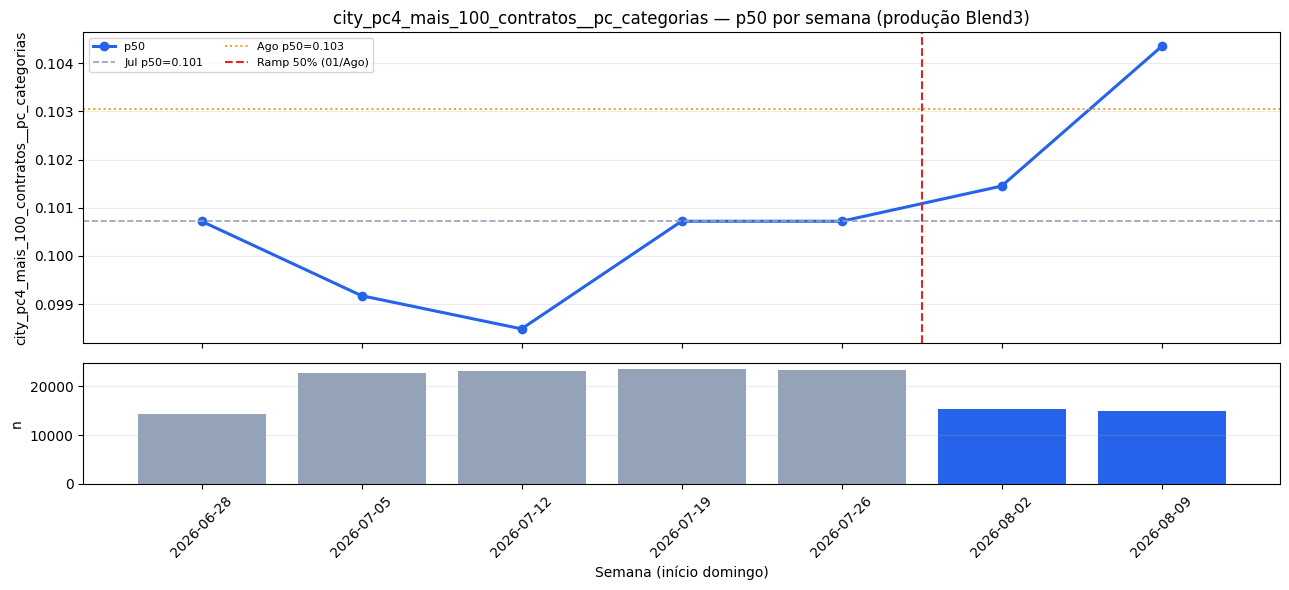

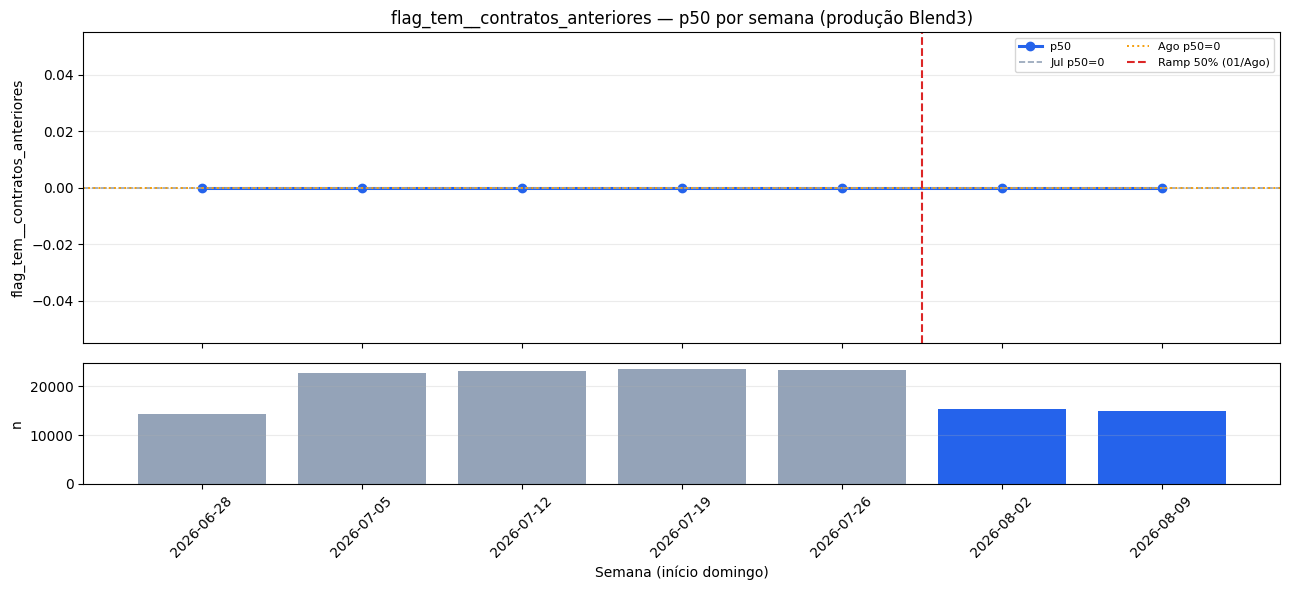

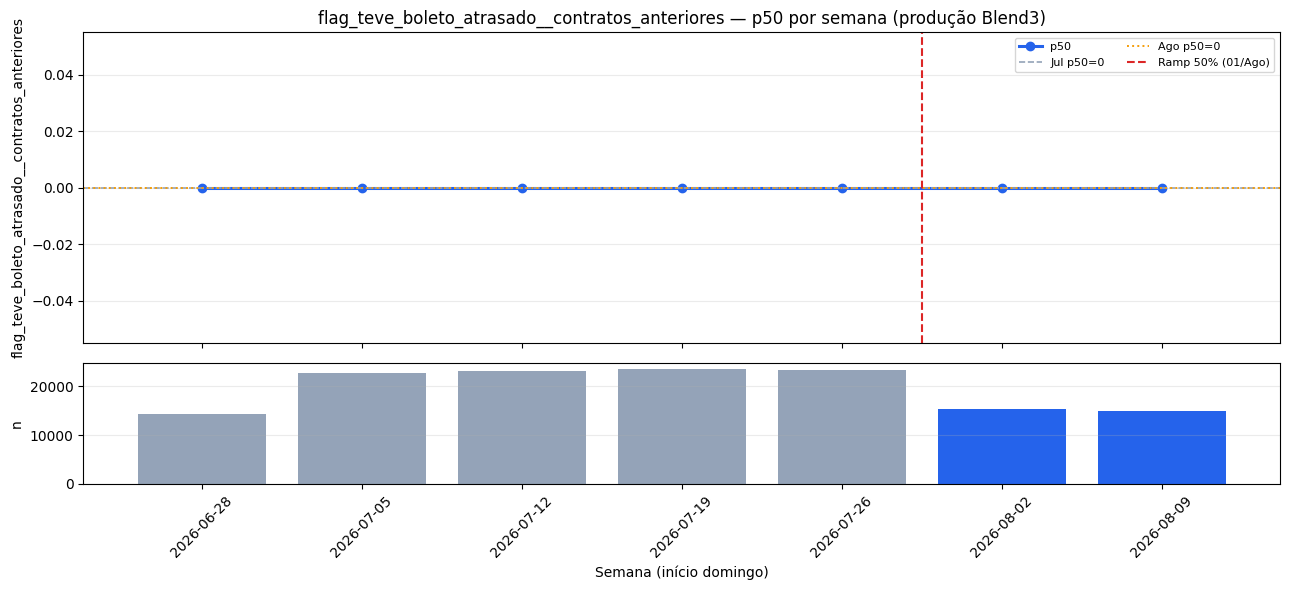

In [23]:
plot_p50_by_week(df_predict_blend3, vars_blend3, "Blend3")